In [2]:
# giusto
# ============================================================
# Extraction.py
# Orphanet pipeline:
# - Download product1, product6, product4
# - Save to C:\Users\biofa\Desktop\DATAEXTRACTION\
# - Parse disease → gene (product6)
# - Save CSV
# - Print first 3 rows
# ============================================================

import urllib.request
from pathlib import Path
from lxml import etree
import pandas as pd

# ----------------------------
# CONFIG
# ----------------------------
ORPHANET_BASE_URL = "https://www.orphadata.com/data/xml"

ORPHANET_PRODUCTS = {
    "product1": {
        "filename": "en_product1.xml",
        "url": f"{ORPHANET_BASE_URL}/en_product1.xml",
        "description": "Nomenclature and classification"
    },
    "product6": {  #  Disease → Gene
        "filename": "en_product6.xml",
        "url": f"{ORPHANET_BASE_URL}/en_product6.xml",
        "description": "Disease–gene associations"
    },
    "product4": {
        "filename": "en_product4.xml",
        "url": f"{ORPHANET_BASE_URL}/en_product4.xml",
        "description": "Phenotypes (HPO)"
    }
}

#  PATH RICHIESTO
DATA_DIR = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION")
DATA_DIR.mkdir(parents=True, exist_ok=True)

# ----------------------------
# DOWNLOAD FUNCTION
# ----------------------------
def download_orphanet_product(product_key):
    info = ORPHANET_PRODUCTS[product_key]
    output_path = DATA_DIR / info["filename"]

    if output_path.exists():
        print(f"✔ {info['filename']} già presente")
        return output_path

    print(f"⬇ Downloading {info['description']}")
    print(f"   {info['url']}")

    req = urllib.request.Request(
        info["url"],
        headers={"User-Agent": "Mozilla/5.0"}
    )

    with urllib.request.urlopen(req) as response:
        with open(output_path, "wb") as f:
            f.write(response.read())

    print(f"✔ Salvato in {output_path}")
    return output_path

# ----------------------------
# PARSER: product6 (disease → gene)
# ----------------------------
def parse_disease_gene(xml_path):
    xml_path = str(xml_path)  # FIX WindowsPath

    parser = etree.XMLParser(
        recover=True,
        huge_tree=True,
        no_network=True
    )
    tree = etree.parse(xml_path, parser)
    root = tree.getroot()

    rows = []

    for disorder in root.xpath(".//Disorder"):
        orpha = disorder.findtext("OrphaCode")
        disease_name = disorder.findtext("Name")

        for gene in disorder.xpath(".//Gene"):
            symbol = gene.findtext("Symbol")
            if symbol:
                rows.append({
                    "ORPHAcode": orpha,
                    "DiseaseName": disease_name,
                    "Gene": symbol
                })

    return pd.DataFrame(rows)

# ----------------------------
# MAIN PIPELINE
# ----------------------------
if __name__ == "__main__":

    # 1️⃣ Download datasets
    download_orphanet_product("product1")
    download_orphanet_product("product6")
    download_orphanet_product("product4")

    print("\n📂 Tutti i file scaricati correttamente\n")

    # 2️⃣ Parse disease → gene
    df = parse_disease_gene(DATA_DIR / "en_product6.xml")

    # 3️⃣ Save CSV
    output_csv = DATA_DIR / "orphanet_disease_gene.csv"
    df.to_csv(output_csv, index=False)
    print(f"📄 CSV salvato in: {output_csv}\n")

    # 4️⃣ Print first 3 rows
    print("🔎 Prime 3 righe del dataset:\n")
    print(df.head(3))

    # 5️⃣ Quick stats
    print("\n📊 Statistiche rapide:")
    print("Malattie uniche:", df["ORPHAcode"].nunique())
    print("Geni unici:", df["Gene"].nunique())
    print("Righe totali:", len(df))


✔ en_product1.xml già presente
✔ en_product6.xml già presente
✔ en_product4.xml già presente

📂 Tutti i file scaricati correttamente

📄 CSV salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_disease_gene.csv

🔎 Prime 3 righe del dataset:

  ORPHAcode                                        DiseaseName   Gene
0    166024  Multiple epiphyseal dysplasia-macrocephaly-fac...   KIF7
1    166035  Brachydactyly-short stature-retinitis pigmento...  CWC27
2        93                             Aspartylglucosaminuria    AGA

📊 Statistiche rapide:
Malattie uniche: 4128
Geni unici: 4552
Righe totali: 8374


In [27]:
# giusto
#(malattia–gene–fenotipo)


# ============================================================
# Orphanet: disease – gene – phenotype (HPO)
# ============================================================

from pathlib import Path
from lxml import etree
import pandas as pd

# ============================================================
# PATH
# ============================================================

BASE = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION")

orphanet_csv = BASE / "orphanet_disease_gene.csv"
product4_xml = BASE / "en_product4.xml"
output_csv = BASE / "orphanet_disease_gene_hpo.csv"

# ============================================================
# LOAD disease → gene
# ============================================================

df = pd.read_csv(orphanet_csv)

df["ORPHAcode"] = df["ORPHAcode"].astype(str)

print("📊 Dataset iniziale")
print("Righe:", len(df))
print("Malattie:", df["ORPHAcode"].nunique())
print("Geni:", df["Gene"].nunique())
print("-" * 60)

# ============================================================
# PARSE HPO (product4) — VERSIONE CORRETTA
# ============================================================

def extract_hpo(product4_xml):
    tree = etree.parse(str(product4_xml))
    root = tree.getroot()

    rows = []

    for disorder in root.xpath(".//Disorder"):
        orpha = disorder.findtext("OrphaCode")
        if orpha is None:
            continue

        for assoc in disorder.xpath(".//HPODisorderAssociation"):
            hpo_id = assoc.findtext(".//HPOId")
            hpo_label = assoc.findtext(".//HPOTerm")
            freq = assoc.findtext(".//Frequency")

            if hpo_id:
                rows.append({
                    "ORPHAcode": str(orpha),
                    "HPO_ID": hpo_id,
                    "HPO_Label": hpo_label,
                    "Frequency": freq
                })

    return pd.DataFrame(rows)


hpo_df = extract_hpo(product4_xml)

print("🧬 HPO estratti:", len(hpo_df))
print("Malattie con HPO:", hpo_df["ORPHAcode"].nunique())
print("HPO unici:", hpo_df["HPO_ID"].nunique())
print("-" * 60)

# ============================================================
# MERGE (chiave sicura)
# ============================================================

df_hpo = df.merge(
    hpo_df,
    on="ORPHAcode",
    how="left"
)

# ============================================================
# SAVE
# ============================================================

df_hpo.to_csv(output_csv, index=False)

print("✅ File con HPO creato:")
print(output_csv)

print("\n🔎 Prime 3 righe:\n")
print(df_hpo.head(3))

# ============================================================
# STATS FINALI (VERIFICA CRITICA)
# ============================================================

print("\n📈 Statistiche finali")
print("Righe totali:", len(df_hpo))
print("Malattie:", df_hpo["ORPHAcode"].nunique())
print("Geni:", df_hpo["Gene"].nunique())
print("HPO unici:", df_hpo["HPO_ID"].nunique())
print("Malattie con ≥1 HPO:",
      df_hpo[df_hpo["HPO_ID"].notna()]["ORPHAcode"].nunique())










📊 Dataset iniziale
Righe: 8374
Malattie: 4128
Geni: 4552
------------------------------------------------------------
🧬 HPO estratti: 115878
Malattie con HPO: 4335
HPO unici: 8701
------------------------------------------------------------
✅ File con HPO creato:
C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_disease_gene_hpo.csv

🔎 Prime 3 righe:

  ORPHAcode                                        DiseaseName  Gene  \
0    166024  Multiple epiphyseal dysplasia-macrocephaly-fac...  KIF7   
1    166024  Multiple epiphyseal dysplasia-macrocephaly-fac...  KIF7   
2    166024  Multiple epiphyseal dysplasia-macrocephaly-fac...  KIF7   

       HPO_ID         HPO_Label Frequency  
0  HP:0000207  Triangular mouth      None  
1  HP:0000256      Macrocephaly      None  
2  HP:0000316     Hypertelorism      None  

📈 Statistiche finali
Righe totali: 175895
Malattie: 4128
Geni: 4552
HPO unici: 7207
Malattie con ≥1 HPO: 2467


In [ ]:
# fino qui sopra è giusto

In [3]:
# giusto
# filtrare gli enzimi metabolici associate a malattia umana da uniprotKB

import pandas as pd
import re

# ==============================
# Percorsi file
# ==============================
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27.tsv"
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.tsv"



# ==============================
# Caricamento TSV UniProt
# ==============================
df = pd.read_csv(input_file, sep="\t")

print(f"Righe totali iniziali: {len(df)}")

# ==============================
# 1️⃣ Enzimi metabolici classici
#    EC completo X.X.X.X
# ==============================
ec_pattern = r"^\d+\.\d+\.\d+\.\d+"

df_enzymes = df[
    df["EC number"].notna() &
    df["EC number"].str.contains(ec_pattern, regex=True)
]

print(f"Dopo filtro EC completo: {len(df_enzymes)}")

# ==============================
# 2️⃣ Attività catalitica presente
# ==============================
df_enzymes = df_enzymes[
    df_enzymes["Catalytic activity"].notna() &
    (df_enzymes["Catalytic activity"] != "")
]

print(f"Dopo filtro attività catalitica: {len(df_enzymes)}")

# ==============================
# 3️⃣ Coinvolgimento in malattie
# ==============================
df_disease = df_enzymes[
    df_enzymes["Involvement in disease"].notna() &
    (df_enzymes["Involvement in disease"] != "")
]

print(f"Dopo filtro malattie: {len(df_disease)}")

# ==============================
# Salvataggio risultato
# ==============================
df_disease.to_csv(output_file, sep="\t", index=False)

print("=================================")
print("Estrazione completata con successo ✅")
print(f"File salvato in:\n{output_file}")


Righe totali iniziali: 20421
Dopo filtro EC completo: 3457
Dopo filtro attività catalitica: 3457
Dopo filtro malattie: 1343
Estrazione completata con successo ✅
File salvato in:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.tsv


In [18]:
# giusto
# trasformare il codice in csv
import pandas as pd

# --------------------------------------------------
# PATH
# --------------------------------------------------
INPUT_TSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.tsv"
OUTPUT_CSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.csv"

# --------------------------------------------------
# LOAD TSV
# --------------------------------------------------
df = pd.read_csv(INPUT_TSV, sep="\t")

# --------------------------------------------------
# SAVE CSV
# --------------------------------------------------
df.to_csv(OUTPUT_CSV, index=False)

# --------------------------------------------------
# CONFIRMA
# --------------------------------------------------
print("✅ File salvato correttamente")
print("Percorso:", OUTPUT_CSV)
print("Righe:", df.shape[0])
print("Colonne:", df.shape[1])
print("\n🔎 Prime 3 righe:\n")
print(df.head(3))


✅ File salvato correttamente
Percorso: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.csv
Righe: 1343
Colonne: 27

🔎 Prime 3 righe:

    Entry  Reviewed                                      Protein names  \
0  A1L167  reviewed  Ubiquitin-conjugating enzyme E2Q-like protein ...   
1  A2PYH4  reviewed  Probable ATP-dependent DNA helicase HFM1 (EC 5...   
2  A4D126  reviewed  D-ribitol-5-phosphate cytidylyltransferase (EC...   

  Interacts with                             Involvement in disease EC number  \
0            NaN  DISEASE: Note=A chromosomal aberration involvi...  2.3.2.23   
1            NaN  DISEASE: Premature ovarian failure 9 (POF9) [M...   5.6.2.4   
2            NaN  DISEASE: Muscular dystrophy-dystroglycanopathy...  2.7.7.40   

                                            Cofactor  \
0                                                NaN   
1  COFACTOR: Name=Zn(2+); Xref=ChEBI:CHEBI:29105;...   
2                                                N

In [45]:
# filtrare le colonne del file uniprotkb_metabolic_enzymes_disease.csv

import pandas as pd
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered.csv"
)

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 Dataset iniziale")
print("Righe:", len(df))
print("Colonne:", len(df.columns))
print("-" * 50)

# ============================================================
# DROP COLONNE INUTILI
# ============================================================

cols_to_drop = [
    "Reviewed",
    "Organism",
    "Protein names", 
    "Interacts with",
    "Tissue specificity",
    "Subunit structure",
    "Disruption phenotype"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("🧹 Colonne rimosse:", cols_to_drop)
print("Colonne rimanenti:", len(df.columns))
print("-" * 50)

# ============================================================
# FILTRA RIGHE SENZA Rhea ID
# ============================================================

df["Rhea ID"] = df["Rhea ID"].astype(str)

df_filtered = df[
    df["Rhea ID"].notna() &
    (df["Rhea ID"] != "") &
    (df["Rhea ID"].str.lower() != "nan")
]

print("🔬 Dopo filtro Rhea ID")
print("Righe rimanenti:", len(df_filtered))
print("-" * 50)

# ============================================================
# SAVE
# ============================================================

df_filtered.to_csv(OUTPUT_FILE, index=False)

print("✅ File filtrato salvato in:")
print(OUTPUT_FILE)

# ============================================================
# CHECK FINALE
# ============================================================

print("\n🔎 Prime 3 righe:")
print(df_filtered.head(3))

print("\n📈 Statistiche finali:")
print("Righe:", len(df_filtered))
print("EC unici:", df_filtered["EC number"].nunique())
print("Rhea ID unici:", df_filtered["Rhea ID"].nunique())
print("Geni unici:", df_filtered["Gene Names"].nunique())



📊 Dataset iniziale
Righe: 1343
Colonne: 27
--------------------------------------------------
🧹 Colonne rimosse: ['Reviewed', 'Organism', 'Protein names', 'Interacts with', 'Tissue specificity', 'Subunit structure', 'Disruption phenotype']
Colonne rimanenti: 20
--------------------------------------------------
🔬 Dopo filtro Rhea ID
Righe rimanenti: 1125
--------------------------------------------------
✅ File filtrato salvato in:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered.csv

🔎 Prime 3 righe:
    Entry                             Involvement in disease  EC number  \
1  A2PYH4  DISEASE: Premature ovarian failure 9 (POF9) [M...    5.6.2.4   
2  A4D126  DISEASE: Muscular dystrophy-dystroglycanopathy...   2.7.7.40   
3  A6NK58  DISEASE: Encephalopathy, neonatal severe, with...  2.3.1.181   

                                            Cofactor  \
1  COFACTOR: Name=Zn(2+); Xref=ChEBI:CHEBI:29105;...   
2                                             

In [9]:
# forse da cancellare
# giusto per filtrare cofattore 

# ============================================================
# COFACTOR FILTER & NORMALIZATION (BIOLOGICALLY SAFE)
# ============================================================



import pandas as pd
import re
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 Dataset caricato:", len(df), "righe")

# ============================================================
# COFACTOR VOCABULARY
# ============================================================

VALID_COFACTORS = {
    "FAD", "FMN", "NAD(+)", "NADP(+)",
    "pyridoxal 5'-phosphate",
    "thiamine diphosphate",
    "biotin",
    "(R)-lipoate",
    "heme", "heme b", "heme c"
}

METAL_PATTERN = re.compile(
    r"\b(Mg|Mn|Fe|Zn|Ca|Cu|Co|Ni|Cd|K)\s*\(\d\+\)|"
    r"\bFe cation\b|"
    r"\ba divalent metal cation\b",
    re.IGNORECASE
)

# ============================================================
# EXTRACT + NORMALIZE
# ============================================================

def extract_and_normalize_cofactor(text):
    if pd.isna(text):
        return None

    # 1️⃣ estrai tutti i Name=...
    names = re.findall(r"Name=([^;]+)", text)

    found = set()

    for n in names:
        n = n.strip()

        # cofattori organici
        if n in VALID_COFACTORS:
            found.add(n)

        # metalli
        elif METAL_PATTERN.search(n):
            found.add("METAL")

    if not found:
        return None

    return ";".join(sorted(found))

# ============================================================
# APPLY
# ============================================================

df["Cofactor_normalized"] = df["Cofactor"].apply(extract_and_normalize_cofactor)

# ============================================================
# SAVE
# ============================================================

df.to_csv(OUTPUT_FILE, index=False)

print("✅ File salvato:")
print(OUTPUT_FILE)

# ============================================================
# CHECK
# ============================================================

print("\n🔎 Esempi:")
print(df[["Cofactor", "Cofactor_normalized"]].dropna().head(10))

 





📊 Dataset caricato: 1125 righe
✅ File salvato:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor.csv

🔎 Esempi:
                                             Cofactor Cofactor_normalized
0   COFACTOR: Name=Zn(2+); Xref=ChEBI:CHEBI:29105;...               METAL
4   COFACTOR: Name=FAD; Xref=ChEBI:CHEBI:57692; Ev...                 FAD
7   COFACTOR: Name=Mg(2+); Xref=ChEBI:CHEBI:18420;...               METAL
9   COFACTOR: Name=Zn(2+); Xref=ChEBI:CHEBI:29105;...               METAL
12  COFACTOR: Name=Ca(2+); Xref=ChEBI:CHEBI:29108;...               METAL
14  COFACTOR: Name=Fe(2+); Xref=ChEBI:CHEBI:29033;...               METAL
17  COFACTOR: Name=Mg(2+); Xref=ChEBI:CHEBI:18420;...               METAL
18  COFACTOR: Name=Mg(2+); Xref=ChEBI:CHEBI:18420;...               METAL
24  COFACTOR: Name=Mg(2+); Xref=ChEBI:CHEBI:18420;...               METAL
25  COFACTOR: Name=Mg(2+); Xref=ChEBI:CHEBI:18420;...               METAL


In [52]:
# pathway filter
import pandas as pd
import re
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor_pathway.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 Dataset caricato")
print("Righe:", len(df))
print("-" * 50)

# ============================================================
# CLEAN PATHWAY COLUMN (PRECISION MODE)
# ============================================================

def clean_pathway(text):
    if pd.isna(text):
        return text

    # 1️⃣ rimuove TUTTI i blocchi {ECO:...}
    text = re.sub(r"\{ECO:[^}]*\}", "", text)

    # 2️⃣ rimuove PATHWAY:
    text = re.sub(r"\bPATHWAY:\s*", "", text)

    # 3️⃣ normalizza separatori ;
    text = re.sub(r"\s*;\s*", ";", text)

    # 4️⃣ pulizia finale
    text = text.strip(" ;")

    return text

# 🔥 APPLICA PULIZIA
df["Pathway"] = df["Pathway"].apply(clean_pathway)

# ============================================================
# SAVE
# ============================================================

df.to_csv(OUTPUT_FILE, index=False)

print("✅ File salvato con Pathway pulito:")
print(OUTPUT_FILE)

# ============================================================
# CHECK
# ============================================================

print("\n🔎 Esempi Pathway puliti:")
print(df["Pathway"].dropna().head(5))


📊 Dataset caricato
Righe: 1125
--------------------------------------------------
✅ File salvato con Pathway pulito:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor_pathway.csv

🔎 Esempi Pathway puliti:
1        Protein modification;protein glycosylation. .
2    Protein modification;protein lipoylation via e...
3          Lipid metabolism;fatty acid biosynthesis. .
4    Glycerolipid metabolism;ether lipid biosynthesis.
8    Phospholipid metabolism;phosphatidylinositol p...
Name: Pathway, dtype: object


In [1]:
# pulire ancora il file 
import pandas as pd
from pathlib import Path
import re

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_filtered_clean_cofactor_pathway.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 Dataset caricato")
print("Righe:", len(df))
print("Colonne iniziali:", len(df.columns))
print("-" * 60)

# ============================================================
# DROP COLUMNS
# ============================================================

cols_to_drop = [
    "Activity regulation",
    "Function [CC]",
    "Polymorphism",
    "Length",
    "Mass",
    "Subcellular location [CC]",
    "Subunit structure"
]

df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("🧹 Colonne rimosse:")
for c in cols_to_drop:
    if c in df.columns:
        print("  ❌", c)

# ============================================================
# CLEAN Involvement in disease
# ============================================================

if "Involvement in disease" in df.columns:
    df["Involvement in disease"] = (
        df["Involvement in disease"]
        .astype(str)
        .str.replace(r"^DISEASE:\s*", "", regex=True)
        .str.strip()
    )

print("🧬 Colonna 'Involvement in disease' pulita")

# ============================================================
# SAVE
# ============================================================

df.to_csv(OUTPUT_FILE, index=False)

print("-" * 60)
print("✅ File finale salvato con successo:")
print(OUTPUT_FILE)

# ============================================================
# STATS FINALI
# ============================================================

print("\n📈 Statistiche finali")
print("Righe:", len(df))
print("Colonne:", len(df.columns))
print("Geni unici:", df["Gene Names"].nunique() if "Gene Names" in df.columns else "NA")
print("EC unici:", df["EC number"].nunique() if "EC number" in df.columns else "NA")
print("Rhea ID unici:", df["Rhea ID"].nunique() if "Rhea ID" in df.columns else "NA")


📊 Dataset caricato
Righe: 1125
Colonne iniziali: 20
------------------------------------------------------------
🧹 Colonne rimosse:
🧬 Colonna 'Involvement in disease' pulita
------------------------------------------------------------
✅ File finale salvato con successo:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL.csv

📈 Statistiche finali
Righe: 1125
Colonne: 14
Geni unici: 1125
EC unici: 690
Rhea ID unici: 711


In [2]:
# reordinare le colonne
import pandas as pd
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 Dataset caricato")
print("Colonne originali:")
print(df.columns.tolist())
print("-" * 60)

# ============================================================
# MOVE 'Gene Names' AFTER 'Entry'
# ============================================================

cols = df.columns.tolist()

if "Entry" not in cols or "Gene Names" not in cols:
    raise ValueError("❌ Colonne 'Entry' o 'Gene Names' non trovate")

# rimuovi Gene Names
cols.remove("Gene Names")

# inserisci Gene Names subito dopo Entry
entry_index = cols.index("Entry")
cols.insert(entry_index + 1, "Gene Names")

# riordina dataframe
df = df[cols]

print("✅ Colonne riordinate correttamente")
print("Nuovo ordine colonne:")
print(df.columns.tolist())

# ============================================================
# SAVE
# ============================================================

df.to_csv(OUTPUT_FILE, index=False)

print("-" * 60)
print("💾 File salvato:")
print(OUTPUT_FILE)


📊 Dataset caricato
Colonne originali:
['Entry', 'Involvement in disease', 'EC number', 'Cofactor', 'Rhea ID', 'Pathway', 'Gene Names', 'Active site', 'Binding site', 'Kinetics', 'Catalytic activity', 'Mutagenesis', 'Natural variant', 'Sequence']
------------------------------------------------------------
✅ Colonne riordinate correttamente
Nuovo ordine colonne:
['Entry', 'Gene Names', 'Involvement in disease', 'EC number', 'Cofactor', 'Rhea ID', 'Pathway', 'Active site', 'Binding site', 'Kinetics', 'Catalytic activity', 'Mutagenesis', 'Natural variant', 'Sequence']
------------------------------------------------------------
💾 File salvato:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv


In [3]:
# extract only 3 columns: cofactor, id rhea, ec dal file per pulirli :  uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv
import pandas as pd

# Percorsi dei file
input_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv'
output_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_path.csv'

try:
    # Caricamento del file (aggiunto sep=None per rilevare automaticamente , o ;)
    df = pd.read_csv(input_path, sep=None, engine='python')

    # Nuova lista di colonne aggiornata
    columns_to_extract = ['EC number', 'Cofactor', 'Rhea ID', 'Pathway']
    
    # Verifichiamo se le colonne esistono effettivamente nel file
    existing_columns = [col for col in columns_to_extract if col in df.columns]
    
    if len(existing_columns) < len(columns_to_extract):
        missing = set(columns_to_extract) - set(existing_columns)
        print(f"Attenzione: Le seguenti colonne non sono state trovate: {missing}")
        print(f"Colonne effettivamente presenti nel file: {list(df.columns)}")
    else:
        # Estrazione delle 4 colonne
        df_final = df[columns_to_extract]

        # Salvataggio del risultato
        df_final.to_csv(output_path, index=False)
        
        print("Estrazione completata!")
        print(f"File salvato in: {output_path}")
        print("\nPrime 5 righe del nuovo file:")
        print(df_final.head())

except Exception as e:
    print(f"Errore durante l'elaborazione: {e}")

Estrazione completata!
File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_path.csv

Prime 5 righe del nuovo file:
   EC number                                           Cofactor  \
0    5.6.2.4  Zn(2+);CHEBI:29105;;Note=Might have a zinc-fin...   
1   2.7.7.40                                                NaN   
2  2.3.1.181                                                NaN   
3  4.2.1.134                                                NaN   
4   2.5.1.26                                    FAD;CHEBI:57692   

                                             Rhea ID  \
0                                         RHEA:13065   
1                   RHEA:12456 RHEA:53872 RHEA:53612   
2                                         RHEA:17665   
3  RHEA:45812 RHEA:39159 RHEA:39155 RHEA:39175 RH...   
4                   RHEA:36171 RHEA:40659 RHEA:40727   

                                             Pathway  
0                                                NaN  
1      Protein 

In [4]:
# extract chebi and cofactor name

import pandas as pd

# Percorsi dei file
input_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv'
output_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_cleaned.csv'

def extract_cofactor_info(cell):
    """
    Funzione per dividere la stringa del cofattore in ID ChEBI e Nomi.
    Rimuove le note e mantiene l'ordine.
    """
    if pd.isna(cell) or cell == "":
        return "", ""
    
    # Dividiamo per ';;' che separa i diversi cofattori o le note
    parts = str(cell).split(';;')
    
    names = []
    chebi_ids = []
    
    for part in parts:
        part = part.strip()
        # Ignoriamo le parti che iniziano con "Note=" o sono vuote
        if not part or part.startswith("Note="):
            continue
        
        # Ogni parte valida è nel formato "Nome;CHEBI:ID"
        # Dividiamo per ';' per separare nome e ID
        sub_parts = part.split(';')
        if len(sub_parts) >= 2:
            name = sub_parts[0].strip()
            chebi = sub_parts[1].strip()
            
            # Verifichiamo che la seconda parte sia effettivamente un ID ChEBI
            if "CHEBI:" in chebi:
                names.append(name)
                chebi_ids.append(chebi)
    
    # Uniamo i risultati con il punto e virgola come richiesto
    return ";".join(chebi_ids), ";".join(names)

try:
    # 1. Caricamento del file
    df = pd.read_csv(input_path, sep=None, engine='python')

    # 2. Applicazione della funzione di estrazione
    # Creiamo le due nuove colonne applicando la funzione alla colonna 'Cofactor'
    df[['ChEBI cofactor', 'Cofactor name']] = df['Cofactor'].apply(
        lambda x: pd.Series(extract_cofactor_info(x))
    )

    # 3. Selezione e riordino delle colonne finali
    columns_to_keep = ['EC number', 'Rhea ID', 'Pathway', 'ChEBI cofactor', 'Cofactor name']
    
    # Controllo che le colonne originali esistano
    existing_cols = [c for c in columns_to_keep if c in df.columns or c in ['ChEBI cofactor', 'Cofactor name']]
    df_final = df[existing_cols]

    # 4. Salvataggio
    df_final.to_csv(output_path, index=False)
    
    print("Processo completato con successo!")
    print(f"File salvato in: {output_path}")
    print("\nEsempio del risultato:")
    print(df_final[['ChEBI cofactor', 'Cofactor name']].head(10))

except Exception as e:
    print(f"Errore: {e}")

Processo completato con successo!
File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_cleaned.csv

Esempio del risultato:
            ChEBI cofactor     Cofactor name
0              CHEBI:29105            Zn(2+)
1                                           
2                                           
3                                           
4              CHEBI:57692               FAD
5                                           
6              CHEBI:49883  [4Fe-4S] cluster
7  CHEBI:18420;CHEBI:29035     Mg(2+);Mn(2+)
8                                           
9              CHEBI:29105            Zn(2+)


In [5]:
# pulire cofattore   27/01/2026

 
import pandas as pd

# =====================================================
# 1. LOAD FILE
# =====================================================
input_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_cleaned.csv"

try:
    df = pd.read_csv(input_path)
except Exception:
    df = pd.read_csv(input_path, encoding="latin1")

# =====================================================
# 2. NORMALIZE TEXT COLUMNS
# =====================================================
df["Cofactor name"] = (
    df["Cofactor name"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["ChEBI cofactor"] = (
    df["ChEBI cofactor"]
    .astype(str)
    .str.strip()
)

# =====================================================
# 3. SPLIT MULTIPLE COFACTORS (CHEBI-BASED)
# =====================================================
df["Cofactor_list"] = df["Cofactor name"].str.split(";")
df["ChEBI_list"] = df["ChEBI cofactor"].str.split(";")

df = df.explode(["Cofactor_list", "ChEBI_list"])

df["Cofactor_list"] = df["Cofactor_list"].str.strip()
df["ChEBI_list"] = df["ChEBI_list"].str.strip()

# =====================================================
# 4. DEFINE VALID CHEBI SETS (BIOLOGICALLY CURATED)
# =====================================================

# --- Organici veri ---
ORGANIC_CHEBI = {
    "CHEBI:57692",   # FAD
    "CHEBI:58210",   # FMN
    "CHEBI:57540",   # NAD(+)
    "CHEBI:58349",   # NADP(+)
    "CHEBI:597326",  # pyridoxal 5'-phosphate (PLP)
    "CHEBI:15346",   # thiamine diphosphate
    "CHEBI:15956",   # biotin
    "CHEBI:29985",   # (R)-lipoate
    "CHEBI:16304",   # adenosylcobalamin
    "CHEBI:16309",   # methylcobalamin
    "CHEBI:30413",   # heme
    "CHEBI:60344",   # heme b
    "CHEBI:61717",   # heme c
    "CHEBI:16856",   # glutathione
    "CHEBI:83088"    # dipyrromethane
}

# --- Metalli / cluster ---
METAL_CHEBI = {
    "CHEBI:18420",   # Mg(2+)
    "CHEBI:29035",   # Mn(2+)
    "CHEBI:29105",   # Zn(2+)
    "CHEBI:29108",   # Ca(2+)
    "CHEBI:29033",   # Fe(2+)
    "CHEBI:29034",   # Fe(3+)
    "CHEBI:24875",   # Fe cation
    "CHEBI:29036",   # Cu(2+)
    "CHEBI:23378",   # Cu cation
    "CHEBI:48828",   # Co(2+)
    "CHEBI:49786",   # Ni(2+)
    "CHEBI:49415",   # Cd(2+)
    "CHEBI:29103",   # K(+)
    "CHEBI:49883",   # [4Fe-4S] cluster
    "CHEBI:47854",   # [2Fe-2S] cluster
    "CHEBI:60240",   # divalent metal cation (unspecified)
    "CHEBI:190135"   # Mo-molybdopterin related
}

VALID_CHEBI = ORGANIC_CHEBI.union(METAL_CHEBI)

# =====================================================
# 5. REMOVE NON-COFACTORS
# =====================================================
EXCLUDE_CHEBI = {
    "CHEBI:15422",  # ATP
    "CHEBI:15361",  # pyruvate
    "CHEBI:28115"   # inositol hexakisphosphate
}

df = df[
    df["ChEBI_list"].isin(VALID_CHEBI)
    & ~df["ChEBI_list"].isin(EXCLUDE_CHEBI)
]

# =====================================================
# 6. ASSIGN COFACTOR TYPE
# =====================================================
df["Cofactor_type"] = df["ChEBI_list"].apply(
    lambda x: "metal" if x in METAL_CHEBI else "organic_cofactor"
)

# =====================================================
# 7. FINAL TIDY TABLE
# =====================================================
final_df = df[
    [
        "EC number",
        "Rhea ID",
        "Pathway",
        "Cofactor_list",
        "Cofactor_type",
        "ChEBI_list"
    ]
].rename(
    columns={
        "Cofactor_list": "Cofactor",
        "ChEBI_list": "CHEBI"
    }
)

# =====================================================
# 8. SAVE OUTPUT
# =====================================================
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv"
final_df.to_csv(output_path, index=False)

print("✅ Dataset finale corretto creato")
print("📁 File salvato in:", output_path)
import pandas as pd

# =====================================================
# 1. LOAD FILE
# =====================================================
input_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_rhea_EC_cleaned.csv"

try:
    df = pd.read_csv(input_path)
except Exception:
    df = pd.read_csv(input_path, encoding="latin1")

# =====================================================
# 2. NORMALIZE TEXT COLUMNS
# =====================================================
df["Cofactor name"] = (
    df["Cofactor name"]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

df["ChEBI cofactor"] = (
    df["ChEBI cofactor"]
    .astype(str)
    .str.strip()
)

# =====================================================
# 3. SPLIT MULTIPLE COFACTORS (CHEBI-BASED)
# =====================================================
df["Cofactor_list"] = df["Cofactor name"].str.split(";")
df["ChEBI_list"] = df["ChEBI cofactor"].str.split(";")

df = df.explode(["Cofactor_list", "ChEBI_list"])

df["Cofactor_list"] = df["Cofactor_list"].str.strip()
df["ChEBI_list"] = df["ChEBI_list"].str.strip()

# =====================================================
# 4. DEFINE VALID CHEBI SETS (BIOLOGICALLY CURATED)
# =====================================================

# --- Organici veri ---
ORGANIC_CHEBI = {
    "CHEBI:57692",   # FAD
    "CHEBI:58210",   # FMN
    "CHEBI:57540",   # NAD(+)
    "CHEBI:58349",   # NADP(+)
    "CHEBI:597326",  # pyridoxal 5'-phosphate (PLP)
    "CHEBI:15346",   # thiamine diphosphate
    "CHEBI:15956",   # biotin
    "CHEBI:29985",   # (R)-lipoate
    "CHEBI:16304",   # adenosylcobalamin
    "CHEBI:16309",   # methylcobalamin
    "CHEBI:30413",   # heme
    "CHEBI:60344",   # heme b
    "CHEBI:61717",   # heme c
    "CHEBI:16856",   # glutathione
    "CHEBI:83088"    # dipyrromethane
}

# --- Metalli / cluster ---
METAL_CHEBI = {
    "CHEBI:18420",   # Mg(2+)
    "CHEBI:29035",   # Mn(2+)
    "CHEBI:29105",   # Zn(2+)
    "CHEBI:29108",   # Ca(2+)
    "CHEBI:29033",   # Fe(2+)
    "CHEBI:29034",   # Fe(3+)
    "CHEBI:24875",   # Fe cation
    "CHEBI:29036",   # Cu(2+)
    "CHEBI:23378",   # Cu cation
    "CHEBI:48828",   # Co(2+)
    "CHEBI:49786",   # Ni(2+)
    "CHEBI:49415",   # Cd(2+)
    "CHEBI:29103",   # K(+)
    "CHEBI:49883",   # [4Fe-4S] cluster
    "CHEBI:47854",   # [2Fe-2S] cluster
    "CHEBI:60240",   # divalent metal cation (unspecified)
    "CHEBI:190135"   # Mo-molybdopterin related
}

VALID_CHEBI = ORGANIC_CHEBI.union(METAL_CHEBI)

# =====================================================
# 5. REMOVE NON-COFACTORS
# =====================================================
EXCLUDE_CHEBI = {
    "CHEBI:15422",  # ATP
    "CHEBI:15361",  # pyruvate
    "CHEBI:28115"   # inositol hexakisphosphate
}

df = df[
    df["ChEBI_list"].isin(VALID_CHEBI)
    & ~df["ChEBI_list"].isin(EXCLUDE_CHEBI)
]

# =====================================================
# 6. ASSIGN COFACTOR TYPE
# =====================================================
df["Cofactor_type"] = df["ChEBI_list"].apply(
    lambda x: "metal" if x in METAL_CHEBI else "organic_cofactor"
)

# =====================================================
# 7. FINAL TIDY TABLE
# =====================================================
final_df = df[
    [
        "EC number",
        "Rhea ID",
        "Pathway",
        "Cofactor_list",
        "Cofactor_type",
        "ChEBI_list"
    ]
].rename(
    columns={
        "Cofactor_list": "Cofactor",
        "ChEBI_list": "CHEBI"
    }
)

# =====================================================
# 8. SAVE OUTPUT
# =====================================================
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv"
final_df.to_csv(output_path, index=False)

print("✅ Dataset finale corretto creato")
print("📁 File salvato in:", output_path)


✅ Dataset finale corretto creato
📁 File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv
✅ Dataset finale corretto creato
📁 File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv


In [6]:
# unire e 2 files : C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv e C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv'

import pandas as pd

# =====================================================
# 1. LOAD DATASETS
# =====================================================
main_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv"
cofactor_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv"

df_main = pd.read_csv(main_path)
df_cof = pd.read_csv(cofactor_path)

# =====================================================
# 2. NORMALIZE JOIN KEYS
# =====================================================
df_main["Rhea_ID"] = df_main["Rhea_ID"].astype(str).str.strip()
df_main["EC"] = df_main["EC"].astype(str).str.strip()

df_cof["Rhea ID"] = df_cof["Rhea ID"].astype(str).str.strip()
df_cof["EC number"] = df_cof["EC number"].astype(str).str.strip()

# =====================================================
# 3. MERGE (LEFT JOIN, MANY-TO-MANY SAFE)
# =====================================================
merged_df = df_main.merge(
    df_cof,
    how="left",
    left_on=["Rhea_ID", "EC"],
    right_on=["Rhea ID", "EC number"]
)

# =====================================================
# 4. DROP UNUSED / DUPLICATE COLUMNS
# =====================================================
merged_df = merged_df.drop(
    columns=[
        "Rhea ID",
        "EC number",
        "PhysiologicalDirection"  # <- rimosso come richiesto
    ],
    errors="ignore"
)

# =====================================================
# 5. RENAME COFACTOR CHEBI COLUMN
# =====================================================
merged_df = merged_df.rename(
    columns={"CHEBI": "CHEBI_Cofactor"}
)

# =====================================================
# 6. SELECT & ORDER FINAL COLUMNS
# =====================================================
final_columns = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "ChEBI substruct",
    "ChEBI product",
    "Cofactor",
    "Cofactor_type",
    "CHEBI_Cofactor",
    "HPO_ID",
    "HPO_Label"
]

# Manteniamo solo quelle realmente presenti
final_columns = [c for c in final_columns if c in merged_df.columns]
final_df = merged_df[final_columns]

# =====================================================
# 7. SAVE FINAL DATASET
# =====================================================
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_CON_COFATTORI.csv"
final_df.to_csv(output_path, index=False)

print("✅ Dataset finale creato correttamente")
print("📁 File salvato in:", output_path)
print("🔬 Numero righe finali:", final_df.shape[0])


✅ Dataset finale creato correttamente
📁 File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_CON_COFATTORI.csv
🔬 Numero righe finali: 160663


In [7]:
# analisi statistica
import pandas as pd

# =====================================================
# PATHS
# =====================================================
main_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv"
cofactor_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofactor_FINAL_CORRECT.csv"

# =====================================================
# LOAD FILES
# =====================================================
df_main = pd.read_csv(main_path)
df_cof = pd.read_csv(cofactor_path)

# =====================================================
# NORMALIZE COLUMNS
# =====================================================
df_main["Rhea_ID"] = df_main["Rhea_ID"].astype(str).str.strip()
df_main["EC"] = df_main["EC"].astype(str).str.strip()

df_cof["Rhea ID"] = df_cof["Rhea ID"].astype(str).str.strip()
df_cof["EC number"] = df_cof["EC number"].astype(str).str.strip()

# =====================================================
# ANALISI DATASET PRINCIPALE
# =====================================================
main_stats = {
    "dataset": "dataset_finale_COMPLETATO",
    "rows": df_main.shape[0],
    "unique_Rhea_ID": df_main["Rhea_ID"].nunique(),
    "unique_EC": df_main["EC"].nunique(),
    "unique_Rhea_EC": df_main[["Rhea_ID", "EC"]].drop_duplicates().shape[0]
}

# =====================================================
# ANALISI DATASET COFATTORI
# =====================================================
cofactor_stats = {
    "dataset": "cofactor_FINAL_CORRECT",
    "rows": df_cof.shape[0],
    "unique_Rhea_ID": df_cof["Rhea ID"].nunique(),
    "unique_EC": df_cof["EC number"].nunique(),
    "unique_Rhea_EC": df_cof[["Rhea ID", "EC number"]].drop_duplicates().shape[0]
}

# =====================================================
# PRINT RESULTS
# =====================================================
stats_df = pd.DataFrame([main_stats, cofactor_stats])

print("📊 STATISTICHE RIASSUNTIVE DEI DATASET")
print("-" * 50)
print(stats_df)



📊 STATISTICHE RIASSUNTIVE DEI DATASET
--------------------------------------------------
                     dataset    rows  unique_Rhea_ID  unique_EC  \
0  dataset_finale_COMPLETATO  127096            1696        687   
1     cofactor_FINAL_CORRECT     544             326        326   

   unique_Rhea_EC  
0            3030  
1             340  


In [8]:
# analisi statistica

import pandas as pd

# =====================================================
# 1. LOAD DATASET
# =====================================================
path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_CON_COFATTORI.csv"
df = pd.read_csv(path)

# =====================================================
# 2. DEFINIAMO COS'È "REACTION"
# =====================================================
# Usiamo Rhea_ID come unità di reazione
# (puoi aggiungere EC se vuoi maggiore granularità)

reaction_key = ["Rhea_ID", "EC"]


# =====================================================
# 3. IDENTIFICARE REAZIONI CON / SENZA COFATTORE
# =====================================================
# Una reazione ha cofattore se almeno una riga ha Cofactor non null

cofactor_presence = (
    df
    .groupby(reaction_key)["Cofactor"]
    .apply(lambda x: x.notna().any())
    .reset_index(name="has_cofactor")
)
# =====================================================
# 4. CONTEGGI
# =====================================================
total_reactions = cofactor_presence.shape[0]

reactions_with_cofactor = cofactor_presence["has_cofactor"].sum()
reactions_without_cofactor = total_reactions - reactions_with_cofactor

# =====================================================
# 5. PERCENTUALI
# =====================================================
perc_with = reactions_with_cofactor / total_reactions * 100
perc_without = reactions_without_cofactor / total_reactions * 100

# =====================================================
# 6. PRINT RISULTATI
# =====================================================
print("📊 ANALISI COFATTORI PER RHEA_ID")
print("-" * 40)
print(f"Totale reazioni (Rhea_ID): {total_reactions:,}")
print(f"Reazioni CON cofattore:   {reactions_with_cofactor:,} ({perc_with:.2f}%)")
print(f"Reazioni SENZA cofattore: {reactions_without_cofactor:,} ({perc_without:.2f}%)")

df.groupby(["Rhea_ID", "EC"])["Cofactor"].nunique().value_counts().sort_index()
cofactor_presence[~cofactor_presence["has_cofactor"]].head()

print(df.groupby(["Rhea_ID", "EC"])["Cofactor"].nunique().value_counts().sort_index())
print(cofactor_presence[~cofactor_presence["has_cofactor"]].head())






📊 ANALISI COFATTORI PER RHEA_ID
----------------------------------------
Totale reazioni (Rhea_ID): 3,030
Reazioni CON cofattore:   154 (5.08%)
Reazioni SENZA cofattore: 2,876 (94.92%)
0    2876
1     130
2      17
3       6
4       1
Name: Cofactor, dtype: int64
      Rhea_ID         EC  has_cofactor
1  RHEA:10076  3.2.1.108         False
2  RHEA:10076   3.2.1.62         False
3  RHEA:10100   3.1.1.13         False
4  RHEA:10100    3.1.1.3         False
5  RHEA:10100    3.1.1.6         False


In [9]:
# extarct il file witout cofactor
import pandas as pd

# =====================================================
# PATH
# =====================================================
input_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_CON_COFATTORI.csv"
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\reazioni_senza_cofattore.csv"

# =====================================================
# 1. LOAD DATASET
# =====================================================
df = pd.read_csv(input_path)

# =====================================================
# 2. NORMALIZZAZIONE (sicurezza)
# =====================================================
df["Rhea_ID"] = df["Rhea_ID"].astype(str).str.strip()
df["EC"] = df["EC"].astype(str).str.strip()

# =====================================================
# 3. IDENTIFICARE (Rhea_ID, EC) SENZA COFATTORI
# =====================================================
# Una reazione NON ha cofattore se *tutte* le righe hanno Cofactor NaN o vuoto

no_cofactor_pairs = (
    df
    .groupby(["Rhea_ID", "EC"])["Cofactor"]
    .apply(lambda x: x.isna().all() or (x.astype(str).str.strip() == "").all())
    .reset_index(name="no_cofactor")
)

# Tenere solo quelle senza cofattore
no_cofactor_pairs = no_cofactor_pairs[no_cofactor_pairs["no_cofactor"]]

# =====================================================
# 4. FILTRARE IL DATASET ORIGINALE
# =====================================================
df_no_cofactor = df.merge(
    no_cofactor_pairs[["Rhea_ID", "EC"]],
    on=["Rhea_ID", "EC"],
    how="inner"
)

# =====================================================
# 5. SELEZIONE COLONNE RICHIESTE
# =====================================================
df_no_cofactor = df_no_cofactor[
    ["Entry", "Rhea_ID", "EC", "Cofactor", "Cofactor_type", "CHEBI_Cofactor"]
].drop_duplicates()

# =====================================================
# 6. SALVATAGGIO
# =====================================================
df_no_cofactor.to_csv(output_path, index=False)

# =====================================================
# 7. REPORT
# =====================================================
print("📊 ESTRAZIONE COMPLETATA")
print("-" * 40)
print(f"Reazioni senza cofattore (Rhea_ID–EC): {no_cofactor_pairs.shape[0]}")
print(f"Righe nel file estratto:               {df_no_cofactor.shape[0]}")
print(f"File salvato in: {output_path}")



📊 ESTRAZIONE COMPLETATA
----------------------------------------
Reazioni senza cofattore (Rhea_ID–EC): 2876
Righe nel file estratto:               3432
File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\reazioni_senza_cofattore.csv


In [16]:
# =====================================================
# TROVARE COFATTORI (EVIDENZA UNIPROT)
# =====================================================

import pandas as pd
import requests
import time

# =====================================================
# PATHS
# =====================================================
path_input = r'C:\Users\biofa\Desktop\DATAEXTRACTION\reazioni_senza_cofattore.csv'
path_output = r'C:\Users\biofa\Desktop\DATAEXTRACTION\cofattori_recuperati.csv'

# =====================================================
# FUNZIONE UNIPROT
# =====================================================
def fetch_uniprot_cofactor(entry):
    """
    Recupera cofattori proteici annotati in UniProt (commentType = COFACTOR).
    Restituisce (nomi_cofattori, chebi_ids) oppure (None, None).
    """
    url = f"https://rest.uniprot.org/uniprotkb/{entry}.json"
    names = []
    chebis = []

    try:
        r = requests.get(url, timeout=10)
        if r.status_code != 200:
            return None, None

        data = r.json()

        for comment in data.get("comments", []):
            if comment.get("commentType") == "COFACTOR":
                for cof in comment.get("cofactors", []):
                    name = cof.get("name")
                    chebi = cof.get("cofactorCrossReference", {}).get("id")
                    if name:
                        names.append(name)
                    if chebi:
                        chebis.append(chebi)

        return (
            "; ".join(sorted(set(names))) if names else None,
            "; ".join(sorted(set(chebis))) if chebis else None
        )

    except Exception as e:
        print(f"Errore UniProt per {entry}: {e}")
        return None, None

# =====================================================
# LOAD DATA (CSV CON VIRGOLE)
# =====================================================
df_mancanti = pd.read_csv(path_input)  # separatore ',' (default)

# Pulizia nomi colonne (sicurezza)
df_mancanti.columns = df_mancanti.columns.str.strip()

# Controllo colonna Entry
if "Entry" not in df_mancanti.columns:
    raise ValueError(
        f"Colonna 'Entry' non trovata. Colonne disponibili: {df_mancanti.columns.tolist()}"
    )

print(f"Inizio recupero UniProt per {len(df_mancanti)} entry...")

# =====================================================
# COLONNE DI OUTPUT (DEDICATE A UNIPROT)
# =====================================================
df_mancanti["UniProt_Cofactor"] = None
df_mancanti["UniProt_ChEBI"] = None

# =====================================================
# QUERY MASSIVA
# =====================================================
for i, row in df_mancanti.iterrows():
    entry = str(row["Entry"]).strip()

    if not entry or entry.lower() == "nan":
        continue

    name, chebi = fetch_uniprot_cofactor(entry)

    df_mancanti.at[i, "UniProt_Cofactor"] = name
    df_mancanti.at[i, "UniProt_ChEBI"] = chebi

    if i % 50 == 0:
        print(f"Processate {i}/{len(df_mancanti)} entry")

    time.sleep(0.2)  # rispetto rate limit UniProt

# =====================================================
# SAVE (OUTPUT CON ;)
# =====================================================
df_mancanti.to_csv(path_output, index=False, sep=';')

# =====================================================
# REPORT FINALE
# =====================================================
print("\n✅ COMPLETATO")
print(f"File salvato in: {path_output}")
print(f"Entry con cofattore UniProt trovato: {df_mancanti['UniProt_Cofactor'].notna().sum()}")


Inizio recupero UniProt per 3432 entry...
Processate 0/3432 entry
Processate 50/3432 entry
Processate 100/3432 entry
Processate 150/3432 entry
Processate 200/3432 entry
Processate 250/3432 entry
Processate 300/3432 entry
Processate 350/3432 entry
Processate 400/3432 entry
Processate 450/3432 entry
Processate 500/3432 entry
Processate 550/3432 entry
Processate 600/3432 entry
Processate 650/3432 entry
Processate 700/3432 entry
Processate 750/3432 entry
Processate 800/3432 entry
Processate 850/3432 entry
Processate 900/3432 entry
Processate 950/3432 entry
Processate 1000/3432 entry
Processate 1050/3432 entry
Processate 1100/3432 entry
Processate 1150/3432 entry
Processate 1200/3432 entry
Processate 1250/3432 entry
Processate 1300/3432 entry
Processate 1350/3432 entry
Processate 1400/3432 entry
Processate 1450/3432 entry
Processate 1500/3432 entry
Processate 1550/3432 entry
Processate 1600/3432 entry
Processate 1650/3432 entry
Processate 1700/3432 entry
Processate 1750/3432 entry
Processat

In [10]:
# unire i 2 files cofattori_recuperati.csv, cofattori_recuperati.csv
import pandas as pd
import numpy as np

# =====================================================
# PATH
# =====================================================
file_recupero_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\cofattori_recuperati.csv"
file_dataset_path  = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_CON_COFATTORI.csv"
file_output_path   = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_AGGIORNATO.csv"

# =====================================================
# LOAD FILES (SEPARATORI CORRETTI)
# =====================================================
df_rec = pd.read_csv(
    file_recupero_path,
    sep=";",
    engine="python",
    on_bad_lines="skip"
)

df_main = pd.read_csv(
    file_dataset_path,
    sep=",",          # ← QUESTO ERA IL PROBLEMA
    engine="python",
    on_bad_lines="skip"
)

# =====================================================
# PULIZIA COLONNE
# =====================================================
df_rec.columns  = df_rec.columns.str.strip()
df_main.columns = df_main.columns.str.strip()

print("Colonne RECUPERO:")
print(df_rec.columns.tolist())
print("\nColonne MAIN:")
print(df_main.columns.tolist())

# =====================================================
# CONTROLLO COLONNE OBBLIGATORIE
# =====================================================
required_rec = {
    "Entry", "Rhea_ID", "EC",
    "UniProt_Cofactor", "UniProt_ChEBI"
}
required_main = {
    "Entry", "Rhea_ID", "EC",
    "Cofactor", "CHEBI_Cofactor"
}

missing_rec  = required_rec  - set(df_rec.columns)
missing_main = required_main - set(df_main.columns)

if missing_rec:
    raise ValueError(f"Mancano colonne in cofattori_recuperati.csv: {missing_rec}")
if missing_main:
    raise ValueError(f"Mancano colonne in dataset principale: {missing_main}")

# =====================================================
# NORMALIZZAZIONE CHIAVI
# =====================================================
for col in ["Entry", "Rhea_ID", "EC"]:
    df_rec[col]  = df_rec[col].astype(str).str.strip()
    df_main[col] = df_main[col].astype(str).str.strip()

# =====================================================
# SELEZIONE COLONNE UNIPROT
# =====================================================
df_rec_clean = (
    df_rec[
        ["Entry", "Rhea_ID", "EC",
         "UniProt_Cofactor", "UniProt_ChEBI"]
    ]
    .drop_duplicates()
)

# =====================================================
# MERGE (REACTION-LEVEL)
# =====================================================
df_merged = df_main.merge(
    df_rec_clean,
    on=["Entry", "Rhea_ID", "EC"],
    how="left"
)

# =====================================================
# IMPUTAZIONE COFATTORI (SOLO SE MANCANTI)
# =====================================================
df_merged["Cofactor"] = (
    df_merged["Cofactor"]
    .replace(r"^\s*$", np.nan, regex=True)
    .fillna(df_merged["UniProt_Cofactor"])
)

df_merged["CHEBI_Cofactor"] = (
    df_merged["CHEBI_Cofactor"]
    .replace(r"^\s*$", np.nan, regex=True)
    .fillna(df_merged["UniProt_ChEBI"])
)

# =====================================================
# RIMOZIONE COLONNE TEMPORANEE
# =====================================================
df_merged.drop(
    columns=["UniProt_Cofactor", "UniProt_ChEBI"],
    inplace=True
)

# =====================================================
# SAVE
# =====================================================
df_merged.to_csv(file_output_path, sep=",", index=False)

print("\n✅ AGGIORNAMENTO COMPLETATO")
print(f"File salvato in:\n{file_output_path}")

# =====================================================
# STATISTICHE FINALI
# =====================================================
tot_rhea = df_merged["Rhea_ID"].nunique()
missing_rhea = (
    df_merged
    .loc[df_merged["Cofactor"].isna(), "Rhea_ID"]
    .nunique()
)

print("\n📊 STATISTICHE COFATTORI")
print(f"Rhea_ID totali:                 {tot_rhea}")
print(f"Rhea_ID ancora senza cofattore: {missing_rhea}")
print(f"Copertura cofattori: {(1 - missing_rhea/tot_rhea)*100:.2f}%")


Colonne RECUPERO:
['Entry', 'Rhea_ID', 'EC', 'Cofactor', 'Cofactor_type', 'CHEBI_Cofactor', 'UniProt_Cofactor', 'UniProt_ChEBI']

Colonne MAIN:
['ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'ChEBI substruct', 'ChEBI product', 'Cofactor', 'Cofactor_type', 'CHEBI_Cofactor', 'HPO_ID', 'HPO_Label']

✅ AGGIORNAMENTO COMPLETATO
File salvato in:
C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_AGGIORNATO.csv

📊 STATISTICHE COFATTORI
Rhea_ID totali:                 1696
Rhea_ID ancora senza cofattore: 1042
Copertura cofattori: 38.56%


In [ ]:
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_AGGIORNATO.csv" ORPHAcode,DiseaseName,Gene,Entry,Rhea_ID,Reaction,EC,ChEBI substruct,ChEBI product,Cofactor,Cofactor_type,CHEBI_Cofactor,HPO_ID,HPO_Label
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv" ORPHAcode;DiseaseName;Gene;Entry;Rhea_ID;Reaction;EC;Substrates_names;ChEBI substrates;Reactants_Stoichiometry;product_nams;ChEBI product;Products_Stoichiometry;Cofactor,Cofactor_type,CHEBI_Cofactor;Cofactor_Stoichiometry;HPO_ID;HPO_Label


In [16]:
# Dataset grande per MAUDE - Stoichiometry
import pandas as pd
import re

# 1. PERCORSI (SOLO STRINGHE!)
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_AGGIORNATO.csv"
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv"

# 2. CARICAMENTO
try:
    df = pd.read_csv(input_file, sep=';', encoding='utf-8', dtype=str)
except:
    df = pd.read_csv(input_file, sep=',', encoding='utf-8', dtype=str)

print("Elaborazione 'Nomi' e 'Valori' separati...")

# 3. FUNZIONI DI PARSING

def split_reaction_data(reaction_str):
    """
    Restituisce:
    - Substrate names
    - Substrate stoichiometry
    - Product names
    - Product stoichiometry
    - Dizionario molecola → coefficiente
    """
    if pd.isna(reaction_str) or str(reaction_str).strip() == '':
        return "", "", "", "", {}

    parts = str(reaction_str).split(' = ')
    if len(parts) != 2:
        return "", "", "", "", {}

    reaction_dict = {}

    def parse_side(side_str):
        molecules = side_str.split(' + ')
        names, values = [], []

        for mol in molecules:
            mol = mol.strip()
            match = re.match(r'^(\d+|\(n\)|\(n-1\)|n)\s+(.*)', mol)

            if match:
                coef = match.group(1)
                name = match.group(2)
            else:
                coef = "1"
                name = mol

            names.append(name)
            values.append(coef)
            reaction_dict[name] = coef

        return ";".join(names), ";".join(values)

    sub_names, sub_vals = parse_side(parts[0])
    prod_names, prod_vals = parse_side(parts[1])

    return sub_names, sub_vals, prod_names, prod_vals, reaction_dict


def get_cofactor_values(cofactor_str, reaction_dict):
    """
    0 = catalitico / implicito
    """
    if pd.isna(cofactor_str) or str(cofactor_str).strip() in ['', 'ND', 'nan']:
        return "ND"

    cofactors = str(cofactor_str).split(';')
    values = []

    for cof in cofactors:
        cof = cof.strip()
        if not cof:
            continue

        if cof in reaction_dict:
            values.append(reaction_dict[cof])
        else:
            found = "0"
            for rxn_mol, rxn_coef in reaction_dict.items():
                if cof in rxn_mol or rxn_mol in cof:
                    found = rxn_coef
                    break
            values.append(found)

    return ";".join(values)

# 4. APPLICAZIONE
s_names, s_vals, p_names, p_vals, c_vals = [], [], [], [], []

for _, row in df.iterrows():
    reaction = row.get('Reaction', '')
    cofactor = row.get('Cofactor', '')  # 🔴 corretto

    sn, sv, pn, pv, r_dict = split_reaction_data(reaction)
    cv = get_cofactor_values(cofactor, r_dict)

    s_names.append(sn)
    s_vals.append(sv)
    p_names.append(pn)
    p_vals.append(pv)
    c_vals.append(cv)

# 5. NUOVE COLONNE
df['Substrates_names'] = s_names
df['Reactants_Stoichiometry'] = s_vals
df['product_nams'] = p_names
df['Products_Stoichiometry'] = p_vals
df['Cofactor_Stoichiometry'] = c_vals

# 6. RINOMINA COLONNE
df = df.rename(columns={
    'ChEBI substruct': 'ChEBI substrates',
    'CHEBI_Cofactor': 'ChEBI cofactor'
})

# 7. ORDINE FINALE (MAUDE-ready)
desired_order = [
    'ORPHAcode',
    'DiseaseName',
    'Gene',
    'Entry',
    'Rhea_ID',
    'Reaction',
    'EC',
    'Substrates_names',
    'ChEBI substrates',
    'Reactants_Stoichiometry',
    'product_nams',
    'ChEBI product',
    'Products_Stoichiometry',
    'Cofactor',
    'Cofactor_type',
    'ChEBI cofactor',
    'Cofactor_Stoichiometry',
    'PhysiologicalDirection',
    'HPO_ID',
    'HPO_Label'
]

df_final = df[[c for c in desired_order if c in df.columns]]

# 8. SALVATAGGIO
df_final.to_csv(output_file, sep=';', index=False)

print("✅ FILE CREATO:", output_file)
print("Esempio:")
print("Substrati:", df_final['Substrates_names'].iloc[0])
print("Stoichiometria:", df_final['Reactants_Stoichiometry'].iloc[0])
print("Cofattori:", df_final['Cofactor_Stoichiometry'].iloc[0], "(0 = catalitico)")


Elaborazione 'Nomi' e 'Valori' separati...
✅ FILE CREATO: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv
Esempio:
Substrati: N(4)-(beta-N-acetyl-D-glucosaminyl)-L-asparagine;H2O
Stoichiometria: 1;1
Cofattori: ND (0 = catalitico)


In [17]:
#analisi e leggere il file di uniprot in csv
import pandas as pd
import re
import os

# --- 1. CONFIGURAZIONE PERCORSI ---
# Il percorso esatto del tuo file di input
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27.tsv"

# Il percorso di uscita (lo salviamo nella stessa cartella con estensione .csv)
output_file = input_file.replace(".tsv", "_CONVERTITO_CON_MUTAZIONI.csv")

print(f"🔹 Lettura file in corso: {input_file} ...")

# --- 2. CARICAMENTO DEL FILE TSV ---
# UniProt usa il TAB come separatore. Usiamo low_memory=False per evitare avvisi su file grandi.
try:
    df = pd.read_csv(input_file, sep='\t', encoding='utf-8', low_memory=False)
except Exception as e:
    print(f"Errore nella lettura: {e}")
    exit()

print(f"✅ File caricato! Trovate {len(df)} righe e {len(df.columns)} colonne.")

# --- 3. FUNZIONE DI ESTRAZIONE VARIANTI (La logica discussa prima) ---
def extract_variants_info(variant_str):
    """
    Analizza la colonna 'Natural variant' di UniProt ed estrae:
    - Lista leggibile (es. "A->T @ 53 [Malattia]")
    - Solo le posizioni (es. "53")
    - Solo le malattie (es. "MDDGC7")
    """
    if pd.isna(variant_str) or str(variant_str).strip() == '':
        return "", "", ""

    # Dividiamo le varianti (UniProt inizia ogni blocco con "VARIANT")
    raw_variants = re.split(r'VARIANT\s+', str(variant_str))
    
    full_summaries = []
    positions = []
    diseases = []

    for item in raw_variants:
        if not item.strip(): continue 
        
        # 1. Estrai POSIZIONE (numero iniziale)
        pos_match = re.match(r'^(\d+)', item)
        pos = pos_match.group(1) if pos_match else "?"
        
        # 2. Estrai NOTE (dentro /note="...")
        note_match = re.search(r'/note="([^"]+)"', item)
        if note_match:
            note_content = note_match.group(1)
            
            # A. Tipo di cambio (es. A -> T)
            change_match = re.match(r'^([A-Za-z\s\->]+)', note_content)
            change = change_match.group(1).strip() if change_match else "Unknown"
            
            # B. Malattia (dentro parentesi "in ...")
            disease_match = re.search(r'\(in\s+([^);]+)', note_content)
            disease = disease_match.group(1).strip() if disease_match else ""
            if "dbSNP" in disease: disease = "" # Pulizia se cattura dbSNP per errore

            summary = f"{change} @ {pos}"
            if disease:
                summary += f" [{disease}]"
                diseases.append(disease)
            
            full_summaries.append(summary)
            if pos != "?": positions.append(pos)
        
    # Uniamo i risultati con punto e virgola
    return "; ".join(full_summaries), "; ".join(positions), "; ".join(set(diseases))

# --- 4. APPLICAZIONE DELL'ESTRAZIONE ---
# Cerchiamo la colonna corretta (UniProt a volte la chiama 'Natural variant' o 'Alternative sequence')
target_col = 'Natural variant' # Nome standard nell'header TSV di UniProt
if target_col in df.columns:
    print(f"🔹 Elaborazione della colonna '{target_col}' per estrarre malattie e posizioni...")
    
    # Applichiamo la funzione (crea una serie di tuple)
    results = df[target_col].apply(extract_variants_info)
    
    # Creiamo le 3 nuove colonne nel DataFrame
    df['Mutations_Summary'] = [x[0] for x in results]
    df['Mutations_Positions'] = [x[1] for x in results]
    df['Mutations_Diseases'] = [x[2] for x in results]
    
    print("✅ Estrazione completata.")
else:
    print(f"⚠️ Attenzione: Colonna '{target_col}' non trovata. Il file verrà convertito senza estrazione extra.")

# --- 5. SALVATAGGIO IN CSV ---
# Usiamo il punto e virgola (;) come separatore perché i campi UniProt contengono molte virgole
df.to_csv(output_file, sep=';', index=False, encoding='utf-8')

print("-" * 50)
print(f"🚀 FILE FINALE CREATO: {output_file}")
print("-" * 50)
print("Nuove colonne aggiunte:")
print("1. Mutations_Diseases (Codici malattie associati alle varianti)")
print("2. Mutations_Positions (Posizioni degli aminoacidi mutati)")
print("3. Mutations_Summary (Descrizione completa leggibile)")

🔹 Lettura file in corso: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27.tsv ...
✅ File caricato! Trovate 20421 righe e 27 colonne.
🔹 Elaborazione della colonna 'Natural variant' per estrarre malattie e posizioni...
✅ Estrazione completata.
--------------------------------------------------
🚀 FILE FINALE CREATO: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27_CONVERTITO_CON_MUTAZIONI.csv
--------------------------------------------------
Nuove colonne aggiunte:
1. Mutations_Diseases (Codici malattie associati alle varianti)
2. Mutations_Positions (Posizioni degli aminoacidi mutati)
3. Mutations_Summary (Descrizione completa leggibile)


In [18]:
# estarrre solo le colonne utile 
import pandas as pd
import re

# --- 1. CONFIGURAZIONE ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27_CONVERTITO_CON_MUTAZIONI.csv"
output_file = input_file.replace("_CONVERTITO_CON_MUTAZIONI.csv", "_FINALE_STOICH_PATH_VARIANT.csv")

print(f"🔹 Lettura file: {input_file}")

try:
    # IMPORTANTE: Forziamo la lettura come stringa (dtype=str) per non perdere dati
    # Proviamo con separatore punto e virgola
    df = pd.read_csv(input_file, sep=';', encoding='utf-8', dtype=str)
    # Controllo di sicurezza: se abbiamo solo 1 colonna, probabilmente il separatore era la virgola
    if len(df.columns) <= 1:
        print("⚠️ Sembra che il separatore ; non abbia funzionato. Riprovo con la virgola...")
        df = pd.read_csv(input_file, sep=',', encoding='utf-8', dtype=str)
except Exception as e:
    print(f"❌ Errore critico nel caricamento: {e}")
    exit()

print(f"✅ File caricato con successo. Colonne trovate: {len(df.columns)}")
print(f"📋 Nomi colonne nel file: {list(df.columns)}")

# --- 2. CERCA LA COLONNA PATHWAY ---
# Questa logica cerca qualsiasi colonna che contenga "pathway" nel nome
col_target = None
for c in df.columns:
    if "pathway" in str(c).lower() and "super" not in str(c).lower() and "clean" not in str(c).lower():
        col_target = c
        break

# Se non la trova dal nome, prova a vedere se c'è "Column7" (come nella tua immagine)
if col_target is None and "Column7" in df.columns:
    col_target = "Column7"

if col_target:
    print(f"🎯 Colonna Pathway individuata: '{col_target}'")
else:
    print("⚠️ ATTENZIONE: Non trovo una colonna chiamata 'Pathway'. Uso la colonna 7 se esiste.")
    try:
        col_target = df.columns[6] # Prova la 7ima colonna (indice 6) come tentativo disperato
        print(f"Forzo l'uso della colonna: {col_target}")
    except:
        print("❌ Impossibile trovare la colonna dati.")
        exit()

# --- 3. FUNZIONE DI PULIZIA AGGIUSTATA ---
def clean_pathway_aggressive(val):
    # Gestione valori vuoti o nulli
    if pd.isna(val) or str(val).strip() in ['', 'nan', 'ND', 'None']:
        return "ND"
    
    text = str(val)
    
    # 1. Rimuovi prefisso "PATHWAY:" (case insensitive)
    text = re.sub(r'^PATHWAY:\s*', '', text, flags=re.IGNORECASE)
    
    # 2. Rimuovi i codici {ECO:...} e qualsiasi cosa tra parentesi graffe
    text = re.sub(r'\{.*?\}', '', text)
    
    # 3. Rimuovi PUNTI e SPAZI multipli alla fine della stringa
    # Questo rimuove ". ." e "." e " . " alla fine
    text = re.sub(r'[\.\s]+$', '', text)
    
    # 4. Rimuovi spazi doppi all'interno del testo
    text = re.sub(r'\s+', ' ', text).strip()
    
    # Se dopo la pulizia è vuoto
    if not text:
        return "ND"
        
    return text

# --- 4. APPLICAZIONE ---
print("🧹 Pulizia in corso...")
df['Pathway_Final'] = df[col_target].apply(clean_pathway_aggressive)

# --- 5. SELEZIONE COLONNE ---
desired_columns = [
    'Entry',
    'EC number',
    'Rhea ID',
    'Pathway_Final',        # Usiamo la nostra nuova colonna pulita
    'Mutations_Summary',
    'Mutations_Positions',
    'Mutations_Diseases'
]

# Verifica esistenza colonne
final_cols_exist = [c for c in desired_columns if c in df.columns or c == 'Pathway_Final']
df_final = df[final_cols_exist]

# Rinomina 'Pathway_Final' in 'Pathway' per l'output finale
df_final = df_final.rename(columns={'Pathway_Final': 'Pathway'})

# --- 6. SALVATAGGIO ---
df_final.to_csv(output_file, sep=';', index=False, encoding='utf-8')

print("-" * 50)
print(f"🚀 FILE SALVATO: {output_file}")
print("-" * 50)
print("🔍 Anteprima delle prime 3 righe della colonna Pathway pulita:")
print(df_final['Pathway'].head(3).to_string(index=False))

🔹 Lettura file: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27_CONVERTITO_CON_MUTAZIONI.csv
✅ File caricato con successo. Colonne trovate: 30
📋 Nomi colonne nel file: ['Entry', 'Reviewed', 'Protein names', 'Interacts with', 'Involvement in disease', 'EC number', 'Cofactor', 'Rhea ID', 'Pathway', 'Organism', 'Gene Names', 'Active site', 'Binding site', 'Activity regulation', 'Kinetics', 'Catalytic activity', 'Function [CC]', 'Subunit structure', 'Tissue specificity', 'Mutagenesis', 'Disruption phenotype', 'Subcellular location [CC]', 'Polymorphism', 'Natural variant', 'Mass', 'Sequence', 'Length', 'Mutations_Summary', 'Mutations_Positions', 'Mutations_Diseases']
🎯 Colonna Pathway individuata: 'Pathway'
🧹 Pulizia in corso...
--------------------------------------------------
🚀 FILE SALVATO: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27_FINALE_STOICH_PATH_VARIANT.csv
--------------------------------------

In [19]:
import pandas as pd
from pathlib import Path

# --- PERCORSI (i tuoi) ---
file_varianti = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_taxonomy_id_9606_AND_reviewed_2025_12_27_FINALE_STOICH_PATH_VARIANT.csv"
file_originale = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv"

out_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_PLUS_VARIANTS.csv"

# --- LETTURA ---
# Se i tuoi CSV sono separati da ';' (molto probabile), usa sep=';'
df_var = pd.read_csv(file_varianti, sep=';', dtype=str)
df_ori = pd.read_csv(file_originale, sep=';', dtype=str)

# Pulizia base (spazi)
df_var.columns = [c.strip() for c in df_var.columns]
df_ori.columns = [c.strip() for c in df_ori.columns]
for col in df_var.columns:
    df_var[col] = df_var[col].astype(str).str.strip()
for col in df_ori.columns:
    df_ori[col] = df_ori[col].astype(str).str.strip()

# --- COLONNE DA AGGIUNGERE ---
cols_to_add = ["Mutations_Summary", "Mutations_Positions", "Mutations_Diseases"]
missing = [c for c in cols_to_add if c not in df_var.columns]
if missing:
    raise ValueError(f"Nel file varianti mancano queste colonne: {missing}")

# --- SCELTA CHIAVI DI MERGE ---
# Preferisci Entry + Rhea ID se entrambe presenti in entrambi i file
keys_preferred = ["Entry", "Rhea ID"]
can_use_preferred = all(k in df_var.columns for k in keys_preferred) and all(k in df_ori.columns for k in keys_preferred)

if can_use_preferred:
    keys = keys_preferred
else:
    # fallback su Entry
    if "Entry" not in df_var.columns or "Entry" not in df_ori.columns:
        raise ValueError("Non posso fare merge: manca la colonna 'Entry' in uno dei due file.")
    keys = ["Entry"]

# --- PREPARA DF VARIANTS (solo chiavi + colonne nuove) ---
df_var_small = df_var[keys + cols_to_add].copy()

# Se ci sono duplicati nelle chiavi (es: stessa Entry+Rhea più volte),
# li collassiamo concatenando valori unici
def collapse_unique(series: pd.Series) -> str:
    vals = [v for v in series.dropna().astype(str) if v and v.lower() != "nan"]
    uniq = []
    for v in vals:
        if v not in uniq:
            uniq.append(v)
    return " | ".join(uniq) if uniq else ""

df_var_small = (
    df_var_small
    .groupby(keys, dropna=False, as_index=False)
    .agg({c: collapse_unique for c in cols_to_add})
)

# --- MERGE (LEFT JOIN: mantieni tutte le righe dell’originale) ---
df_out = df_ori.merge(df_var_small, on=keys, how="left")

# --- SALVA ---
df_out.to_csv(out_file, sep=';', index=False)
print(f"Salvato: {out_file}")
print(f"Righe originali: {len(df_ori)} | Righe output: {len(df_out)} | Chiavi usate: {keys}")


Salvato: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_PLUS_VARIANTS.csv
Righe originali: 160663 | Righe output: 160663 | Chiavi usate: ['Entry']


In [20]:
# questo è il dataset 2 per GNN

# cancel nan

import pandas as pd

# Percorsi
in_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_PLUS_VARIANTS.csv"
out_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_PLUS_VARIANTS_ND.csv"

# Leggi CSV (usa ; se è il tuo separatore)
df = pd.read_csv(in_file, sep=';', dtype=str)

# 1) Sostituisce NaN veri (valori mancanti) con 'ND'
df = df.fillna("ND")

# 2) Sostituisce stringhe 'nan', 'NaN', 'None' già presenti come testo
df = df.replace(
    to_replace=["nan", "NaN", "None", "NULL", "null", ""],
    value="ND"
)

# Salva nuovo file
df.to_csv(out_file, sep=';', index=False)

print("File salvato con successo:")
print(out_file)


File salvato con successo:
C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_PLUS_VARIANTS_ND.csv


In [29]:
# questo dataset 3 per gnn

import pandas as pd

# Percorsi
in_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\Dataset_Small_validation.xlsx"
out_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\Dataset_Small_validation.csv"

# Leggi Excel (primo foglio di default)
df = pd.read_excel(in_file, dtype=str)

# Salva come CSV (usa ; per coerenza con gli altri tuoi file)
df.to_csv(out_file, sep=';', index=False)

print("Conversione completata:")
print(out_file)


Conversione completata:
C:\Users\biofa\Desktop\DATAEXTRACTION\Dataset_Small_validation.csv


In [21]:
# trovare i dupplicati
import pandas as pd
import os

# CONFIGURAZIONE
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv"
output_folder = r"C:\Users\biofa\Desktop\DATAEXTRACTION\\"

print("--- RICERCA COPPIE DUPLICATE ---")

try:
    # 1. Caricamento (con gestione ND e separatore corretto)
    valori_nulli = ['ND', 'nd', 'Nd', 'N/A', 'n/a', '-', '', ' ']
    df = pd.read_csv(
        file_path, 
        sep=';', 
        dtype=str, 
        engine='python',
        na_values=valori_nulli,
        keep_default_na=True
    )
    
    # 2. Aggiungiamo una colonna con l'Indice Originale
    # Nota: Aggiungo +2 perché Excel conta l'header (riga 1) e parte da 1, 
    # mentre Python parte da 0. Così il numero corrisponde a quello che vedi aprendo il file in Excel.
    df['Excel_Row_Number'] = df.index + 2
    
    # 3. Troviamo i duplicati
    # keep=False prende TUTTE le occorrenze (sia l'originale che la copia)
    mask_duplicati = df.duplicated(subset=df.columns.drop('Excel_Row_Number'), keep=False)
    df_duplicati = df[mask_duplicati].copy()
    
    # 4. Ordiniamo per raggruppare le coppie
    # Ordinando per tutte le colonne, le righe identiche finiranno vicine
    colonne_ordinamento = list(df.columns.drop('Excel_Row_Number'))
    df_duplicati_ordinati = df_duplicati.sort_values(by=colonne_ordinamento)
    
    # 5. Selezioniamo le colonne da visualizzare per prime (ID e ORPHAcode)
    cols = ['Excel_Row_Number', 'ORPHAcode', 'Gene', 'HPO_ID'] + [c for c in df.columns if c not in ['Excel_Row_Number', 'ORPHAcode', 'Gene', 'HPO_ID']]
    df_final = df_duplicati_ordinati[cols]

    print(f"✅ Trovate {len(df_final)} righe che fanno parte di gruppi duplicati.")
    
    # 6. Salvataggio
    output_file = output_folder + "dettaglio_righe_duplicate.csv"
    df_final.to_csv(output_file, index=False, sep=';')
    
    print("-" * 30)
    print("ANTEPRIMA DELLE COPPIE (Primi 10 risultati):")
    print(df_final[['Excel_Row_Number', 'ORPHAcode', 'Gene', 'HPO_ID']].head(10).to_string(index=False))
    print("-" * 30)
    print(f"✅ File salvato in: {output_file}")
    print("   Apri questo file per vedere esattamente quali righe sono uguali tra loro.")

except Exception as e:
    print(f"❌ Errore: {e}")

--- RICERCA COPPIE DUPLICATE ---
✅ Trovate 35617 righe che fanno parte di gruppi duplicati.
------------------------------
ANTEPRIMA DELLE COPPIE (Primi 10 risultati):
 Excel_Row_Number ORPHAcode Gene     HPO_ID
           158142    100976 TGM1 HP:0000656
           158143    100976 TGM1 HP:0000656
           158144    100976 TGM1 HP:0000656
           158145    100976 TGM1 HP:0000656
           158146    100976 TGM1 HP:0000656
           158177    100976 TGM1 HP:0000966
           158178    100976 TGM1 HP:0000966
           158179    100976 TGM1 HP:0000966
           158180    100976 TGM1 HP:0000966
           158181    100976 TGM1 HP:0000966
------------------------------
✅ File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\\dettaglio_righe_duplicate.csv
   Apri questo file per vedere esattamente quali righe sono uguali tra loro.


In [22]:
# togliere i duplicati da r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv"

import pandas as pd
import os

# --- CONFIGURAZIONE PERCORSI ---
path_input = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry.csv"
path_output = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

print("--- INIZIO RIMOZIONE DUPLICATI ---")

try:
    # 1. CARICAMENTO
    # Usiamo la stessa logica di pulizia 'ND' per essere sicuri di beccare tutti i duplicati logici
    valori_nulli = ['ND', 'nd', 'Nd', 'N/A', 'n/a', '-', '', ' ']
    
    df = pd.read_csv(
        path_input, 
        sep=';', 
        dtype=str, 
        engine='python',
        na_values=valori_nulli,
        keep_default_na=True
    )

    # Pulizia spazi bianchi (strip) su tutte le colonne stringa per evitare falsi positivi
    df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

    # Conteggio iniziale
    totale_iniziale = len(df)
    print(f"📊 Righe totali iniziali: {totale_iniziale}")

    # 2. RIMOZIONE DUPLICATI
    # keep='first' mantiene la prima riga trovata e cancella le successive uguali
    df_clean = df.drop_duplicates(keep='first')

    # 3. CALCOLI
    totale_finale = len(df_clean)
    duplicati_rimossi = totale_iniziale - totale_finale

    # 4. SALVATAGGIO
    # na_rep='ND' -> Opzionale: se vuoi che le celle vuote tornino ad essere scritte come 'ND'. 
    # Se preferisci celle vuote, togli na_rep='ND'. Qui metto celle vuote per pulizia standard.
    df_clean.to_csv(path_output, index=False, sep=';')

    print("-" * 30)
    print(f"✅ OPERAZIONE COMPLETATA!")
    print(f"🗑️  Duplicati eliminati: {duplicati_rimossi}")
    print(f"💾 Righe rimaste (uniche): {totale_finale}")
    print("-" * 30)
    print(f"📁 File salvato in: {path_output}")

except Exception as e:
    print(f"❌ Errore durante l'operazione: {e}")


--- INIZIO RIMOZIONE DUPLICATI ---
📊 Righe totali iniziali: 160663
------------------------------
✅ OPERAZIONE COMPLETATA!
🗑️  Duplicati eliminati: 25002
💾 Righe rimaste (uniche): 135661
------------------------------
📁 File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv


In [28]:
# analisi statistica

import pandas as pd

# ===============================
# 1. Caricamento dataset
# ===============================
path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
df = pd.read_csv(path, sep=";")

# ===============================
# 2. Normalizzazione colonna Cofactor
# ===============================
df["Cofactor"] = (
    df["Cofactor"]
    .astype(str)
    .str.strip()
    .replace({"": pd.NA, "nan": pd.NA, "None": pd.NA})
)

# ===============================
# 3. Aggregazione per reazione
# ===============================
reazioni = (
    df.groupby("Rhea_ID")
    .agg(
        has_cofactor=("Cofactor", lambda x: x.notna().any())
    )
    .reset_index()
)

# ===============================
# 4. Conteggi finali
# ===============================
num_con_cofattore = reazioni["has_cofactor"].sum()
num_senza_cofattore = (~reazioni["has_cofactor"]).sum()
totale_reazioni = len(reazioni)

print(f"Totale reazioni uniche: {totale_reazioni}")
print(f"Reazioni CON cofattore: {num_con_cofattore}")
print(f"Reazioni SENZA cofattore: {num_senza_cofattore}")


Totale reazioni uniche: 1696
Reazioni CON cofattore: 710
Reazioni SENZA cofattore: 986


In [ ]:
# non nel paper
# questo codice ti datset con anche 6 malattie che condividono le stesse caratteristiche (1 gene, 1 EC, 1 Rhea, 1 Reazione) da usare come test per GNN
# analisi statistica del datset grande  dataset_finale_Stoichiometry_CLEAN.csv


import pandas as pd

# 1. Caricamento del Dataset
# Nota: Uso 'sep=None' con 'engine=python' per tentare di rilevare automaticamente 
# se il separatore è una virgola o un punto e virgola. 
# Se dà errore, specifica sep=',' oppure sep=';' manualmente.
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

try:
    df = pd.read_csv(file_path, sep=None, engine='python')
    print("✅ Dataset caricato con successo!")
    print(f"Totale righe: {len(df)}")
    print("-" * 30)
except Exception as e:
    print(f"❌ Errore nel caricamento del file: {e}")
    exit()

# ---------------------------------------------------------
# 2. Analisi dei Duplicati
# ---------------------------------------------------------
print("### 1. ANALISI DUPLICATI ###")

# Trova le righe duplicate (tutte le colonne uguali)
duplicate_rows = df[df.duplicated(keep=False)] # keep=False mostra tutte le istanze duplicate
num_duplicates = df.duplicated().sum() # Conta quanti sono 'extra'

if num_duplicates > 0:
    print(f"⚠️ Trovate {num_duplicates} righe duplicate.")
    print("Ecco gli indici (numeri di riga) dove si trovano:")
    print(duplicate_rows.index.tolist())
    
    # Opzionale: Rimuovere i duplicati per l'analisi successiva?
    # df = df.drop_duplicates()
    # print("Duplicati rimossi per l'analisi statistica.")
else:
    print("✅ Nessuna riga duplicata trovata.")

print("-" * 30)

# ---------------------------------------------------------
# 3. Creazione Tabella Riassuntiva per ORPHAcode
# ---------------------------------------------------------
# Raggruppiamo per ORPHAcode (e DiseaseName per leggibilità) e contiamo gli univoci (nunique)
summary_table = df.groupby(['ORPHAcode', 'DiseaseName']).agg({
    'Gene': 'nunique',
    'EC': 'nunique',
    'Rhea_ID': 'nunique',
    'HPO_ID': 'nunique',
    'Reaction': 'nunique'
}).reset_index()

# Rinominiamo le colonne per chiarezza
summary_table.columns = ['ORPHAcode', 'DiseaseName', 'Num_Genes', 'Num_ECs', 'Num_RheaIDs', 'Num_HPO_IDs', 'Num_Reactions']

print("### 2. ANTEPRIMA TABELLA RIASSUNTIVA ###")
print(summary_table.head())
print("-" * 30)

# ---------------------------------------------------------
# 4. Calcolo Statistiche Richieste
# ---------------------------------------------------------
print("### 3. STATISTICHE AVANZATE ###")

# A. Quante malattie uniche
total_unique_diseases = len(summary_table)
print(f"• Numero totale di malattie uniche (ORPHAcode): {total_unique_diseases}")

# B. Esiste una malattia con un unico HPO_ID? (E quante sono)
diseases_single_hpo = summary_table[summary_table['Num_HPO_IDs'] == 1]
count_single_hpo = len(diseases_single_hpo)
print(f"• Malattie con un unico HPO_ID: {count_single_hpo}")

# C. Quante malattie hanno solo un gene
diseases_single_gene = summary_table[summary_table['Num_Genes'] == 1]
count_single_gene = len(diseases_single_gene)
print(f"• Malattie con un solo Gene: {count_single_gene}")

# D. Quante malattie hanno più geni
diseases_multi_gene = summary_table[summary_table['Num_Genes'] > 1]
count_multi_gene = len(diseases_multi_gene)
print(f"• Malattie con più Geni: {count_multi_gene}")

# E. Quante malattie corrispondono a un EC unico
diseases_single_ec = summary_table[summary_table['Num_ECs'] == 1]
count_single_ec = len(diseases_single_ec)
print(f"• Malattie con un solo codice EC: {count_single_ec}")

print("-" * 30)

# ---------------------------------------------------------
# 5. Estrazione e Salvataggio "Solo Una" (Gene, Rhea, EC, Reazione)
# ---------------------------------------------------------
print("### 4. SALVATAGGIO FILE FILTRATO ###")

# Filtriamo le malattie che hanno ESATTAMENTE 1 per tutti i campi specificati
# (1 Gene AND 1 Rhea AND 1 EC AND 1 Reaction)
single_entity_diseases = summary_table[
    (summary_table['Num_Genes'] == 1) &
    (summary_table['Num_ECs'] == 1) &
    (summary_table['Num_RheaIDs'] == 1) &
    (summary_table['Num_Reactions'] == 1)
]

count_single_entities = len(single_entity_diseases)
print(f"• Trovate {count_single_entities} malattie che hanno esattamente 1 Gene, 1 EC, 1 Rhea e 1 Reazione.")

if count_single_entities > 0:
    output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\malattie_singolari.csv"
    single_entity_diseases.to_csv(output_path, index=False, sep=';')
    print(f"✅ File salvato con successo in: {output_path}")
else:
    print("⚠️ Nessuna malattia soddisfa tutti i criteri contemporaneamente, nessun file creato.")


✅ Dataset caricato con successo!
Totale righe: 135661
------------------------------
### 1. ANALISI DUPLICATI ###
✅ Nessuna riga duplicata trovata.
------------------------------
### 2. ANTEPRIMA TABELLA RIASSUNTIVA ###
   ORPHAcode                                        DiseaseName  Num_Genes  \
0          5  Long chain 3-hydroxyacyl-CoA dehydrogenase def...          1   
1          6        3-methylcrotonyl-CoA carboxylase deficiency          2   
2         13    6-pyruvoyl-tetrahydropterin synthase deficiency          1   
3         15                                     Achondroplasia          1   
4         17  Fatal infantile lactic acidosis with methylmal...          1   

   Num_ECs  Num_RheaIDs  Num_HPO_IDs  Num_Reactions  
0        3           14           25             14  
1        1            1           10              1  
2        1            1           31              1  
3        1            1           39              1  
4        2            2           64     

In [ ]:
#il codice sotto è per estrarre 6 malattie che condividono le stesse caratteristiche (1 gene, 1 EC, 1 Rhea, 1 Reazion, lo stesso pathway)) 

In [ ]:
# ============================================================
# Strict Class 1 shadow disease-pair extraction
# Versione per paper - 29/04/2026
#
# Criterio strict:
# stesso Gene
# stessa UniProt Entry
# stesso EC
# stessa Rhea_ID
# stesso Cofactor
# stesso Pathway
#
# e:
# target disease: n_HPO = 0
# donor disease:  n_HPO > 0
#
# Output principale:
# class1_single_profile_shadow_pairs_paper_ready.csv
# ============================================================

import pandas as pd
import numpy as np
import re
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUTPUT_DIR = INPUT_FILE.parent / "class1_single_profile_shadow_pairs_output_EC"
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# CLEANING FUNCTIONS
# ============================================================

MISSING_VALUES = {"", "na", "nan", "none", "null", "n/a", "-", ".", "[]"}

def is_missing(x):
    if pd.isna(x):
        return True
    return str(x).strip().lower() in MISSING_VALUES

def clean_text(x):
    if is_missing(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def normalize_id(x):
    return clean_text(x).upper()

def normalize_ec_for_matching(x):
    """
    Normalizza EC per il matching strict.
    Esempio:
    1.13.11.27 -> 1131127
    1131127    -> 1131127

    Questo evita che la stessa EC venga considerata diversa
    solo per la presenza o assenza dei punti.
    """
    x = clean_text(x)
    if not x:
        return ""
    x = x.replace(".", "")
    x = x.replace(" ", "")
    return x

def normalize_multivalue(x):
    """
    Normalizza campi multi-valore come Pathway e Cofactor.

    Esempio:
    'A;B' e 'B;A' diventano uguali.
    Rimuove differenze dovute a maiuscole/minuscole,
    spazi multipli e punti finali ripetuti.
    """
    x = clean_text(x).lower()
    if not x:
        return ""

    x = x.replace(" .", ".")
    x = re.sub(r"\.+$", "", x)

    parts = re.split(r";|\|", x)
    parts = [clean_text(p).lower() for p in parts if not is_missing(p)]

    cleaned = []
    for p in parts:
        p = p.replace(" .", ".")
        p = re.sub(r"\.+$", "", p)
        p = re.sub(r"\s+", " ", p).strip()
        if p:
            cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

def unique_join(values, sep=";"):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

# ============================================================
# LOAD ORIGINAL DATASET
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    keep_default_na=False,
    low_memory=False,
    encoding="utf-8"
)

# Rimuove spazi e possibili caratteri BOM dai nomi colonna
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

print("Colonne lette dal dataset:")
print(df.columns.tolist())

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Mancano queste colonne nel dataset originale: {missing_cols}")

# ============================================================
# NORMALIZATION
# ============================================================

df["ORPHAcode_norm"] = df["ORPHAcode"].apply(normalize_id)
df["DiseaseName_norm"] = df["DiseaseName"].apply(clean_text)

df["Gene_norm"] = df["Gene"].apply(normalize_id)
df["Entry_norm"] = df["Entry"].apply(normalize_id)
df["Rhea_ID_norm"] = df["Rhea_ID"].apply(normalize_id)

df["Reaction_norm"] = df["Reaction"].apply(clean_text)

# EC originale per output e EC normalizzata per matching
df["EC_display"] = df["EC"].apply(clean_text)
df["EC_norm"] = df["EC"].apply(normalize_ec_for_matching)

df["Cofactor_norm"] = df["Cofactor"].apply(normalize_multivalue)
df["Cofactor_type_norm"] = df["Cofactor_type"].apply(clean_text)
df["Pathway_norm"] = df["Pathway"].apply(normalize_multivalue)

df["HPO_ID_norm"] = df["HPO_ID"].apply(normalize_id)
df["HPO_Label_norm"] = df["HPO_Label"].apply(clean_text)

df["has_HPO"] = ~df["HPO_ID_norm"].apply(is_missing)
df["has_Pathway"] = ~df["Pathway_norm"].apply(is_missing)
df["has_Cofactor"] = ~df["Cofactor_norm"].apply(is_missing)
df["has_EC"] = ~df["EC_norm"].apply(is_missing)

# ============================================================
# HPO COUNT PER DISEASE
# ============================================================

hpo_per_disease = (
    df[df["has_HPO"]]
    .groupby("ORPHAcode_norm")
    .agg(
        n_HPO=("HPO_ID_norm", "nunique"),
        HPO_IDs=("HPO_ID_norm", lambda x: unique_join(x, sep=";")),
        HPO_Labels=("HPO_Label_norm", lambda x: unique_join(x, sep=";"))
    )
    .reset_index()
)

all_diseases = (
    df[["ORPHAcode_norm", "DiseaseName_norm"]]
    .drop_duplicates()
)

disease_hpo = all_diseases.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")

disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)

# ============================================================
# DISEASE-REACTION PROFILE
# ============================================================

profile_cols = [
    "ORPHAcode_norm",
    "DiseaseName_norm",
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "EC_display",
    "Rhea_ID_norm",
    "Reaction_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm",
    "has_EC",
    "has_Pathway",
    "has_Cofactor"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[
            [
                "ORPHAcode_norm",
                "n_HPO",
                "HPO_status",
                "HPO_IDs",
                "HPO_Labels"
            ]
        ],
        on="ORPHAcode_norm",
        how="left"
    )
)

# ============================================================
# STRICT PROFILE KEY
# ============================================================
# Ora EC è incluso nello strict profile.
#
# strict profile =
# Gene + Entry + EC + Rhea + Cofactor + Pathway
# ============================================================

disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Cofactor_type_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)
# ============================================================
# STEP 1: EXTRACT ALL STRICT PROFILE-LEVEL SHADOW MATCHES
# ============================================================

strict_group_cols = [
    "Gene_norm",
    "Entry_norm",
    "Rhea_ID_norm",
    "EC_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm"
]

all_profile_matches = []

for key, group in disease_profiles.groupby(strict_group_cols, dropna=False):

    # Strict significa che EC, pathway e cofactor devono essere presenti.
    if group["EC_norm"].iloc[0] == "":
        continue

    if group["Pathway_norm"].iloc[0] == "":
        continue

    if group["Cofactor_norm"].iloc[0] == "":
        continue

    phenotype_poor = (
        group[group["n_HPO"] == 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    phenotype_rich = (
        group[group["n_HPO"] > 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            all_profile_matches.append({
                "target_ORPHAcode": poor["ORPHAcode_norm"],
                "target_DiseaseName": poor["DiseaseName_norm"],
                "target_n_HPO": int(poor["n_HPO"]),

                "donor_ORPHAcode": rich["ORPHAcode_norm"],
                "donor_DiseaseName": rich["DiseaseName_norm"],
                "donor_n_HPO": int(rich["n_HPO"]),
                "donor_HPO_IDs": rich["HPO_IDs"],
                "donor_HPO_Labels": rich["HPO_Labels"],

                "Gene": poor["Gene_norm"],
                "Entry": poor["Entry_norm"],

                # EC usata nel matching
                "EC_norm": poor["EC_norm"],

                # EC come appare nel dataset, per controllo / output
                "EC": poor["EC_display"],

                "Rhea_ID": poor["Rhea_ID_norm"],
                "Reaction": poor["Reaction_norm"],
                "Cofactor": poor["Cofactor_norm"],
                "Cofactor_type": poor["Cofactor_type_norm"],
                "Pathway": poor["Pathway_norm"],

                "strict_profile_key": poor["strict_profile_key"],
                "sim_RP_strict": 1,
                "pair_status": "strict_shadow_profile_match"
            })

all_profile_matches_df = pd.DataFrame(all_profile_matches)

# Se non ci sono risultati, salva comunque file vuoto con colonne attese
expected_match_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "target_n_HPO",
    "donor_ORPHAcode",
    "donor_DiseaseName",
    "donor_n_HPO",
    "donor_HPO_IDs",
    "donor_HPO_Labels",
    "Gene",
    "Entry",
    "EC_norm",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "strict_profile_key",
    "sim_RP_strict",
    "pair_status"
]

if all_profile_matches_df.empty:
    all_profile_matches_df = pd.DataFrame(columns=expected_match_cols)

all_profile_matches_df.to_csv(
    OUTPUT_DIR / "all_strict_shadow_profile_matches.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# STEP 2: COLLAPSE TO DISEASE-LEVEL PAIRS
# ============================================================

if not all_profile_matches_df.empty:

    pair_summary = (
        all_profile_matches_df
        .groupby(
            [
                "target_ORPHAcode",
                "target_DiseaseName",
                "target_n_HPO",
                "donor_ORPHAcode",
                "donor_DiseaseName",
                "donor_n_HPO"
            ],
            dropna=False
        )
        .agg(
            n_shared_strict_profiles=("strict_profile_key", "nunique"),
            n_shared_genes=("Gene", "nunique"),
            n_shared_entries=("Entry", "nunique"),
            n_shared_ECs=("EC_norm", "nunique"),
            n_shared_reactions=("Rhea_ID", "nunique"),

            shared_genes=("Gene", lambda x: unique_join(x, sep=";")),
            shared_entries=("Entry", lambda x: unique_join(x, sep=";")),
            shared_ECs=("EC_norm", lambda x: unique_join(x, sep=";")),
            shared_rhea=("Rhea_ID", lambda x: unique_join(x, sep=";")),
            shared_cofactors=("Cofactor", lambda x: unique_join(x, sep=";")),
            shared_pathways=("Pathway", lambda x: unique_join(x, sep=" || ")),

            donor_HPO_IDs=("donor_HPO_IDs", "first"),
            donor_HPO_Labels=("donor_HPO_Labels", "first")
        )
        .reset_index()
    )

else:
    pair_summary = pd.DataFrame(columns=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "target_n_HPO",
        "donor_ORPHAcode",
        "donor_DiseaseName",
        "donor_n_HPO",
        "n_shared_strict_profiles",
        "n_shared_genes",
        "n_shared_entries",
        "n_shared_ECs",
        "n_shared_reactions",
        "shared_genes",
        "shared_entries",
        "shared_ECs",
        "shared_rhea",
        "shared_cofactors",
        "shared_pathways",
        "donor_HPO_IDs",
        "donor_HPO_Labels"
    ])

pair_summary["pair_class"] = np.where(
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1,
    "Class 1 - single-profile shadow pair",
    "Excluded - multi-profile or complex-associated pair"
)

# ============================================================
# STEP 3: KEEP ONLY CLASS 1 SINGLE-PROFILE PAIRS
# ============================================================

class1_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1
].copy()

multi_profile_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) > 1
].copy()

# ============================================================
# STEP 4: ADD PROFILE INFORMATION BACK TO CLASS 1
# ============================================================

profile_info = (
    all_profile_matches_df[
        [
            "target_ORPHAcode",
            "donor_ORPHAcode",
            "Gene",
            "Entry",
            "EC_norm",
            "EC",
            "Rhea_ID",
            "Reaction",
            "Cofactor",
            "Cofactor_type",
            "Pathway",
            "sim_RP_strict"
        ]
    ]
    .drop_duplicates()
)

if not class1_pairs.empty:
    class1_final = class1_pairs.merge(
        profile_info,
        on=["target_ORPHAcode", "donor_ORPHAcode"],
        how="left"
    )
else:
    class1_final = pd.DataFrame()

# Colonne finali ordinate
final_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "target_n_HPO",

    "donor_ORPHAcode",
    "donor_DiseaseName",
    "donor_n_HPO",

    "Gene",
    "Entry",
    "EC_norm",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_type",
    "Pathway",

    "donor_HPO_IDs",
    "donor_HPO_Labels",

    "n_shared_strict_profiles",
    "n_shared_genes",
    "n_shared_entries",
    "n_shared_ECs",
    "n_shared_reactions",

    "sim_RP_strict",
    "pair_class"
]

if class1_final.empty:
    class1_final = pd.DataFrame(columns=final_cols)
else:
    class1_final = class1_final[final_cols].copy()

# ============================================================
# SAVE FINAL FILES
# ============================================================

class1_final.to_csv(
    OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pair_summary.to_csv(
    OUTPUT_DIR / "all_disease_level_shadow_pairs_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

multi_profile_pairs.to_csv(
    OUTPUT_DIR / "excluded_multi_profile_or_complex_shadow_pairs.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# OPTIONAL: PROFILE-LEVEL STATISTICS
# ============================================================

profile_stats = (
    disease_profiles
    .groupby(strict_group_cols, dropna=False)
    .agg(
        n_diseases=("ORPHAcode_norm", "nunique"),
        n_phenotype_poor=("n_HPO", lambda x: int((x == 0).sum())),
        n_phenotype_rich=("n_HPO", lambda x: int((x > 0).sum())),
        diseases=("DiseaseName_norm", lambda x: unique_join(x, sep=" || ")),
        ORPHAcodes=("ORPHAcode_norm", lambda x: unique_join(x, sep=" || "))
    )
    .reset_index()
)

profile_stats["is_mixed_HPO_group"] = (
    (profile_stats["n_diseases"] >= 2) &
    (profile_stats["n_phenotype_poor"] > 0) &
    (profile_stats["n_phenotype_rich"] > 0)
)

profile_stats.to_csv(
    OUTPUT_DIR / "strict_profile_group_statistics.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=== CLASS 1 SHADOW PAIR EXTRACTION WITH EC ===")
print(f"Malattie totali: {df['ORPHAcode_norm'].nunique()}")
print(f"Malattie con HPO: {(disease_hpo['n_HPO'] > 0).sum()}")
print(f"Malattie senza HPO: {(disease_hpo['n_HPO'] == 0).sum()}")
print(f"Profili disease-reaction: {len(disease_profiles)}")

print(f"Strict profile-level matches: {len(all_profile_matches_df)}")
print(f"Unique disease-level shadow pairs: {len(pair_summary)}")
print(f"Class 1 single-profile shadow pairs: {len(class1_final)}")
print(f"Excluded multi-profile / complex-associated pairs: {len(multi_profile_pairs)}")

print("\nStrict profile key used:")
print("Gene + Entry + EC + Rhea_ID + Cofactor + Pathway")

print("\nFile principali salvati:")
print(OUTPUT_DIR / "all_strict_shadow_profile_matches.csv")
print(OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv")
print(OUTPUT_DIR / "excluded_multi_profile_or_complex_shadow_pairs.csv")
print(OUTPUT_DIR / "all_disease_level_shadow_pairs_summary.csv")
print(OUTPUT_DIR / "strict_profile_group_statistics.csv")

Colonne lette dal dataset:
['ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'Substrates_names', 'ChEBI substrates', 'Reactants_Stoichiometry', 'product_nams', 'ChEBI product', 'Products_Stoichiometry', 'Cofactor', 'Cofactor_type', 'ChEBI cofactor', 'Cofactor_Stoichiometry', 'Pathway', 'HPO_ID', 'HPO_Label']

=== CLASS 1 SHADOW PAIR EXTRACTION WITH EC ===
Malattie totali: 1276
Malattie con HPO: 805
Malattie senza HPO: 471
Profili disease-reaction: 6915
Strict profile-level matches: 28
Unique disease-level shadow pairs: 21
Class 1 single-profile shadow pairs: 15
Excluded multi-profile / complex-associated pairs: 6

Strict profile key used:
Gene + Entry + EC + Rhea_ID + Cofactor + Pathway

File principali salvati:
C:\Users\biofa\Desktop\DATAEXTRACTION\class1_single_profile_shadow_pairs_output_EC\all_strict_shadow_profile_matches.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\class1_single_profile_shadow_pairs_output_EC\class1_single_profile_shadow_pairs_paper_ready.cs

In [3]:
print(INPUT_FILE)
print(df.columns.tolist())

C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_pairs_output\strict_shadow_disease_pairs.csv
['\ufefftarget_ORPHAcode', 'target_DiseaseName', 'target_n_HPO', 'donor_ORPHAcode', 'donor_DiseaseName', 'donor_n_HPO', 'donor_HPO_IDs', 'donor_HPO_Labels', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'Cofactor', 'Cofactor_type', 'Pathway', 'sim_RP_strict', 'pair_status']


In [ ]:
# no usare questo 
#cioè le malattie che condividono:stesso Gene, stesso Entry, stesso Rhea_ID ,stesso Cofactor, stesso Pathway
# Classe 2 — Multi-profile / complex-associated shadow pairs
# Qui la stessa coppia disease-level può condividere più profili perché la reazione appartiene a un complesso enzimatico.
#Questi casi sono biologicamente interessanti, ma rischiosi per l’HPO transfer. Vanno trattati come:

#complex-associated shadow pairs

import pandas as pd
import numpy as np
import re
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUTPUT_DIR = INPUT_FILE.parent / "strict_shadow_pairs_output"
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================================================
# CLEANING FUNCTIONS
# =========================================================

MISSING_VALUES = {"", "na", "nan", "none", "null", "n/a", "-", ".", "[]"}

def is_missing(x):
    if pd.isna(x):
        return True
    return str(x).strip().lower() in MISSING_VALUES

def clean_text(x):
    if is_missing(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def normalize_id(x):
    return clean_text(x).upper()

def normalize_multivalue(x):
    """
    Normalizza campi multi-valore come Pathway e Cofactor.
    Esempio: 'A;B' e 'B;A' diventano uguali.
    """
    x = clean_text(x).lower()
    if not x:
        return ""

    x = x.replace(" .", ".")
    x = re.sub(r"\.+$", "", x)

    parts = re.split(r";|\|", x)
    parts = [clean_text(p).lower() for p in parts if not is_missing(p)]

    cleaned = []
    for p in parts:
        p = p.replace(" .", ".")
        p = re.sub(r"\.+$", "", p)
        p = re.sub(r"\s+", " ", p).strip()
        if p:
            cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

# =========================================================
# LOAD DATASET
# =========================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    keep_default_na=False,
    low_memory=False,
    encoding="utf-8"
)

df.columns = [c.strip() for c in df.columns]

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Mancano queste colonne: {missing_cols}")

# =========================================================
# NORMALIZATION
# =========================================================

df["ORPHAcode_norm"] = df["ORPHAcode"].apply(normalize_id)
df["DiseaseName_norm"] = df["DiseaseName"].apply(clean_text)

df["Gene_norm"] = df["Gene"].apply(normalize_id)
df["Entry_norm"] = df["Entry"].apply(normalize_id)
df["Rhea_ID_norm"] = df["Rhea_ID"].apply(normalize_id)
df["Reaction_norm"] = df["Reaction"].apply(clean_text)
df["EC_norm"] = df["EC"].apply(clean_text)

df["Cofactor_norm"] = df["Cofactor"].apply(normalize_multivalue)
df["Cofactor_type_norm"] = df["Cofactor_type"].apply(clean_text)
df["Pathway_norm"] = df["Pathway"].apply(normalize_multivalue)

df["HPO_ID_norm"] = df["HPO_ID"].apply(normalize_id)
df["HPO_Label_norm"] = df["HPO_Label"].apply(clean_text)

df["has_HPO"] = ~df["HPO_ID_norm"].apply(is_missing)
df["has_Pathway"] = ~df["Pathway_norm"].apply(is_missing)
df["has_Cofactor"] = ~df["Cofactor_norm"].apply(is_missing)

# =========================================================
# HPO COUNT PER DISEASE
# =========================================================

hpo_per_disease = (
    df[df["has_HPO"]]
    .groupby("ORPHAcode_norm")
    .agg(
        n_HPO=("HPO_ID_norm", "nunique"),
        HPO_IDs=("HPO_ID_norm", lambda x: ";".join(sorted(set(x)))),
        HPO_Labels=("HPO_Label_norm", lambda x: ";".join(sorted(set([v for v in x if v]))))
    )
    .reset_index()
)

all_diseases = (
    df[["ORPHAcode_norm", "DiseaseName_norm"]]
    .drop_duplicates()
)

disease_hpo = all_diseases.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")

disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)

# =========================================================
# DISEASE-REACTION PROFILE
# =========================================================

profile_cols = [
    "ORPHAcode_norm",
    "DiseaseName_norm",
    "Gene_norm",
    "Entry_norm",
    "Rhea_ID_norm",
    "Reaction_norm",
    "EC_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm",
    "has_Pathway",
    "has_Cofactor"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[
            ["ORPHAcode_norm", "n_HPO", "HPO_status", "HPO_IDs", "HPO_Labels"]
        ],
        on="ORPHAcode_norm",
        how="left"
    )
)

# =========================================================
# STRICT SHADOW DISEASE-PAIR EXTRACTION
# =========================================================

strict_group_cols = [
    "Gene_norm",
    "Entry_norm",
    "Rhea_ID_norm",
    "EC_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm"
]

shadow_pairs = []

for key, group in disease_profiles.groupby(strict_group_cols, dropna=False):

    # Escludi profili senza pathway o senza cofattore
    if group["Pathway_norm"].iloc[0] == "":
        continue

    if group["Cofactor_norm"].iloc[0] == "":
        continue

    phenotype_poor = (
        group[group["n_HPO"] == 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    phenotype_rich = (
        group[group["n_HPO"] > 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            shadow_pairs.append({
                "target_ORPHAcode": poor["ORPHAcode_norm"],
                "target_DiseaseName": poor["DiseaseName_norm"],
                "target_n_HPO": int(poor["n_HPO"]),

                "donor_ORPHAcode": rich["ORPHAcode_norm"],
                "donor_DiseaseName": rich["DiseaseName_norm"],
                "donor_n_HPO": int(rich["n_HPO"]),
                "donor_HPO_IDs": rich["HPO_IDs"],
                "donor_HPO_Labels": rich["HPO_Labels"],

                "Gene": poor["Gene_norm"],
                "Entry": poor["Entry_norm"],
                "Rhea_ID": poor["Rhea_ID_norm"],
                "Reaction": poor["Reaction_norm"],
                "EC": poor["EC_norm"],
                "Cofactor": poor["Cofactor_norm"],
                "Cofactor_type": poor["Cofactor_type_norm"],
                "Pathway": poor["Pathway_norm"],

                "sim_RP_strict": 1,
                "pair_status": "strict_shadow_pair"
            })

shadow_pairs_df = pd.DataFrame(shadow_pairs)

shadow_pairs_df.to_csv(
    OUTPUT_DIR / "strict_shadow_disease_pairs.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# GROUP-LEVEL SUMMARY
# =========================================================

shadow_group_summary = (
    disease_profiles
    .groupby(strict_group_cols, dropna=False)
    .agg(
        n_diseases=("ORPHAcode_norm", "nunique"),
        n_phenotype_poor=("n_HPO", lambda x: int((x == 0).sum())),
        n_phenotype_rich=("n_HPO", lambda x: int((x > 0).sum())),
        diseases=("DiseaseName_norm", lambda x: " || ".join(sorted(set(x)))),
        ORPHAcodes=("ORPHAcode_norm", lambda x: " || ".join(sorted(set(x)))),
        min_n_HPO=("n_HPO", "min"),
        max_n_HPO=("n_HPO", "max")
    )
    .reset_index()
)

shadow_group_summary = shadow_group_summary[
    (shadow_group_summary["n_diseases"] >= 2) &
    (shadow_group_summary["n_phenotype_poor"] > 0) &
    (shadow_group_summary["n_phenotype_rich"] > 0) &
    (shadow_group_summary["Pathway_norm"] != "") &
    (shadow_group_summary["Cofactor_norm"] != "")
].copy()

shadow_group_summary.to_csv(
    OUTPUT_DIR / "strict_shadow_groups_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# FINAL REPORT
# =========================================================

print("\n=== RISULTATI ===")
print(f"Malattie totali: {df['ORPHAcode_norm'].nunique()}")
print(f"Malattie con HPO: {(disease_hpo['n_HPO'] > 0).sum()}")
print(f"Malattie senza HPO: {(disease_hpo['n_HPO'] == 0).sum()}")
print(f"Profili disease-reaction: {len(disease_profiles)}")
print(f"Strict shadow groups: {len(shadow_group_summary)}")
print(f"Strict shadow disease-pairs: {len(shadow_pairs_df)}")

print("\nFile salvati:")
print(OUTPUT_DIR / "strict_shadow_disease_pairs.csv")
print(OUTPUT_DIR / "strict_shadow_groups_summary.csv")


=== RISULTATI ===
Malattie totali: 1276
Malattie con HPO: 805
Malattie senza HPO: 471
Profili disease-reaction: 6915
Strict shadow groups: 14
Strict shadow disease-pairs: 28

File salvati:
C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_pairs_output\strict_shadow_disease_pairs.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_pairs_output\strict_shadow_groups_summary.csv


In [ ]:
#da togliere e togliere anche i files
# shadow disease analysis using the paper

import pandas as pd

# =========================================================
# 1. Caricamento dataset
# =========================================================
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

try:
    df = pd.read_csv(file_path, sep=None, engine='python')
    print("✅ Dataset caricato con successo!")
    print(f"Totale righe: {len(df)}")
    print("Colonne disponibili:")
    print(df.columns.tolist())
    print("-" * 50)
except Exception as e:
    print(f"❌ Errore nel caricamento del file: {e}")
    raise

# =========================================================
# 2. Controllo colonne richieste
# =========================================================
required_cols = [
    'ORPHAcode',
    'DiseaseName',
    'Gene',
    'EC',
    'Rhea_ID',
    'Reaction',
    'HPO_ID',
    'Cofactor',   # <-- cambia se necessario
    'Pathway'     # <-- cambia se necessario
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    print("❌ Mancano queste colonne nel dataset:")
    print(missing_cols)
    raise ValueError("Controlla i nomi delle colonne.")

# =========================================================
# 3. Pulizia leggera valori
# =========================================================
# Uniformiamo stringhe vuote / spazi / NaN
for col in required_cols:
    df[col] = df[col].astype(str).str.strip()
    df[col] = df[col].replace({'nan': pd.NA, 'None': pd.NA, '': pd.NA})

# =========================================================
# 4. Creazione stato HPO per ogni malattia
# =========================================================
# Una malattia è "HPO_present" se ha almeno un HPO_ID non nullo
hpo_status = (
    df.groupby(['ORPHAcode', 'DiseaseName'])['HPO_ID']
      .apply(lambda x: 'HPO_present' if x.notna().any() else 'HPO_absent')
      .reset_index(name='HPO_status')
)

# =========================================================
# 5. Firma biologica per malattia
# =========================================================
# Per ogni malattia contiamo anche il numero di valori unici,
# così possiamo filtrare quelle con una sola firma ben definita
disease_signature = (
    df.groupby(['ORPHAcode', 'DiseaseName'])
      .agg({
          'Gene': 'nunique',
          'EC': 'nunique',
          'Rhea_ID': 'nunique',
          'Reaction': 'nunique',
          'Cofactor': 'nunique',
          'Pathway': 'nunique'
      })
      .reset_index()
)

disease_signature.columns = [
    'ORPHAcode', 'DiseaseName',
    'Num_Genes', 'Num_ECs', 'Num_RheaIDs',
    'Num_Reactions', 'Num_Cofactors', 'Num_Pathways'
]

# Teniamo solo malattie con una sola identità biologica per ciascun campo
single_signature = disease_signature[
    (disease_signature['Num_Genes'] == 1) &
    (disease_signature['Num_ECs'] == 1) &
    (disease_signature['Num_RheaIDs'] == 1) &
    (disease_signature['Num_Reactions'] == 1) &
    (disease_signature['Num_Cofactors'] == 1) &
    (disease_signature['Num_Pathways'] == 1)
].copy()

print(f"✅ Malattie con firma biologica univoca: {len(single_signature)}")

# =========================================================
# 6. Recupero dei valori effettivi della firma
# =========================================================
# Prendiamo il primo valore unico per ogni campo
signature_values = (
    df.groupby(['ORPHAcode', 'DiseaseName'])
      .agg({
          'Gene': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA,
          'EC': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA,
          'Rhea_ID': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA,
          'Reaction': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA,
          'Cofactor': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA,
          'Pathway': lambda x: x.dropna().unique()[0] if len(x.dropna().unique()) > 0 else pd.NA
      })
      .reset_index()
)

# Merge con filtro single-signature + HPO status
diseases_clean = (
    single_signature[['ORPHAcode', 'DiseaseName']]
    .merge(signature_values, on=['ORPHAcode', 'DiseaseName'], how='left')
    .merge(hpo_status, on=['ORPHAcode', 'DiseaseName'], how='left')
)

# =========================================================
# 7. Raggruppamento per firma biologica condivisa
# =========================================================
group_cols = ['Gene', 'EC', 'Rhea_ID', 'Reaction', 'Cofactor', 'Pathway']

shared_groups = (
    diseases_clean.groupby(group_cols)
    .agg(
        Num_diseases=('ORPHAcode', 'nunique'),
        Diseases=('DiseaseName', lambda x: ' | '.join(sorted(set(x.astype(str))))),
        ORPHAcodes=('ORPHAcode', lambda x: ' | '.join(sorted(set(x.astype(str))))),
        HPO_statuses=('HPO_status', lambda x: ' | '.join(sorted(set(x.astype(str))))),
        Num_HPO_present=('HPO_status', lambda x: (x == 'HPO_present').sum()),
        Num_HPO_absent=('HPO_status', lambda x: (x == 'HPO_absent').sum())
    )
    .reset_index()
)

# Teniamo solo i gruppi con almeno 2 malattie
shared_groups = shared_groups[shared_groups['Num_diseases'] >= 2].copy()

# Classificazione del tipo di gruppo
def classify_group(row):
    if row['Num_HPO_present'] > 0 and row['Num_HPO_absent'] > 0:
        return 'Mixed_HPO_and_noHPO'
    elif row['Num_HPO_present'] > 0 and row['Num_HPO_absent'] == 0:
        return 'Only_HPO'
    elif row['Num_HPO_present'] == 0 and row['Num_HPO_absent'] > 0:
        return 'Only_noHPO'
    else:
        return 'Undefined'

shared_groups['Group_type'] = shared_groups.apply(classify_group, axis=1)

# =========================================================
# 8. File con tutte le malattie appartenenti ai gruppi condivisi
# =========================================================
grouped_diseases = diseases_clean.merge(
    shared_groups[group_cols + ['Num_diseases', 'Group_type']],
    on=group_cols,
    how='inner'
)

# =========================================================
# 9. Estrazione dei gruppi più interessanti:
#    stessi gene/enzima/reazione/cofattore/pathway
#    ma con presenza e assenza di HPO
# =========================================================
mixed_groups = shared_groups[shared_groups['Group_type'] == 'Mixed_HPO_and_noHPO'].copy()

mixed_grouped_diseases = grouped_diseases[
    grouped_diseases['Group_type'] == 'Mixed_HPO_and_noHPO'
].copy()

# =========================================================
# 10. Statistiche finali
# =========================================================
print("\n### STATISTICHE FINALI ###")
print(f"Numero totale di gruppi condivisi (>=2 malattie): {len(shared_groups)}")
print(f"Numero gruppi con solo malattie HPO: {len(shared_groups[shared_groups['Group_type'] == 'Only_HPO'])}")
print(f"Numero gruppi con solo malattie senza HPO: {len(shared_groups[shared_groups['Group_type'] == 'Only_noHPO'])}")
print(f"Numero gruppi misti (HPO + no HPO): {len(mixed_groups)}")

print(f"\nNumero totale di malattie dentro gruppi condivisi: {grouped_diseases['ORPHAcode'].nunique()}")
print(f"Numero di malattie dentro gruppi misti: {mixed_grouped_diseases['ORPHAcode'].nunique()}")

# =========================================================
# 11. Salvataggio file
# =========================================================
output_all_groups = r"C:\Users\biofa\Desktop\DATAEXTRACTION\gruppi_malattie_stessa_firma_biologica.csv"
output_all_diseases = r"C:\Users\biofa\Desktop\DATAEXTRACTION\malattie_in_gruppi_stessa_firma_biologica.csv"
output_mixed_groups = r"C:\Users\biofa\Desktop\DATAEXTRACTION\gruppi_misti_HPO_noHPO.csv"
output_mixed_diseases = r"C:\Users\biofa\Desktop\DATAEXTRACTION\malattie_gruppi_misti_HPO_noHPO.csv"

shared_groups.to_csv(output_all_groups, index=False, sep=';')
grouped_diseases.to_csv(output_all_diseases, index=False, sep=';')
mixed_groups.to_csv(output_mixed_groups, index=False, sep=';')
mixed_grouped_diseases.to_csv(output_mixed_diseases, index=False, sep=';')

print("\n✅ File salvati con successo:")
print(output_all_groups)
print(output_all_diseases)
print(output_mixed_groups)
print(output_mixed_diseases)

✅ Dataset caricato con successo!
Totale righe: 134209
Colonne disponibili:
['ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'Substrates_names', 'ChEBI substrates', 'Reactants_Stoichiometry', 'product_nams', 'ChEBI product', 'Products_Stoichiometry', 'Cofactor', 'Cofactor_type', 'ChEBI cofactor', 'Cofactor_Stoichiometry', 'Pathway', 'HPO_ID', 'HPO_Label']
--------------------------------------------------
✅ Malattie con firma biologica univoca: 82

### STATISTICHE FINALI ###
Numero totale di gruppi condivisi (>=2 malattie): 11
Numero gruppi con solo malattie HPO: 3
Numero gruppi con solo malattie senza HPO: 1
Numero gruppi misti (HPO + no HPO): 7

Numero totale di malattie dentro gruppi condivisi: 28
Numero di malattie dentro gruppi misti: 19

✅ File salvati con successo:
C:\Users\biofa\Desktop\DATAEXTRACTION\gruppi_malattie_stessa_firma_biologica.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\malattie_in_gruppi_stessa_firma_biologica.csv
C:\Users\biofa\Desktop\DATA

In [24]:
# altri analisi statistici
import pandas as pd

# Percorso del file originale
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
output_folder = r"C:\Users\biofa\Desktop\DATAEXTRACTION\\"

print("--- INIZIO ELABORAZIONE ---")

try:
    # Caricamento Dataset
    df = pd.read_csv(file_path, sep=None, engine='python')
    print("✅ Dataset caricato con successo!")
except Exception as e:
    print(f"❌ Errore nel caricamento: {e}")
    exit()

# ---------------------------------------------------------
# 1. Creazione Tabella Riassuntiva per ORPHAcode
# ---------------------------------------------------------
summary_table = df.groupby(['ORPHAcode', 'DiseaseName']).agg({
    'Gene': 'nunique',
    'EC': 'nunique',
    'Rhea_ID': 'nunique',
    'HPO_ID': 'nunique',
    'Reaction': 'nunique'
}).reset_index()

summary_table.columns = ['ORPHAcode', 'DiseaseName', 'Num_Genes', 'Num_ECs', 'Num_RheaIDs', 'Num_HPO_IDs', 'Num_Reactions']

# --- RICHIESTA 1: Salvare la Tabella Riassuntiva in un file ---
path_riassunto = output_folder + "tabella_riassuntiva_completa.csv"
summary_table.to_csv(path_riassunto, index=False, sep=';')
print(f"✅ Tabella riassuntiva salvata in: {path_riassunto}")


# ---------------------------------------------------------
# 2. Creazione File "Malattie Singolari"
# (1 Gene, 1 EC, 1 Rhea, 1 Reazione)
# ---------------------------------------------------------
single_entity_diseases = summary_table[
    (summary_table['Num_Genes'] == 1) &
    (summary_table['Num_ECs'] == 1) &
    (summary_table['Num_RheaIDs'] == 1) &
    (summary_table['Num_Reactions'] == 1)
]

path_singolari = output_folder + "malattie_singolari.csv"
single_entity_diseases.to_csv(path_singolari, index=False, sep=';')
print(f"✅ File 'malattie_singolari' salvato (Righe: {len(single_entity_diseases)})")


# ---------------------------------------------------------
# 3. Estrazione Malattie Singolari con Num_HPO_IDs = 0
# --- RICHIESTA 2: Filtrare dal file precedente dove HPO è 0 ---
# ---------------------------------------------------------
no_hpo_subset = single_entity_diseases[single_entity_diseases['Num_HPO_IDs'] == 0]

path_no_hpo = output_folder + "malattie_singolari_no_hpo.csv"
no_hpo_subset.to_csv(path_no_hpo, index=False, sep=';')

print(f"✅ File 'malattie_singolari_no_hpo' salvato in: {path_no_hpo}")
print(f"   -> Numero di malattie trovate con HPO=0: {len(no_hpo_subset)}")

print("--- ELABORAZIONE COMPLETATA ---")

--- INIZIO ELABORAZIONE ---
✅ Dataset caricato con successo!
✅ Tabella riassuntiva salvata in: C:\Users\biofa\Desktop\DATAEXTRACTION\\tabella_riassuntiva_completa.csv
✅ File 'malattie_singolari' salvato (Righe: 581)
✅ File 'malattie_singolari_no_hpo' salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\\malattie_singolari_no_hpo.csv
   -> Numero di malattie trovate con HPO=0: 226
--- ELABORAZIONE COMPLETATA ---


In [25]:
# altri analisi :
import pandas as pd
import os

# Percorsi dei file
cartella = r"C:\Users\biofa\Desktop\DATAEXTRACTION"
file_input = os.path.join(cartella, "tabella_riassuntiva_completa.csv")
file_output = os.path.join(cartella, "tabella_riassuntiva_HPO_zero.csv")

print("--- INIZIO ESTRAZIONE ---")

try:
    # 1. Caricamento della tabella riassuntiva completa
    # Usa sep=';' perché nel codice precedente lo abbiamo salvato con quel separatore
    df = pd.read_csv(file_input, sep=';')
    print(f"✅ File caricato: {file_input}")
    print(f"   Totale righe iniziali: {len(df)}")

    # 2. Filtro: Seleziona solo dove Num_HPO_IDs è uguale a 0
    df_hpo_zero = df[df['Num_HPO_IDs'] == 0]

    # 3. Salvataggio del nuovo file
    if not df_hpo_zero.empty:
        df_hpo_zero.to_csv(file_output, index=False, sep=';')
        print(f"✅ Nuovo file salvato in: {file_output}")
        print(f"   Righe estratte (Malattie con 0 HPO): {len(df_hpo_zero)}")
    else:
        print("⚠️ Nessuna riga trovata con Num_HPO_IDs = 0. Nessun file creato.")

except FileNotFoundError:
    print(f"❌ Errore: Il file '{file_input}' non esiste. Assicurati di aver eseguito lo script precedente.")
except Exception as e:
    print(f"❌ Errore imprevisto: {e}")

print("--- FINE ---")

--- INIZIO ESTRAZIONE ---
✅ File caricato: C:\Users\biofa\Desktop\DATAEXTRACTION\tabella_riassuntiva_completa.csv
   Totale righe iniziali: 1276
✅ Nuovo file salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\tabella_riassuntiva_HPO_zero.csv
   Righe estratte (Malattie con 0 HPO): 471
--- FINE ---


In [27]:
# dividire il dataset: 
import pandas as pd

# ===============================
# 1. Caricamento dataset
# ===============================
path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
df = pd.read_csv(path, sep=";")

# ===============================
# 2. Aggregazione per malattia
# ===============================
df_summary = (
    df.groupby(["ORPHAcode", "DiseaseName"])
    .agg(
        Num_Genes=("Gene", lambda x: x.dropna().nunique()),
        Num_Reactions=("Rhea_ID", lambda x: x.dropna().nunique()),
        Num_HPO_IDs=("HPO_ID", lambda x: x.dropna().nunique())
    )
    .reset_index()
)

# ===============================
# 3. Assegnazione classi naturali
# ===============================
def assegna_classe(row):
    if (
        row["Num_Genes"] == 1 and
        row["Num_Reactions"] == 1 and
        row["Num_HPO_IDs"] > 0
    ):
        return "Semplice_completa"

    elif (
        row["Num_Genes"] == 1 and
        row["Num_Reactions"] == 1 and
        row["Num_HPO_IDs"] == 0
    ):
        return "Semplice_senza_fenotipo"

    else:
        return "Complessa"

df_summary["Classe_malattia"] = df_summary.apply(assegna_classe, axis=1)

# ===============================
# 4. Controllo numeri (CRITICO)
# ===============================
conteggi = df_summary["Classe_malattia"].value_counts()
print(conteggi)

# ===============================
# 5. Split dei tre dataset
# ===============================
df_semplici_complete = df_summary[
    df_summary["Classe_malattia"] == "Semplice_completa"
]

df_semplici_no_hpo = df_summary[
    df_summary["Classe_malattia"] == "Semplice_senza_fenotipo"
]

df_complesse = df_summary[
    df_summary["Classe_malattia"] == "Complessa"
]

# ===============================
# 6. Salvataggio
# ===============================
out_base = r"C:\Users\biofa\Desktop\DATAEXTRACTION"

df_semplici_complete.to_csv(
    f"{out_base}\\malattie_semplici_complete.csv",
    index=False
)

df_semplici_no_hpo.to_csv(
    f"{out_base}\\malattie_semplici_senza_fenotipo.csv",
    index=False
)

df_complesse.to_csv(
    f"{out_base}\\malattie_complesse.csv",
    index=False
)


Complessa                  688
Semplice_completa          357
Semplice_senza_fenotipo    231
Name: Classe_malattia, dtype: int64


In [29]:
df_summary[
    (df_summary["Num_Genes"] == 1) &
    (df_summary["Num_Reactions"] > 1)
].shape


(505, 6)

(505, 6)

In [30]:
df_summary[
    (df_summary["Num_Genes"] > 1) &
    (df_summary["Num_Reactions"] == 1)
].shape

(33, 6)

(33, 6)

In [1]:
# analisi statistica 
import pandas as pd

# =========================
# 1. Caricamento dataset
# =========================
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

df = pd.read_csv(file_path, sep=";", encoding="utf-8")

print("Dataset caricato correttamente")
print(f"Numero totale di righe: {df.shape[0]}")
print(f"Numero totale di colonne: {df.shape[1]}")
print("-" * 50)

# =========================
# 2. Conteggi fondamentali
# =========================

# Malattie uniche (ORPHAcode è l'identificatore più robusto)
unique_diseases = df["ORPHAcode"].nunique()

# Geni codificanti enzimi
unique_genes = df["Gene"].dropna().nunique()

# Reazioni enzimatiche uniche (Rhea_ID)
unique_reactions = df["Rhea_ID"].dropna().nunique()

# Associazioni malattia–enzima
# (una coppia unica ORPHAcode + Gene)
disease_enzyme_associations = (
    df[["ORPHAcode", "Gene"]]
    .dropna()
    .drop_duplicates()
    .shape[0]
)

# =========================
# 3. Output risultati
# =========================
print("📊 RISULTATI STATISTICI")
print("-" * 50)
print(f"Malattie uniche (ORPHAcode): {unique_diseases}")
print(f"Geni codificanti enzimi unici: {unique_genes}")
print(f"Reazioni enzimatiche uniche (Rhea_ID): {unique_reactions}")
print(f"Associazioni malattia–enzima uniche: {disease_enzyme_associations}")

# =========================
# 4. Analisi opzionali utili
# =========================

# Numero medio di reazioni per malattia
reactions_per_disease = (
    df[["ORPHAcode", "Rhea_ID"]]
    .dropna()
    .drop_duplicates()
    .groupby("ORPHAcode")
    .size()
)

print("-" * 50)
print(f"Media reazioni per malattia: {reactions_per_disease.mean():.2f}")
print(f"Mediana reazioni per malattia: {reactions_per_disease.median():.2f}")

# Top 10 malattie con più reazioni
top_diseases = reactions_per_disease.sort_values(ascending=False).head(10)

print("\nTop 10 malattie per numero di reazioni:")
print(top_diseases)


Dataset caricato correttamente
Numero totale di righe: 135661
Numero totale di colonne: 19
--------------------------------------------------
📊 RISULTATI STATISTICI
--------------------------------------------------
Malattie uniche (ORPHAcode): 1276
Geni codificanti enzimi unici: 926
Reazioni enzimatiche uniche (Rhea_ID): 1696
Associazioni malattia–enzima uniche: 1695
--------------------------------------------------
Media reazioni per malattia: 3.20
Mediana reazioni per malattia: 2.00

Top 10 malattie per numero di reazioni:
ORPHAcode
79394     46
88616     41
565612    36
98908     36
90635     31
827       30
313       30
791       29
168588    26
1955      26
dtype: int64


In [2]:
# anlaisi statistica
import pandas as pd

# =========================
# 1. Caricamento dataset
# =========================
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8")

# =========================
# 2. Flag logici
# =========================
df["has_phenotype"] = df["HPO_ID"].notna()
df["has_cofactor"] = df["Cofactor"].notna()

# =========================
# 3. Funzione di conteggio
# =========================
def count_unique(df, column):
    return df[column].dropna().nunique()

def count_condition(df, column, condition):
    return df.loc[condition, column].dropna().nunique()

# =========================
# 4. ANALISI FENOTIPO
# =========================
phenotype_results = {
    "Diseases_with_phenotype": count_condition(df, "ORPHAcode", df["has_phenotype"]),
    "Diseases_without_phenotype": count_condition(df, "ORPHAcode", ~df["has_phenotype"]),
    "Genes_with_phenotype": count_condition(df, "Gene", df["has_phenotype"]),
    "Genes_without_phenotype": count_condition(df, "Gene", ~df["has_phenotype"]),
    "Reactions_with_phenotype": count_condition(df, "Rhea_ID", df["has_phenotype"]),
    "Reactions_without_phenotype": count_condition(df, "Rhea_ID", ~df["has_phenotype"]),
}

# =========================
# 5. ANALISI COFATTORE
# =========================
cofactor_results = {
    "Diseases_with_cofactor": count_condition(df, "ORPHAcode", df["has_cofactor"]),
    "Diseases_without_cofactor": count_condition(df, "ORPHAcode", ~df["has_cofactor"]),
    "Genes_with_cofactor": count_condition(df, "Gene", df["has_cofactor"]),
    "Genes_without_cofactor": count_condition(df, "Gene", ~df["has_cofactor"]),
    "Reactions_with_cofactor": count_condition(df, "Rhea_ID", df["has_cofactor"]),
    "Reactions_without_cofactor": count_condition(df, "Rhea_ID", ~df["has_cofactor"]),
}

# =========================
# 6. ANALISI COMBINATA
# =========================
combined_results = {
    "Diseases_with_pheno_and_cofactor": count_condition(
        df, "ORPHAcode", df["has_phenotype"] & df["has_cofactor"]
    ),
    "Diseases_with_pheno_no_cofactor": count_condition(
        df, "ORPHAcode", df["has_phenotype"] & ~df["has_cofactor"]
    ),
    "Diseases_no_pheno_with_cofactor": count_condition(
        df, "ORPHAcode", ~df["has_phenotype"] & df["has_cofactor"]
    ),
    "Diseases_no_pheno_no_cofactor": count_condition(
        df, "ORPHAcode", ~df["has_phenotype"] & ~df["has_cofactor"]
    ),

    "Genes_with_pheno_and_cofactor": count_condition(
        df, "Gene", df["has_phenotype"] & df["has_cofactor"]
    ),
    "Genes_with_pheno_no_cofactor": count_condition(
        df, "Gene", df["has_phenotype"] & ~df["has_cofactor"]
    ),
    "Genes_no_pheno_with_cofactor": count_condition(
        df, "Gene", ~df["has_phenotype"] & df["has_cofactor"]
    ),
    "Genes_no_pheno_no_cofactor": count_condition(
        df, "Gene", ~df["has_phenotype"] & ~df["has_cofactor"]
    ),

    "Reactions_with_pheno_and_cofactor": count_condition(
        df, "Rhea_ID", df["has_phenotype"] & df["has_cofactor"]
    ),
    "Reactions_with_pheno_no_cofactor": count_condition(
        df, "Rhea_ID", df["has_phenotype"] & ~df["has_cofactor"]
    ),
    "Reactions_no_pheno_with_cofactor": count_condition(
        df, "Rhea_ID", ~df["has_phenotype"] & df["has_cofactor"]
    ),
    "Reactions_no_pheno_no_cofactor": count_condition(
        df, "Rhea_ID", ~df["has_phenotype"] & ~df["has_cofactor"]
    ),
}

# =========================
# 7. OUTPUT ORDINATO
# =========================
print("\n📌 FENOTIPO")
for k, v in phenotype_results.items():
    print(f"{k}: {v}")

print("\n📌 COFATTORE")
for k, v in cofactor_results.items():
    print(f"{k}: {v}")

print("\n📌 FENOTIPO + COFATTORE")
for k, v in combined_results.items():
    print(f"{k}: {v}")



📌 FENOTIPO
Diseases_with_phenotype: 805
Diseases_without_phenotype: 471
Genes_with_phenotype: 664
Genes_without_phenotype: 433
Reactions_with_phenotype: 1316
Reactions_without_phenotype: 796

📌 COFATTORE
Diseases_with_cofactor: 766
Diseases_without_cofactor: 618
Genes_with_cofactor: 498
Genes_without_cofactor: 439
Reactions_with_cofactor: 710
Reactions_without_cofactor: 1042

📌 FENOTIPO + COFATTORE
Diseases_with_pheno_and_cofactor: 477
Diseases_with_pheno_no_cofactor: 406
Diseases_no_pheno_with_cofactor: 289
Diseases_no_pheno_no_cofactor: 212
Genes_with_pheno_and_cofactor: 366
Genes_with_pheno_no_cofactor: 307
Genes_no_pheno_with_cofactor: 232
Genes_no_pheno_no_cofactor: 205
Reactions_with_pheno_and_cofactor: 544
Reactions_with_pheno_no_cofactor: 796
Reactions_no_pheno_with_cofactor: 294
Reactions_no_pheno_no_cofactor: 525


In [1]:
%pip install pandas matplotlib seaborn


Note: you may need to restart the kernel to use updated packages.


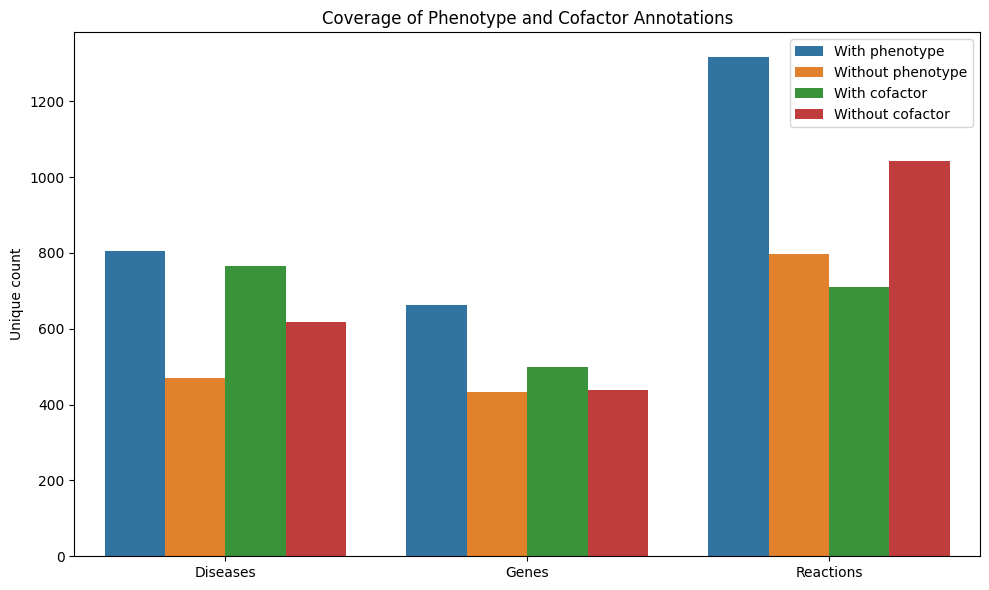

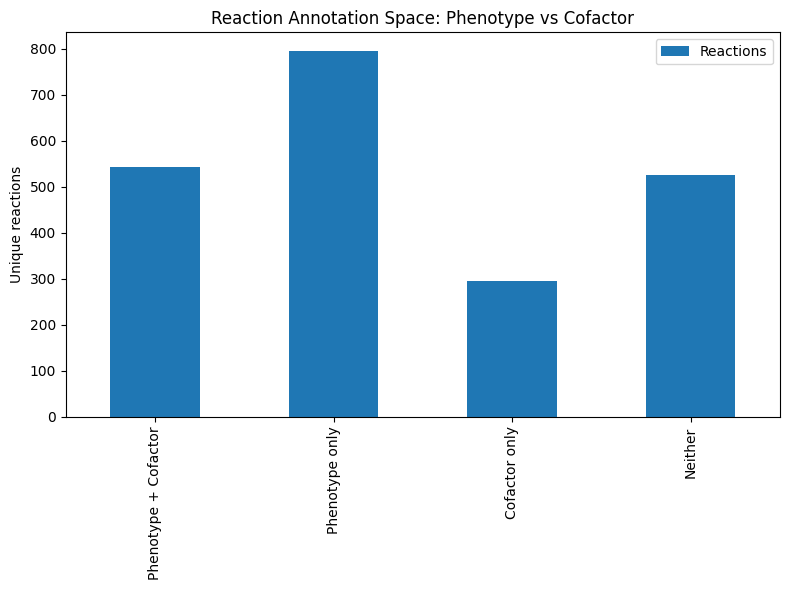

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# 1. Caricamento dataset
# =========================
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8")

# =========================
# 2. Flag logici
# =========================
df["has_phenotype"] = df["HPO_ID"].notna()
df["has_cofactor"] = df["Cofactor"].notna()

# =========================
# 3. Conteggi aggregati
# =========================
summary = pd.DataFrame({
    "Entity": ["Diseases", "Genes", "Reactions"],
    "With phenotype": [
        df.loc[df["has_phenotype"], "ORPHAcode"].nunique(),
        df.loc[df["has_phenotype"], "Gene"].nunique(),
        df.loc[df["has_phenotype"], "Rhea_ID"].nunique(),
    ],
    "Without phenotype": [
        df.loc[~df["has_phenotype"], "ORPHAcode"].nunique(),
        df.loc[~df["has_phenotype"], "Gene"].nunique(),
        df.loc[~df["has_phenotype"], "Rhea_ID"].nunique(),
    ],
    "With cofactor": [
        df.loc[df["has_cofactor"], "ORPHAcode"].nunique(),
        df.loc[df["has_cofactor"], "Gene"].nunique(),
        df.loc[df["has_cofactor"], "Rhea_ID"].nunique(),
    ],
    "Without cofactor": [
        df.loc[~df["has_cofactor"], "ORPHAcode"].nunique(),
        df.loc[~df["has_cofactor"], "Gene"].nunique(),
        df.loc[~df["has_cofactor"], "Rhea_ID"].nunique(),
    ]
})

# =========================
# 4. BARPLOT – Copertura
# =========================
summary_melted = summary.melt(
    id_vars="Entity",
    value_vars=["With phenotype", "Without phenotype", "With cofactor", "Without cofactor"],
    var_name="Annotation",
    value_name="Count"
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=summary_melted,
    x="Entity",
    y="Count",
    hue="Annotation"
)
plt.title("Coverage of Phenotype and Cofactor Annotations")
plt.ylabel("Unique count")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()

# =========================
# 5. STACKED BAR – Fenotipo × Cofattore (Reazioni)
# =========================
reaction_classes = pd.DataFrame({
    "Phenotype + Cofactor": df.loc[df["has_phenotype"] & df["has_cofactor"], "Rhea_ID"].nunique(),
    "Phenotype only": df.loc[df["has_phenotype"] & ~df["has_cofactor"], "Rhea_ID"].nunique(),
    "Cofactor only": df.loc[~df["has_phenotype"] & df["has_cofactor"], "Rhea_ID"].nunique(),
    "Neither": df.loc[~df["has_phenotype"] & ~df["has_cofactor"], "Rhea_ID"].nunique()
}, index=["Reactions"])

reaction_classes.T.plot(
    kind="bar",
    stacked=True,
    figsize=(8, 6)
)

plt.title("Reaction Annotation Space: Phenotype vs Cofactor")
plt.ylabel("Unique reactions")
plt.xlabel("")
plt.legend(title="")
plt.tight_layout()
plt.show()




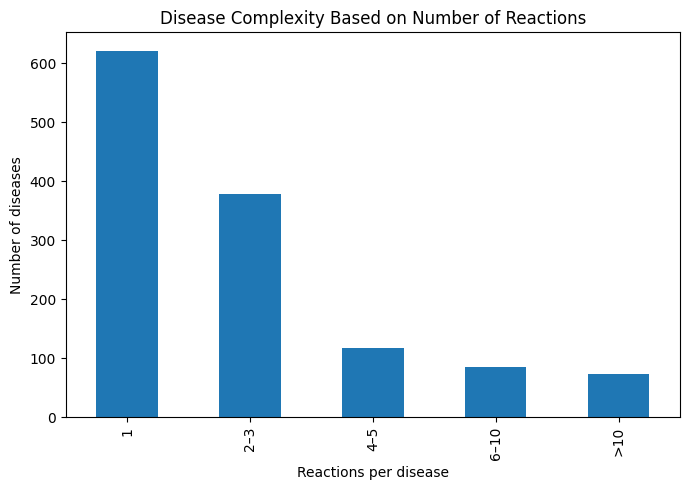

In [2]:
bins = [0, 1, 3, 5, 10, 100]
labels = ["1", "2–3", "4–5", "6–10", ">10"]

reaction_classes = pd.cut(reactions_per_disease, bins=bins, labels=labels)
class_counts = reaction_classes.value_counts().sort_index()

plt.figure(figsize=(7, 5))
class_counts.plot(kind="bar")
plt.title("Disease Complexity Based on Number of Reactions")
plt.ylabel("Number of diseases")
plt.xlabel("Reactions per disease")
plt.tight_layout()
plt.show()

#“Quante malattie sono semplici vs complesse”


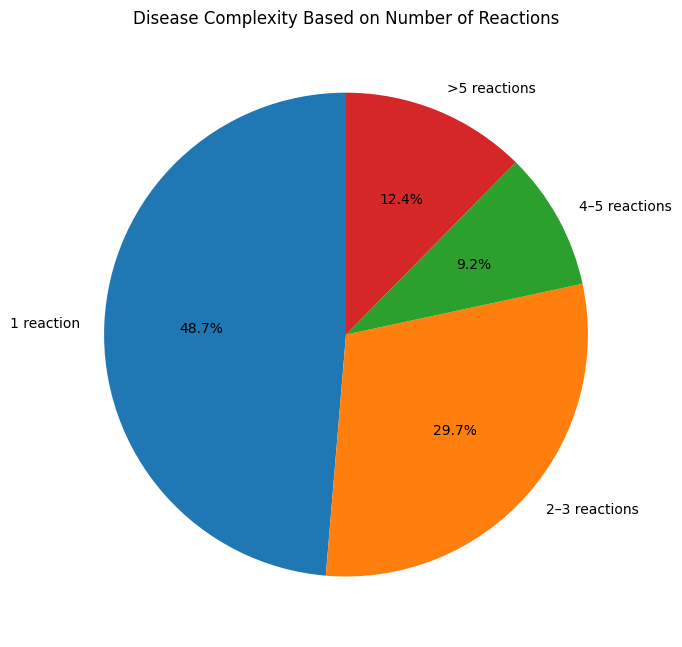

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# Caricamento dataset
# =========================
file_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
df = pd.read_csv(file_path, sep=";", encoding="utf-8")

# =========================
# Reazioni per malattia
# =========================
reactions_per_disease = (
    df[["ORPHAcode", "Rhea_ID"]]
    .dropna()
    .drop_duplicates()
    .groupby("ORPHAcode")
    .size()
)

# =========================
# Classi di complessità
# =========================
def classify(n):
    if n == 1:
        return "1 reaction"
    elif 2 <= n <= 3:
        return "2–3 reactions"
    elif 4 <= n <= 5:
        return "4–5 reactions"
    else:
        return ">5 reactions"

complexity_classes = reactions_per_disease.apply(classify)
class_counts = complexity_classes.value_counts().sort_index()

# =========================
# PIE CHART
# =========================
plt.figure(figsize=(7, 7))
plt.pie(
    class_counts,
    labels=class_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Disease Complexity Based on Number of Reactions")
plt.tight_layout()
plt.show()


#Most diseases are associated with a small number of biochemical reactions, 
#while a minority involves multiple reactions, highlighting a strongly skewed complexity landscape.


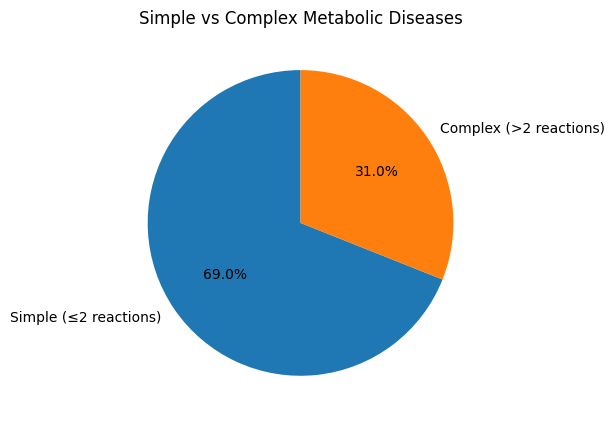

In [5]:
binary_class = reactions_per_disease.apply(
    lambda x: "Simple (≤2 reactions)" if x <= 2 else "Complex (>2 reactions)"
)

binary_counts = binary_class.value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    binary_counts,
    labels=binary_counts.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Simple vs Complex Metabolic Diseases")
plt.tight_layout()
plt.show()


In [ ]:
#  fino qui sopra è giusto

In [57]:
# ============================================================
# Gestione colonne Gene_primary e Gene_aliases
# ============================================================

import pandas as pd
from pathlib import Path
import re

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_gene_ec_rhea_long.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

# Manteniamo solo le colonne necessarie
df = df[["Entry", "Gene Names", "EC number", "Rhea ID"]]

print("📊 Dataset caricato:", len(df), "righe")

# ============================================================
# FUNZIONI DI PARSING
# ============================================================

def split_gene_names(gene_names):
    """
    'HFM1 SEC3D1' ->
        Gene_primary = 'HFM1'
        Gene_aliases = 'SEC3D1'
    """
    if pd.isna(gene_names):
        return None, None

    tokens = gene_names.split()
    primary = tokens[0]
    aliases = ";".join(tokens[1:]) if len(tokens) > 1 else None

    return primary, aliases


def split_ec(ec_field):
    """
    '2.7.1.137; 2.7.1.153' -> ['2.7.1.137','2.7.1.153']
    """
    if pd.isna(ec_field):
        return []
    return [ec.strip() for ec in re.split(r"[;,]", str(ec_field)) if ec.strip()]


def split_rhea(rhea_field):
    """
    'RHEA:12456 RHEA:53872' -> ['RHEA:12456','RHEA:53872']
    """
    if pd.isna(rhea_field):
        return []
    return re.findall(r"RHEA:\d+", str(rhea_field))


# ============================================================
# NORMALIZZAZIONE (LONG FORMAT)
# ============================================================

rows = []

for _, row in df.iterrows():

    entry = row["Entry"]

    gene_primary, gene_aliases = split_gene_names(row["Gene Names"])
    ecs   = split_ec(row["EC number"])
    rheas = split_rhea(row["Rhea ID"])

    for ec in ecs:
        for rhea in rheas:
            rows.append({
                "Gene_primary": gene_primary,
                "Gene_aliases": gene_aliases,
                "Entry": entry,
                "EC": ec,
                "Rhea_ID": rhea
            })

out = pd.DataFrame(rows)

# ============================================================
# CLEAN FINALE
# ============================================================

out = out.dropna(subset=["Gene_primary", "EC", "Rhea_ID"])
out = out.drop_duplicates()

# ============================================================
# SAVE
# ============================================================

out.to_csv(OUTPUT_FILE, index=False)

print("✅ Dataset normalizzato creato con successo")
print("📄 File:", OUTPUT_FILE)

print("\n🔎 Prime 10 righe:")
print(out.head(10))

print("\n📊 Statistiche finali")
print("Righe totali:", len(out))
print("Geni primari unici:", out["Gene_primary"].nunique())
print("EC unici:", out["EC"].nunique())
print("Rhea unici:", out["Rhea_ID"].nunique())


📊 Dataset caricato: 1125 righe
✅ Dataset normalizzato creato con successo
📄 File: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_gene_ec_rhea_long.csv

🔎 Prime 10 righe:
  Gene_primary Gene_aliases   Entry         EC     Rhea_ID
0         HFM1       SEC3D1  A2PYH4    5.6.2.4  RHEA:13065
1        CRPPA         ISPD  A4D126   2.7.7.40  RHEA:12456
2        CRPPA         ISPD  A4D126   2.7.7.40  RHEA:53872
3        CRPPA         ISPD  A4D126   2.7.7.40  RHEA:53612
4        LIPT2         None  A6NK58  2.3.1.181  RHEA:17665
5        HACD1        PTPLA  B0YJ81  4.2.1.134  RHEA:45812
6        HACD1        PTPLA  B0YJ81  4.2.1.134  RHEA:39159
7        HACD1        PTPLA  B0YJ81  4.2.1.134  RHEA:39155
8        HACD1        PTPLA  B0YJ81  4.2.1.134  RHEA:39175
9        HACD1        PTPLA  B0YJ81  4.2.1.134  RHEA:39187

📊 Statistiche finali
Righe totali: 4656
Geni primari unici: 1125
EC unici: 769
Rhea unici: 1934


In [7]:
# mergere il file orphanet e uniprot_gene_ec_rhea_long.csv
import pandas as pd
import os

# --- DEFINIZIONE PERCORSI ---
file_orphanet_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_disease_gene_hpo.csv"
file_uniprot_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_gene_ec_rhea_long.csv"
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_merged.csv"

print("Caricamento dei file in corso...")

try:
    # 1. Carica i file CSV
    # low_memory=False aiuta se i file sono grandi e misti
    df_orphanet = pd.read_csv(file_orphanet_path, low_memory=False)
    df_uniprot = pd.read_csv(file_uniprot_path, low_memory=False)

    print(f"Righe Orphanet caricate: {len(df_orphanet)}")
    print(f"Righe UniProt caricate: {len(df_uniprot)}")

    # --- PULIZIA E PREPARAZIONE CHIAVI ---
    
    # Per essere sicuri che il merge funzioni, convertiamo i nomi dei geni 
    # in stringhe, togliamo gli spazi e li mettiamo in MAIUSCOLO.
    # Questo evita che "Gba" non venga riconosciuto uguale a "GBA".
    
    # Pulizia Orphanet (Colonna 'Gene')
    df_orphanet['Gene_clean'] = df_orphanet['Gene'].astype(str).str.strip().str.upper()
    
    # Pulizia UniProt (Colonna 'Gene_primary')
    df_uniprot['Gene_primary_clean'] = df_uniprot['Gene_primary'].astype(str).str.strip().str.upper()

    # --- MERGE ---
    
    print("Esecuzione del merge basato sul Gene...")
    
    # Eseguiamo un LEFT JOIN:
    # Manteniamo tutte le malattie/geni di Orphanet.
    # Se troviamo il gene in UniProt, aggiungiamo le info (EC, Rhea, Entry).
    # left_on -> colonna pulita di Orphanet
    # right_on -> colonna pulita di UniProt
    df_merged = pd.merge(
        df_orphanet, 
        df_uniprot, 
        left_on='Gene_clean', 
        right_on='Gene_primary_clean', 
        how='left'
    )
    
    # --- PULIZIA FINALE ---
    
    # Rimuoviamo le colonne temporanee create per la pulizia ('Gene_clean', 'Gene_primary_clean')
    df_merged.drop(columns=['Gene_clean', 'Gene_primary_clean'], inplace=True)
    
    # Opzionale: Se vuoi mettere le righe con corrispondenze trovate in alto
    # Ordiniamo mettendo prima chi ha un valore in 'Entry' (o Rhea_ID) e poi i vuoti
    print("Ordinamento: corrispondenze trovate in alto...")
    mask_found = df_merged['Entry'].notna()
    df_merged = pd.concat([df_merged[mask_found], df_merged[~mask_found]])

    # --- SALVATAGGIO ---
    
    print(f"Salvataggio del file unito in: {output_path}")
    df_merged.to_csv(output_path, index=False)
    
    print(f"Fatto! File salvato. Righe totali finali: {len(df_merged)}")

except FileNotFoundError as e:
    print(f"ERRORE: Uno dei file non è stato trovato.\n{e}")
except KeyError as e:
    print(f"ERRORE: Una delle colonne specificate non esiste nel file.\n{e}")
except Exception as e:
    print(f"Si è verificato un errore generico: {e}")

Caricamento dei file in corso...
Righe Orphanet caricate: 175895
Righe UniProt caricate: 4656
Esecuzione del merge basato sul Gene...
Ordinamento: corrispondenze trovate in alto...
Salvataggio del file unito in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_merged.csv
Fatto! File salvato. Righe totali finali: 267750


In [8]:
# analisi statistici 
import pandas as pd

# --- DEFINIZIONE PERCORSI ---
# Usiamo il file generato nello step precedente
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_merged.csv"
# Nome del file finale pulito
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_stats.csv"

print("Caricamento del file...")
try:
    df = pd.read_csv(input_file, low_memory=False)
    
    # --- 1. RIMOZIONE COLONNA FREQUENCY ---
    if 'Frequency' in df.columns:
        print("Rimozione della colonna 'Frequency'...")
        df.drop(columns=['Frequency'], inplace=True)
    else:
        print("La colonna 'Frequency' non è presente.")

    # --- 2. CALCOLO STATISTICHE ---
    
    # Definiamo la maschera per le righe "In Comune"
    # Una riga è in comune se ha trovato un match in UniProt (quindi 'Entry' non è vuoto)
    mask_common = df['Entry'].notna()
    
    # a. Totale Geni Unici nel file (Colonna Gene di Orphanet)
    total_genes_unique = df['Gene'].nunique()
    
    # b. Geni Unici in Comune (Geni Orphanet che hanno un match in UniProt)
    common_genes_unique = df.loc[mask_common, 'Gene'].nunique()
    
    # c. ORPHAcode in Comune (Codici malattia associati a geni che hanno match)
    common_orphacodes_unique = df.loc[mask_common, 'ORPHAcode'].nunique()
    
    # d. Rhea ID in totale nel file (Contiamo gli ID unici non nulli)
    total_rhea_unique = df['Rhea_ID'].nunique()
    
    # e. HPO_ID in Comune
    common_hpo_id_unique = df.loc[mask_common, 'HPO_ID'].nunique()
    
    # f. HPO_Label in Comune
    common_hpo_label_unique = df.loc[mask_common, 'HPO_Label'].nunique()

    # --- 3. STAMPA DEI RISULTATI ---
    print("-" * 40)
    print("      STATISTICHE DEL FILE FINALE")
    print("-" * 40)
    print(f"1. Geni unici totali (Orphanet):      {total_genes_unique}")
    print(f"2. Geni unici IN COMUNE (con UniProt):{common_genes_unique}")
    print(f"3. ORPHAcode unici IN COMUNE:         {common_orphacodes_unique}")
    print(f"4. Rhea ID unici totali trovati:      {total_rhea_unique}")
    print(f"5. HPO_ID unici IN COMUNE:            {common_hpo_id_unique}")
    print(f"6. HPO_Label unici IN COMUNE:         {common_hpo_label_unique}")
    print("-" * 40)

    # --- 4. SALVATAGGIO ---
    print(f"Salvataggio del file finale in: {output_file}")
    df.to_csv(output_file, index=False)
    print("Operazione completata.")

except FileNotFoundError:
    print(f"Errore: Non trovo il file {input_file}. Assicurati di aver eseguito lo step precedente.")
except Exception as e:
    print(f"Errore generico: {e}")

Caricamento del file...
Rimozione della colonna 'Frequency'...
----------------------------------------
      STATISTICHE DEL FILE FINALE
----------------------------------------
1. Geni unici totali (Orphanet):      4552
2. Geni unici IN COMUNE (con UniProt):926
3. ORPHAcode unici IN COMUNE:         1276
4. Rhea ID unici totali trovati:      1696
5. HPO_ID unici IN COMUNE:            4744
6. HPO_Label unici IN COMUNE:         4744
----------------------------------------
Salvataggio del file finale in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_stats.csv
Operazione completata.


In [9]:
# extract solo enzimi comune con orphan
import pandas as pd

# --- DEFINIZIONE PERCORSI ---
# File di input (quello unito creato nello step precedente)
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_stats.csv"

# File di output (solo le righe "In Comune")
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_common_only.csv"

print("Caricamento del file completo...")
try:
    df = pd.read_csv(input_file, low_memory=False)
    
    # --- 1. FILTRAGGIO ---
    # Vogliamo solo i geni che sono "IN COMUNE".
    # Poiché abbiamo fatto un Left Join su Orphanet, le righe in comune sono quelle
    # dove le colonne di UniProt (come 'Entry' o 'Rhea_ID') NON sono vuote.
    
    print("Filtraggio delle righe (solo Geni con corrispondenza UniProt/Rhea)...")
    
    # dropna(subset=['Entry']) elimina le righe dove 'Entry' è NaN (vuoto)
    df_common = df.dropna(subset=['Entry']).copy()
    
    # --- 2. ANALISI STATISTICHE SUL DATASET FILTRATO ---
    
    unique_genes = df_common['Gene'].nunique()
    unique_orphacodes = df_common['ORPHAcode'].nunique()
    unique_rhea = df_common['Rhea_ID'].nunique()
    unique_hpo_id = df_common['HPO_ID'].nunique()
    unique_hpo_label = df_common['HPO_Label'].nunique()
    
    # Calcolo anche quante righe totali sono rimaste
    total_rows = len(df_common)

    print("-" * 50)
    print("      STATISTICHE DATASET FILTRATO (SOLO COMUNI)")
    print("-" * 50)
    print(f"Righe totali (Malattia-Gene-Reazione): {total_rows}")
    print(f"Geni Unici (Enzimi):                   {unique_genes}")
    print(f"ORPHAcode Unici (Malattie):            {unique_orphacodes}")
    print(f"Rhea ID Unici (Reazioni):              {unique_rhea}")
    print(f"HPO ID Unici (Fenotipi):               {unique_hpo_id}")
    print(f"HPO Label Uniche:                      {unique_hpo_label}")
    print("-" * 50)

    # --- 3. SALVATAGGIO ---
    print(f"Salvataggio del file filtrato in: {output_file}")
    df_common.to_csv(output_file, index=False)
    print("Fatto.")

except FileNotFoundError:
    print(f"Errore: Il file {input_file} non esiste. Controlla il percorso.")
except Exception as e:
    print(f"Errore generico: {e}")

Caricamento del file completo...
Filtraggio delle righe (solo Geni con corrispondenza UniProt/Rhea)...
--------------------------------------------------
      STATISTICHE DATASET FILTRATO (SOLO COMUNI)
--------------------------------------------------
Righe totali (Malattia-Gene-Reazione): 127096
Geni Unici (Enzimi):                   926
ORPHAcode Unici (Malattie):            1276
Rhea ID Unici (Reazioni):              1696
HPO ID Unici (Fenotipi):               4744
HPO Label Uniche:                      4744
--------------------------------------------------
Salvataggio del file filtrato in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_common_only.csv
Fatto.


In [10]:
#togliere la colonna gene gene_aliases

import pandas as pd

# --- DEFINIZIONE PERCORSI ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_stats.csv"
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_common_only.csv"

print("Caricamento del file completo...")
try:
    df = pd.read_csv(input_file, low_memory=False)
    
    # --- 1. FILTRAGGIO ---
    # Manteniamo solo le righe che hanno una corrispondenza in UniProt (Entry non vuoto)
    print("Filtraggio delle righe (solo Geni con corrispondenza)...")
    df_common = df.dropna(subset=['Entry']).copy()
    
    # --- 2. RIMOZIONE COLONNA GENE_ALIASES ---
    if 'Gene_aliases' in df_common.columns:
        print("Rimozione della colonna 'Gene_aliases'...")
        df_common.drop(columns=['Gene_aliases'], inplace=True)
    else:
        print("La colonna 'Gene_aliases' non è presente.")

    # --- 3. ANALISI STATISTICHE SUL DATASET FILTRATO ---
    unique_genes = df_common['Gene'].nunique()
    unique_orphacodes = df_common['ORPHAcode'].nunique()
    unique_rhea = df_common['Rhea_ID'].nunique()
    unique_hpo_id = df_common['HPO_ID'].nunique()
    unique_hpo_label = df_common['HPO_Label'].nunique()
    
    total_rows = len(df_common)

    print("-" * 50)
    print("      STATISTICHE DATASET FINALE (SOLO COMUNI)")
    print("-" * 50)
    print(f"Righe totali:                          {total_rows}")
    print(f"Geni Unici (Enzimi):                   {unique_genes}")
    print(f"ORPHAcode Unici (Malattie):            {unique_orphacodes}")
    print(f"Rhea ID Unici (Reazioni):              {unique_rhea}")
    print(f"HPO ID Unici (Fenotipi):               {unique_hpo_id}")
    print(f"HPO Label Uniche:                      {unique_hpo_label}")
    print("-" * 50)

    # --- 4. SALVATAGGIO ---
    print(f"Salvataggio del file filtrato in: {output_file}")
    df_common.to_csv(output_file, index=False)
    print("Fatto.")

except FileNotFoundError:
    print(f"Errore: Il file {input_file} non esiste. Controlla il percorso.")
except Exception as e:
    print(f"Errore generico: {e}")

Caricamento del file completo...
Filtraggio delle righe (solo Geni con corrispondenza)...
Rimozione della colonna 'Gene_aliases'...
--------------------------------------------------
      STATISTICHE DATASET FINALE (SOLO COMUNI)
--------------------------------------------------
Righe totali:                          127096
Geni Unici (Enzimi):                   926
ORPHAcode Unici (Malattie):            1276
Rhea ID Unici (Reazioni):              1696
HPO ID Unici (Fenotipi):               4744
HPO Label Uniche:                      4744
--------------------------------------------------
Salvataggio del file filtrato in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_common_only.csv
Fatto.


In [11]:
# filtrare e reordinare il file orphanet_uniprot_common_only.csv"
import pandas as pd

# --- DEFINIZIONE PERCORSI ---
# File di input (quello generato nello step precedente)
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_common_only.csv"
# File di output (sovrascriviamo o ne creiamo uno nuovo "strutturato")
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_structure.csv"

print("Caricamento del file...")
try:
    df = pd.read_csv(input_file, low_memory=False)
    
    # --- 1. RIMOZIONE COLONNA Gene_primary ---
    if 'Gene_primary' in df.columns:
        print("Rimozione della colonna 'Gene_primary'...")
        df.drop(columns=['Gene_primary'], inplace=True)
    else:
        print("La colonna 'Gene_primary' non era presente.")

    # --- 2. RIORGANIZZAZIONE DELLE COLONNE ---
    # L'obiettivo è avere: ... Gene, Entry, EC, Rhea_ID, ... (il resto)
    
    print("Riordinamento colonne...")
    
    # Colonne che vogliamo spostare in posizione specifica
    cols_priority = ['Gene', 'Entry', 'EC', 'Rhea_ID']
    
    # Verifica che esistano tutte nel dataframe
    existing_priority = [c for c in cols_priority if c in df.columns]
    
    # Colonne rimanenti (tutte le altre, escluse quelle prioritarie)
    cols_rest = [c for c in df.columns if c not in existing_priority]
    
    # Troviamo l'indice dove inserire il blocco. 
    # Idealmente 'Gene' è già lì, ma se vogliamo forzare l'ordine:
    # Mettiamo prima le colonne che stavano PRIMA di Gene (es. ORPHAcode, DiseaseName),
    # poi il blocco [Gene, Entry, EC, Rhea], poi il resto (es. HPO stuff).
    
    # Strategia sicura:
    # 1. Prendiamo tutte le colonne fino a 'Gene' (escluso)
    # 2. Aggiungiamo il blocco [Gene, Entry, EC, Rhea]
    # 3. Aggiungiamo il resto
    
    if 'Gene' in df.columns:
        # Troviamo l'indice numerico della colonna Gene originale per capire cosa c'era prima
        gene_index = df.columns.get_loc('Gene')
        
        # Colonne prima di Gene
        # Nota: dobbiamo filtrare per non riprendere Entry/EC/Rhea se per caso erano prima
        cols_before = [c for c in df.columns[:gene_index] if c not in existing_priority]
        
        # Colonne dopo Gene
        cols_after = [c for c in df.columns[gene_index+1:] if c not in existing_priority]
        
        # Ordine finale
        new_order = cols_before + existing_priority + cols_after
        
        # Applichiamo il nuovo ordine
        df = df[new_order]
    else:
        print("Attenzione: Colonna 'Gene' non trovata. Riordino le altre in cima.")
        # Se Gene non c'è, mettiamo comunque Entry, EC, Rhea all'inizio o dopo le prime colonne ID
        cols_rest = [c for c in df.columns if c not in existing_priority]
        df = df[existing_priority + cols_rest]

    # --- 3. SALVATAGGIO ---
    print(f"Salvataggio del file riordinato in: {output_file}")
    df.to_csv(output_file, index=False)
    print("Operazione completata con successo.")

except FileNotFoundError:
    print(f"Errore: Il file {input_file} non esiste.")
except Exception as e:
    print(f"Errore generico: {e}")

Caricamento del file...
Rimozione della colonna 'Gene_primary'...
Riordinamento colonne...
Salvataggio del file riordinato in: C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_structure.csv
Operazione completata con successo.


In [ ]:
# fino qui sopra è giusto

In [78]:
# da tohliere

# da togliere 2 colonne di chebi sbagliati dal file uniprot_catalytic_reactions_long.csv"

import pandas as pd
import re
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprotkb_metabolic_enzymes_disease_FINAL_reordered.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)
print("📊 File caricato:", len(df), "righe")

# ============================================================
# REGEX
# ============================================================

RE_BLOCK = re.compile(
    r"CATALYTIC ACTIVITY:\s*(.+?)(?=CATALYTIC ACTIVITY:|$)",
    re.DOTALL
)
RE_REACTION = re.compile(r"Reaction=([^;]+)")
RE_RHEA = re.compile(r"Rhea:(RHEA:\d+)")
RE_EC = re.compile(r"EC=([\d\.]+)")
RE_DIRECTION = re.compile(r"PhysiologicalDirection=([^;]+)")
RE_CHEBI = re.compile(r"ChEBI:(CHEBI:\d+)")

# ============================================================
# PARSING
# ============================================================

rows = []

for _, row in df.iterrows():

    catalytic = row.get("Catalytic activity")
    if pd.isna(catalytic):
        continue

    blocks = RE_BLOCK.findall(catalytic)

    for block in blocks:

        reaction_m = RE_REACTION.search(block)
        rhea_m = RE_RHEA.search(block)

        if not reaction_m or not rhea_m:
            continue

        reaction = reaction_m.group(1).strip()
        rhea_id = rhea_m.group(1)

        ec_list = RE_EC.findall(block)
        ec = ";".join(dict.fromkeys(ec_list)) if ec_list else None

        direction_m = RE_DIRECTION.search(block)
        direction = direction_m.group(1) if direction_m else None

        # ----------------------------------------------------
        # Split reaction
        # ----------------------------------------------------
        if "=" not in reaction:
            continue

        left, right = reaction.split("=", 1)

        substrates = [x.strip() for x in left.split("+")]
        n_sub = len(substrates)

        # ----------------------------------------------------
        # ChEBI ORDINATI SECONDO LOGICA UNIPROT
        # ----------------------------------------------------
        chebis = RE_CHEBI.findall(block)

        chebi_substrates = chebis[-n_sub:] if n_sub > 0 else []
        chebi_products = chebis[:-n_sub] if n_sub > 0 else chebis
        chebi_products = list(reversed(chebi_products))

        # ----------------------------------------------------
        # SAVE ROW
        # ----------------------------------------------------
        rows.append({
            "Rhea_ID": rhea_id,
            "Reaction": reaction,
            "ChEBI_substrate": ";".join(chebi_substrates),
            "ChEBI_product": ";".join(chebi_products),
            "EC": ec,
            "PhysiologicalDirection": direction
        })

# ============================================================
# DATAFRAME FINALE
# ============================================================

out = pd.DataFrame(rows).drop_duplicates()

# ============================================================
# SAVE
# ============================================================

out.to_csv(OUTPUT_FILE, index=False)

print("✅ File reazioni catalitiche creato correttamente")
print("📄 Output:", OUTPUT_FILE)

print("\n🔎 Prime 5 righe:")
print(out.head())

print("\n📊 Statistiche")
print("Reazioni totali:", len(out))
print("Rhea unici:", out["Rhea_ID"].nunique())
print("EC unici:", out["EC"].nunique())


📊 File caricato: 1125 righe
✅ File reazioni catalitiche creato correttamente
📄 Output: C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long.csv

🔎 Prime 5 righe:
      Rhea_ID                                           Reaction  \
0  RHEA:13065                 ATP + H2O = ADP + phosphate + H(+)   
1  RHEA:12456  D-ribitol 5-phosphate + CTP + H(+) = CDP-L-rib...   
2  RHEA:53872  D-ribose 5-phosphate + CTP + H(+) = CDP-D-ribo...   
3  RHEA:53612  D-ribulose 5-phosphate + CTP + H(+) = CDP-D-ri...   
4  RHEA:17665  octanoyl-[ACP] + L-lysyl-[protein] = N(6)-octa...   

                                    ChEBI_substrate  \
0                          CHEBI:43474;CHEBI:456216   
1   CHEBI:33019;CHEBI:37563;CHEBI:57608;CHEBI:57695   
2  CHEBI:33019;CHEBI:37563;CHEBI:78346;CHEBI:137525   
3  CHEBI:33019;CHEBI:37563;CHEBI:58121;CHEBI:137524   
4                           CHEBI:78463;CHEBI:78809   

                         ChEBI_product         EC PhysiologicalDirection  
0  CH

In [3]:
# da tolgiere

# togliere le colonne sbagliati di chebi
import pandas as pd
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long.csv"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long_no_chebi.csv"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_csv(INPUT_FILE)

print("📊 File caricato")
print("Righe:", len(df))
print("Colonne iniziali:", list(df.columns))
print("-" * 50)

# ============================================================
# DROP COLONNE ChEBI
# ============================================================

cols_to_drop = ["ChEBI_substrate", "ChEBI_product"]
df = df.drop(columns=[c for c in cols_to_drop if c in df.columns])

print("✅ Colonne rimosse:", cols_to_drop)
print("Colonne finali:", list(df.columns))
print("-" * 50)

# ============================================================
# SAVE
# ============================================================

df.to_csv(OUTPUT_FILE, index=False)

print("💾 File salvato correttamente:")
print(OUTPUT_FILE)


📊 File caricato
Righe: 2105
Colonne iniziali: ['Rhea_ID', 'Reaction', 'ChEBI_substrate', 'ChEBI_product', 'EC', 'PhysiologicalDirection']
--------------------------------------------------
✅ Colonne rimosse: ['ChEBI_substrate', 'ChEBI_product']
Colonne finali: ['Rhea_ID', 'Reaction', 'EC', 'PhysiologicalDirection']
--------------------------------------------------
💾 File salvato correttamente:
C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long_no_chebi.csv


In [85]:
%pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [2]:
# gisuto , questo file è esterno
# elaborare il file esterno metaboliti_chebi. per avere chebi substrat e prodotto 

import pandas as pd
import re

# Definisci il percorso del file
file_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi.xlsx'
output_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato.xlsx'

def process_reaction(row):
    """
    Funzione per analizzare la riga, contare i reagenti/prodotti
    e dividere gli identificatori ChEBI.
    """
    equation = str(row['Equation'])
    chebi_ids_str = str(row['ChEBI identifier'])
    
    # 1. Pulizia e Parsing dell'Equazione
    match = re.search(r'\s(<=>|=|->)\s', equation)
    
    if not match:
        return pd.Series([None, None]) 
        
    separator = match.group(0)
    parts = equation.split(separator)
    
    if len(parts) != 2:
        return pd.Series([None, None])
        
    left_side = parts[0]
    right_side = parts[1]
    
    # Contiamo gli elementi basandoci sul separatore " + "
    num_left = len(left_side.split(' + '))
    num_right = len(right_side.split(' + '))
    
    # 2. Parsing dei ChEBI ID
    chebi_list = [x for x in re.split(r'[;\s]+', chebi_ids_str) if x]
    
    total_elements = num_left + num_right
    
    if len(chebi_list) != total_elements:
        pass 

    # 3. Assegnazione colonne
    if len(chebi_list) >= num_left:
        chebi_substruct = ";".join(chebi_list[:num_left])
        chebi_product = ";".join(chebi_list[num_left:])
    else:
        chebi_substruct = "ERROR_COUNT_MISMATCH"
        chebi_product = "ERROR_COUNT_MISMATCH"
        
    return pd.Series([chebi_substruct, chebi_product])

# --- ESECUZIONE ---

print("Lettura del file Excel in corso...")
try:
    df = pd.read_excel(file_path)
    
    print("Elaborazione delle reazioni...")
    # Applichiamo la funzione e creiamo le due nuove colonne
    df[['ChEBI substruct', 'ChEBI product']] = df.apply(process_reaction, axis=1)
    
    print("Riorganizzazione delle colonne...")
    
    # 1. Rimuoviamo la colonna originale 'ChEBI identifier'
    if 'ChEBI identifier' in df.columns:
        df = df.drop(columns=['ChEBI identifier'])
    
    # 2. Spostiamo 'EC number' alla fine
    # Creiamo una lista con tutte le colonne tranne 'EC number'
    cols = [c for c in df.columns if c != 'EC number']
    # Aggiungiamo 'EC number' alla fine della lista
    cols.append('EC number')
    # Riapplichiamo l'ordine al dataframe
    df = df[cols]

    print(f"Salvataggio del file in: {output_path}")
    df.to_excel(output_path, index=False)
    
    print("Fatto! Controllo completato.")

except FileNotFoundError:
    print(f"Errore: Il file non è stato trovato al percorso: {file_path}")
except Exception as e:
    print(f"Si è verificato un errore generico: {e}")

Lettura del file Excel in corso...
Elaborazione delle reazioni...
Riorganizzazione delle colonne...
Salvataggio del file in: C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato.xlsx
Fatto! Controllo completato.


In [4]:
#giusto questo file è esterno
# renomenare le colonne 
import pandas as pd
from pathlib import Path

# ============================================================
# PATH
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato.xlsx"
)

OUTPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato_renamed.xlsx"
)

# ============================================================
# LOAD
# ============================================================

df = pd.read_excel(INPUT_FILE)

print("📊 File caricato")
print("Colonne originali:")
print(list(df.columns))
print("-" * 50)

# ============================================================
# RENAME COLUMNS
# ============================================================

df = df.rename(columns={
    "Reaction identifier": "Rhea_ID",
    "Equation": "Reaction",
    "EC number": "EC"
})

print("✅ Colonne rinominate")
print("Colonne finali:")
print(list(df.columns))
print("-" * 50)

# ============================================================
# SAVE
# ============================================================

df.to_excel(OUTPUT_FILE, index=False)

print("💾 File salvato correttamente:")
print(OUTPUT_FILE)


📊 File caricato
Colonne originali:
['Reaction identifier', 'Equation', 'ChEBI substruct', 'ChEBI product', 'EC number']
--------------------------------------------------
✅ Colonne rinominate
Colonne finali:
['Rhea_ID', 'Reaction', 'ChEBI substruct', 'ChEBI product', 'EC']
--------------------------------------------------
💾 File salvato correttamente:
C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato_renamed.xlsx


In [12]:
# mergere orphanet_uniprot_final_structure.csv e metaboliti_chebi_elaborato_renamed.xlsx
import pandas as pd

# --- DEFINIZIONE PERCORSI ---
file_orphanet_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\orphanet_uniprot_final_structure.csv"
file_chebi_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\metaboliti_chebi_elaborato_renamed.xlsx"
output_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv"

print("Caricamento dei file...")
try:
    # 1. Carica i file
    df_orphanet = pd.read_csv(file_orphanet_path, low_memory=False)
    df_chebi = pd.read_excel(file_chebi_path)

    # --- PULIZIA E PREPARAZIONE CHIAVI ---
    
    # Assicuriamoci che la colonna chiave si chiami 'Rhea_ID' nel file Excel
    if 'Reaction identifier' in df_chebi.columns and 'Rhea_ID' not in df_chebi.columns:
        print("Rinomino 'Reaction identifier' in 'Rhea_ID' nel file Excel...")
        df_chebi.rename(columns={'Reaction identifier': 'Rhea_ID'}, inplace=True)

    # Standardizzazione della chiave Rhea_ID (stringa e senza spazi)
    df_orphanet['Rhea_ID'] = df_orphanet['Rhea_ID'].astype(str).str.strip()
    df_chebi['Rhea_ID'] = df_chebi['Rhea_ID'].astype(str).str.strip()

    # --- PREPARAZIONE DATI DA UNIRE ---
    
    # Dal file Excel ci servono: Rhea_ID, Equation (da rinominare Reaction), Substruct, Product
    # Verifichiamo se la colonna si chiama 'Equation'
    if 'Equation' in df_chebi.columns:
        df_chebi.rename(columns={'Equation': 'Reaction'}, inplace=True)
    
    cols_to_add = ['Rhea_ID', 'Reaction', 'ChEBI substruct', 'ChEBI product']
    
    # Filtriamo solo le colonne che esistono davvero per evitare errori
    available_cols = [c for c in cols_to_add if c in df_chebi.columns]
    df_chebi_subset = df_chebi[available_cols]

    # --- MERGE ---
    
    print("Esecuzione del merge basato su Rhea_ID...")
    df_merged = pd.merge(df_orphanet, df_chebi_subset, on='Rhea_ID', how='left')

    # --- ORDINAMENTO COLONNE ---
    
    print("Riordinamento delle colonne secondo specifica...")
    
    # Lista desiderata
    desired_order = [
        'ORPHAcode', 
        'DiseaseName', 
        'Gene', 
        'Entry', 
        'Rhea_ID', 
        'Reaction', 
        'EC', 
        'ChEBI substruct', 
        'ChEBI product', 
        'HPO_ID', 
        'HPO_Label'
    ]
    
    # 1. Prendiamo le colonne desiderate che sono effettivamente presenti nel dataframe
    final_cols = [c for c in desired_order if c in df_merged.columns]
    
    # 2. Se ci sono altre colonne extra nel file (es. colonne di servizio), le mettiamo in fondo
    remaining_cols = [c for c in df_merged.columns if c not in final_cols]
    
    # 3. Creiamo il dataframe finale ordinato
    df_final = df_merged[final_cols + remaining_cols]

    # --- SALVATAGGIO ---
    
    print(f"Salvataggio del file finale in: {output_path}")
    df_final.to_csv(output_path, index=False)
    
    print("-" * 40)
    print("OPERAZIONE COMPLETATA")
    print("-" * 40)
    print(f"File salvato: {output_path}")
    print(f"Righe totali: {len(df_final)}")
    print("Colonne finali:", list(df_final.columns))

except FileNotFoundError as e:
    print(f"ERRORE DI PERCORSO: {e}")
except Exception as e:
    print(f"ERRORE GENERICO: {e}")

Caricamento dei file...
Esecuzione del merge basato su Rhea_ID...
Riordinamento delle colonne secondo specifica...
Salvataggio del file finale in: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv
----------------------------------------
OPERAZIONE COMPLETATA
----------------------------------------
File salvato: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv
Righe totali: 127096
Colonne finali: ['ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'ChEBI substruct', 'ChEBI product', 'HPO_ID', 'HPO_Label']


In [13]:
# analisi statistica : 
import pandas as pd

# --- PERCORSO FILE ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv"
output_report = r"C:\Users\biofa\Desktop\DATAEXTRACTION\report_statistico.txt"

print("Caricamento del dataset finale...")
df = pd.read_csv(input_file, low_memory=False)

# Funzione per stampare sia a video che su file
def log_print(message, file_obj):
    print(message)
    file_obj.write(message + "\n")

print(f"Dataset caricato: {len(df)} righe.")
print("Calcolo delle statistiche in corso...\n")

with open(output_report, "w", encoding="utf-8") as f:
    
    # --- 1. CONTEGGI GENERALI (Cardinalità) ---
    log_print("="*50, f)
    log_print("1. PANORAMICA GENERALE (Entità Uniche)", f)
    log_print("="*50, f)
    
    log_print(f"Malattie (ORPHAcode):    {df['ORPHAcode'].nunique()}", f)
    log_print(f"Geni (Gene):             {df['Gene'].nunique()}", f)
    log_print(f"Proteine (Entry):        {df['Entry'].nunique()}", f)
    log_print(f"Reazioni (Rhea_ID):      {df['Rhea_ID'].nunique()}", f)
    log_print(f"Enzimi (EC):             {df['EC'].nunique()}", f)
    log_print(f"Fenotipi (HPO_ID):       {df['HPO_ID'].nunique()}", f)
    log_print("-" * 50, f)

    # --- 2. ANALISI DEI GENI ---
    # Quali geni sono associati a più righe (più fenotipi o più reazioni)?
    log_print("\n" + "="*50, f)
    log_print("2. TOP 10 GENI PIÙ FREQUENTI (Per numero di righe)", f)
    log_print("="*50, f)
    top_genes = df['Gene'].value_counts().head(10)
    log_print(top_genes.to_string(), f)
    
    # --- 3. ANALISI ENZIMATICA (EC Numbers) ---
    log_print("\n" + "="*50, f)
    log_print("3. TOP 10 CLASSI ENZIMATICHE (EC)", f)
    log_print("="*50, f)
    top_ec = df['EC'].value_counts().head(10)
    log_print(top_ec.to_string(), f)

    # --- 4. ANALISI DEI METABOLITI (ChEBI) ---
    # Qui avviene la magia: separiamo i metaboliti uniti da ";" e li contiamo singolarmente
    log_print("\n" + "="*50, f)
    log_print("4. ANALISI METABOLITI (ChEBI)", f)
    log_print("="*50, f)

    # Funzione helper per contare elementi in stringhe separate da ;
    def get_top_metabolites(column_name, n=10):
        # 1. Prende la colonna
        # 2. Converte in stringa e droppa i NaN
        # 3. Splitta per ";" ed esplode le liste in righe singole
        # 4. Conta i valori
        return df[column_name].dropna().astype(str).str.split(';').explode().value_counts().head(n)

    log_print("--- Top 10 SUBSTRATI (Reagenti) più comuni ---", f)
    top_subs = get_top_metabolites('ChEBI substruct')
    log_print(top_subs.to_string(), f)

    log_print("\n--- Top 10 PRODOTTI più comuni ---", f)
    top_prods = get_top_metabolites('ChEBI product')
    log_print(top_prods.to_string(), f)

    # --- 5. ANALISI MALATTIE ---
    # Quali malattie hanno il maggior numero di fenotipi o complessità nel dataset?
    log_print("\n" + "="*50, f)
    log_print("5. TOP 10 MALATTIE PER NUMERO DI ASSOCIAZIONI", f)
    log_print("(Indica malattie con molti fenotipi o molte reazioni varianti)", f)
    log_print("="*50, f)
    
    # Raggruppiamo per Nome Malattia per leggibilità
    top_diseases = df['DiseaseName'].value_counts().head(10)
    log_print(top_diseases.to_string(), f)

print(f"\nAnalisi completata!")
print(f"Un report dettagliato è stato salvato in: {output_report}")

Caricamento del dataset finale...
Dataset caricato: 127096 righe.
Calcolo delle statistiche in corso...

1. PANORAMICA GENERALE (Entità Uniche)
Malattie (ORPHAcode):    1276
Geni (Gene):             926
Proteine (Entry):        926
Reazioni (Rhea_ID):      1696
Enzimi (EC):             687
Fenotipi (HPO_ID):       4744
--------------------------------------------------

2. TOP 10 GENI PIÙ FREQUENTI (Per numero di righe)
HSD17B10    6804
PIK3CA      6255
PLA2G6      5040
PNPLA2      4896
HADHA       3024
POLG        2448
ENPP1       2224
CEL         1620
EHHADH      1620
CYP1B1      1548

3. TOP 10 CLASSI ENZIMATICHE (EC)
2.7.11.1     8653
3.1.1.4      4180
3.1.1.3      3132
2.7.1.153    2559
2.7.1.137    2559
3.1.1.5      2484
2.7.10.1     2398
1.1.1.35     1818
3.1.2.2      1713
4.2.1.17     1558

4. ANALISI METABOLITI (ChEBI)
--- Top 10 SUBSTRATI (Reagenti) più comuni ---
CHEBI:30616    18018
CHEBI:15377    14962
CHEBI:30013     5834
CHEBI:15378     4461
CHEBI:46858     3782
CHEBI:15

In [14]:
# analisi statistica
import pandas as pd

# --- PERCORSI ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv"
output_missing = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_chebi.csv"

print("Caricamento del dataset...")
df = pd.read_csv(input_file, low_memory=False)

# --- CALCOLI ---

# 1. Totale Righe
total_rows = len(df)

# 2. Righe con ChEBI (usiamo 'ChEBI substruct' come riferimento)
# .notna() significa "non è vuoto"
rows_with_chebi = df[df['ChEBI substruct'].notna()]
count_rows_with = len(rows_with_chebi)

# 3. Righe senza ChEBI
# .isna() significa "è vuoto/NaN"
rows_without_chebi = df[df['ChEBI substruct'].isna()]
count_rows_without = len(rows_without_chebi)

# --- CALCOLI SU RHEA ID UNIVOCI ---
# Questo è più importante per capire la qualità del database chimico

# Totale Rhea ID unici nel file
total_unique_rhea = df['Rhea_ID'].nunique()

# Rhea ID unici che HANNO trovato corrispondenza
unique_rhea_with = rows_with_chebi['Rhea_ID'].nunique()

# Rhea ID unici che NON HANNO trovato corrispondenza
unique_rhea_without = rows_without_chebi['Rhea_ID'].nunique()

# --- STAMPA DEL REPORT ---

print("-" * 50)
print("REPORT COPERTURA DATI CHIMICI (ChEBI)")
print("-" * 50)

print(f"\n--- ANALISI PER RIGHE (Associazioni Malattia-Gene-Reazione) ---")
print(f"TOTALE Righe nel file:            {total_rows}")
print(f"Righe CON dati ChEBI completi:    {count_rows_with} ({count_rows_with/total_rows:.1%})")
print(f"Righe SENZA dati ChEBI (Vuote):   {count_rows_without} ({count_rows_without/total_rows:.1%})")

print(f"\n--- ANALISI PER REAZIONI (Rhea ID Univoci) ---")
print(f"TOTALE Reazioni distinte:         {total_unique_rhea}")
print(f"Reazioni mappate (Con Formula):   {unique_rhea_with} ({unique_rhea_with/total_unique_rhea:.1%})")
print(f"Reazioni mancanti (Senza Formula):{unique_rhea_without} ({unique_rhea_without/total_unique_rhea:.1%})")

print("-" * 50)

# --- SALVATAGGIO DEI MANCANTI ---
# È utile sapere QUALI sono i Rhea ID che non hanno trovato dati, 
# così magari puoi controllare se mancano nel file Excel originale.

if unique_rhea_without > 0:
    print(f"Salvataggio della lista dei {unique_rhea_without} Rhea ID mancanti in:")
    print(f"{output_missing}")
    
    # Prendiamo solo la colonna Rhea_ID univoca dalle righe mancanti
    missing_ids = rows_without_chebi[['Rhea_ID']].drop_duplicates()
    missing_ids.to_csv(output_missing, index=False)
else:
    print("Ottimo! Non ci sono Rhea ID mancanti.")

print("Operazione completata.")

Caricamento del dataset...
--------------------------------------------------
REPORT COPERTURA DATI CHIMICI (ChEBI)
--------------------------------------------------

--- ANALISI PER RIGHE (Associazioni Malattia-Gene-Reazione) ---
TOTALE Righe nel file:            127096
Righe CON dati ChEBI completi:    53063 (41.8%)
Righe SENZA dati ChEBI (Vuote):   74033 (58.2%)

--- ANALISI PER REAZIONI (Rhea ID Univoci) ---
TOTALE Reazioni distinte:         1696
Reazioni mappate (Con Formula):   606 (35.7%)
Reazioni mancanti (Senza Formula):1090 (64.3%)
--------------------------------------------------
Salvataggio della lista dei 1090 Rhea ID mancanti in:
C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_chebi.csv
Operazione completata.


In [18]:
# giusto
# cercare rhea mancante nel file estratto da uniprot
import pandas as pd

# --- DEFINIZIONE PERCORSI ---
file_missing_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_chebi.csv"
file_uniprot_path = r"C:\Users\biofa\Desktop\DATAEXTRACTION\uniprot_catalytic_reactions_long.csv"
output_merged = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot.csv"
output_still_missing = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_still_missing_list.csv"

print("Caricamento dei file...")

try:
    # 1. Caricamento
    df_missing = pd.read_csv(file_missing_path)
    df_uniprot = pd.read_csv(file_uniprot_path, low_memory=False)

    # --- PREPARAZIONE CHIAVI (Rhea_ID) ---
    # Rimuoviamo spazi ed eventuali prefissi 'RHEA:' ridondanti per garantire il match
    # Standardizziamo tutto al formato numerico o stringa pulita
    
    # Pulizia df_missing
    if 'Rhea_ID' in df_missing.columns:
        df_missing['key_join'] = df_missing['Rhea_ID'].astype(str).str.replace('RHEA:', '').str.strip()
    else:
        # Se non ha header, assumiamo sia la prima colonna
        df_missing.rename(columns={df_missing.columns[0]: 'Rhea_ID'}, inplace=True)
        df_missing['key_join'] = df_missing['Rhea_ID'].astype(str).str.replace('RHEA:', '').str.strip()

    # Pulizia df_uniprot
    # Cerchiamo la colonna Rhea. Potrebbe chiamarsi 'Rhea_ID' o simile.
    col_uniprot = 'Rhea_ID' if 'Rhea_ID' in df_uniprot.columns else None
    
    if col_uniprot:
        df_uniprot['key_join'] = df_uniprot[col_uniprot].astype(str).str.replace('RHEA:', '').str.strip()
    else:
        raise ValueError(f"Colonna 'Rhea_ID' non trovata nel file UniProt. Colonne disponibili: {list(df_uniprot.columns)}")

    # --- ANALISI STATISTICA PRE-MERGE ---
    
    ids_missing_set = set(df_missing['key_join'])
    ids_uniprot_set = set(df_uniprot['key_join'])
    
    # Intersezione (Quelli che troveremo)
    common_ids = ids_missing_set.intersection(ids_uniprot_set)
    
    # Differenza (Quelli che NON troveremo nemmeno qui)
    still_missing_ids = ids_missing_set.difference(ids_uniprot_set)

    # --- MERGE ---
    # Facciamo Left Join: Vogliamo mantenere la lista dei mancanti e arricchirla dove possibile
    print("Esecuzione del merge...")
    df_merged = pd.merge(df_missing, df_uniprot, on='key_join', how='left', suffixes=('', '_uniprot'))
    
    # Pulizia colonna tecnica
    df_merged.drop(columns=['key_join'], inplace=True)
    if 'key_join_uniprot' in df_merged.columns:
        df_merged.drop(columns=['key_join_uniprot'], inplace=True)

    # --- REPORT STATISTICO ---
    print("\n" + "="*60)
    print("              STATISTICHE DI MERGE")
    print("="*60)
    
    print(f"1. FILE PRECEDENTE (Mancanti ChEBI):   {len(df_missing)} righe")
    print(f"2. FILE UNIPROT (Catalytic):           {len(df_uniprot)} righe")
    print("-" * 60)
    print(f"3. RHEA ID UNIVOCI NEL FILE 1:         {len(ids_missing_set)}")
    print(f"4. RHEA ID TROVATI (In Comune):        {len(common_ids)} ({len(common_ids)/len(ids_missing_set):.1%})")
    print(f"5. RHEA ID NON TROVATI (Nessun match): {len(still_missing_ids)} ({len(still_missing_ids)/len(ids_missing_set):.1%})")
    print("-" * 60)
    print(f"6. FILE FINALE (Righe totali):         {len(df_merged)}")
    print("="*60)

    # --- SALVATAGGIO ---
    
    # Salva il merge completo
    print(f"\nSalvataggio file unito in: {output_merged}")
    df_merged.to_csv(output_merged, index=False)
    
    # Salva la lista di quelli che NON hanno trovato corrispondenza
    if len(still_missing_ids) > 0:
        print(f"Salvataggio lista dei {len(still_missing_ids)} Rhea ID ancora orfani in: {output_still_missing}")
        # Creiamo un piccolo dataframe solo con gli ID mancanti originali
        df_still_missing = df_missing[df_missing['key_join'].isin(still_missing_ids)].copy()
        df_still_missing.drop(columns=['key_join'], inplace=True)
        df_still_missing.to_csv(output_still_missing, index=False)
        
        # Stampa anteprima degli ID non trovati
        print("\n--- Esempi di Rhea ID NON trovati nel file UniProt (Primi 5) ---")
        print(list(still_missing_ids)[:5])
    else:
        print("\nOTTIMO! Tutti i Rhea ID mancanti sono stati trovati nel file UniProt.")

except FileNotFoundError as e:
    print(f"ERRORE: File non trovato. {e}")
except Exception as e:
    print(f"ERRORE GENERICO: {e}")

Caricamento dei file...
Esecuzione del merge...

              STATISTICHE DI MERGE
1. FILE PRECEDENTE (Mancanti ChEBI):   1090 righe
2. FILE UNIPROT (Catalytic):           2105 righe
------------------------------------------------------------
3. RHEA ID UNIVOCI NEL FILE 1:         1090
4. RHEA ID TROVATI (In Comune):        1090 (100.0%)
5. RHEA ID NON TROVATI (Nessun match): 0 (0.0%)
------------------------------------------------------------
6. FILE FINALE (Righe totali):         1162

Salvataggio file unito in: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot.csv

OTTIMO! Tutti i Rhea ID mancanti sono stati trovati nel file UniProt.


In [19]:
# cercare rhea duplicati
import pandas as pd

file_merged = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot.csv"
df = pd.read_csv(file_merged)

# Conta quante volte appare ogni Rhea ID
counts = df['Rhea_ID'].value_counts()

# Filtra solo quelli che appaiono più di una volta
duplicates = counts[counts > 1]

print(f"Ci sono {len(duplicates)} Rhea ID che sono stati duplicati.")
print("Ecco i primi 5 che hanno generato righe multiple:")
print(duplicates.head())

Ci sono 49 Rhea ID che sono stati duplicati.
Ecco i primi 5 che hanno generato righe multiple:
RHEA:17989    14
RHEA:19669     9
RHEA:16957     4
RHEA:21248     3
RHEA:38583     3
Name: Rhea_ID, dtype: int64


In [2]:
# reordinare chebi
import pandas as pd
import re
import sys

# --- CONFIGURAZIONE PERCORSI ---
path_main_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot.csv"
path_chebi_ref = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_tsv\chebiId_name.tsv"
path_output    = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_ORDERED_LOCAL.csv"

# Mappatura manuale per i casi più ostici (compresi i tRNA che spesso danno problemi)
FALLBACK_MAPPING = {
    'h(+)': 'CHEBI:15378',
    'atp': 'CHEBI:30616',
    'adp': 'CHEBI:456216',
    'amp': 'CHEBI:456215',
    'ppi': 'CHEBI:33019',
    'diphosphate': 'CHEBI:33019',
    'phosphate': 'CHEBI:43474',
    'h2o': 'CHEBI:15377',
    'coa': 'CHEBI:57287',
    'nad(+)': 'CHEBI:57540',
    'nadh': 'CHEBI:57945',
    'nadp(+)': 'CHEBI:58349',
    'nadph': 'CHEBI:57783',
    # Aggiunta generica per tRNA arginina visto nel tuo errore
    'trna(arg)': 'CHEBI:78442', 
    'l-arginyl-trna(arg)': 'CHEBI:78513'
}

def load_chebi_dictionary(tsv_path):
    """
    Carica il file TSV senza header.
    Assumiamo: Colonna 0 = ID, Colonna 1 = Nome
    """
    print(f"Caricamento dizionario da: {tsv_path}")
    reference_map = {}
    
    try:
        # CORREZIONE QUI: header=None e assegniamo noi i nomi
        df_ref = pd.read_csv(tsv_path, sep='\t', header=None, names=['ID', 'Name'], dtype=str)
        
        # Riempimento dizionario
        # Usiamo tqdm se disponibile, altrimenti loop normale
        print(f"Indicizzazione di {len(df_ref)} composti...")
        
        for _, row in df_ref.iterrows():
            if pd.notna(row['Name']) and pd.notna(row['ID']):
                # Pulizia nome: minuscolo e strip
                clean_name = str(row['Name']).strip().lower()
                clean_id = str(row['ID']).strip()
                
                # Aggiungiamo CHEBI: se manca
                if not clean_id.startswith('CHEBI:'):
                    clean_id = f"CHEBI:{clean_id}"
                
                reference_map[clean_name] = clean_id
                
                # OPTIONAL: Mappiamo anche senza trattini per robustezza
                # es. "l-arginine" -> "l arginine"
                no_dash = clean_name.replace('-', ' ')
                if no_dash != clean_name:
                    reference_map[no_dash] = clean_id

        print(f"Dizionario caricato con successo!")
        return reference_map

    except Exception as e:
        print(f"ERRORE CRITICO nel caricare il TSV: {e}")
        return {}

def clean_molecule_text(text):
    """
    Pulisce il testo della molecola dall'equazione
    """
    text = str(text).strip().lower()
    # Rimuove stechiometria iniziale (es "2 h2o" -> "h2o")
    text = re.sub(r'^\d+\s+', '', text)
    # Rimuove compartimenti finali tipo (in), (out), (mit) se presenti
    # (Attenzione a non rimuovere (arg) dai tRNA, quindi limitiamo a 3-4 lettere)
    text = re.sub(r'\((in|out|mit|cyt|per)\)$', '', text)
    return text.strip()

def process_reaction_string(reaction_str, lookup_map):
    if pd.isna(reaction_str) or " = " not in str(reaction_str):
        return "", ""

    left_str, right_str = str(reaction_str).split(" = ")

    def parse_side(side_text):
        parts = side_text.split(" + ")
        chebi_list = []
        
        for p in parts:
            raw_text = p.strip()
            target_name = clean_molecule_text(raw_text)
            
            found_id = None
            
            # 1. Priorità FALLBACK manuale
            if target_name in FALLBACK_MAPPING:
                found_id = FALLBACK_MAPPING[target_name]
            
            # 2. Lookup nel TSV (Exact match)
            elif target_name in lookup_map:
                found_id = lookup_map[target_name]
            
            # 3. Lookup nel TSV (senza trattini)
            elif target_name.replace('-', ' ') in lookup_map:
                 found_id = lookup_map[target_name.replace('-', ' ')]

            # 4. Fallback disperato per tRNA (fuzzy)
            # Se contiene tRNA e Arg cerchiamo un match parziale
            elif "trna" in target_name:
                 # Questo è lento, usiamo solo come ultima spiaggia
                 pass 

            if found_id:
                chebi_list.append(found_id)
            else:
                # Lasciamo il nome originale per capire cosa manca
                chebi_list.append(f"NOT_FOUND({raw_text})")
        
        return ";".join(chebi_list)

    try:
        subs_ids = parse_side(left_str)
        prods_ids = parse_side(right_str)
        return subs_ids, prods_ids
    except Exception as e:
        return f"ERROR: {e}", f"ERROR: {e}"

# --- MAIN ---

print("--- START ---")

# 1. Carica dizionario
chebi_lookup = load_chebi_dictionary(path_chebi_ref)

if not chebi_lookup:
    print("STOP: Dizionario vuoto o non caricato.")
    sys.exit()

# 2. Carica dati
print(f"Lettura dati da: {path_main_file}")
df = pd.read_csv(path_main_file, low_memory=False)

# 3. Elaborazione
print("Elaborazione reazioni in corso...")
from tqdm import tqdm

new_subs = []
new_prods = []

# Usiamo un loop semplice con tqdm
for reaction in tqdm(df['Reaction']):
    s, p = process_reaction_string(reaction, chebi_lookup)
    new_subs.append(s)
    new_prods.append(p)

df['ChEBI substruct'] = new_subs
df['ChEBI product'] = new_prods

# 4. Statistiche Errori
error_count = df['ChEBI substruct'].str.contains("NOT_FOUND").sum()

if error_count > 0:
    print(f"\nATTENZIONE: {error_count} righe hanno ancora elementi non trovati.")
    print("Esempio di errore rimasto:")
    # Stampa il primo errore trovato per debug
    err_row = df[df['ChEBI substruct'].str.contains("NOT_FOUND")].iloc[0]
    print(f"Reazione: {err_row['Reaction']}")
    print(f"Risultato: {err_row['ChEBI substruct']}")
else:
    print("\nPERFETTO: Tutte le reazioni sono state mappate!")

# 5. Salvataggio
df.to_csv(path_output, index=False)
print(f"File salvato in: {path_output}")
 
      


--- START ---
Caricamento dizionario da: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_tsv\chebiId_name.tsv
Indicizzazione di 12496 composti...


100%|██████████| 1162/1162 [00:00<00:00, 98597.67it/s]

Dizionario caricato con successo!
Lettura dati da: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot.csv
Elaborazione reazioni in corso...

ATTENZIONE: 214 righe hanno ancora elementi non trovati.
Esempio di errore rimasto:
Reazione: L-seryl-[protein] + ATP = O-phospho-L-seryl-[protein] + ADP + H(+)
Risultato: NOT_FOUND(L-seryl-[protein]);CHEBI:30616
File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_ORDERED_LOCAL.csv


In [3]:
# rimovere le colonne inutile 
import pandas as pd

# --- PERCORSI ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_ORDERED_LOCAL.csv"
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_CLEAN.csv"

print(f"Lettura file: {input_file}")
df = pd.read_csv(input_file)

# --- RIMOZIONE COLONNE ---
# L'utente vuole rimuovere la 2, la 4 e la 5.
# In Python gli indici partono da 0 (0=Colonna1, 1=Colonna2, ecc.)
# Quindi: 
# Colonna 2 -> Indice 1
# Colonna 4 -> Indice 3
# Colonna 5 -> Indice 4

indices_to_remove = [1, 3, 4]

# Controlliamo che il file abbia abbastanza colonne per non dare errore
if len(df.columns) > max(indices_to_remove):
    # Recuperiamo i nomi delle colonne da cancellare per stamparteli (per sicurezza)
    cols_to_drop = df.columns[indices_to_remove]
    
    print("\nRimozione delle seguenti colonne:")
    for c in cols_to_drop:
        print(f"- {c}")
    
    # Eseguiamo la cancellazione
    df.drop(columns=cols_to_drop, inplace=True)
    
    print("-" * 30)
    print(f"Salvataggio file pulito in: {output_file}")
    df.to_csv(output_file, index=False)
    print("Fatto.")
    
    # Stampa le colonne rimaste per controllo
    print("\nColonne rimaste nel file:")
    print(list(df.columns))
    
else:
    print(f"ERRORE: Il file ha solo {len(df.columns)} colonne, impossibile rimuovere la colonna 5.")

Lettura file: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_ORDERED_LOCAL.csv

Rimozione delle seguenti colonne:
- Rhea_ID_uniprot
- ChEBI_substrate
- ChEBI_product
------------------------------
Salvataggio file pulito in: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_CLEAN.csv
Fatto.

Colonne rimaste nel file:
['Rhea_ID', 'Reaction', 'EC', 'PhysiologicalDirection', 'ChEBI substruct', 'ChEBI product']


In [4]:
# reordinare le colonne 
import pandas as pd

# --- PERCORSI ---
input_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_CLEAN.csv"
output_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_REORDERED.csv"

print(f"Lettura file: {input_file}")
df = pd.read_csv(input_file)

# Otteniamo la lista di tutte le colonne
cols = list(df.columns)

print(f"Ordine originale ({len(cols)} colonne):")
print(cols)

# --- LOGICA DI RIORDINO ---
# 1. Le prime 2 colonne
first_two = cols[:2]

# 2. Le ultime 2 colonne
last_two = cols[-2:]

# 3. Le colonne nel mezzo (dalla 3a fino alla terzultima)
middle = cols[2:-2]

# Costruiamo il nuovo ordine: Prime 2 + Ultime 2 + Il resto
new_order = first_two + last_two + middle

print("\nNuovo ordine applicato:")
print(new_order)

# Applichiamo il riordino al DataFrame
df = df[new_order]

# --- SALVATAGGIO ---
print(f"\nSalvataggio file riordinato in: {output_file}")
df.to_csv(output_file, index=False)
print("Fatto.")

Lettura file: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_CLEAN.csv
Ordine originale (6 colonne):
['Rhea_ID', 'Reaction', 'EC', 'PhysiologicalDirection', 'ChEBI substruct', 'ChEBI product']

Nuovo ordine applicato:
['Rhea_ID', 'Reaction', 'ChEBI substruct', 'ChEBI product', 'EC', 'PhysiologicalDirection']

Salvataggio file riordinato in: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_mancanti_merged_uniprot_FINAL_REORDERED.csv
Fatto.


In [5]:
# trasformare il file : C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_chebe_completo.xlsx in csv
import pandas as pd
import os

# --- PERCORSI ---
input_excel = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_chebe_completo.xlsx"
# Creiamo il percorso di output cambiando semplicemente l'estensione
output_csv = input_excel.replace(".xlsx", ".csv")

print("--- INIZIO CONVERSIONE ---")
print(f"Lettura file Excel: {input_excel}")

try:
    # 1. Legge il file Excel
    # engine='openpyxl' è il motore standard per i file .xlsx recenti
    df = pd.read_excel(input_excel, engine='openpyxl')
    
    # Info opzionale per vedere se ha letto bene
    print(f"File letto correttamente. Righe: {len(df)}, Colonne: {len(df.columns)}")
    
    # 2. Salva in CSV
    print(f"Salvataggio in corso: {output_csv}")
    df.to_csv(output_csv, index=False, encoding='utf-8')
    
    print("\nSUCCESSO: File convertito in CSV!")
    print("Ora puoi usare questo file .csv per il merge, sarà molto più veloce.")

except FileNotFoundError:
    print(f"\nERRORE: Non trovo il file specificato:\n{input_excel}")
except Exception as e:
    print(f"\nERRORE DURANTE LA CONVERSIONE: {e}")

--- INIZIO CONVERSIONE ---
Lettura file Excel: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_chebe_completo.xlsx
File letto correttamente. Righe: 1162, Colonne: 6
Salvataggio in corso: C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_chebe_completo.csv

SUCCESSO: File convertito in CSV!
Ora puoi usare questo file .csv per il merge, sarà molto più veloce.


In [6]:
# mergere il file : rhea_chebe_completo.csv e aggiugere i valori mancanti della Reaction e CHEBI del file dataset_finale_completo.csv

import pandas as pd
import numpy as np
import os

# --- CONFIGURAZIONE PERCORSI ---
path_main_dataset = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_completo.csv"
path_rhea_ref     = r"C:\Users\biofa\Desktop\DATAEXTRACTION\rhea_chebe_completo.csv"
path_output       = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv"

# --- FUNZIONE DI NORMALIZZAZIONE ID ---
def normalize_rhea(val):
    """Uniforma l'ID rimuovendo spazi e prefissi per il confronto"""
    if pd.isna(val):
        return None
    s = str(val).upper().strip()
    # Manteniamo coerenza: se uno ha RHEA: e l'altro no, uniformiamo a SOLI NUMERI per il match
    s = s.replace('RHEA:', '').strip()
    return s

# --- 1. CARICAMENTO ---
print("--- CARICAMENTO FILE ---")
print(f"File Main: {os.path.basename(path_main_dataset)}")
# dtype=str preserva eventuali codici con zeri iniziali
df_main = pd.read_csv(path_main_dataset, dtype=str) 

print(f"File Ref:  {os.path.basename(path_rhea_ref)}")
df_ref = pd.read_csv(path_rhea_ref, dtype=str)

# --- 2. PREPARAZIONE CHIAVI ---
# Creiamo una colonna temporanea 'JOIN_KEY' su entrambi
df_main['JOIN_KEY'] = df_main['Rhea_ID'].apply(normalize_rhea)
df_ref['JOIN_KEY'] = df_ref['Rhea_ID'].apply(normalize_rhea)

# IMPORTANTE: Rimuoviamo duplicati dal file di riferimento per non duplicare le righe nel main
df_ref = df_ref.drop_duplicates(subset=['JOIN_KEY'])

# --- 3. MERGE ---
print("\n--- UNIONE DATI ---")
# Colonne che vogliamo usare per riempire i buchi + la nuova colonna
cols_to_use = ['Reaction', 'ChEBI substruct', 'ChEBI product', 'EC', 'PhysiologicalDirection']

# Rinominiamo le colonne del riferimento per distinguerle dopo il merge
# Es: Reaction -> Reaction_REF
rename_map = {c: f"{c}_REF" for c in cols_to_use}
df_ref_renamed = df_ref[['JOIN_KEY'] + cols_to_use].rename(columns=rename_map)

# Eseguiamo il Left Join (Manteniamo intatto il dataset main)
df_merged = pd.merge(df_main, df_ref_renamed, on='JOIN_KEY', how='left')

# --- 4. RIEMPIMENTO (PATCHING) ---
print("--- RIEMPIMENTO VALORI MANCANTI ---")

# Lista delle colonne da riparare (escludiamo PhysiologicalDirection che è nuova)
cols_to_fix = ['Reaction', 'ChEBI substruct', 'ChEBI product', 'EC']

for col in cols_to_fix:
    col_ref = f"{col}_REF"
    
    # Calcoliamo quanti ne stiamo riempiendo per statistica
    missing_before = df_merged[col].isna().sum()
    
    # LOGICA CORE: fillna
    # Se df_merged[col] è vuoto, prendi valore da df_merged[col_ref]
    df_merged[col] = df_merged[col].fillna(df_merged[col_ref])
    
    missing_after = df_merged[col].isna().sum()
    filled_count = missing_before - missing_after
    
    print(f"Colonna '{col}': riempiti {filled_count} buchi.")

# --- 5. AGGIUNTA NUOVA COLONNA ---
# La colonna PhysiologicalDirection non esisteva nel main, quindi la assegniamo direttamente
# Se nel main esisteva già, usiamo fillna, altrimenti la creiamo
if 'PhysiologicalDirection' in df_merged.columns:
    df_merged['PhysiologicalDirection'] = df_merged['PhysiologicalDirection'].fillna(df_merged['PhysiologicalDirection_REF'])
else:
    df_merged['PhysiologicalDirection'] = df_merged['PhysiologicalDirection_REF']

print(f"Colonna 'PhysiologicalDirection' aggiunta/aggiornata.")

# --- 6. PULIZIA FINALE ---
# Rimuoviamo le colonne temporanee _REF e la chiave di join
cols_to_drop = [c for c in df_merged.columns if c.endswith('_REF')] + ['JOIN_KEY']
df_merged.drop(columns=cols_to_drop, inplace=True, errors='ignore')

# --- 7. SALVATAGGIO ---
print(f"\nSalvataggio file completato: {path_output}")
df_merged.to_csv(path_output, index=False)
print("Finito.")

--- CARICAMENTO FILE ---
File Main: dataset_finale_completo.csv
File Ref:  rhea_chebe_completo.csv

--- UNIONE DATI ---
--- RIEMPIMENTO VALORI MANCANTI ---
Colonna 'Reaction': riempiti 74033 buchi.
Colonna 'ChEBI substruct': riempiti 74033 buchi.
Colonna 'ChEBI product': riempiti 74033 buchi.
Colonna 'EC': riempiti 0 buchi.
Colonna 'PhysiologicalDirection' aggiunta/aggiornata.

Salvataggio file completato: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv
Finito.


In [8]:
# analisi statici 
import pandas as pd
import os

# --- PERCORSO FILE ---
# Usiamo l'ultimo file generato (quello completato)
path_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv"

def print_separator(title):
    print("\n" + "="*50)
    print(f" {title.upper()}")
    print("="*50)

# --- 1. CARICAMENTO ---
print(f"Lettura file per analisi: {os.path.basename(path_file)}")
df = pd.read_csv(path_file, low_memory=False, dtype=str)

# --- 2. DIMENSIONI ---
print_separator("Dimensioni Dataset")
n_rows, n_cols = df.shape
print(f"TOTALE RIGHE:   {n_rows}")
print(f"TOTALE COLONNE: {n_cols}")
print(f"Lista Colonne: {list(df.columns)}")

# --- 3. CONTEGGI UNICI (Simple Columns) ---
print_separator("Elementi Unici (Distinct Count)")

columns_to_analyze = [
    'ORPHAcode', 
    'DiseaseName', 
    'Gene', 
    'Entry', 
    'Rhea_ID', 
    'Reaction', 
    'EC', 
    'HPO_ID', 
    'HPO_Label'
]

for col in columns_to_analyze:
    if col in df.columns:
        # Conta i valori unici escludendo i NaN (vuoti)
        n_unique = df[col].nunique()
        # Calcola anche la % di riempimento
        n_filled = df[col].notna().sum()
        perc_filled = (n_filled / n_rows) * 100
        
        print(f"{col:<15} : {n_unique:>6} unici (Presente nel {perc_filled:.1f}% delle righe)")
    else:
        print(f"{col:<15} : NON TROVATA")

# --- 4. ANALISI APPROFONDITA CHEBI ---
print_separator("Analisi Molecole Chimiche (ChEBI)")

# Funzione per analizzare colonne con liste separate da ';'
def analyze_chebi_column(col_name):
    if col_name not in df.columns:
        print(f"Colonna {col_name} non trovata.")
        return

    # 1. Prendiamo solo le celle non vuote
    series = df[col_name].dropna()
    
    # 2. Split e Explode: "A;B" diventa due righe: "A" e "B"
    all_molecules = series.str.split(';').explode().str.strip()
    
    total_molecules = len(all_molecules)
    unique_molecules = all_molecules.nunique()
    
    print(f"--- {col_name} ---")
    print(f"  > Celle riempite:          {len(series)}")
    print(f"  > Totale molecole citate:  {total_molecules} (Somma di tutti i substrati/prodotti)")
    print(f"  > Molecole distinte:       {unique_molecules} (Varietà chimica)")

analyze_chebi_column('ChEBI substruct')
analyze_chebi_column('ChEBI product')

# --- 5. DETTAGLIO SULLE REAZIONI ---
# Piccolo controllo extra: quante reazioni hanno tutti i dati completi?
complete_reactions = df.dropna(subset=['Reaction', 'ChEBI substruct', 'ChEBI product']).shape[0]
print_separator("Completezza Dati Reazione")
print(f"Righe con Reazione + Substrati + Prodotti completi: {complete_reactions} su {n_rows}")
print(f"Percentuale completezza chimica: {(complete_reactions/n_rows)*100:.2f}%")

print("\nAnalisi terminata.")

import pandas as pd

# --- PERCORSO FILE ---
path_file = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_COMPLETATO.csv"

print(f"Analisi colonna 'PhysiologicalDirection' nel file:\n{path_file}\n")

# Caricamento
df = pd.read_csv(path_file, low_memory=False, dtype=str)

# --- CALCOLI ---
total_rows = len(df)
# Conta le righe che NON sono vuote (notna)
filled_count = df['PhysiologicalDirection'].notna().sum()
# Conta le righe vuote
missing_count = df['PhysiologicalDirection'].isna().sum()

# Calcolo percentuale
percentuale = (filled_count / total_rows) * 100

print("-" * 40)
print(f"TOTALE RIGHE DATASET:              {total_rows}")
print(f"Righe con PhysiologicalDirection:  {filled_count}")
print(f"Righe SENZA PhysiologicalDirection: {missing_count}")
print("-" * 40)
print(f"COPERTURA: {percentuale:.2f}% del dataset ha questa informazione.")
print("-" * 40)

# --- DETTAGLIO VALORI ---
if filled_count > 0:
    print("\nDISTRIBUZIONE DEI VALORI TROVATI:")
    # Conta quante volte appare ogni direzione specifica
    counts = df['PhysiologicalDirection'].value_counts()
    print(counts)
else:
    print("\nATTENZIONE: La colonna sembra essere completamente vuota.")

Lettura file per analisi: dataset_finale_COMPLETATO.csv

 DIMENSIONI DATASET
TOTALE RIGHE:   127096
TOTALE COLONNE: 12
Lista Colonne: ['ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 'EC', 'ChEBI substruct', 'ChEBI product', 'HPO_ID', 'HPO_Label', 'PhysiologicalDirection']

 ELEMENTI UNICI (DISTINCT COUNT)
ORPHAcode       :   1276 unici (Presente nel 100.0% delle righe)
DiseaseName     :   1276 unici (Presente nel 100.0% delle righe)
Gene            :    926 unici (Presente nel 100.0% delle righe)
Entry           :    926 unici (Presente nel 100.0% delle righe)
Rhea_ID         :   1696 unici (Presente nel 100.0% delle righe)
Reaction        :   1696 unici (Presente nel 100.0% delle righe)
EC              :    687 unici (Presente nel 100.0% delle righe)
HPO_ID          :   4744 unici (Presente nel 98.3% delle righe)
HPO_Label       :   4744 unici (Presente nel 98.3% delle righe)

 ANALISI MOLECOLE CHIMICHE (CHEBI)
--- ChEBI substruct ---
  > Celle riempite:          

In [ ]:
# è tutto il datset ,unificare le righe del fenotipo

import pandas as pd
import json

# ==================================================
# CONFIGURAZIONE
# ==================================================
INPUT_CSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
OUTPUT_CSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_HPO_only.csv"
OUTPUT_JSON = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_HPO_only.json"

# ==================================================
# LOAD DATASET
# ==================================================
df = pd.read_csv(INPUT_CSV, sep=";")

# ==================================================
# RAGGRUPPAMENTO PER MALATTIA (SOLO STRUTTURALE)
# ==================================================
diseases = {}

for _, row in df.iterrows():
    orpha = row["ORPHAcode"]

    if orpha not in diseases:
        diseases[orpha] = {
            "ORPHAcode": orpha,
            "DiseaseName": row["DiseaseName"],
            "Genes": set(),
            "Reactions": set(),
            "HPO_IDs": set(),
            "HPO_Labels": set()
        }

    d = diseases[orpha]

    # Gene (informazione strutturale)
    if pd.notna(row["Gene"]):
        d["Genes"].add(row["Gene"])

    # Reazioni fisiologiche
    if pd.notna(row["Rhea_ID"]):
        d["Reactions"].add(row["Rhea_ID"])

    # Fenotipi (HPO)
    if pd.notna(row["HPO_ID"]):
        d["HPO_IDs"].add(row["HPO_ID"])

    if pd.notna(row["HPO_Label"]):
        d["HPO_Labels"].add(row["HPO_Label"])

# ==================================================
# CONVERSIONE IN DATAFRAME (PER CSV)
# ==================================================
rows = []

for d in diseases.values():
    rows.append({
        "ORPHAcode": d["ORPHAcode"],
        "DiseaseName": d["DiseaseName"],
        "Genes": ";".join(sorted(d["Genes"])),
        "Reactions": ";".join(sorted(d["Reactions"])),
        "HPO_IDs": ";".join(sorted(d["HPO_IDs"])),
        "HPO_Labels": ";".join(sorted(d["HPO_Labels"]))
    })

grouped_df = pd.DataFrame(rows)

# ==================================================
# SALVATAGGIO CSV
# ==================================================
grouped_df.to_csv(OUTPUT_CSV, sep=";", index=False)

# ==================================================
# FUNZIONE PER CONVERTIRE SET → LIST (JSON SAFE)
# ==================================================
def sets_to_lists(obj):
    if isinstance(obj, set):
        return sorted(list(obj))
    if isinstance(obj, dict):
        return {k: sets_to_lists(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sets_to_lists(v) for v in obj]
    return obj

# ==================================================
# SALVATAGGIO JSON
# ==================================================
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(sets_to_lists(diseases), f, indent=2)

print("✔ Dataset raggruppato correttamente")
print(f"CSV  → {OUTPUT_CSV}")
print(f"JSON → {OUTPUT_JSON}")

   



✔ Dataset raggruppato correttamente
CSV  → C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_HPO_only.csv
JSON → C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_HPO_only.json


In [4]:
# unificare tutto

# Unificare le righe del fenotipo + reazioni (SOLO PREPROCESSING)

import pandas as pd
import json

# ==================================================
# CONFIGURAZIONE
# ==================================================
INPUT_CSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
OUTPUT_CSV = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_FULL.csv"
OUTPUT_JSON = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_FULL.json"

# ==================================================
# LOAD DATASET
# ==================================================
df = pd.read_csv(INPUT_CSV, sep=";")

# ==================================================
# RAGGRUPPAMENTO PER MALATTIA (STRUTTURALE)
# ==================================================
diseases = {}

for _, row in df.iterrows():
    orpha = row["ORPHAcode"]

    if orpha not in diseases:
        diseases[orpha] = {
            "ORPHAcode": orpha,
            "DiseaseName": row["DiseaseName"],

            # genetica / enzimi
            "Genes": set(),
            "Entries": set(),
            "Reactions": set(),
            "ECs": set(),

            # reazioni dettagliate
            "Reaction_Equations": set(),
            "Substrates_names": set(),
            "ChEBI_substrates": set(),
            "Reactants_Stoichiometry": set(),
            "Products_names": set(),
            "ChEBI_products": set(),
            "Products_Stoichiometry": set(),

            # cofattori
            "Cofactor_names": set(),
            "ChEBI_cofactors": set(),
            "Cofactor_Stoichiometry": set(),

            # fenotipi
            "HPO_IDs": set(),
            "HPO_Labels": set()
        }

    d = diseases[orpha]

    # =============================
    # GENI / ENZIMI
    # =============================
    if pd.notna(row.get("Gene")):
        d["Genes"].add(row["Gene"])

    if pd.notna(row.get("Entry")):
        d["Entries"].add(row["Entry"])

    if pd.notna(row.get("Rhea_ID")):
        d["Reactions"].add(row["Rhea_ID"])

    if pd.notna(row.get("EC")):
        d["ECs"].add(row["EC"])

    # =============================
    # REAZIONE (SOLO UNIONE)
    # =============================
    if pd.notna(row.get("Reaction")):
        d["Reaction_Equations"].add(row["Reaction"])

    if pd.notna(row.get("Substrates_names")):
        d["Substrates_names"].add(row["Substrates_names"])

    if pd.notna(row.get("ChEBI substrates")):
        d["ChEBI_substrates"].add(row["ChEBI substrates"])

    if pd.notna(row.get("Reactants_Stoichiometry")):
        d["Reactants_Stoichiometry"].add(row["Reactants_Stoichiometry"])

    if pd.notna(row.get("product_nams")):
        d["Products_names"].add(row["product_nams"])

    if pd.notna(row.get("ChEBI product")):
        d["ChEBI_products"].add(row["ChEBI product"])

    if pd.notna(row.get("Products_Stoichiometry")):
        d["Products_Stoichiometry"].add(row["Products_Stoichiometry"])

    # =============================
    # COFATTORI
    # =============================
    if pd.notna(row.get("Cofactor name")):
        d["Cofactor_names"].add(row["Cofactor name"])

    if pd.notna(row.get("ChEBI cofactor")):
        d["ChEBI_cofactors"].add(row["ChEBI cofactor"])

    if pd.notna(row.get("Cofactor_Stoichiometry")):
        d["Cofactor_Stoichiometry"].add(row["Cofactor_Stoichiometry"])

    # =============================
    # FENOTIPI (HPO)
    # =============================
    if pd.notna(row.get("HPO_ID")):
        d["HPO_IDs"].add(row["HPO_ID"])

    if pd.notna(row.get("HPO_Label")):
        d["HPO_Labels"].add(row["HPO_Label"])

# ==================================================
# CONVERSIONE IN DATAFRAME (CSV)
# ==================================================
rows = []

for d in diseases.values():
    rows.append({
        "ORPHAcode": d["ORPHAcode"],
        "DiseaseName": d["DiseaseName"],

        "Genes": ";".join(sorted(d["Genes"])),
        "Entries": ";".join(sorted(d["Entries"])),
        "Reactions": ";".join(sorted(d["Reactions"])),
        "ECs": ";".join(sorted(d["ECs"])),

        "Reaction_Equations": " || ".join(sorted(d["Reaction_Equations"])),
        "Substrates_names": " || ".join(sorted(d["Substrates_names"])),
        "ChEBI_substrates": " || ".join(sorted(d["ChEBI_substrates"])),
        "Reactants_Stoichiometry": " || ".join(sorted(d["Reactants_Stoichiometry"])),
        "Products_names": " || ".join(sorted(d["Products_names"])),
        "ChEBI_products": " || ".join(sorted(d["ChEBI_products"])),
        "Products_Stoichiometry": " || ".join(sorted(d["Products_Stoichiometry"])),

        "Cofactor_names": " || ".join(sorted(d["Cofactor_names"])),
        "ChEBI_cofactors": " || ".join(sorted(d["ChEBI_cofactors"])),
        "Cofactor_Stoichiometry": " || ".join(sorted(d["Cofactor_Stoichiometry"])),

        "HPO_IDs": ";".join(sorted(d["HPO_IDs"])),
        "HPO_Labels": ";".join(sorted(d["HPO_Labels"]))
    })

grouped_df = pd.DataFrame(rows)

# ==================================================
# SALVATAGGIO CSV
# ==================================================
grouped_df.to_csv(OUTPUT_CSV, sep=";", index=False)

# ==================================================
# FUNZIONE SET → LIST (JSON SAFE)
# ==================================================
def sets_to_lists(obj):
    if isinstance(obj, set):
        return sorted(list(obj))
    if isinstance(obj, dict):
        return {k: sets_to_lists(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [sets_to_lists(v) for v in obj]
    return obj

# ==================================================
# SALVATAGGIO JSON
# ==================================================
with open(OUTPUT_JSON, "w", encoding="utf-8") as f:
    json.dump(sets_to_lists(diseases), f, indent=2)

print("✔ Dataset completo raggruppato correttamente")
print(f"CSV  → {OUTPUT_CSV}")
print(f"JSON → {OUTPUT_JSON}")




✔ Dataset completo raggruppato correttamente
CSV  → C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_FULL.csv
JSON → C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_grouped_FULL.json


In [ ]:
# tutto quello sopra è giusto

In [ ]:
# 23/04/2026 datset filtraggio

In [ ]:
# trovare tutti le malattie nello stesso pathway
# trovare tutti le malattie che hanno la stessa reazione fisiologica nello stesso pathway
# trovare tutti le malattie che hanno la stessa reazione fisiologica nello stesso pathway e che hano cofattori o non hanno cofattori

In [1]:
# trovare tutti le malattie nello stesso pathway
# trovare tutti le malattie che hanno la stessa reazione fisiologica nello stesso pathway
# trovare tutti le malattie che hanno la stessa reazione fisiologica nello stesso pathway e che hano cofattori o non hanno cofattori
import pandas as pd
from pathlib import Path

INPUT_FILE = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv")
OUTPUT_DIR = INPUT_FILE.parent / "output_grouped_diseases"
OUTPUT_DIR.mkdir(exist_ok=True)

SEP = ";"
REACTION_COL = "Reaction"   # se preferisci usare Rhea_ID, cambia in "Rhea_ID"

def clean_text(series):
    return series.fillna("").astype(str).str.strip()

def unique_join(values, sep=" | "):
    vals = [str(v).strip() for v in values if pd.notna(v) and str(v).strip() != ""]
    return sep.join(sorted(set(vals)))

# =========================================================
# LETTURA FILE
# =========================================================
df = pd.read_csv(INPUT_FILE, sep=SEP, dtype=str, low_memory=False, encoding="utf-8")

needed = [
    "ORPHAcode", "DiseaseName", "Pathway", REACTION_COL,
    "Cofactor", "Cofactor_type", "ChEBI cofactor"
]

missing = [c for c in needed if c not in df.columns]
if missing:
    raise ValueError(f"Mancano queste colonne: {missing}")

for c in needed:
    df[c] = clean_text(df[c])

df = df[df["DiseaseName"] != ""].copy()

df["DiseaseKey"] = df["ORPHAcode"]
mask = df["DiseaseKey"] == ""
df.loc[mask, "DiseaseKey"] = "NO_ORPHA__" + df.loc[mask, "DiseaseName"]

df["HasCofactor_row"] = (
    (df["Cofactor"] != "") |
    (df["Cofactor_type"] != "") |
    (df["ChEBI cofactor"] != "")
)

# =========================================================
# 1) TROVARE TUTTE LE MALATTIE NELLO STESSO PATHWAY
# =========================================================
df_pathway = df[df["Pathway"] != ""].copy()

disease_pathway = df_pathway[
    ["DiseaseKey", "ORPHAcode", "DiseaseName", "Pathway"]
].drop_duplicates()

pathway_summary = (
    disease_pathway
    .groupby("Pathway", dropna=False)
    .agg(
        n_diseases=("DiseaseKey", "nunique"),
        disease_names=("DiseaseName", unique_join),
        orpha_codes=("ORPHAcode", unique_join)
    )
    .reset_index()
)

pathway_summary = pathway_summary[pathway_summary["n_diseases"] >= 2]
pathway_summary = pathway_summary.sort_values(["n_diseases", "Pathway"], ascending=[False, True])

pathway_detail = disease_pathway.sort_values(["Pathway", "ORPHAcode", "DiseaseName"])

pathway_summary.to_csv(
    OUTPUT_DIR / "01_malattie_stesso_pathway_summary.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

pathway_detail.to_csv(
    OUTPUT_DIR / "01_malattie_stesso_pathway_dettaglio.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

# =========================================================
# 2) TROVARE TUTTE LE MALATTIE CHE HANNO LA STESSA REAZIONE
#    FISIOLOGICA NELLO STESSO PATHWAY
# =========================================================
df_react_path = df[
    (df["Pathway"] != "") &
    (df[REACTION_COL] != "")
].copy()

disease_react_path = df_react_path[
    ["DiseaseKey", "ORPHAcode", "DiseaseName", "Pathway", REACTION_COL]
].drop_duplicates()

reaction_pathway_summary = (
    disease_react_path
    .groupby(["Pathway", REACTION_COL], dropna=False)
    .agg(
        n_diseases=("DiseaseKey", "nunique"),
        disease_names=("DiseaseName", unique_join),
        orpha_codes=("ORPHAcode", unique_join)
    )
    .reset_index()
)

reaction_pathway_summary = reaction_pathway_summary[
    reaction_pathway_summary["n_diseases"] >= 2
]

reaction_pathway_summary = reaction_pathway_summary.sort_values(
    ["n_diseases", "Pathway", REACTION_COL],
    ascending=[False, True, True]
)

reaction_pathway_detail = disease_react_path.sort_values(
    ["Pathway", REACTION_COL, "ORPHAcode", "DiseaseName"]
)

reaction_pathway_summary.to_csv(
    OUTPUT_DIR / "02_malattie_stessa_reazione_stesso_pathway_summary.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

reaction_pathway_detail.to_csv(
    OUTPUT_DIR / "02_malattie_stessa_reazione_stesso_pathway_dettaglio.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

# =========================================================
# 3) TROVARE TUTTE LE MALATTIE CHE HANNO LA STESSA REAZIONE
#    FISIOLOGICA NELLO STESSO PATHWAY E CHE HANNO COFATTORI
#    O NON HANNO COFATTORI
# =========================================================
disease_react_path_cof = (
    df_react_path
    .groupby(
        ["DiseaseKey", "ORPHAcode", "DiseaseName", "Pathway", REACTION_COL],
        dropna=False
    )
    .agg(
        has_cofactor=("HasCofactor_row", "any"),
        cofactor_names=("Cofactor", unique_join),
        cofactor_types=("Cofactor_type", unique_join),
        chebi_cofactors=("ChEBI cofactor", unique_join)
    )
    .reset_index()
)

disease_react_path_cof["Cofactor_status"] = disease_react_path_cof["has_cofactor"].map(
    {True: "WITH_COFACTOR", False: "WITHOUT_COFACTOR"}
)

reaction_pathway_cofactor_summary = (
    disease_react_path_cof
    .groupby(["Pathway", REACTION_COL, "Cofactor_status"], dropna=False)
    .agg(
        n_diseases=("DiseaseKey", "nunique"),
        disease_names=("DiseaseName", unique_join),
        orpha_codes=("ORPHAcode", unique_join),
        cofactor_names_in_group=("cofactor_names", unique_join),
        cofactor_types_in_group=("cofactor_types", unique_join),
        chebi_cofactors_in_group=("chebi_cofactors", unique_join)
    )
    .reset_index()
)

reaction_pathway_cofactor_summary = reaction_pathway_cofactor_summary[
    reaction_pathway_cofactor_summary["n_diseases"] >= 2
]

reaction_pathway_cofactor_summary = reaction_pathway_cofactor_summary.sort_values(
    ["n_diseases", "Pathway", REACTION_COL, "Cofactor_status"],
    ascending=[False, True, True, True]
)

reaction_pathway_cofactor_detail = disease_react_path_cof.sort_values(
    ["Pathway", REACTION_COL, "Cofactor_status", "ORPHAcode", "DiseaseName"]
)

reaction_pathway_cofactor_summary.to_csv(
    OUTPUT_DIR / "03_malattie_stessa_reazione_stesso_pathway_con_senza_cofattore_summary.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

reaction_pathway_cofactor_detail.to_csv(
    OUTPUT_DIR / "03_malattie_stessa_reazione_stesso_pathway_con_senza_cofattore_dettaglio.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

only_with_cofactor = reaction_pathway_cofactor_summary[
    reaction_pathway_cofactor_summary["Cofactor_status"] == "WITH_COFACTOR"
].copy()

only_without_cofactor = reaction_pathway_cofactor_summary[
    reaction_pathway_cofactor_summary["Cofactor_status"] == "WITHOUT_COFACTOR"
].copy()

only_with_cofactor.to_csv(
    OUTPUT_DIR / "03A_solo_gruppi_con_cofattore.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

only_without_cofactor.to_csv(
    OUTPUT_DIR / "03B_solo_gruppi_senza_cofattore.csv",
    sep=";", index=False, encoding="utf-8-sig"
)

print("Fatto.")
print("Cartella output:", OUTPUT_DIR)
print("File creati:")
for f in sorted(OUTPUT_DIR.glob("*.csv")):
    print("-", f.name)

Fatto.
Cartella output: C:\Users\biofa\Desktop\DATAEXTRACTION\output_grouped_diseases
File creati:
- 01_malattie_stesso_pathway_dettaglio.csv
- 01_malattie_stesso_pathway_summary.csv
- 02_malattie_stessa_reazione_stesso_pathway_dettaglio.csv
- 02_malattie_stessa_reazione_stesso_pathway_summary.csv
- 03_malattie_stessa_reazione_stesso_pathway_con_senza_cofattore_dettaglio.csv
- 03_malattie_stessa_reazione_stesso_pathway_con_senza_cofattore_summary.csv
- 03A_solo_gruppi_con_cofattore.csv
- 03B_solo_gruppi_senza_cofattore.csv


In [ ]:
#Lo script salva questi file:

#malattie_stessa_reazione_summary.csv
#una riga per ogni Reaction condivisa da almeno 2 malattie
#malattie_stessa_reazione_pairs_dettaglio.csv
#tutte le coppie di malattie che condividono una specifica reazione
#malattie_stessa_reazione_pairs_count.csv
#per ogni coppia di malattie, quante reazioni condividono
#malattie_stessa_reazione_stesso_pathway_summary.csv
#una riga per ogni combinazione Reaction + Pathway condivisa da almeno 2 malattie
#malattie_stessa_reazione_stesso_pathway_pairs_dettaglio.csv
#tutte le coppie di malattie che condividono stessa reazione nello stesso pathway
#malattie_stessa_reazione_stesso_pathway_pairs_count.csv
#per ogni coppia di malattie, quante combinazioni Reaction+Pathway condividono
#Nota importante

#Nel secondo blocco ho escluso i pathway vuoti con questa riga:


import pandas as pd
from itertools import combinations
from pathlib import Path

# =========================================================
# CONFIG
# =========================================================
INPUT_FILE = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv")
OUTPUT_DIR = INPUT_FILE.parent / "output_condivisioni_malattie"
OUTPUT_DIR.mkdir(exist_ok=True)

# =========================================================
# FUNZIONI UTILI
# =========================================================
def unique_join(values, sep=" || "):
    vals = [str(v).strip() for v in values if pd.notna(v) and str(v).strip() != ""]
    return sep.join(sorted(set(vals)))

def build_pairs(df, group_cols):
    """
    Crea tutte le coppie di malattie che condividono lo stesso gruppo
    (es. stessa Reaction oppure stessa Reaction+Pathway).
    """
    rows = []

    for group_key, grp in df.groupby(group_cols, dropna=False, sort=True):
        diseases = (
            grp[["DiseaseKey", "ORPHAcode", "DiseaseName"]]
            .drop_duplicates()
            .sort_values(["ORPHAcode", "DiseaseName"])
            .to_dict("records")
        )

        if len(diseases) < 2:
            continue

        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        group_info = dict(zip(group_cols, group_key))

        for d1, d2 in combinations(diseases, 2):
            rows.append({
                **group_info,
                "ORPHAcode_1": d1["ORPHAcode"],
                "DiseaseName_1": d1["DiseaseName"],
                "ORPHAcode_2": d2["ORPHAcode"],
                "DiseaseName_2": d2["DiseaseName"],
            })

    return pd.DataFrame(rows)

# =========================================================
# LETTURA FILE
# =========================================================
print("Lettura file...")
df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    low_memory=False,
    encoding="utf-8"
)

# colonne minime necessarie
required_cols = ["ORPHAcode", "DiseaseName", "Reaction", "Pathway"]
missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Mancano queste colonne nel file: {missing_cols}")

# pulizia base
for col in required_cols:
    df[col] = df[col].fillna("").astype(str).str.strip()

# tieni solo righe con almeno DiseaseName e Reaction
df = df[(df["DiseaseName"] != "") & (df["Reaction"] != "")].copy()

# chiave malattia robusta:
# usa ORPHAcode se presente, altrimenti DiseaseName
df["DiseaseKey"] = df["ORPHAcode"]
mask_no_orpha = df["DiseaseKey"] == ""
df.loc[mask_no_orpha, "DiseaseKey"] = "NO_ORPHA__" + df.loc[mask_no_orpha, "DiseaseName"]

print(f"Righe valide dopo pulizia: {len(df):,}")

# =========================================================
# 1) MALATTIE CHE CONDIVIDONO LA STESSA REAZIONE
# =========================================================
print("Analisi: stessa reazione...")

df_reaction = df[["DiseaseKey", "ORPHAcode", "DiseaseName", "Reaction"]].drop_duplicates()

summary_reaction = (
    df_reaction.groupby("Reaction", dropna=False)
    .agg(
        n_diseases=("DiseaseKey", "nunique"),
        ORPHAcodes=("ORPHAcode", unique_join),
        DiseaseNames=("DiseaseName", unique_join)
    )
    .reset_index()
)

# tieni solo reazioni condivise da almeno 2 malattie
summary_reaction_shared = summary_reaction[summary_reaction["n_diseases"] > 1].copy()
summary_reaction_shared = summary_reaction_shared.sort_values(
    ["n_diseases", "Reaction"], ascending=[False, True]
)

# coppie di malattie che condividono la stessa reazione
pairs_reaction = build_pairs(df_reaction, ["Reaction"])

# conteggio per coppia di malattie: quante reazioni condividono
if not pairs_reaction.empty:
    pair_counts_reaction = (
        pairs_reaction.groupby(
            ["ORPHAcode_1", "DiseaseName_1", "ORPHAcode_2", "DiseaseName_2"],
            dropna=False
        )
        .agg(
            n_shared_reactions=("Reaction", "nunique"),
            shared_reactions=("Reaction", unique_join)
        )
        .reset_index()
        .sort_values("n_shared_reactions", ascending=False)
    )
else:
    pair_counts_reaction = pd.DataFrame(columns=[
        "ORPHAcode_1", "DiseaseName_1", "ORPHAcode_2", "DiseaseName_2",
        "n_shared_reactions", "shared_reactions"
    ])

# salva
summary_reaction_shared.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pairs_reaction.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_pairs_dettaglio.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pair_counts_reaction.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_pairs_count.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# 2) MALATTIE CHE CONDIVIDONO LA STESSA REAZIONE NELLO STESSO PATHWAY
# =========================================================
print("Analisi: stessa reazione nello stesso pathway...")

# escludo pathway vuoti: se vuoi includerli, togli questa riga
df_pathway = df[df["Pathway"] != ""].copy()

df_reaction_pathway = df_pathway[
    ["DiseaseKey", "ORPHAcode", "DiseaseName", "Reaction", "Pathway"]
].drop_duplicates()

summary_reaction_pathway = (
    df_reaction_pathway.groupby(["Reaction", "Pathway"], dropna=False)
    .agg(
        n_diseases=("DiseaseKey", "nunique"),
        ORPHAcodes=("ORPHAcode", unique_join),
        DiseaseNames=("DiseaseName", unique_join)
    )
    .reset_index()
)

summary_reaction_pathway_shared = summary_reaction_pathway[
    summary_reaction_pathway["n_diseases"] > 1
].copy()

summary_reaction_pathway_shared = summary_reaction_pathway_shared.sort_values(
    ["n_diseases", "Reaction", "Pathway"], ascending=[False, True, True]
)

# coppie di malattie che condividono stessa reazione e stesso pathway
pairs_reaction_pathway = build_pairs(df_reaction_pathway, ["Reaction", "Pathway"])

# conteggio per coppia di malattie: quante combinazioni Reaction+Pathway condividono
if not pairs_reaction_pathway.empty:
    pairs_reaction_pathway["Reaction_Pathway"] = (
        pairs_reaction_pathway["Reaction"].astype(str) +
        " [PATHWAY: " +
        pairs_reaction_pathway["Pathway"].astype(str) + "]"
    )

    pair_counts_reaction_pathway = (
        pairs_reaction_pathway.groupby(
            ["ORPHAcode_1", "DiseaseName_1", "ORPHAcode_2", "DiseaseName_2"],
            dropna=False
        )
        .agg(
            n_shared_reaction_pathway=("Reaction_Pathway", "nunique"),
            shared_reaction_pathway=("Reaction_Pathway", unique_join)
        )
        .reset_index()
        .sort_values("n_shared_reaction_pathway", ascending=False)
    )
else:
    pair_counts_reaction_pathway = pd.DataFrame(columns=[
        "ORPHAcode_1", "DiseaseName_1", "ORPHAcode_2", "DiseaseName_2",
        "n_shared_reaction_pathway", "shared_reaction_pathway"
    ])

# salva
summary_reaction_pathway_shared.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_stesso_pathway_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pairs_reaction_pathway.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_stesso_pathway_pairs_dettaglio.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pair_counts_reaction_pathway.to_csv(
    OUTPUT_DIR / "malattie_stessa_reazione_stesso_pathway_pairs_count.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# =========================================================
# REPORT FINALE
# =========================================================
print("\n=== FILE SALVATI ===")
for f in OUTPUT_DIR.glob("*.csv"):
    print(f.name)

print("\n=== RIEPILOGO ===")
print(f"Reazioni condivise da >=2 malattie: {len(summary_reaction_shared):,}")
print(f"Coppie malattie con almeno una reazione in comune: {len(pair_counts_reaction):,}")
print(f"Reaction+Pathway condivisi da >=2 malattie: {len(summary_reaction_pathway_shared):,}")
print(f"Coppie malattie con almeno una Reaction+Pathway in comune: {len(pair_counts_reaction_pathway):,}")
print(f"\nOutput directory: {OUTPUT_DIR}")

Lettura file...
Righe valide dopo pulizia: 134,209
Analisi: stessa reazione...
Analisi: stessa reazione nello stesso pathway...

=== FILE SALVATI ===
malattie_stessa_reazione_pairs_count.csv
malattie_stessa_reazione_pairs_dettaglio.csv
malattie_stessa_reazione_stesso_pathway_pairs_count.csv
malattie_stessa_reazione_stesso_pathway_pairs_dettaglio.csv
malattie_stessa_reazione_stesso_pathway_summary.csv
malattie_stessa_reazione_summary.csv

=== RIEPILOGO ===
Reazioni condivise da >=2 malattie: 772
Coppie malattie con almeno una reazione in comune: 34,562
Reaction+Pathway condivisi da >=2 malattie: 24
Coppie malattie con almeno una Reaction+Pathway in comune: 86

Output directory: C:\Users\biofa\Desktop\DATAEXTRACTION\output_condivisioni_malattie


# similarity , shadow diseases


similarity score  06/05/2026

first experiment


In [ ]:
# ============================================================
# LEVEL 1 — Similarity-based HPO candidate generation
# + sensitivity analysis:
#   1) weighted mechanistic similarity
#   2) equal-weight similarity
#   3) strict-only similarity
#
# Dataset:
# C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv
#
# Output:
# hpo_candidates_weighted.csv
# hpo_candidates_equal_weight.csv
# hpo_candidates_strict_only.csv
# donor_similarity_all_modes.csv
# sensitivity_hpo_candidate_comparison.csv
# sensitivity_summary_by_target.csv
# ============================================================

import pandas as pd
import numpy as np
import re
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUTPUT_DIR = INPUT_FILE.parent / "level1_similarity_based_HPO_transfer"
OUTPUT_DIR.mkdir(exist_ok=True)

# ============================================================
# PARAMETERS
# ============================================================

# Feature weights for weighted mechanistic similarity.
# Max score = 18.
WEIGHTS = {
    "Gene": 5,
    "Entry": 4,
    "EC": 2,
    "Rhea_ID": 4,
    "Pathway": 2,
    "Cofactor": 1
}

TOTAL_WEIGHT = sum(WEIGHTS.values())

# Conservative thresholds.
# Weighted threshold = same gene alone: 5/18.
# This excludes weak matches based only on pathway/cofactor.
MIN_SIM_WEIGHTED = 5 / 18

# Equal-weight threshold = at least about two shared features.
MIN_SIM_EQUAL = 2 / 6

# Keep top N HPO candidates per target disease per mode.
TOP_N_CANDIDATES_PER_TARGET = 100

# Store top donor names per candidate HPO.
TOP_N_SUPPORTING_DONORS = 5

MISSING_VALUES = {"", "na", "nan", "none", "null", "n/a", "-", ".", "[]"}

# ============================================================
# CLEANING FUNCTIONS
# ============================================================

def is_missing(x):
    if pd.isna(x):
        return True
    return str(x).strip().lower() in MISSING_VALUES

def clean_text(x):
    if is_missing(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def normalize_id(x):
    return clean_text(x).upper()

def normalize_ec_for_matching(x):
    """
    EC normalization for matching.
    Example:
    1.13.11.27 -> 1131127
    1131127    -> 1131127
    """
    x = clean_text(x)
    if not x:
        return ""
    x = x.replace(".", "")
    x = x.replace(" ", "")
    return x

def normalize_multivalue(x):
    """
    Normalize multi-value fields such as Cofactor and Pathway.
    'A;B' and 'B;A' become identical.
    """
    x = clean_text(x).lower()
    if not x:
        return ""

    x = x.replace(" .", ".")
    x = re.sub(r"\.+$", "", x)

    parts = re.split(r";|\|", x)
    parts = [clean_text(p).lower() for p in parts if not is_missing(p)]

    cleaned = []
    for p in parts:
        p = p.replace(" .", ".")
        p = re.sub(r"\.+$", "", p)
        p = re.sub(r"\s+", " ", p).strip()
        if p:
            cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

def split_set(x):
    x = clean_text(x)
    if not x:
        return set()
    return set([p.strip() for p in x.split(";") if p.strip()])

def jaccard_strings(a, b):
    """
    Jaccard similarity for normalized multi-value strings.
    Used for Pathway and Cofactor in the broad similarity level.
    """
    A = split_set(a)
    B = split_set(b)
    if not A or not B:
        return 0.0
    return len(A & B) / len(A | B)

def exact_match(a, b):
    if is_missing(a) or is_missing(b):
        return 0
    return int(str(a) == str(b))

def unique_join(values, sep=";"):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

def first_nonempty(values):
    for v in values:
        v = clean_text(v)
        if v:
            return v
    return ""

def format_donor_list(df, top_n=5):
    """
    Create a compact donor list:
    ORPHA:Name(score)
    """
    if df.empty:
        return ""

    tmp = df.sort_values("similarity", ascending=False).head(top_n)

    parts = []
    for _, r in tmp.iterrows():
        parts.append(
            f"{r['donor_ORPHAcode']}:{r['donor_DiseaseName']}({r['similarity']:.3f})"
        )

    return " || ".join(parts)

def classify_candidate(max_strict, best_similarity, norm_score, n_donors):
    """
    Preliminary confidence based on similarity evidence.
    This is not Maude validation.
    Maude can later upgrade/support selected candidates.
    """
    if max_strict == 1:
        return "high_strict_profile_match"

    if n_donors >= 2 and norm_score >= 0.50:
        return "moderate_cumulative_support"

    if best_similarity >= 0.70:
        return "moderate_single_high_similarity"

    return "exploratory_low_support"

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    keep_default_na=False,
    low_memory=False,
    encoding="utf-8"
)

df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Substrates_names",
    "ChEBI substrates",
    "Reactants_Stoichiometry",
    "product_nams",
    "ChEBI product",
    "Products_Stoichiometry",
    "Cofactor",
    "Cofactor_type",
    "ChEBI cofactor",
    "Cofactor_Stoichiometry",
    "Pathway",
    "HPO_ID",
    "HPO_Label"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in dataset: {missing_cols}")

# ============================================================
# NORMALIZATION
# ============================================================

df["ORPHAcode_norm"] = df["ORPHAcode"].apply(normalize_id)
df["DiseaseName_norm"] = df["DiseaseName"].apply(clean_text)

df["Gene_norm"] = df["Gene"].apply(normalize_id)
df["Entry_norm"] = df["Entry"].apply(normalize_id)

df["EC_norm"] = df["EC"].apply(normalize_ec_for_matching)
df["EC_display"] = df["EC"].apply(clean_text)

df["Rhea_ID_norm"] = df["Rhea_ID"].apply(normalize_id)
df["Reaction_norm"] = df["Reaction"].apply(clean_text)

df["Cofactor_norm"] = df["Cofactor"].apply(normalize_multivalue)
df["Cofactor_type_norm"] = df["Cofactor_type"].apply(clean_text)
df["Pathway_norm"] = df["Pathway"].apply(normalize_multivalue)

df["HPO_ID_norm"] = df["HPO_ID"].apply(normalize_id)
df["HPO_Label_norm"] = df["HPO_Label"].apply(clean_text)

df["has_HPO"] = ~df["HPO_ID_norm"].apply(is_missing)

# ============================================================
# DISEASE-LEVEL HPO STATUS
# ============================================================

disease_names = (
    df.groupby("ORPHAcode_norm")
    .agg(DiseaseName=("DiseaseName_norm", first_nonempty))
    .reset_index()
)

hpo_terms = (
    df[df["has_HPO"]]
    [["ORPHAcode_norm", "HPO_ID_norm", "HPO_Label_norm"]]
    .drop_duplicates()
    .rename(
        columns={
            "ORPHAcode_norm": "donor_ORPHAcode",
            "HPO_ID_norm": "candidate_HPO_ID",
            "HPO_Label_norm": "candidate_HPO_Label"
        }
    )
)

hpo_per_disease = (
    hpo_terms
    .groupby("donor_ORPHAcode")
    .agg(
        n_HPO=("candidate_HPO_ID", "nunique"),
        HPO_IDs=("candidate_HPO_ID", lambda x: unique_join(x, sep=";")),
        HPO_Labels=("candidate_HPO_Label", lambda x: unique_join(x, sep=";"))
    )
    .reset_index()
    .rename(columns={"donor_ORPHAcode": "ORPHAcode_norm"})
)

disease_hpo = disease_names.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")
disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)

poor_diseases = disease_hpo[disease_hpo["n_HPO"] == 0].copy()
rich_diseases = disease_hpo[disease_hpo["n_HPO"] > 0].copy()

# ============================================================
# DISEASE-REACTION PROFILES
# ============================================================

profile_cols = [
    "ORPHAcode_norm",
    "DiseaseName_norm",
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "EC_display",
    "Rhea_ID_norm",
    "Reaction_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[["ORPHAcode_norm", "n_HPO", "HPO_status"]],
        on="ORPHAcode_norm",
        how="left"
    )
)

# Remove completely empty mechanistic profiles
feature_cols = [
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "Rhea_ID_norm",
    "Cofactor_norm",
    "Pathway_norm"
]

disease_profiles["has_any_mechanistic_feature"] = disease_profiles[feature_cols].apply(
    lambda row: any(not is_missing(v) for v in row),
    axis=1
)

disease_profiles = disease_profiles[disease_profiles["has_any_mechanistic_feature"]].copy()

# Strict key used in Level 2 / strict-only sensitivity
disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)

poor_profiles = disease_profiles[disease_profiles["n_HPO"] == 0].copy()
rich_profiles = disease_profiles[disease_profiles["n_HPO"] > 0].copy()

rich_profiles = rich_profiles.rename(
    columns={
        "ORPHAcode_norm": "donor_ORPHAcode",
        "DiseaseName_norm": "donor_DiseaseName",
        "Gene_norm": "donor_Gene",
        "Entry_norm": "donor_Entry",
        "EC_norm": "donor_EC_norm",
        "EC_display": "donor_EC",
        "Rhea_ID_norm": "donor_Rhea_ID",
        "Reaction_norm": "donor_Reaction",
        "Cofactor_norm": "donor_Cofactor",
        "Cofactor_type_norm": "donor_Cofactor_type",
        "Pathway_norm": "donor_Pathway",
        "strict_profile_key": "donor_strict_profile_key"
    }
)

# ============================================================
# SIMILARITY COMPUTATION
# ============================================================

def compute_similarity_for_target_profile(target_profile, rich_profiles_df):
    """
    Compare one target disease-reaction profile against all rich profiles.
    Returns one row per rich profile with weighted, equal, and strict similarity.
    """

    tp_gene = target_profile["Gene_norm"]
    tp_entry = target_profile["Entry_norm"]
    tp_ec = target_profile["EC_norm"]
    tp_rhea = target_profile["Rhea_ID_norm"]
    tp_cofactor = target_profile["Cofactor_norm"]
    tp_pathway = target_profile["Pathway_norm"]
    tp_strict_key = target_profile["strict_profile_key"]

    comp = rich_profiles_df[
        [
            "donor_ORPHAcode",
            "donor_DiseaseName",
            "donor_Gene",
            "donor_Entry",
            "donor_EC_norm",
            "donor_EC",
            "donor_Rhea_ID",
            "donor_Reaction",
            "donor_Cofactor",
            "donor_Cofactor_type",
            "donor_Pathway",
            "donor_strict_profile_key"
        ]
    ].copy()

    comp["target_ORPHAcode"] = target_profile["ORPHAcode_norm"]
    comp["target_DiseaseName"] = target_profile["DiseaseName_norm"]

    comp["target_Gene"] = tp_gene
    comp["target_Entry"] = tp_entry
    comp["target_EC_norm"] = tp_ec
    comp["target_EC"] = target_profile["EC_display"]
    comp["target_Rhea_ID"] = tp_rhea
    comp["target_Reaction"] = target_profile["Reaction_norm"]
    comp["target_Cofactor"] = tp_cofactor
    comp["target_Cofactor_type"] = target_profile["Cofactor_type_norm"]
    comp["target_Pathway"] = tp_pathway
    comp["target_strict_profile_key"] = tp_strict_key

    # Exact feature matches
    comp["I_gene"] = ((comp["donor_Gene"] == tp_gene) & (tp_gene != "")).astype(int)
    comp["I_entry"] = ((comp["donor_Entry"] == tp_entry) & (tp_entry != "")).astype(int)
    comp["I_ec"] = ((comp["donor_EC_norm"] == tp_ec) & (tp_ec != "")).astype(int)
    comp["I_rhea"] = ((comp["donor_Rhea_ID"] == tp_rhea) & (tp_rhea != "")).astype(int)

    # Jaccard for multi-value fields
    comp["I_pathway"] = comp["donor_Pathway"].apply(
        lambda x: jaccard_strings(tp_pathway, x)
    )

    comp["I_cofactor"] = comp["donor_Cofactor"].apply(
        lambda x: jaccard_strings(tp_cofactor, x)
    )

    # Weighted similarity
    comp["sim_weighted"] = (
        WEIGHTS["Gene"] * comp["I_gene"] +
        WEIGHTS["Entry"] * comp["I_entry"] +
        WEIGHTS["EC"] * comp["I_ec"] +
        WEIGHTS["Rhea_ID"] * comp["I_rhea"] +
        WEIGHTS["Pathway"] * comp["I_pathway"] +
        WEIGHTS["Cofactor"] * comp["I_cofactor"]
    ) / TOTAL_WEIGHT

    # Equal-weight similarity
    comp["sim_equal"] = (
        comp["I_gene"] +
        comp["I_entry"] +
        comp["I_ec"] +
        comp["I_rhea"] +
        comp["I_pathway"] +
        comp["I_cofactor"]
    ) / 6

    # Strict-only similarity
    strict_conditions = (
        (comp["I_gene"] == 1) &
        (comp["I_entry"] == 1) &
        (comp["I_ec"] == 1) &
        (comp["I_rhea"] == 1) &
        (comp["donor_Cofactor"] == tp_cofactor) &
        (tp_cofactor != "") &
        (comp["donor_Pathway"] == tp_pathway) &
        (tp_pathway != "")
    )

    comp["sim_strict_only"] = strict_conditions.astype(int)

    # Strong-feature guard:
    # prevents candidates based only on pathway/cofactor.
    comp["has_primary_mechanistic_match"] = (
        (comp["I_gene"] == 1) |
        (comp["I_entry"] == 1) |
        (comp["I_ec"] == 1) |
        (comp["I_rhea"] == 1)
    )

    # Shared feature description
    shared_features = []
    for _, r in comp.iterrows():
        feats = []

        if r["I_gene"] == 1:
            feats.append("Gene")
        if r["I_entry"] == 1:
            feats.append("Entry")
        if r["I_ec"] == 1:
            feats.append("EC")
        if r["I_rhea"] == 1:
            feats.append("Rhea")
        if r["I_pathway"] > 0:
            feats.append(f"Pathway:{r['I_pathway']:.2f}")
        if r["I_cofactor"] > 0:
            feats.append(f"Cofactor:{r['I_cofactor']:.2f}")

        shared_features.append(";".join(feats))

    comp["best_shared_features"] = shared_features

    return comp

def get_best_donor_similarities_for_target(target_code):
    """
    For one phenotype-poor target disease, compare all target profiles
    against all phenotype-rich profiles, then keep the best profile match
    per donor disease for each similarity mode.
    """

    t_profiles = poor_profiles[poor_profiles["ORPHAcode_norm"] == target_code].copy()

    if t_profiles.empty:
        return pd.DataFrame()

    comparisons = []

    for _, tp in t_profiles.iterrows():
        c = compute_similarity_for_target_profile(tp, rich_profiles)
        comparisons.append(c)

    all_comp = pd.concat(comparisons, ignore_index=True)

    mode_frames = []

    mode_specs = [
        ("weighted", "sim_weighted", MIN_SIM_WEIGHTED),
        ("equal_weight", "sim_equal", MIN_SIM_EQUAL),
        ("strict_only", "sim_strict_only", 1.0)
    ]

    for mode_name, sim_col, min_sim in mode_specs:

        if mode_name == "strict_only":
            tmp = all_comp[all_comp[sim_col] == 1].copy()
        else:
            tmp = all_comp[
                (all_comp[sim_col] >= min_sim) &
                (all_comp["has_primary_mechanistic_match"])
            ].copy()

        if tmp.empty:
            continue

        # keep the best profile-level match per donor
        idx = tmp.groupby("donor_ORPHAcode")[sim_col].idxmax()
        best = tmp.loc[idx].copy()

        best["similarity_mode"] = mode_name
        best["similarity"] = best[sim_col]

        mode_frames.append(best)

    if not mode_frames:
        return pd.DataFrame()

    return pd.concat(mode_frames, ignore_index=True)

# ============================================================
# RUN DONOR SIMILARITY FOR ALL PHENOTYPE-POOR DISEASES
# ============================================================

all_donor_similarity = []

target_codes = poor_diseases["ORPHAcode_norm"].tolist()

for i, target_code in enumerate(target_codes, start=1):
    if i % 25 == 0 or i == 1:
        print(f"Processing target {i}/{len(target_codes)}: {target_code}")

    sim_df = get_best_donor_similarities_for_target(target_code)

    if not sim_df.empty:
        all_donor_similarity.append(sim_df)

if all_donor_similarity:
    donor_similarity_all_modes = pd.concat(all_donor_similarity, ignore_index=True)
else:
    donor_similarity_all_modes = pd.DataFrame()

donor_similarity_all_modes.to_csv(
    OUTPUT_DIR / "donor_similarity_all_modes.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# HPO CANDIDATE GENERATION
# ============================================================

def build_hpo_candidates_for_mode(donor_similarity_df, mode_name):
    """
    Build candidate HPO table for one similarity mode.
    """

    mode_df = donor_similarity_df[
        donor_similarity_df["similarity_mode"] == mode_name
    ].copy()

    if mode_df.empty:
        return pd.DataFrame()

    # total similarity mass per target
    total_similarity = (
        mode_df
        .groupby(["target_ORPHAcode", "target_DiseaseName"])
        .agg(total_similarity=("similarity", "sum"))
        .reset_index()
    )

    # merge donor HPO terms
    donor_hpo = hpo_terms.rename(
        columns={
            "donor_ORPHAcode": "donor_ORPHAcode",
            "candidate_HPO_ID": "candidate_HPO_ID",
            "candidate_HPO_Label": "candidate_HPO_Label"
        }
    )

    expanded = mode_df.merge(
        donor_hpo,
        on="donor_ORPHAcode",
        how="inner"
    )

    if expanded.empty:
        return pd.DataFrame()

    # candidate aggregation
    grouped_rows = []

    group_cols = [
        "target_ORPHAcode",
        "target_DiseaseName",
        "candidate_HPO_ID"
    ]

    for key, grp in expanded.groupby(group_cols, dropna=False):
        target_orpha, target_name, hpo_id = key

        labels = unique_join(grp["candidate_HPO_Label"], sep=";")

        raw_score = grp["similarity"].sum()
        n_supporting_donors = grp["donor_ORPHAcode"].nunique()
        best_similarity = grp["similarity"].max()
        max_strict = grp["sim_strict_only"].max()

        top_donors = format_donor_list(
            grp[
                [
                    "donor_ORPHAcode",
                    "donor_DiseaseName",
                    "similarity"
                ]
            ].drop_duplicates(),
            top_n=TOP_N_SUPPORTING_DONORS
        )

        best_shared_features = unique_join(
            grp["best_shared_features"],
            sep=" || "
        )

        grouped_rows.append({
            "target_ORPHAcode": target_orpha,
            "target_DiseaseName": target_name,
            "candidate_HPO_ID": hpo_id,
            "candidate_HPO_Label": labels,
            "raw_score": raw_score,
            "n_supporting_donors": n_supporting_donors,
            "best_donor_similarity": best_similarity,
            "max_strict_profile_support": int(max_strict),
            "top_supporting_donors": top_donors,
            "best_shared_features": best_shared_features
        })

    candidates = pd.DataFrame(grouped_rows)

    candidates = candidates.merge(
        total_similarity,
        on=["target_ORPHAcode", "target_DiseaseName"],
        how="left"
    )

    candidates["normScore"] = (
        candidates["raw_score"] / candidates["total_similarity"]
    )

    candidates["mechanistic_confidence"] = candidates.apply(
        lambda r: classify_candidate(
            max_strict=r["max_strict_profile_support"],
            best_similarity=r["best_donor_similarity"],
            norm_score=r["normScore"],
            n_donors=r["n_supporting_donors"]
        ),
        axis=1
    )

    candidates["similarity_mode"] = mode_name

    candidates = candidates.sort_values(
        [
            "target_ORPHAcode",
            "normScore",
            "raw_score",
            "n_supporting_donors",
            "best_donor_similarity"
        ],
        ascending=[True, False, False, False, False]
    )

    candidates["rank"] = (
        candidates
        .groupby("target_ORPHAcode")
        .cumcount() + 1
    )

    # keep top N candidates per target
    candidates_top = candidates[
        candidates["rank"] <= TOP_N_CANDIDATES_PER_TARGET
    ].copy()

    final_cols = [
        "target_ORPHAcode",
        "target_DiseaseName",
        "candidate_HPO_ID",
        "candidate_HPO_Label",
        "raw_score",
        "normScore",
        "rank",
        "n_supporting_donors",
        "best_donor_similarity",
        "top_supporting_donors",
        "best_shared_features",
        "mechanistic_confidence",
        "max_strict_profile_support",
        "similarity_mode",
        "total_similarity"
    ]

    return candidates_top[final_cols].copy()

candidate_tables = {}

for mode in ["weighted", "equal_weight", "strict_only"]:
    cand = build_hpo_candidates_for_mode(donor_similarity_all_modes, mode)
    candidate_tables[mode] = cand

    out_name = {
        "weighted": "hpo_candidates_weighted.csv",
        "equal_weight": "hpo_candidates_equal_weight.csv",
        "strict_only": "hpo_candidates_strict_only.csv"
    }[mode]

    cand.to_csv(
        OUTPUT_DIR / out_name,
        sep=";",
        index=False,
        encoding="utf-8-sig"
    )

# ============================================================
# NORM SCORE SUMMARY STATISTICS
# ============================================================

norm_summary_rows = []

for mode, table in candidate_tables.items():

    if table.empty:
        continue

    tmp = table.copy()
    tmp["normScore"] = pd.to_numeric(tmp["normScore"], errors="coerce")
    norm = tmp["normScore"].dropna()

    norm_summary_rows.append({
        "similarity_mode": mode,
        "n_candidate_records": len(norm),
        "min": norm.min(),
        "p25": norm.quantile(0.25),
        "median": norm.median(),
        "p75": norm.quantile(0.75),
        "p90": norm.quantile(0.90),
        "p95": norm.quantile(0.95),
        "max": norm.max(),
        "n_records_normScore_1": int((norm == 1.0).sum())
    })

norm_score_summary = pd.DataFrame(norm_summary_rows)

# Round for paper-ready reporting
numeric_cols = [
    "min", "p25", "median", "p75", "p90", "p95", "max"
]

norm_score_summary[numeric_cols] = norm_score_summary[numeric_cols].round(3)

norm_score_summary.to_csv(
    OUTPUT_DIR / "normScore_summary_by_similarity_mode.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\n=== normScore summary by similarity mode ===")
print(norm_score_summary.to_string(index=False))

# ============================================================
# SENSITIVITY ANALYSIS
# ============================================================

def prepare_for_comparison(df_mode, prefix):
    if df_mode.empty:
        return pd.DataFrame(columns=[
            "target_ORPHAcode",
            "target_DiseaseName",
            "candidate_HPO_ID",
            "candidate_HPO_Label"
        ])

    return df_mode[
        [
            "target_ORPHAcode",
            "target_DiseaseName",
            "candidate_HPO_ID",
            "candidate_HPO_Label",
            "normScore",
            "raw_score",
            "rank",
            "n_supporting_donors",
            "mechanistic_confidence"
        ]
    ].rename(
        columns={
            "normScore": f"{prefix}_normScore",
            "raw_score": f"{prefix}_raw_score",
            "rank": f"{prefix}_rank",
            "n_supporting_donors": f"{prefix}_n_supporting_donors",
            "mechanistic_confidence": f"{prefix}_confidence"
        }
    )

weighted_cmp = prepare_for_comparison(candidate_tables["weighted"], "weighted")
equal_cmp = prepare_for_comparison(candidate_tables["equal_weight"], "equal")
strict_cmp = prepare_for_comparison(candidate_tables["strict_only"], "strict")

comparison = weighted_cmp.merge(
    equal_cmp,
    on=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "candidate_HPO_ID",
        "candidate_HPO_Label"
    ],
    how="outer"
)

comparison = comparison.merge(
    strict_cmp,
    on=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "candidate_HPO_ID",
        "candidate_HPO_Label"
    ],
    how="outer"
)

comparison["present_weighted"] = comparison["weighted_normScore"].notna()
comparison["present_equal"] = comparison["equal_normScore"].notna()
comparison["present_strict"] = comparison["strict_normScore"].notna()

comparison["sensitivity_class"] = np.select(
    [
        comparison["present_weighted"] & comparison["present_equal"] & comparison["present_strict"],
        comparison["present_weighted"] & comparison["present_equal"] & ~comparison["present_strict"],
        comparison["present_strict"],
        comparison["present_weighted"] & ~comparison["present_equal"],
        ~comparison["present_weighted"] & comparison["present_equal"]
    ],
    [
        "robust_all_three_modes",
        "robust_weighted_and_equal",
        "strict_only_supported",
        "weighted_only",
        "unweighted"
    ],
    default="mode_specific"
)

comparison = comparison.sort_values(
    [
        "target_ORPHAcode",
        "present_strict",
        "present_weighted",
        "weighted_normScore",
        "equal_normScore"
    ],
    ascending=[True, False, False, False, False]
)

comparison.to_csv(
    OUTPUT_DIR / "sensitivity_hpo_candidate_comparison.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# Summary by target
summary_rows = []

all_targets = sorted(set(comparison["target_ORPHAcode"].dropna()))

for target in all_targets:
    sub = comparison[comparison["target_ORPHAcode"] == target]

    target_name = first_nonempty(sub["target_DiseaseName"])

    summary_rows.append({
        "target_ORPHAcode": target,
        "target_DiseaseName": target_name,
        "n_candidates_weighted": int(sub["present_weighted"].sum()),
        "n_candidates_equal": int(sub["present_equal"].sum()),
        "n_candidates_strict": int(sub["present_strict"].sum()),
        "n_robust_all_three_modes": int((sub["sensitivity_class"] == "robust_all_three_modes").sum()),
        "n_robust_weighted_and_equal": int((sub["sensitivity_class"] == "robust_weighted_and_equal").sum()),
        "n_strict_only_supported": int((sub["sensitivity_class"] == "strict_only_supported").sum()),
        "n_weighted_only": int((sub["sensitivity_class"] == "weighted_only").sum()),
        "n_unweighted": int((sub["sensitivity_class"] == "unweighted").sum())
    })

sensitivity_summary = pd.DataFrame(summary_rows)

sensitivity_summary.to_csv(
    OUTPUT_DIR / "sensitivity_summary_by_target.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# BASIC DATASET STATISTICS
# ============================================================

dataset_summary = pd.DataFrame([
    {
        "quantity": "raw_rows",
        "value": len(df)
    },
    {
        "quantity": "unique_diseases",
        "value": df["ORPHAcode_norm"].nunique()
    },
    {
        "quantity": "phenotype_rich_diseases",
        "value": int((disease_hpo["n_HPO"] > 0).sum())
    },
    {
        "quantity": "phenotype_poor_diseases",
        "value": int((disease_hpo["n_HPO"] == 0).sum())
    },
    {
        "quantity": "disease_reaction_profiles",
        "value": len(disease_profiles)
    },
    {
        "quantity": "rich_profiles",
        "value": len(rich_profiles)
    },
    {
        "quantity": "poor_profiles",
        "value": len(poor_profiles)
    },
    {
        "quantity": "targets_with_weighted_candidates",
        "value": candidate_tables["weighted"]["target_ORPHAcode"].nunique()
        if not candidate_tables["weighted"].empty else 0
    },
    {
        "quantity": "targets_with_equal_weight_candidates",
        "value": candidate_tables["equal_weight"]["target_ORPHAcode"].nunique()
        if not candidate_tables["equal_weight"].empty else 0
    },
    {
        "quantity": "targets_with_strict_only_candidates",
        "value": candidate_tables["strict_only"]["target_ORPHAcode"].nunique()
        if not candidate_tables["strict_only"].empty else 0
    }
])

dataset_summary.to_csv(
    OUTPUT_DIR / "level1_dataset_and_candidate_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=== LEVEL 1 HPO CANDIDATE GENERATION COMPLETE ===")
print(f"Raw rows: {len(df):,}")
print(f"Unique diseases: {df['ORPHAcode_norm'].nunique():,}")
print(f"Phenotype-rich diseases: {(disease_hpo['n_HPO'] > 0).sum():,}")
print(f"Phenotype-poor diseases: {(disease_hpo['n_HPO'] == 0).sum():,}")
print(f"Disease-reaction profiles: {len(disease_profiles):,}")

print("\nCandidate tables:")
for mode, table in candidate_tables.items():
    print(
        f"{mode}: "
        f"{len(table):,} candidate rows, "
        f"{table['target_ORPHAcode'].nunique() if not table.empty else 0:,} targets"
    )

print("\nFiles saved in:")
print(OUTPUT_DIR)

print("\nMain output files:")
print(OUTPUT_DIR / "hpo_candidates_weighted.csv")
print(OUTPUT_DIR / "hpo_candidates_equal_weight.csv")
print(OUTPUT_DIR / "hpo_candidates_strict_only.csv")
print(OUTPUT_DIR / "donor_similarity_all_modes.csv")
print(OUTPUT_DIR / "sensitivity_hpo_candidate_comparison.csv")
print(OUTPUT_DIR / "sensitivity_summary_by_target.csv")
print(OUTPUT_DIR / "level1_dataset_and_candidate_summary.csv")

Processing target 1/471: 100019
Processing target 25/471: 158769
Processing target 50/471: 2102
Processing target 75/471: 247685
Processing target 100/471: 268145
Processing target 125/471: 289377
Processing target 150/471: 308393
Processing target 175/471: 31837
Processing target 200/471: 357064
Processing target 225/471: 401859
Processing target 250/471: 444458
Processing target 275/471: 480851
Processing target 300/471: 55880
Processing target 325/471: 589830
Processing target 350/471: 647782
Processing target 375/471: 694356
Processing target 400/471: 77292
Processing target 425/471: 90031
Processing target 450/471: 98942

=== normScore summary by similarity mode ===
similarity_mode  n_candidate_records   min   p25  median   p75  p90  p95  max  n_records_normScore_1
       weighted                28134 0.044 0.078   0.133 0.286  0.5  1.0  1.0                   1837
   equal_weight                28134 0.043 0.077   0.143 0.278  0.5  1.0  1.0                   1837
    strict_only  

i plots  da usare nel paper

In [ ]:
#generare i plot principali
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from matplotlib.colors import ListedColormap

BASE = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION")
LEVEL1_DIR = BASE / "level1_similarity_based_HPO_transfer"
CLASS1_DIR = BASE / "class1_single_profile_shadow_pairs_output_EC"

FIG_DIR = BASE / "figures_for_paper"
FIG_DIR.mkdir(exist_ok=True)

# ============================================================
# 1. Dataset sparsity plot
# ============================================================

summary_file = LEVEL1_DIR / "level1_dataset_and_candidate_summary.csv"
summary = pd.read_csv(summary_file, sep=";")

wanted = [
    "unique_diseases",
    "phenotype_rich_diseases",
    "phenotype_poor_diseases",
    "disease_reaction_profiles",
    "targets_with_weighted_candidates",
    "targets_with_equal_weight_candidates",
    "targets_with_strict_only_candidates"
]

plot_df = summary[summary["quantity"].isin(wanted)].copy()

plt.figure(figsize=(9, 5))
plt.bar(plot_df["quantity"], plot_df["value"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Count")
plt.title("HPO annotation gap and candidate coverage")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_dataset_sparsity_and_coverage.png", dpi=300)
plt.savefig(FIG_DIR / "fig_dataset_sparsity_and_coverage.pdf")
plt.close()

# ============================================================
# 2. Candidate rows per similarity mode
# ============================================================

files = {
    "weighted": LEVEL1_DIR / "hpo_candidates_weighted.csv",
    "equal_weight": LEVEL1_DIR / "hpo_candidates_equal_weight.csv",
    "strict_only": LEVEL1_DIR / "hpo_candidates_strict_only.csv"
}

rows = []

for mode, file in files.items():
    df = pd.read_csv(file, sep=";")
    rows.append({
        "mode": mode,
        "candidate_rows": len(df),
        "target_diseases": df["target_ORPHAcode"].nunique(),
        "unique_HPO_terms": df["candidate_HPO_ID"].nunique()
    })

mode_summary = pd.DataFrame(rows)

plt.figure(figsize=(7, 5))
plt.bar(mode_summary["mode"], mode_summary["candidate_rows"])
plt.ylabel("Number of candidate HPO rows")
plt.title("HPO candidate generation by similarity mode")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_candidate_rows_by_mode.png", dpi=300)
plt.savefig(FIG_DIR / "fig_candidate_rows_by_mode.pdf")
plt.close()

# ============================================================
# 3. Distribution of normalized scores
# ============================================================

weighted = pd.read_csv(LEVEL1_DIR / "hpo_candidates_weighted.csv", sep=";")

plt.figure(figsize=(7, 5))
plt.hist(weighted["normScore"].dropna(), bins=30)
plt.xlabel("Normalized HPO support score")
plt.ylabel("Number of candidate HPO terms")
plt.title("Distribution of normalized candidate-HPO support scores")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_normscore_distribution_weighted.png", dpi=300)
plt.savefig(FIG_DIR / "fig_normscore_distribution_weighted.pdf")
plt.close()

# ============================================================
# 4. Sensitivity class counts
# ============================================================

sens = pd.read_csv(
    LEVEL1_DIR / "sensitivity_hpo_candidate_comparison.csv",
    sep=";"
)

sens_counts = (
    sens["sensitivity_class"]
    .value_counts()
    .reset_index()
)

sens_counts.columns = ["sensitivity_class", "count"]

plt.figure(figsize=(8, 5))
plt.barh(sens_counts["sensitivity_class"], sens_counts["count"])
plt.xlabel("Number of candidate HPO terms")
plt.title("Sensitivity analysis across weighted, equal-weight, and strict-only modes")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_sensitivity_class_counts.png", dpi=300)
plt.savefig(FIG_DIR / "fig_sensitivity_class_counts.pdf")
plt.close()

# ============================================================
# 5. Sensitivity heatmap for top candidate HPO terms
# ============================================================

score_cols = [
    "weighted_normScore",
    "equal_normScore",
    "strict_normScore"
]

for col in score_cols:
    if col not in sens.columns:
        sens[col] = np.nan

sens["best_normScore"] = sens[score_cols].max(axis=1)

top = (
    sens.sort_values("best_normScore", ascending=False)
    .head(40)
    .copy()
)

presence_cols = ["present_weighted", "present_equal", "present_strict"]
presence_matrix = top[presence_cols].astype(int).values

labels = (
    top["target_ORPHAcode"].astype(str)
    + " | "
    + top["candidate_HPO_ID"].astype(str)
)

# Definisci i colori: il primo per lo 0 (lilla), il secondo per l'1 (verde chiaro)
# Puoi usare nomi standard o codici HEX
my_colors = ListedColormap(["#1f77b4", "#EAF3FB"])

plt.figure(figsize=(6, 10))
# Applica la tua colormap personalizzata qui
plt.figure(figsize=(6, 10))
plt.imshow(presence_matrix, aspect="auto", cmap=my_colors)
plt.xticks(range(3), ["weighted", "equal", "strict"])
plt.yticks(range(len(labels)), labels, fontsize=6)
plt.title("Sensitivity heatmap for top candidate HPO terms")
plt.tight_layout()
plt.savefig(FIG_DIR / "fig_sensitivity_heatmap_top40.png", dpi=300)
plt.savefig(FIG_DIR / "fig_sensitivity_heatmap_top40.pdf")
plt.close()

# ============================================================
# 6. Strict Class 1 pair counts by gene
# ============================================================

class1_file = CLASS1_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv"

if class1_file.exists():
    class1 = pd.read_csv(class1_file, sep=";")

    gene_counts = (
        class1["Gene"]
        .value_counts()
        .reset_index()
    )
    gene_counts.columns = ["Gene", "n_class1_pairs"]

    plt.figure(figsize=(8, 5))
    plt.bar(gene_counts["Gene"], gene_counts["n_class1_pairs"])
    plt.xlabel("Gene")
    plt.ylabel("Number of Class 1 shadow pairs")
    plt.title("Class 1 strict shadow pairs by gene")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.savefig(FIG_DIR / "fig_class1_pairs_by_gene.png", dpi=300)
    plt.savefig(FIG_DIR / "fig_class1_pairs_by_gene.pdf")
    plt.close()

print(f"Figures saved in: {FIG_DIR}")

Figures saved in: C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper


<Figure size 600x1000 with 0 Axes>

shadpw diseases

In [ ]:
# da prendere in considerazionela parte sotto

In [ ]:
#03/04/2026: aggiunta di un'analisi finale per malattie che condividono reazione e pathway e hanno cofattori in comune, 
# con score di similarità e tabella di shadow disease-pairs pronta per il paper.

questo da usare per il mio paper


In [2]:
# ============================================================
# Strict Class 1 shadow disease-pair extraction
# Versione paper-ready
#
# Obiettivo:
# trovare coppie di malattie rare che condividono lo stesso
# profilo biochimico-reazionale, ma differiscono per disponibilità HPO:
#
# target disease: n_HPO = 0
# donor disease:  n_HPO > 0
#
# Criterio strict:
# stesso Gene
# stessa UniProt Entry
# stesso EC
# stessa Rhea_ID
# stesso Cofactor
# stesso Pathway
#
# Output principale:
# class1_single_profile_shadow_pairs_paper_ready.csv
# ============================================================

import pandas as pd
import numpy as np
import re
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUTPUT_DIR = INPUT_FILE.parent / "reaction_profile_similarity_results_paper_ready"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# CLEANING FUNCTIONS
# ============================================================

MISSING_VALUES = {"", "na", "nan", "none", "null", "n/a", "-", ".", "[]"}

def is_missing(x):
    if pd.isna(x):
        return True
    return str(x).strip().lower() in MISSING_VALUES

def clean_text(x):
    if is_missing(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def normalize_id(x):
    return clean_text(x).upper()

def normalize_text(x):
    return clean_text(x)

def normalize_ec(x):
    """
    Normalizza EC per matching strict senza eliminare i punti.
    Esempio:
    ' 2.6.1.52 ' -> '2.6.1.52'

    Non trasformiamo 2.6.1.52 in 26152, perché togliere i punti
    può creare collisioni tra EC diversi.
    """
    x = clean_text(x)
    if not x:
        return ""

    parts = re.split(r";|\||,", x)
    cleaned = []

    for p in parts:
        p = clean_text(p)
        if not p:
            continue
        p = p.replace(" ", "")
        p = re.sub(r"\.+", ".", p)
        p = re.sub(r"\.$", "", p)
        cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

def normalize_multivalue(x, lowercase=True):
    """
    Normalizza campi multi-valore come Cofactor e Pathway.
    'A;B' e 'B;A' diventano uguali.
    """
    x = clean_text(x)
    if not x:
        return ""

    x = x.replace(" .", ".")
    x = re.sub(r"\.+$", "", x)
    x = re.sub(r"\s+", " ", x)

    parts = re.split(r";|\|", x)
    cleaned_parts = []

    for p in parts:
        p = clean_text(p)
        if not p:
            continue

        p = p.replace(" .", ".")
        p = re.sub(r"\.+$", "", p)
        p = re.sub(r"\s+", " ", p).strip()

        if lowercase:
            p = p.lower()

        if p:
            cleaned_parts.append(p)

    return ";".join(sorted(set(cleaned_parts)))

def unique_join(values, sep=";"):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    keep_default_na=False,
    low_memory=False,
    encoding="utf-8-sig"
)

df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

# Harmonize possible column names
rename_map = {
    "ChEBI substrates": "ChEBI_substrates",
    "ChEBI product": "ChEBI_product",
    "ChEBI products": "ChEBI_products",
    "ChEBI cofactor": "ChEBI_cofactor",
    "product_nams": "Product_names",
    "product_names": "Product_names"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in input dataset: {missing_cols}")

# ============================================================
# NORMALIZATION
# ============================================================

df["ORPHAcode_norm"] = df["ORPHAcode"].apply(normalize_id)
df["DiseaseName_norm"] = df["DiseaseName"].apply(normalize_text)

df["Gene_norm"] = df["Gene"].apply(normalize_id)
df["Entry_norm"] = df["Entry"].apply(normalize_id)
df["Rhea_ID_norm"] = df["Rhea_ID"].apply(normalize_id)

df["Reaction_norm"] = df["Reaction"].apply(normalize_text)

df["EC_display"] = df["EC"].apply(normalize_text)
df["EC_norm"] = df["EC"].apply(normalize_ec)

df["Cofactor_norm"] = df["Cofactor"].apply(lambda x: normalize_multivalue(x, lowercase=True))
df["Cofactor_type_norm"] = df["Cofactor_type"].apply(lambda x: normalize_multivalue(x, lowercase=True))
df["Pathway_norm"] = df["Pathway"].apply(lambda x: normalize_multivalue(x, lowercase=True))

df["HPO_ID_norm"] = df["HPO_ID"].apply(normalize_id)
df["HPO_Label_norm"] = df["HPO_Label"].apply(normalize_text)

df["has_HPO"] = ~df["HPO_ID_norm"].apply(is_missing)
df["has_EC"] = ~df["EC_norm"].apply(is_missing)
df["has_Pathway"] = ~df["Pathway_norm"].apply(is_missing)
df["has_Cofactor"] = ~df["Cofactor_norm"].apply(is_missing)

# ============================================================
# BASIC CHECKS
# ============================================================

print("\n===== BASIC DATASET CHECK =====")
print("Raw rows:", len(df))
print("Unique diseases:", df["ORPHAcode_norm"].nunique())
print("Unique genes:", df["Gene_norm"].nunique())
print("Unique UniProt entries:", df["Entry_norm"].nunique())
print("Unique Rhea reactions:", df["Rhea_ID_norm"].nunique())

print("\n===== MISSINGNESS =====")
print("Rows with HPO:", int(df["has_HPO"].sum()))
print("Rows without HPO:", int((~df["has_HPO"]).sum()))
print("Rows with EC:", int(df["has_EC"].sum()))
print("Rows without EC:", int((~df["has_EC"]).sum()))
print("Rows with pathway:", int(df["has_Pathway"].sum()))
print("Rows without pathway:", int((~df["has_Pathway"]).sum()))
print("Rows with cofactor:", int(df["has_Cofactor"].sum()))
print("Rows without cofactor:", int((~df["has_Cofactor"]).sum()))

# ============================================================
# HPO COUNT PER DISEASE
# ============================================================

hpo_per_disease = (
    df[df["has_HPO"]]
    .groupby("ORPHAcode_norm", dropna=False)
    .agg(
        n_HPO=("HPO_ID_norm", "nunique"),
        HPO_IDs=("HPO_ID_norm", lambda x: unique_join(x, sep=";")),
        HPO_Labels=("HPO_Label_norm", lambda x: unique_join(x, sep=";"))
    )
    .reset_index()
)

# One disease name per ORPHAcode
all_diseases = (
    df.groupby("ORPHAcode_norm", dropna=False)
    .agg(
        DiseaseName_norm=("DiseaseName_norm", lambda x: unique_join(x, sep=" || "))
    )
    .reset_index()
)

disease_hpo = all_diseases.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")

disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)

print("\n===== DISEASE HPO STATUS =====")
print(disease_hpo["HPO_status"].value_counts())

# ============================================================
# DISEASE-REACTION PROFILES
# ============================================================

profile_cols = [
    "ORPHAcode_norm",
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "EC_display",
    "Rhea_ID_norm",
    "Reaction_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm",
    "has_EC",
    "has_Pathway",
    "has_Cofactor"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[
            [
                "ORPHAcode_norm",
                "DiseaseName_norm",
                "n_HPO",
                "HPO_status",
                "HPO_IDs",
                "HPO_Labels"
            ]
        ],
        on="ORPHAcode_norm",
        how="left"
    )
)

disease_profiles.to_csv(
    OUTPUT_DIR / "disease_reaction_profiles_debug.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nDisease-reaction profiles:", len(disease_profiles))
print("Diseases in profiles:", disease_profiles["ORPHAcode_norm"].nunique())

# ============================================================
# DIAGNOSTIC: SAME GENE + ENTRY + RHEA
# ============================================================

basic_group_cols = [
    "Gene_norm",
    "Entry_norm",
    "Rhea_ID_norm"
]

basic_groups = (
    disease_profiles
    .groupby(basic_group_cols, dropna=False)
    .agg(
        n_diseases=("ORPHAcode_norm", "nunique"),
        n_poor=("n_HPO", lambda x: int((x == 0).sum())),
        n_rich=("n_HPO", lambda x: int((x > 0).sum())),
        diseases=("DiseaseName_norm", lambda x: unique_join(x, sep=" || ")),
        cofactors=("Cofactor_norm", lambda x: unique_join(x, sep=" || ")),
        pathways=("Pathway_norm", lambda x: unique_join(x, sep=" || "))
    )
    .reset_index()
)

basic_shadow_groups = basic_groups[
    (basic_groups["n_diseases"] >= 2) &
    (basic_groups["n_poor"] > 0) &
    (basic_groups["n_rich"] > 0)
].copy()

basic_shadow_groups.to_csv(
    OUTPUT_DIR / "debug_candidate_groups_same_gene_entry_rhea.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nCandidate groups same Gene+Entry+Rhea:", len(basic_shadow_groups))

# ============================================================
# STRICT SHADOW DISEASE-PAIR EXTRACTION
# Strict profile:
# Gene + Entry + EC + Rhea_ID + Cofactor + Pathway
#
# Cofactor_type is retained for interpretation/output,
# but it is not used as a blocking key here.
# Add "Cofactor_type_norm" to strict_group_cols if you want
# an even stricter matching.
# ============================================================

strict_group_cols = [
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "Rhea_ID_norm",
    "Cofactor_norm",
    "Pathway_norm"
]

disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)

all_profile_matches = []

for key, group in disease_profiles.groupby(strict_group_cols, dropna=False):

    # Reject incomplete strict biochemical profiles
    if any(group[col].iloc[0] == "" for col in strict_group_cols):
        continue

    phenotype_poor = (
        group[group["n_HPO"] == 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    phenotype_rich = (
        group[group["n_HPO"] > 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            all_profile_matches.append({
                "target_ORPHAcode": poor["ORPHAcode_norm"],
                "target_DiseaseName": poor["DiseaseName_norm"],
                "target_n_HPO": int(poor["n_HPO"]),

                "donor_ORPHAcode": rich["ORPHAcode_norm"],
                "donor_DiseaseName": rich["DiseaseName_norm"],
                "donor_n_HPO": int(rich["n_HPO"]),
                "donor_HPO_IDs": rich["HPO_IDs"],
                "donor_HPO_Labels": rich["HPO_Labels"],

                "Gene": poor["Gene_norm"],
                "Entry": poor["Entry_norm"],
                "EC_norm": poor["EC_norm"],
                "EC": poor["EC_display"],
                "Rhea_ID": poor["Rhea_ID_norm"],
                "Reaction": poor["Reaction_norm"],
                "Cofactor": poor["Cofactor_norm"],
                "Cofactor_type": poor["Cofactor_type_norm"],
                "Pathway": poor["Pathway_norm"],

                "strict_profile_key": poor["strict_profile_key"],
                "sim_RP_strict": 1.0,
                "pair_status": "strict_shadow_profile_match"
            })

expected_match_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "target_n_HPO",
    "donor_ORPHAcode",
    "donor_DiseaseName",
    "donor_n_HPO",
    "donor_HPO_IDs",
    "donor_HPO_Labels",
    "Gene",
    "Entry",
    "EC_norm",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "strict_profile_key",
    "sim_RP_strict",
    "pair_status"
]

all_profile_matches_df = pd.DataFrame(all_profile_matches)

if all_profile_matches_df.empty:
    all_profile_matches_df = pd.DataFrame(columns=expected_match_cols)

all_profile_matches_df.to_csv(
    OUTPUT_DIR / "all_strict_shadow_profile_matches.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# COLLAPSE PROFILE-LEVEL MATCHES TO DISEASE-LEVEL PAIRS
# ============================================================

if not all_profile_matches_df.empty:

    pair_summary = (
        all_profile_matches_df
        .groupby(
            [
                "target_ORPHAcode",
                "target_DiseaseName",
                "target_n_HPO",
                "donor_ORPHAcode",
                "donor_DiseaseName",
                "donor_n_HPO"
            ],
            dropna=False
        )
        .agg(
            n_shared_strict_profiles=("strict_profile_key", "nunique"),
            n_shared_genes=("Gene", "nunique"),
            n_shared_entries=("Entry", "nunique"),
            n_shared_ECs=("EC_norm", "nunique"),
            n_shared_reactions=("Rhea_ID", "nunique"),

            shared_genes=("Gene", lambda x: unique_join(x, sep=";")),
            shared_entries=("Entry", lambda x: unique_join(x, sep=";")),
            shared_ECs=("EC_norm", lambda x: unique_join(x, sep=";")),
            shared_rhea=("Rhea_ID", lambda x: unique_join(x, sep=";")),
            shared_cofactors=("Cofactor", lambda x: unique_join(x, sep=";")),
            shared_pathways=("Pathway", lambda x: unique_join(x, sep=" || ")),

            donor_HPO_IDs=("donor_HPO_IDs", "first"),
            donor_HPO_Labels=("donor_HPO_Labels", "first")
        )
        .reset_index()
    )

else:
    pair_summary = pd.DataFrame(columns=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "target_n_HPO",
        "donor_ORPHAcode",
        "donor_DiseaseName",
        "donor_n_HPO",
        "n_shared_strict_profiles",
        "n_shared_genes",
        "n_shared_entries",
        "n_shared_ECs",
        "n_shared_reactions",
        "shared_genes",
        "shared_entries",
        "shared_ECs",
        "shared_rhea",
        "shared_cofactors",
        "shared_pathways",
        "donor_HPO_IDs",
        "donor_HPO_Labels"
    ])

pair_summary["pair_class"] = np.where(
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1,
    "Class 1 - single-profile shadow pair",
    "Excluded - multi-profile or complex-associated pair"
)

# ============================================================
# CLASS 1 SINGLE-PROFILE SHADOW PAIRS
# ============================================================

class1_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1
].copy()

multi_profile_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) > 1
].copy()

# Add profile information back to Class 1 pairs
if not all_profile_matches_df.empty:

    profile_info = (
        all_profile_matches_df
        .groupby(["target_ORPHAcode", "donor_ORPHAcode"], dropna=False)
        .agg(
            Gene=("Gene", "first"),
            Entry=("Entry", "first"),
            EC_norm=("EC_norm", "first"),
            EC=("EC", lambda x: unique_join(x, sep=";")),
            Rhea_ID=("Rhea_ID", "first"),
            Reaction=("Reaction", lambda x: unique_join(x, sep=" || ")),
            Cofactor=("Cofactor", "first"),
            Cofactor_type=("Cofactor_type", lambda x: unique_join(x, sep=";")),
            Pathway=("Pathway", "first"),
            sim_RP_strict=("sim_RP_strict", "first")
        )
        .reset_index()
    )

else:
    profile_info = pd.DataFrame(columns=[
        "target_ORPHAcode",
        "donor_ORPHAcode",
        "Gene",
        "Entry",
        "EC_norm",
        "EC",
        "Rhea_ID",
        "Reaction",
        "Cofactor",
        "Cofactor_type",
        "Pathway",
        "sim_RP_strict"
    ])

if not class1_pairs.empty:
    class1_final = class1_pairs.merge(
        profile_info,
        on=["target_ORPHAcode", "donor_ORPHAcode"],
        how="left"
    )
else:
    class1_final = pd.DataFrame()

final_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "target_n_HPO",

    "donor_ORPHAcode",
    "donor_DiseaseName",
    "donor_n_HPO",

    "Gene",
    "Entry",
    "EC_norm",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_type",
    "Pathway",

    "donor_HPO_IDs",
    "donor_HPO_Labels",

    "n_shared_strict_profiles",
    "n_shared_genes",
    "n_shared_entries",
    "n_shared_ECs",
    "n_shared_reactions",

    "sim_RP_strict",
    "pair_class"
]

if class1_final.empty:
    class1_final = pd.DataFrame(columns=final_cols)
else:
    class1_final = class1_final[final_cols].copy()

# ============================================================
# PROFILE-LEVEL STATISTICS
# ============================================================

profile_stats = (
    disease_profiles
    .groupby(strict_group_cols, dropna=False)
    .agg(
        n_diseases=("ORPHAcode_norm", "nunique"),
        n_phenotype_poor=("n_HPO", lambda x: int((x == 0).sum())),
        n_phenotype_rich=("n_HPO", lambda x: int((x > 0).sum())),
        diseases=("DiseaseName_norm", lambda x: unique_join(x, sep=" || ")),
        ORPHAcodes=("ORPHAcode_norm", lambda x: unique_join(x, sep=" || "))
    )
    .reset_index()
)

profile_stats["is_mixed_HPO_group"] = (
    (profile_stats["n_diseases"] >= 2) &
    (profile_stats["n_phenotype_poor"] > 0) &
    (profile_stats["n_phenotype_rich"] > 0)
)

# ============================================================
# SAVE FILES
# ============================================================

class1_final.to_csv(
    OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pair_summary.to_csv(
    OUTPUT_DIR / "all_disease_level_shadow_pairs_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

multi_profile_pairs.to_csv(
    OUTPUT_DIR / "excluded_multi_profile_or_complex_shadow_pairs.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

profile_stats.to_csv(
    OUTPUT_DIR / "strict_profile_group_statistics.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=== STRICT SHADOW DISEASE-PAIR EXTRACTION ===")
print(f"Total diseases: {df['ORPHAcode_norm'].nunique()}")
print(f"Diseases with HPO: {(disease_hpo['n_HPO'] > 0).sum()}")
print(f"Diseases without HPO: {(disease_hpo['n_HPO'] == 0).sum()}")
print(f"Disease-reaction profiles: {len(disease_profiles)}")

print(f"\nStrict profile-level matches: {len(all_profile_matches_df)}")
print(f"Unique disease-level shadow pairs: {len(pair_summary)}")
print(f"Class 1 single-profile shadow pairs: {len(class1_final)}")
print(f"Excluded multi-profile / complex-associated pairs: {len(multi_profile_pairs)}")

print("\nStrict profile key used:")
print("Gene + Entry + EC + Rhea_ID + Cofactor + Pathway")

print("\nMain files saved:")
print(OUTPUT_DIR / "all_strict_shadow_profile_matches.csv")
print(OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv")
print(OUTPUT_DIR / "excluded_multi_profile_or_complex_shadow_pairs.csv")
print(OUTPUT_DIR / "all_disease_level_shadow_pairs_summary.csv")
print(OUTPUT_DIR / "strict_profile_group_statistics.csv")


===== BASIC DATASET CHECK =====
Raw rows: 134209
Unique diseases: 1276
Unique genes: 926
Unique UniProt entries: 926
Unique Rhea reactions: 1696

===== MISSINGNESS =====
Rows with HPO: 131923
Rows without HPO: 2286
Rows with EC: 134209
Rows without EC: 0
Rows with pathway: 3446
Rows without pathway: 130763
Rows with cofactor: 56529
Rows without cofactor: 77680

===== DISEASE HPO STATUS =====
phenotype_rich    805
phenotype_poor    471
Name: HPO_status, dtype: int64

Disease-reaction profiles: 6915
Diseases in profiles: 1276

Candidate groups same Gene+Entry+Rhea: 432

=== STRICT SHADOW DISEASE-PAIR EXTRACTION ===
Total diseases: 1276
Diseases with HPO: 805
Diseases without HPO: 471
Disease-reaction profiles: 6915

Strict profile-level matches: 28
Unique disease-level shadow pairs: 21
Class 1 single-profile shadow pairs: 15
Excluded multi-profile / complex-associated pairs: 6

Strict profile key used:
Gene + Entry + EC + Rhea_ID + Cofactor + Pathway

Main files saved:
C:\Users\biofa\De

03/5/2026 plots

03/5/2026 Dataset sparsity and Candidate-generation coverage una figura a due pannelli pronta per il paper


prede questa caption per la prima figura da inserire nel paper

\caption{
Dataset sparsity and candidate-generation coverage.
(A) Phenotype annotation availability in the integrated rare-disease reaction dataset. Of 1,276 diseases, 805 had at least one HPO annotation, whereas 471 lacked HPO terms.
(B) Candidate-generation coverage among phenotype-poor diseases. Weighted and equal-weight mechanistic similarity generated candidate HPO terms for 345 of 471 phenotype-poor diseases (73.2\%). The strict-only setting identified a smaller high-confidence subset of 12 targets (2.5\%), reflecting the conservative requirement of complete reaction-profile identity.
}

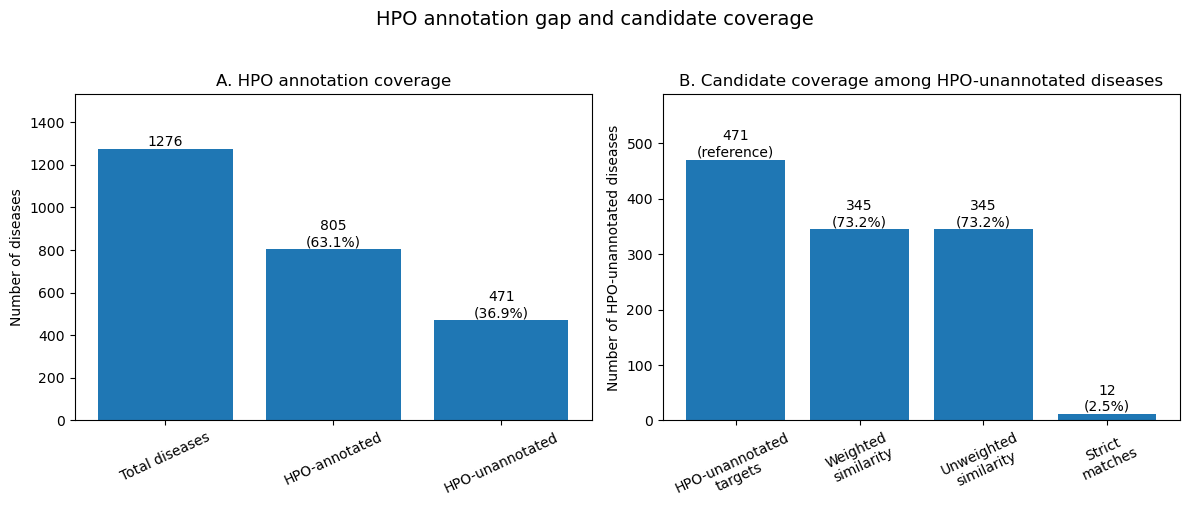

In [8]:
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# Output directory
# ============================================================

OUT_DIR = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper")
OUT_DIR.mkdir(exist_ok=True)

# ============================================================
# Data
# ============================================================

total_diseases = 1276
hpo_annotated = 805
hpo_unannotated = 471

weighted_targets = 345
unweighted_targets = 345
strict_match_targets = 12

# Percentages for Panel A
annotated_pct = hpo_annotated / total_diseases * 100
unannotated_pct = hpo_unannotated / total_diseases * 100

# Percentages for Panel B, relative to HPO-unannotated diseases
weighted_pct = weighted_targets / hpo_unannotated * 100
unweighted_pct = unweighted_targets / hpo_unannotated * 100
strict_match_pct = strict_match_targets / hpo_unannotated * 100

# ============================================================
# Figure
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ============================================================
# Panel A — HPO annotation coverage
# ============================================================

ax = axes[0]

labels_a = [
    "Total diseases",
    "HPO-annotated",
    "HPO-unannotated"
]

values_a = [
    total_diseases,
    hpo_annotated,
    hpo_unannotated
]

bars_a = ax.bar(labels_a, values_a)

ax.set_title("A. HPO annotation coverage")
ax.set_ylabel("Number of diseases")
ax.set_ylim(0, max(values_a) * 1.20)

for bar, value, label in zip(bars_a, values_a, labels_a):
    height = bar.get_height()

    if label == "HPO-annotated":
        text = f"{value}\n({annotated_pct:.1f}%)"
    elif label == "HPO-unannotated":
        text = f"{value}\n({unannotated_pct:.1f}%)"
    else:
        text = f"{value}"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        text,
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.tick_params(axis="x", rotation=25)

# ============================================================
# Panel B — Candidate coverage among HPO-unannotated diseases
# ============================================================

ax = axes[1]

labels_b = [
    "HPO-unannotated\ntargets",
    "Weighted\nsimilarity",
    "Unweighted\nsimilarity",
    "Strict\nmatches"
]

values_b = [
    hpo_unannotated,
    weighted_targets,
    unweighted_targets,
    strict_match_targets
]

bars_b = ax.bar(labels_b, values_b)

ax.set_title("B. Candidate coverage among HPO-unannotated diseases")
ax.set_ylabel("Number of HPO-unannotated diseases")
ax.set_ylim(0, max(values_b) * 1.25)

for bar, value, label in zip(bars_b, values_b, labels_b):
    height = bar.get_height()

    if "Weighted" in label:
        text = f"{value}\n({weighted_pct:.1f}%)"
    elif "Unweighted" in label:
        text = f"{value}\n({unweighted_pct:.1f}%)"
    elif "Strict" in label:
        text = f"{value}\n({strict_match_pct:.1f}%)"
    else:
        text = f"{value}\n(reference)"

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        text,
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.tick_params(axis="x", rotation=25)

# ============================================================
# Layout and save
# ============================================================

fig.suptitle(
    "HPO annotation gap and candidate coverage",
    fontsize=14,
    y=1.03
)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_hpo_annotation_gap_candidate_coverage.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    OUT_DIR / "fig_hpo_annotation_gap_candidate_coverage.pdf",
    bbox_inches="tight"
)

plt.show()

03/04/2026 la seconda figura e la tabella  da inserire nel mio paper
Per il main paper, io userei:

fig_sensitivity_class_counts.png
table_sensitivity_class_summary_for_paper.csv
table_top100_high_confidence_HPO_candidates_for_main_text.csv
opzionalmente fig_targets_by_strict_only_candidate_count.png

La heatmap fig_top_robust_candidates_mode_heatmap.png è utile, ma se risulta troppo affollata, mettila in Supplementary.

il codice produce:

Figura 1 — sensitivity class counts, pronta per il paper.
Figura 2 — heatmap dei candidati HPO più robusti.
Tabella 1 — summary delle classi di sensitivity.
Tabella 2 — candidati high-confidence da usare nel main paper.
Tabella 3 — coverage per target disease.

Columns:
['target_ORPHAcode', 'target_DiseaseName', 'candidate_HPO_ID', 'candidate_HPO_Label', 'weighted_normScore', 'weighted_raw_score', 'weighted_rank', 'weighted_n_supporting_donors', 'weighted_confidence', 'equal_normScore', 'equal_raw_score', 'equal_rank', 'equal_n_supporting_donors', 'equal_confidence', 'strict_normScore', 'strict_raw_score', 'strict_rank', 'strict_n_supporting_donors', 'strict_confidence', 'present_weighted', 'present_equal', 'present_strict', 'sensitivity_class']

Rows loaded: 28,771

Sensitivity class summary:
           sensitivity_class  n_candidate_records  percentage  \
0  robust_weighted_and_equal                26837   93.277953   
1     robust_all_three_modes                  668    2.321782   
3              weighted_only                  626    2.175802   
4      strict_only_supported                   11    0.038233   
2                 equal_only                  629    2.186229   

                                      interpretation  
0  Recovere

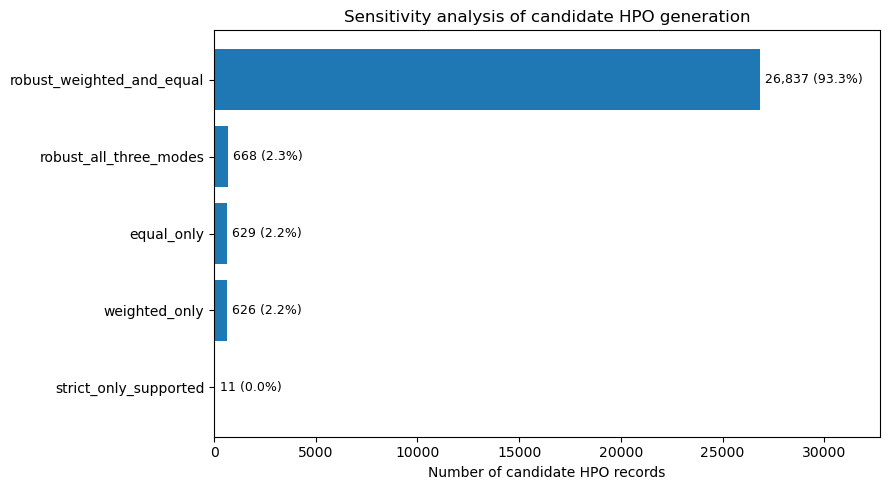


High-confidence candidate rows: 679
Saved high-confidence candidate tables.


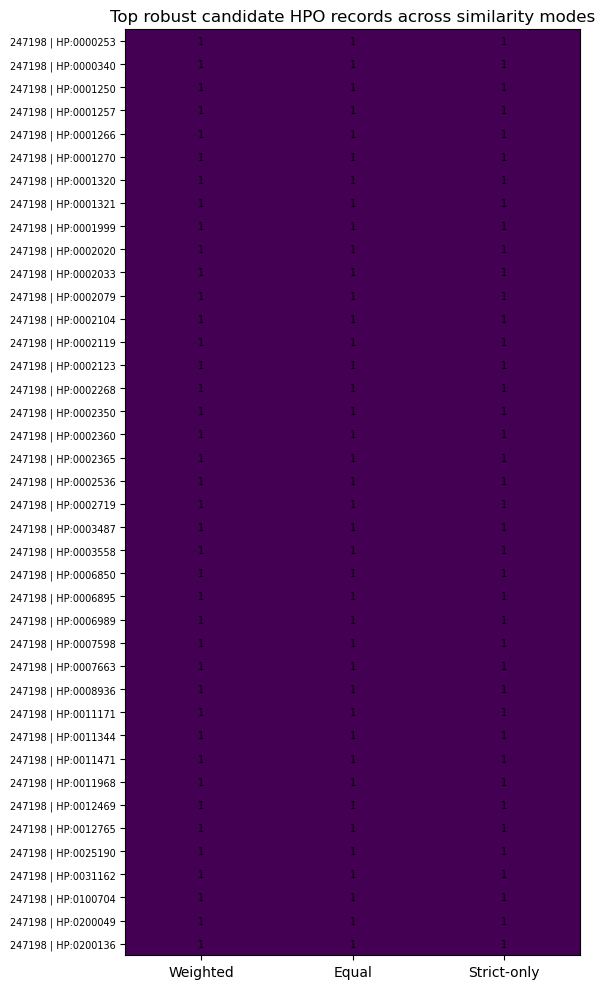


Target-level coverage summary:
    target_ORPHAcode                                 target_DiseaseName  \
71            254905           Isolated cytochrome C oxidase deficiency   
312            90641  Rare mitochondrial non-syndromic sensorineural...   
309            90625  Rare X-linked non-syndromic sensorineural deaf...   
239           642099  Spondyloepimetaphyseal dysplasia with joint la...   
246           647782       Isolated micronodular adrenocortical disease   
245           647772  Isolated primary pigmented nodular adrenocorti...   
54            247198             Progressive cerebello-cerebral atrophy   
215           583602  Neu-Laxova syndrome due to phosphoserine amino...   
94            293284     Tetrahydrobiopterin-responsive phenylketonuria   
280           708895   Tetrahydrobiopterin-unresponsive phenylketonuria   
150           369920                  Pontocerebellar hypoplasia type 9   
270            69723                                 Tyrosinemia typ

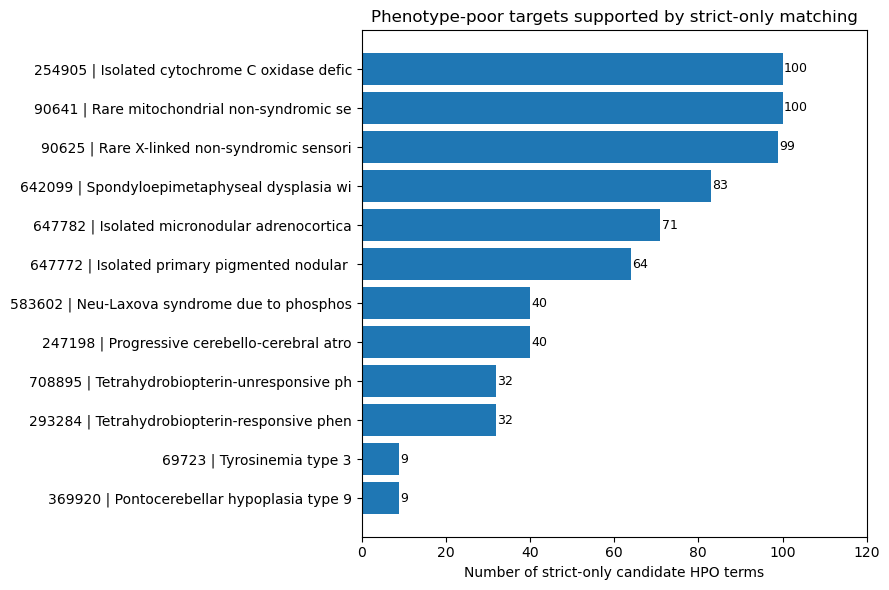


=== OUTPUT FILES SAVED ===
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\table_sensitivity_class_summary_for_paper.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\fig_sensitivity_class_counts.png
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\fig_top_robust_candidates_mode_heatmap.png
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\table_high_confidence_HPO_candidates_for_main_text.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\table_top100_high_confidence_HPO_candidates_for_main_text.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\table_target_level_candidate_coverage_summary.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\table_top50_target_level_candidate_coverage_summary.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis\fig_targets

In [ ]:
# ============================================================
# Sensitivity analysis figures and paper-ready tables
# Input:
# C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\sensitivity_hpo_candidate_comparison.csv
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\sensitivity_hpo_candidate_comparison.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD FILE
# ============================================================

df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

print("Columns:")
print(df.columns.tolist())
print(f"\nRows loaded: {len(df):,}")

# ============================================================
# HELPERS
# ============================================================

def to_bool_series(s):
    """
    Convert True/False columns that may be stored as bool, 1/0,
    or strings such as 'True', 'False'.
    """
    return (
        s.astype(str)
         .str.strip()
         .str.lower()
         .map({
             "true": True,
             "false": False,
             "1": True,
             "0": False,
             "yes": True,
             "no": False
         })
         .fillna(False)
    )

def to_numeric_col(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def clean_label(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

# ============================================================
# STANDARDIZE COLUMNS
# ============================================================

required_base_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "candidate_HPO_Label"
]

missing = [c for c in required_base_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# Presence columns
for col in ["present_weighted", "present_equal", "present_strict"]:
    if col not in df.columns:
        df[col] = False
    else:
        df[col] = to_bool_series(df[col])

# Numeric score/rank columns
numeric_cols = [
    "weighted_normScore",
    "equal_normScore",
    "strict_normScore",
    "weighted_raw_score",
    "equal_raw_score",
    "strict_raw_score",
    "weighted_rank",
    "equal_rank",
    "strict_rank",
    "weighted_n_supporting_donors",
    "equal_n_supporting_donors",
    "strict_n_supporting_donors"
]

for col in numeric_cols:
    df = to_numeric_col(df, col)

# If sensitivity_class does not exist, derive it
if "sensitivity_class" not in df.columns:
    df["sensitivity_class"] = np.select(
        [
            df["present_weighted"] & df["present_equal"] & df["present_strict"],
            df["present_weighted"] & df["present_equal"] & ~df["present_strict"],
            df["present_strict"] & ~df["present_weighted"] & ~df["present_equal"],
            df["present_weighted"] & ~df["present_equal"] & ~df["present_strict"],
            ~df["present_weighted"] & df["present_equal"] & ~df["present_strict"],
        ],
        [
            "robust_all_three_modes",
            "robust_weighted_and_equal",
            "strict_only_supported",
            "weighted_only",
            "unweighted",
        ],
        default="mode_specific"
    )

# Best score across modes
score_cols = ["weighted_normScore", "equal_normScore", "strict_normScore"]
for col in score_cols:
    if col not in df.columns:
        df[col] = np.nan

df["best_normScore"] = df[score_cols].max(axis=1)

# ============================================================
# TABLE 1 — SENSITIVITY CLASS SUMMARY
# ============================================================

class_order = [
    "robust_weighted_and_equal",
    "robust_all_three_modes",
    "weighted_only",
    "unweighted",
    "strict_only_supported",
    "mode_specific"
]

interpretation = {
    "robust_weighted_and_equal":
        "Recovered by both broad similarity modes; stable to weighting strategy.",
    "robust_all_three_modes":
        "Recovered by weighted, equal-weight, and strict-only modes; strongest computational robustness.",
    "weighted_only":
        "Recovered only by weighted similarity; exploratory and weight-dependent.",
    "unweighted":
        "Recovered only by equal-weight similarity; exploratory and mode-dependent.",
    "strict_only_supported":
        "Recovered only by strict-only mode; requires case-level inspection.",
    "mode_specific":
        "Recovered by a non-standard mode combination."
}

class_summary = (
    df["sensitivity_class"]
    .value_counts()
    .rename_axis("sensitivity_class")
    .reset_index(name="n_candidate_records")
)

class_summary["percentage"] = (
    class_summary["n_candidate_records"] / len(df) * 100
)

class_summary["interpretation"] = class_summary["sensitivity_class"].map(
    interpretation
).fillna("Mode-specific candidate class.")

# Apply custom order
class_summary["order"] = class_summary["sensitivity_class"].apply(
    lambda x: class_order.index(x) if x in class_order else 999
)
class_summary = class_summary.sort_values("order").drop(columns="order")

class_summary.to_csv(
    OUT_DIR / "table_sensitivity_class_summary_for_paper.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

#class_summary.to_latex(
  #  OUT_DIR / "table_sensitivity_class_summary_for_paper.tex",
  #  index=False,
  #  float_format="%.2f"
#)

print("\nSensitivity class summary:")
print(class_summary)

# ============================================================
# FIGURE 1 — SENSITIVITY CLASS COUNTS
# ============================================================

plot_df = class_summary.copy()
plot_df = plot_df.sort_values("n_candidate_records", ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.barh(
    plot_df["sensitivity_class"],
    plot_df["n_candidate_records"]
)

ax.set_xlabel("Number of candidate HPO records")
ax.set_title("Sensitivity analysis of candidate HPO generation")

# Add count and percentage labels
max_count = plot_df["n_candidate_records"].max()

for bar, n, pct in zip(
    bars,
    plot_df["n_candidate_records"],
    plot_df["percentage"]
):
    ax.text(
        bar.get_width() + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n):,} ({pct:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, max_count * 1.22)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_sensitivity_class_counts.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    OUT_DIR / "fig_sensitivity_class_counts.pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TABLE 2 — HIGH-CONFIDENCE CANDIDATES FOR MAIN PAPER
# ============================================================
# Criteria:
# - candidates present in all three modes, OR
# - candidates present in strict-only mode
#
# This table is useful for selecting representative examples
# for the main text.
# ============================================================

high_conf = df[
    (df["sensitivity_class"] == "robust_all_three_modes") |
    (df["present_strict"])
].copy()

# Sort: strict first, then best score
high_conf = high_conf.sort_values(
    [
        "present_strict",
        "best_normScore",
        "weighted_normScore",
        "equal_normScore",
        "strict_normScore"
    ],
    ascending=[False, False, False, False, False]
)

table2_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "candidate_HPO_Label",
    "sensitivity_class",
    "weighted_normScore",
    "equal_normScore",
    "strict_normScore",
    "weighted_rank",
    "equal_rank",
    "strict_rank",
    "present_weighted",
    "present_equal",
    "present_strict"
]

# Keep only existing columns
table2_cols = [c for c in table2_cols if c in high_conf.columns]

high_conf_table = high_conf[table2_cols].copy()

high_conf_table.to_csv(
    OUT_DIR / "table_high_confidence_HPO_candidates_for_main_text.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# Also save a smaller top-100 version for manual inspection
high_conf_table.head(100).to_csv(
    OUT_DIR / "table_top100_high_confidence_HPO_candidates_for_main_text.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print(f"\nHigh-confidence candidate rows: {len(high_conf_table):,}")
print("Saved high-confidence candidate tables.")

# ============================================================
# FIGURE 2 — HEATMAP OF TOP ROBUST CANDIDATES
# ============================================================
# Shows whether top candidates are recovered by:
# weighted / equal-weight / strict-only.
# ============================================================

TOP_N = 40

heat = high_conf.copy()

# If too many, keep top N by best_normScore
heat = heat.sort_values(
    ["present_strict", "best_normScore"],
    ascending=[False, False]
).head(TOP_N)

presence_cols = ["present_weighted", "present_equal", "present_strict"]
presence_matrix = heat[presence_cols].astype(int).values

row_labels = (
    heat["target_ORPHAcode"].astype(str)
    + " | "
    + heat["candidate_HPO_ID"].astype(str)
)

fig, ax = plt.subplots(figsize=(6, 10))

im = ax.imshow(presence_matrix, aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(["Weighted", "Equal", "Strict-only"])

ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=7)

ax.set_title("Top robust candidate HPO records across similarity modes")

# Add 0/1 labels inside heatmap cells
for i in range(presence_matrix.shape[0]):
    for j in range(presence_matrix.shape[1]):
        ax.text(
            j,
            i,
            str(presence_matrix[i, j]),
            ha="center",
            va="center",
            fontsize=7
        )

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_top_robust_candidates_mode_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)
plt.savefig(
    OUT_DIR / "fig_top_robust_candidates_mode_heatmap.pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# TABLE 3 — TARGET-LEVEL COVERAGE SUMMARY
# ============================================================

target_summary = (
    df.groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        n_total_candidate_HPO=("candidate_HPO_ID", "nunique"),
        n_weighted_candidates=("present_weighted", "sum"),
        n_unweighted_candidates=("present_unweighted", "sum"),
        n_strict_candidates=("present_strict", "sum"),
        n_robust_all_three=(
            "sensitivity_class",
            lambda x: (x == "robust_all_three_modes").sum()
        ),
        n_robust_weighted_unweighted=(
            "sensitivity_class",
            lambda x: (x == "robust_weighted_and_unweighted").sum()
        ),
        best_weighted_normScore=("weighted_normScore", "max"),
        best_unweighted_normScore=("unweighted_normScore", "max"),
        best_strict_normScore=("strict_normScore", "max")
    )
    .reset_index()
)

target_summary = target_summary.sort_values(
    [
        "n_strict_candidates",
        "n_robust_all_three",
        "n_total_candidate_HPO"
    ],
    ascending=[False, False, False]
)

target_summary.to_csv(
    OUT_DIR / "table_target_level_candidate_coverage_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

target_summary.head(50).to_csv(
    OUT_DIR / "table_top50_target_level_candidate_coverage_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nTarget-level coverage summary:")
print(target_summary.head(20))

# ============================================================
# FIGURE 3 — TOP TARGETS BY STRICT-ONLY CANDIDATES
# Optional, useful if strict targets are important in Results.
# ============================================================

strict_targets = target_summary[target_summary["n_strict_candidates"] > 0].copy()

if not strict_targets.empty:
    strict_targets_plot = strict_targets.head(20).sort_values(
        "n_strict_candidates",
        ascending=True
    )

    fig, ax = plt.subplots(figsize=(9, 6))

    labels = (
        strict_targets_plot["target_ORPHAcode"].astype(str)
        + " | "
        + strict_targets_plot["target_DiseaseName"].astype(str).str.slice(0, 35)
    )

    bars = ax.barh(
        labels,
        strict_targets_plot["n_strict_candidates"]
    )

    ax.set_xlabel("Number of strict-only candidate HPO terms")
    ax.set_title("Phenotype-poor targets supported by strict-only matching")

    for bar, n in zip(bars, strict_targets_plot["n_strict_candidates"]):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n)}",
            va="center",
            fontsize=9
        )

    ax.set_xlim(0, strict_targets_plot["n_strict_candidates"].max() * 1.20)

    plt.tight_layout()

    plt.savefig(
        OUT_DIR / "fig_targets_by_strict_only_candidate_count.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.savefig(
        OUT_DIR / "fig_targets_by_strict_only_candidate_count.pdf",
        bbox_inches="tight"
    )

    plt.show()

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=== OUTPUT FILES SAVED ===")
print(OUT_DIR / "table_sensitivity_class_summary_for_paper.csv")
#print(OUT_DIR / "table_sensitivity_class_summary_for_paper.tex")
print(OUT_DIR / "fig_sensitivity_class_counts.png")
print(OUT_DIR / "fig_top_robust_candidates_mode_heatmap.png")
print(OUT_DIR / "table_high_confidence_HPO_candidates_for_main_text.csv")
print(OUT_DIR / "table_top100_high_confidence_HPO_candidates_for_main_text.csv")
print(OUT_DIR / "table_target_level_candidate_coverage_summary.csv")
print(OUT_DIR / "table_top50_target_level_candidate_coverage_summary.csv")
print(OUT_DIR / "fig_targets_by_strict_only_candidate_count.png")

Questo codice produce:

bar plot pulito della sensitivity analysis;
tabella sensitivity summary;
bar plot strict-only filtrato per i casi biologicamente interpretabili;
tabella strict target summary per main paper.

#result
The sensitivity analysis showed that candidate generation was stable across the two broad similarity schemes. Among 28,771 candidate HPO records, 26,837 (93.3\%) were recovered by both weighted and equal-weight similarity. Only 626 records were specific to the weighted mode and 629 to the equal-weight mode. The strict-only setting produced a smaller conservative subset: 668 candidates were recovered by all three modes, whereas 11 candidates appeared only under strict matching. This pattern supports the intended separation of roles: weighted and equal-weight similarity provide broad candidate generation, while strict-only matching defines a high-confidence reaction-profile subset.


Because strict-only matching can also recover broad pleiotropic profiles, such as mitochondrial oxidative-phosphorylation and multi-system enzymatic disorders, the main mechanistic interpretation focused on selected Class~1 pairs with a direct reaction-level interpretation. Broader or functionally ambiguous cases were retained in Supplementary Tables.

--- Sensitivity Summary ---
       sensitivity_class  n_candidate_records  percentage
0  Weighted + Unweighted                26837   93.277953
1        All three modes                  668    2.321782
2        Unweighted only                  629    2.186229
3          Weighted only                  626    2.175802
4            Strict only                   11    0.038233


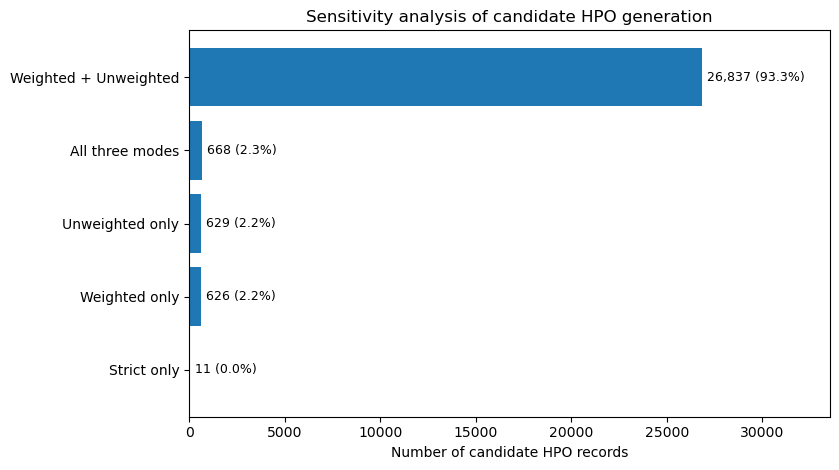


Selected strict targets for main paper:
  target_ORPHAcode                                 target_DiseaseName  \
8            69723                                 Tyrosinemia type 3   
3           369920                  Pontocerebellar hypoplasia type 9   
9           708895   Tetrahydrobiopterin-unresponsive phenylketonuria   
2           293284     Tetrahydrobiopterin-responsive phenylketonuria   
0           247198             Progressive cerebello-cerebral atrophy   
4           583602  Neu-Laxova syndrome due to phosphoserine amino...   
5           642099  Spondyloepimetaphyseal dysplasia with joint la...   

   n_strict_candidate_HPO  n_all_three_candidates  best_strict_normScore  \
8                       9                       9                    1.0   
3                       9                       9                    1.0   
9                      32                      32                    1.0   
2                      32                      32                    1

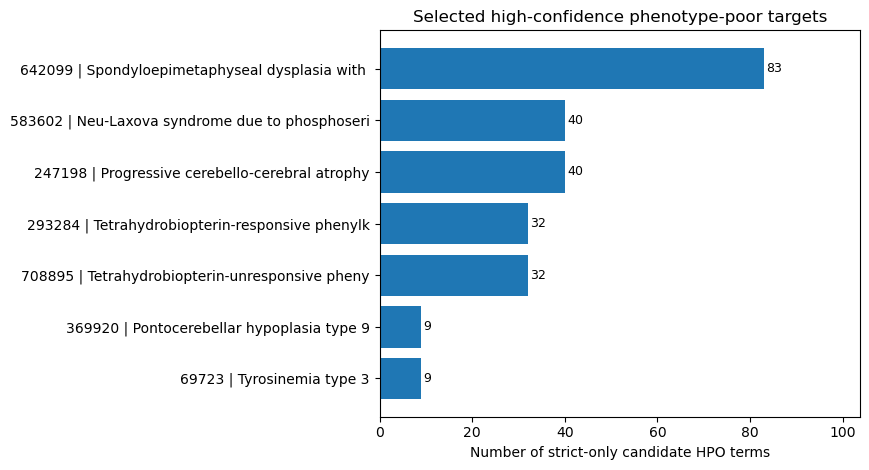


=== PROCESSING COMPLETE. ALL TABLES AND GRAPHICS GENERATED ===


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\sensitivity_hpo_candidate_comparison.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis_clean"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD & AUTOMATIC RENAMING (From 'equal' to 'unweighted')
# ============================================================

df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

# Trasforma automaticamente tutti i riferimenti "equal" in "unweighted"
df.columns = [c.replace("equal", "unweighted") for c in df.columns]
if "sensitivity_class" in df.columns:
    df["sensitivity_class"] = df["sensitivity_class"].str.replace("equal", "unweighted")

# Convert booleans
for col in ["present_weighted", "present_unweighted", "present_strict"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False, "1": True, "0": False})
            .fillna(False)
        )

# Numeric columns
score_cols = [
    "weighted_normScore",
    "unweighted_normScore",
    "strict_normScore",
    "weighted_rank",
    "unweighted_rank",
    "strict_rank"
]

for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["best_normScore"] = df[
    ["weighted_normScore", "unweighted_normScore", "strict_normScore"]
].max(axis=1)

# ============================================================
# CLEAN LABELS FOR SENSITIVITY CLASSES
# ============================================================

label_map = {
    "robust_weighted_and_unweighted": "Weighted + Unweighted",
    "robust_all_three_modes": "All three modes",
    "unweighted_only": "Unweighted only",
    "weighted_only": "Weighted only",
    "strict_only_supported": "Strict only"
}

order = [
    "Weighted + Unweighted",
    "All three modes",
    "Unweighted only",
    "Weighted only",
    "Strict only"
]

df["sensitivity_label"] = df["sensitivity_class"].map(label_map).fillna("Other")

# ============================================================
# TABLE 1 — SENSITIVITY SUMMARY
# ============================================================

summary = (
    df["sensitivity_label"]
    .value_counts()
    .rename_axis("sensitivity_class")
    .reset_index(name="n_candidate_records")
)

summary["percentage"] = summary["n_candidate_records"] / len(df) * 100

summary["sensitivity_class"] = pd.Categorical(
    summary["sensitivity_class"],
    categories=order,
    ordered=True
)

summary = summary.sort_values("sensitivity_class").dropna(subset=["sensitivity_class"])

summary.to_csv(
    OUT_DIR / "table_sensitivity_summary_paper_ready.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("--- Sensitivity Summary ---")
print(summary)

# ============================================================
# FIGURE 1 — CLEAN SENSITIVITY BAR PLOT
# ============================================================

plot_df = summary.sort_values("n_candidate_records", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.barh(
    plot_df["sensitivity_class"].astype(str),
    plot_df["n_candidate_records"]
)

ax.set_xlabel("Number of candidate HPO records")
ax.set_title("Sensitivity analysis of candidate HPO generation")

max_count = plot_df["n_candidate_records"].max() if not plot_df.empty else 1

for bar, n, pct in zip(
    bars,
    plot_df["n_candidate_records"],
    plot_df["percentage"]
):
    ax.text(
        bar.get_width() + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n):,} ({pct:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, max_count * 1.25)
plt.tight_layout()

plt.savefig(OUT_DIR / "fig_sensitivity_class_counts_paper_ready.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig_sensitivity_class_counts_paper_ready.pdf", bbox_inches="tight")
plt.show()

# ============================================================
# STRICT TARGET SUMMARY
# ============================================================

strict_df = df[df["present_strict"]].copy()

strict_target_summary = (
    strict_df
    .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        n_strict_candidate_HPO=("candidate_HPO_ID", "nunique"),
        n_all_three_candidates=(
            "sensitivity_class",
            lambda x: (x == "robust_all_three_modes").sum()
        ),
        best_strict_normScore=("strict_normScore", "max")
    )
    .reset_index()
)

strict_target_summary = strict_target_summary.sort_values(
    "n_strict_candidate_HPO",
    ascending=False
)

strict_target_summary.to_csv(
    OUT_DIR / "table_all_strict_targets_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# MAIN-PAPER BIOLOGICALLY INTERPRETABLE TARGETS
# ============================================================

main_targets = {
    "69723": "HPD / tyrosine metabolism",
    "369920": "AMPD2 / purine salvage",
    "642099": "B3GALT6 / glycan-connective tissue",
    "583602": "PSAT1 / serine biosynthesis",
    "247198": "SEPSECS / Sec-tRNA neurodevelopment",
    "293284": "PAH / context-dependent",
    "708895": "PAH / context-dependent"
}

main_strict = strict_target_summary[
    strict_target_summary["target_ORPHAcode"].astype(str).isin(main_targets.keys())
].copy()

main_strict["mechanistic_comment"] = (
    main_strict["target_ORPHAcode"]
    .astype(str)
    .map(main_targets)
)

main_strict = main_strict.sort_values(
    "n_strict_candidate_HPO",
    ascending=True
)

main_strict.to_csv(
    OUT_DIR / "table_main_text_strict_targets_selected.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nSelected strict targets for main paper:")
print(main_strict)

# ============================================================
# FIGURE 2 — SELECTED STRICT TARGETS FOR MAIN PAPER
# ============================================================

if not main_strict.empty:
    fig, ax = plt.subplots(figsize=(8.8, 4.8))

    labels = (
        main_strict["target_ORPHAcode"].astype(str)
        + " | "
        + main_strict["target_DiseaseName"].astype(str).str.slice(0, 38)
    )

    bars = ax.barh(
        labels,
        main_strict["n_strict_candidate_HPO"]
    )

    ax.set_xlabel("Number of strict-only candidate HPO terms")
    ax.set_title("Selected high-confidence phenotype-poor targets")

    for bar, n in zip(bars, main_strict["n_strict_candidate_HPO"]):
        ax.text(
            bar.get_width() + 0.5,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n)}",
            va="center",
            fontsize=9
        )

    ax.set_xlim(0, main_strict["n_strict_candidate_HPO"].max() * 1.25)
    plt.tight_layout()

    plt.savefig(OUT_DIR / "fig_selected_strict_targets_main_paper.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT_DIR / "fig_selected_strict_targets_main_paper.pdf", bbox_inches="tight")
    plt.show()

print("\n=== PROCESSING COMPLETE. ALL TABLES AND GRAPHICS GENERATED ===")

Φ(d)={Gene,Entry,EC,Rhea,Cofactor,Pathway}
high_strict_profile_match
Questo significa che tutti i 679 candidati derivano da una identità completa del profilo reazionale. È un risultato forte, ma non significa che tutti i 679 HPO siano automaticamente biologicamente forti.

Il punto delicato è questo: quando c’è un solo donor, tutti gli HPO del donor ricevono normScore = 1. Per esempio, in Tyrosinemia type 3 tutti i 9 HPO di Hawkinsinuria hanno score 1, ma biologicamente non sono tutti uguali. 4-Hydroxyphenylpyruvic aciduria e Abnormality of tyrosine metabolism sono forti; Hypothyroidism, Fine hair, Sparse hair sono deboli perché non sono direttamente spiegati dal marker Maude.

Quindi il file strict-only serve a dire:

questi HPO sono candidati ad alta confidenza di profilo, ma la priorità biologica finale richiede interpretazione meccanicistica.
| Target phenotype-poor                          |                      Donor HPO-rich | n HPO candidati | Gene/meccanismo                    | Uso nel paper           |
| ---------------------------------------------- | ----------------------------------: | --------------: | ---------------------------------- | ----------------------- |
| Tyrosinemia type 3                             |                       Hawkinsinuria |               9 | HPD / tyrosine metabolism          | main, strong            |
| Pontocerebellar hypoplasia type 9              |            AR spastic paraplegia 63 |               9 | AMPD2 / purine salvage             | main, moderate-strong   |
| Spondyloepimetaphyseal dysplasia Beighton type |                 B3GALT6-related EDS |              83 | B3GALT6 / glycan-connective tissue | main, strong            |
| Neu-Laxova syndrome due to PSAT1 deficiency    | PSAT1 deficiency infantile/juvenile |              40 | PSAT1 / serine biosynthesis        | main, strong            |
| Progressive cerebello-cerebral atrophy         |   Pontocerebellar hypoplasia type 2 |              40 | SEPSECS / Sec-tRNA                 | main, strong            |
| BH4-responsive / unresponsive PKU              |               Maternal PKU syndrome |         32 each | PAH / phenylalanine metabolism     | main, context-dependent |


Questo codice legge hpo_candidates_strict_only.csv, seleziona solo i casi principali per il main paper — HPD, AMPD2, B3GALT6, PSAT1, SEPSECS, PAH — e salva la tabella:

strict_only_selected_main_cases.csv

C:\Users\biofa\AppData\Local\Temp\ipykernel_22384\3378052902.py:107: Pandas4Warning: Constructing a Categorical with a dtype and values containing non-null entries not in that dtype's categories is deprecated and will raise in a future version.
  summary["sensitivity_class"] = pd.Categorical(summary["sensitivity_class"], categories=order, ordered=True)


--- Sensitivity Summary (Records) ---
       sensitivity_class  n_candidate_records  percentage
0  Weighted + Unweighted                26837   93.277953
1        All three modes                  668    2.321782
2        Unweighted only                  629    2.186229
3          Weighted only                  626    2.175802
4       Strict-only only                    8    0.027806


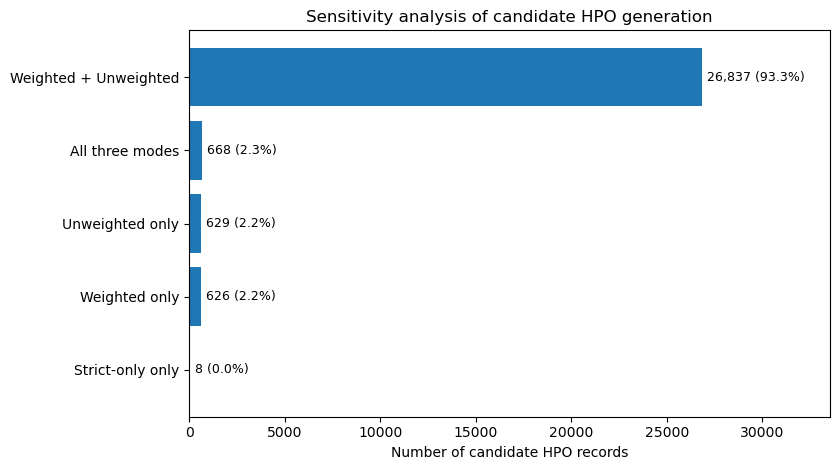


--- Total Strict Targets Found: 12 ---
   target_ORPHAcode                                 target_DiseaseName  \
3            369920                  Pontocerebellar hypoplasia type 9   
8             69723                                 Tyrosinemia type 3   
9            708895   Tetrahydrobiopterin-unresponsive phenylketonuria   
2            293284     Tetrahydrobiopterin-responsive phenylketonuria   
0            247198             Progressive cerebello-cerebral atrophy   
4            583602  Neu-Laxova syndrome due to phosphoserine amino...   
6            647772  Isolated primary pigmented nodular adrenocorti...   
7            647782       Isolated micronodular adrenocortical disease   
5            642099  Spondyloepimetaphyseal dysplasia with joint la...   
10            90625  Rare X-linked non-syndromic sensorineural deaf...   
1            254905           Isolated cytochrome C oxidase deficiency   
11            90641  Rare mitochondrial non-syndromic sensorineural...  

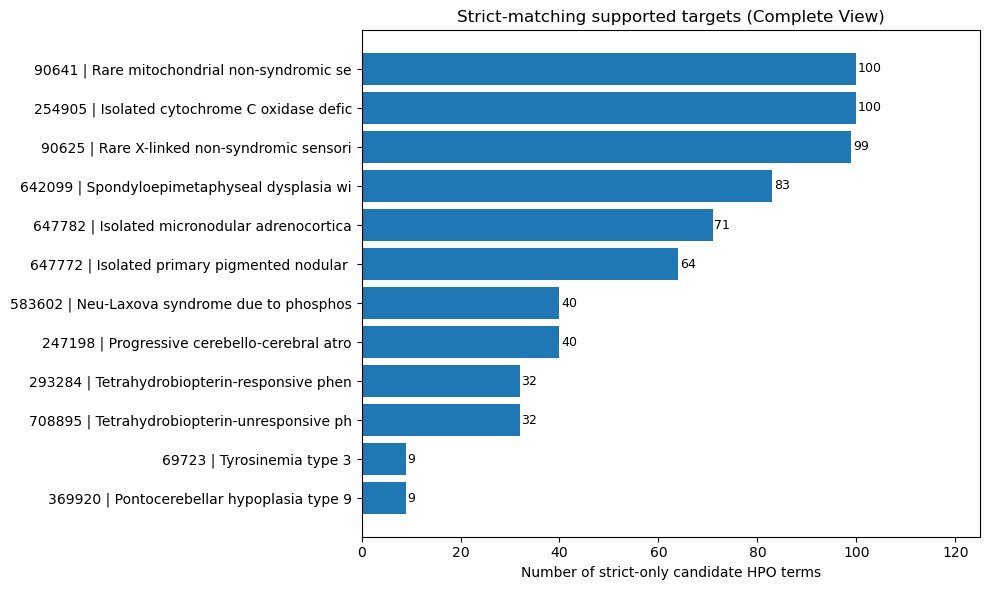


=== PROCESSING COMPLETE. ALL 12 TARGETS DETECTED AND PLOTTED ===


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\sensitivity_hpo_candidate_comparison.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis_clean"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD & AUTOMATIC RENAMING
# ============================================================

df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

# Sostituisce i riferimenti "equal" con "unweighted" per coerenza
df.columns = [c.replace("equal", "unweighted") for c in df.columns]

# Convert booleans
for col in ["present_weighted", "present_unweighted", "present_strict"]:
    if col in df.columns:
        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
            .str.lower()
            .map({"true": True, "false": False, "1": True, "0": False})
            .fillna(False)
        )

# Numeric columns
score_cols = [
    "weighted_normScore", "unweighted_normScore", "strict_normScore",
    "weighted_rank", "unweighted_rank", "strict_rank"
]
for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

df["best_normScore"] = df[
    ["weighted_normScore", "unweighted_normScore", "strict_normScore"]
].max(axis=1)

# ============================================================
# FORCE RECALCULATION OF SENSITIVITY CLASSES
# ============================================================
# Ricalcoliamo da zero per assicurarci che non vadano persi record strict-only
df["sensitivity_class"] = np.select(
    [
        df["present_weighted"] & df["present_unweighted"] & df["present_strict"],
        df["present_weighted"] & df["present_unweighted"] & ~df["present_strict"],
        df["present_strict"] & ~df["present_weighted"] & ~df["present_unweighted"],
        df["present_weighted"] & ~df["present_unweighted"] & ~df["present_strict"],
        ~df["present_weighted"] & df["present_unweighted"] & ~df["present_strict"],
    ],
    [
        "robust_all_three_modes",
        "robust_weighted_and_unweighted",
        "strict_only_supported",
        "weighted_only",
        "unweighted_only",
    ],
    default="mode_specific"
)

# Clean labels for paper
label_map = {
    "robust_weighted_and_unweighted": "Weighted + Unweighted",
    "robust_all_three_modes": "All three modes",
    "unweighted_only": "Unweighted only",
    "weighted_only": "Weighted only",
    "strict_only_supported": "Strict-only only"
}

order = [
    "Weighted + Unweighted",
    "All three modes",
    "Unweighted only",
    "Weighted only",
    "Strict-only only"
]

df["sensitivity_label"] = df["sensitivity_class"].map(label_map).fillna("Other")

# ============================================================
# TABLE 1 — SENSITIVITY SUMMARY
# ============================================================

summary = (
    df["sensitivity_label"]
    .value_counts()
    .rename_axis("sensitivity_class")
    .reset_index(name="n_candidate_records")
)

summary["percentage"] = summary["n_candidate_records"] / len(df) * 100
summary["sensitivity_class"] = pd.Categorical(summary["sensitivity_class"], categories=order, ordered=True)
summary = summary.sort_values("sensitivity_class").dropna(subset=["sensitivity_class"])

summary.to_csv(OUT_DIR / "table_sensitivity_summary_paper_ready.csv", sep=";", index=False, encoding="utf-8-sig")

print("--- Sensitivity Summary (Records) ---")
print(summary)

# ============================================================
# FIGURE 1 — CLEAN SENSITIVITY BAR PLOT
# ============================================================

plot_df = summary.sort_values("n_candidate_records", ascending=True)
fig, ax = plt.subplots(figsize=(8.5, 4.8))
bars = ax.barh(plot_df["sensitivity_class"].astype(str), plot_df["n_candidate_records"])

ax.set_xlabel("Number of candidate HPO records")
ax.set_title("Sensitivity analysis of candidate HPO generation")
max_count = plot_df["n_candidate_records"].max() if not plot_df.empty else 1

for bar, n, pct in zip(bars, plot_df["n_candidate_records"], plot_df["percentage"]):
    ax.text(
        bar.get_width() + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n):,} ({pct:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, max_count * 1.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fig_sensitivity_class_counts_paper_ready.png", dpi=300, bbox_inches="tight")
plt.show()

# ============================================================
# STRICT TARGET SUMMARY (Trova dinamicamente tutti i 12 target)
# ============================================================

strict_df = df[df["present_strict"]].copy()

strict_target_summary = (
    strict_df
    .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        n_strict_candidate_HPO=("candidate_HPO_ID", "nunique"),
        n_all_three_candidates=(
            "sensitivity_class",
            lambda x: (x == "robust_all_three_modes").sum()
        ),
        best_strict_normScore=("strict_normScore", "max")
    )
    .reset_index()
)

strict_target_summary = strict_target_summary.sort_values("n_strict_candidate_HPO", ascending=True)

# Mappa i commenti biologici noti senza filtrare via le altre malattie
main_targets = {
    "69723": "HPD / tyrosine metabolism",
    "369920": "AMPD2 / purine salvage",
    "642099": "B3GALT6 / glycan-connective tissue",
    "583602": "PSAT1 / serine biosynthesis",
    "247198": "SEPSECS / Sec-tRNA neurodevelopment",
    "293284": "PAH / context-dependent",
    "708895": "PAH / context-dependent"
}

strict_target_summary["mechanistic_comment"] = (
    strict_target_summary["target_ORPHAcode"].astype(str).map(main_targets).fillna("Other strict target")
)

strict_target_summary.to_csv(OUT_DIR / "table_all_strict_targets_summary_complete.csv", sep=";", index=False, encoding="utf-8-sig")

print(f"\n--- Total Strict Targets Found: {len(strict_target_summary)} ---")
print(strict_target_summary)

# ============================================================
# FIGURE 2 — GRAPH OF ALL STRICT TARGETS (Mostra i 12 elementi)
# ============================================================

if not strict_target_summary.empty:
    fig, ax = plt.subplots(figsize=(10, 6))  # Leggermente più grande per contenere tutti i 12 elementi

    labels = (
        strict_target_summary["target_ORPHAcode"].astype(str)
        + " | "
        + strict_target_summary["target_DiseaseName"].astype(str).str.slice(0, 35)
    )

    bars = ax.barh(labels, strict_target_summary["n_strict_candidate_HPO"])
    ax.set_xlabel("Number of strict-only candidate HPO terms")
    ax.set_title("Strict-matching supported targets (Complete View)")

    for bar, n in zip(bars, strict_target_summary["n_strict_candidate_HPO"]):
        ax.text(
            bar.get_width() + 0.3,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n)}",
            va="center",
            fontsize=9
        )

    ax.set_xlim(0, strict_target_summary["n_strict_candidate_HPO"].max() * 1.25)
    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_all_strict_targets_complete_paper.png", dpi=300, bbox_inches="tight")
    plt.show()

print("\n=== PROCESSING COMPLETE. ALL 12 TARGETS DETECTED AND PLOTTED ===")


Selected strict-shadow targets for main paper:
  target_ORPHAcode                                 target_DiseaseName  \
8            69723                                 Tyrosinemia type 3   
3           369920                  Pontocerebellar hypoplasia type 9   
9           708895   Tetrahydrobiopterin-unresponsive phenylketonuria   
2           293284     Tetrahydrobiopterin-responsive phenylketonuria   
0           247198             Progressive cerebello-cerebral atrophy   
4           583602  Neu-Laxova syndrome due to phosphoserine amino...   
5           642099  Spondyloepimetaphyseal dysplasia with joint la...   

   n_strict_candidate_HPO  n_all_three_candidates  best_strict_normScore  
8                       9                       9                    1.0  
3                       9                       9                    1.0  
9                      32                      32                    1.0  
2                      32                      32                  

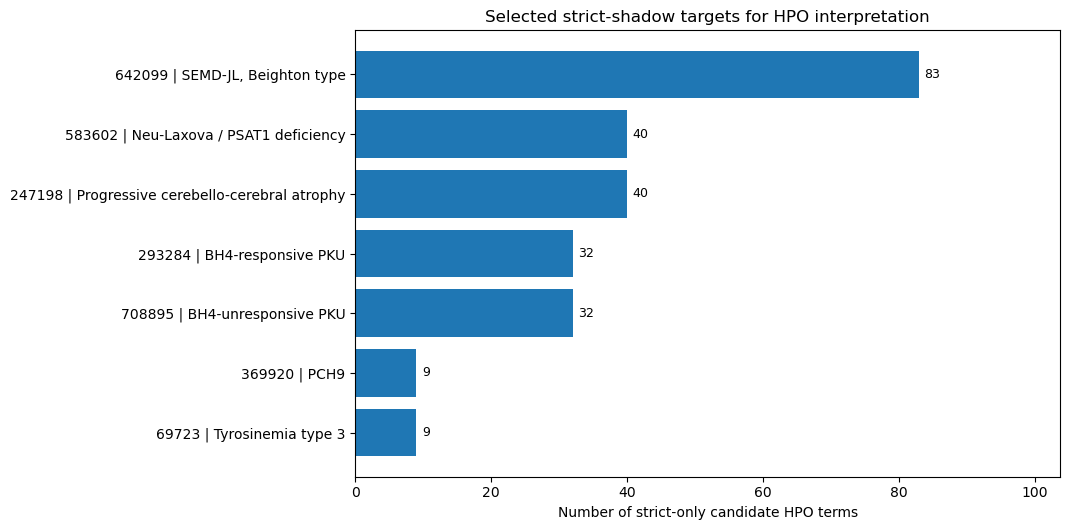

In [2]:
# estarrre la fig utile per la sensitivity analysis, e preparare le tabelle per il paper.

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\sensitivity_hpo_candidate_comparison.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\figures_for_paper\sensitivity_analysis_clean"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

# ============================================================
# BOOLEAN CONVERSION
# ============================================================

for col in ["present_weighted", "present_equal", "present_strict"]:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"true": True, "false": False, "1": True, "0": False})
        .fillna(False)
    )

# ============================================================
# NUMERIC CONVERSION
# ============================================================

score_cols = [
    "weighted_normScore",
    "equal_normScore",
    "strict_normScore",
    "weighted_rank",
    "equal_rank",
    "strict_rank"
]

for col in score_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# ============================================================
# STRICT-ONLY TARGET SUMMARY
# ============================================================

strict_df = df[df["present_strict"]].copy()

strict_target_summary = (
    strict_df
    .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        n_strict_candidate_HPO=("candidate_HPO_ID", "nunique"),
        n_all_three_candidates=(
            "sensitivity_class",
            lambda x: (x == "robust_all_three_modes").sum()
        ),
        best_strict_normScore=("strict_normScore", "max")
    )
    .reset_index()
)

strict_target_summary["target_ORPHAcode"] = strict_target_summary["target_ORPHAcode"].astype(str)

strict_target_summary = strict_target_summary.sort_values(
    "n_strict_candidate_HPO",
    ascending=False
)

strict_target_summary.to_csv(
    OUT_DIR / "table_all_strict_targets_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# SELECT MAIN-PAPER TARGETS
# ============================================================

selected_targets = [
    "642099",  # SEMD-JL, Beighton type
    "583602",  # Neu-Laxova / PSAT1 deficiency
    "247198",  # Progressive cerebello-cerebral atrophy
    "293284",  # BH4-responsive PKU
    "708895",  # BH4-unresponsive PKU
    "369920",  # PCH9
    "69723"    # Tyrosinemia type 3
]

display_labels = {
    "642099": "642099 | SEMD-JL, Beighton type",
    "583602": "583602 | Neu-Laxova / PSAT1 deficiency",
    "247198": "247198 | Progressive cerebello-cerebral atrophy",
    "293284": "293284 | BH4-responsive PKU",
    "708895": "708895 | BH4-unresponsive PKU",
    "369920": "369920 | PCH9",
    "69723":  "69723 | Tyrosinemia type 3"
}

main_strict = strict_target_summary[
    strict_target_summary["target_ORPHAcode"].isin(selected_targets)
].copy()

# Preserve desired order
order_map = {code: i for i, code in enumerate(selected_targets)}
main_strict["plot_order"] = main_strict["target_ORPHAcode"].map(order_map)
main_strict["plot_label"] = main_strict["target_ORPHAcode"].map(display_labels)

# For barh, sort descending so first element appears at top
main_strict = main_strict.sort_values("plot_order", ascending=False)

main_strict.to_csv(
    OUT_DIR / "table_main_text_strict_targets_selected.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nSelected strict-shadow targets for main paper:")
print(main_strict[[
    "target_ORPHAcode",
    "target_DiseaseName",
    "n_strict_candidate_HPO",
    "n_all_three_candidates",
    "best_strict_normScore"
]])

# ============================================================
# FIGURE — SELECTED STRICT-SHADOW TARGETS
# ============================================================

fig, ax = plt.subplots(figsize=(10.8, 5.4))

bars = ax.barh(
    main_strict["plot_label"],
    main_strict["n_strict_candidate_HPO"]
)

ax.set_xlabel("Number of strict-only candidate HPO terms")
ax.set_title("Selected strict-shadow targets for HPO interpretation")

# Add value labels
for bar, n in zip(bars, main_strict["n_strict_candidate_HPO"]):
    ax.text(
        bar.get_width() + 0.8,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n)}",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, main_strict["n_strict_candidate_HPO"].max() * 1.25)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_selected_strict_targets_main_paper.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    OUT_DIR / "fig_selected_strict_targets_main_paper.pdf",
    bbox_inches="tight"
)

plt.show()

In [6]:
import pandas as pd
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\hpo_candidates_strict_only.csv"
)

OUTPUT_DIR = INPUT_FILE.parent / "paper_ready_tables"
OUTPUT_DIR.mkdir(exist_ok=True)

OUTPUT_FILE = OUTPUT_DIR / "strict_only_selected_main_cases.csv"

# ============================================================
# LOAD FILE
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    low_memory=False,
    encoding="utf-8"
)

df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

print("Columns loaded:")
print(df.columns.tolist())
print(f"\nRows loaded: {len(df):,}")

# ============================================================
# REQUIRED COLUMNS CHECK
# ============================================================

required_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "top_supporting_donors"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

# ============================================================
# CLEANING
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def unique_join(values, sep=" || "):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

df["target_ORPHAcode"] = df["target_ORPHAcode"].astype(str).str.strip()
df["target_DiseaseName"] = df["target_DiseaseName"].astype(str).str.strip()
df["candidate_HPO_ID"] = df["candidate_HPO_ID"].astype(str).str.strip()
df["top_supporting_donors"] = df["top_supporting_donors"].astype(str).str.strip()

# ============================================================
# SELECTED MAIN-PAPER TARGETS
# ============================================================
# These are the biologically interpretable strict-only targets
# selected for the main paper.
# ============================================================

selected_targets = {
    # HPD
    "69723": {
        "mechanistic_group": "HPD / tyrosine metabolism",
        "paper_role": "Main strong biochemical case"
    },

    # AMPD2
    "369920": {
        "mechanistic_group": "AMPD2 / purine salvage",
        "paper_role": "Main neuromotor-purine salvage case"
    },

    # B3GALT6
    "642099": {
        "mechanistic_group": "B3GALT6 / glycan and connective-tissue biology",
        "paper_role": "Main skeletal/connective-tissue case"
    },

    # PSAT1
    "583602": {
        "mechanistic_group": "PSAT1 / L-serine biosynthesis",
        "paper_role": "Main amino-acid biosynthesis case"
    },

    # SEPSECS
    "247198": {
        "mechanistic_group": "SEPSECS / selenocysteinyl-tRNA biosynthesis",
        "paper_role": "Main neurodevelopmental tRNA-biosynthesis case"
    },

    # PAH context-dependent cases
    "293284": {
        "mechanistic_group": "PAH / phenylalanine-tyrosine metabolism",
        "paper_role": "Context-dependent control case"
    },

    "708895": {
        "mechanistic_group": "PAH / phenylalanine-tyrosine metabolism",
        "paper_role": "Context-dependent control case"
    }
}

selected_codes = list(selected_targets.keys())

selected_df = df[df["target_ORPHAcode"].isin(selected_codes)].copy()

# ============================================================
# AGGREGATE TO ONE ROW PER TARGET DISEASE
# ============================================================

summary = (
    selected_df
    .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        donor_summary=("top_supporting_donors", unique_join),
        n_candidate_HPO=("candidate_HPO_ID", "nunique")
    )
    .reset_index()
)

summary["mechanistic_group"] = summary["target_ORPHAcode"].map(
    lambda x: selected_targets.get(str(x), {}).get("mechanistic_group", "")
)

summary["paper_role"] = summary["target_ORPHAcode"].map(
    lambda x: selected_targets.get(str(x), {}).get("paper_role", "")
)

# Desired column order
summary = summary[
    [
        "target_ORPHAcode",
        "target_DiseaseName",
        "donor_summary",
        "n_candidate_HPO",
        "mechanistic_group",
        "paper_role"
    ]
].copy()

# Sort in the order useful for the paper
paper_order = {
    "69723": 1,    # HPD
    "369920": 2,   # AMPD2
    "642099": 3,   # B3GALT6
    "583602": 4,   # PSAT1
    "247198": 5,   # SEPSECS
    "293284": 6,   # PAH
    "708895": 7    # PAH
}

summary["paper_order"] = summary["target_ORPHAcode"].map(paper_order)
summary = summary.sort_values("paper_order").drop(columns="paper_order")

# ============================================================
# SAVE
# ============================================================

summary.to_csv(
    OUTPUT_FILE,
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\n=== STRICT-ONLY SELECTED MAIN CASES ===")
print(summary)

print(f"\nSaved file:")
print(OUTPUT_FILE)

# ============================================================
# OPTIONAL CHECK: selected targets not found
# ============================================================

found_codes = set(summary["target_ORPHAcode"].astype(str))
missing_codes = [code for code in selected_codes if code not in found_codes]

if missing_codes:
    print("\nWARNING: These selected target ORPHAcodes were not found in the strict-only file:")
    print(missing_codes)
else:
    print("\nAll selected target ORPHAcodes were found.")

Columns loaded:
['target_ORPHAcode', 'target_DiseaseName', 'candidate_HPO_ID', 'candidate_HPO_Label', 'raw_score', 'normScore', 'rank', 'n_supporting_donors', 'best_donor_similarity', 'top_supporting_donors', 'best_shared_features', 'mechanistic_confidence', 'max_strict_profile_support', 'similarity_mode', 'total_similarity']

Rows loaded: 679

=== STRICT-ONLY SELECTED MAIN CASES ===
  target_ORPHAcode                                 target_DiseaseName  \
5            69723                                 Tyrosinemia type 3   
2           369920                  Pontocerebellar hypoplasia type 9   
4           642099  Spondyloepimetaphyseal dysplasia with joint la...   
3           583602  Neu-Laxova syndrome due to phosphoserine amino...   
0           247198             Progressive cerebello-cerebral atrophy   
1           293284     Tetrahydrobiopterin-responsive phenylketonuria   
6           708895   Tetrahydrobiopterin-unresponsive phenylketonuria   

                            

la distribuzione di normScore è utile nel main paper, ma non come tabella lunga. È utile come istogramma o come piccolo pannello accanto alla distribuzione delle confidence classes. Serve a mostrare che il Level 1 non produce una lista piatta di HPO “copiati”, ma una graduatoria di ipotesi fenotipiche: molti candidati hanno supporto basso/intermedio, pochi hanno supporto alto.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\hpo_candidates_weighted.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\level1_similarity_based_HPO_transfer\weighted_analysis_for_paper"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# LOAD FILE
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    low_memory=False,
    encoding="utf-8"
)

df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

print("Columns loaded:")
print(df.columns.tolist())
print(f"\nRows loaded: {len(df):,}")

# ============================================================
# BASIC CLEANING
# ============================================================

def clean_text(x):
    if pd.isna(x):
        return ""
    return str(x).strip()

def to_numeric(df, col):
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")
    return df

def unique_join(values, sep=" || "):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

required_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "candidate_HPO_Label",
    "normScore",
    "raw_score",
    "rank",
    "n_supporting_donors",
    "mechanistic_confidence"
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

for col in [
    "normScore",
    "raw_score",
    "rank",
    "n_supporting_donors",
    "best_donor_similarity",
    "total_similarity",
    "max_strict_profile_support"
]:
    df = to_numeric(df, col)

df["target_ORPHAcode"] = df["target_ORPHAcode"].astype(str).str.strip()
df["target_DiseaseName"] = df["target_DiseaseName"].astype(str).str.strip()
df["candidate_HPO_ID"] = df["candidate_HPO_ID"].astype(str).str.strip()
df["candidate_HPO_Label"] = df["candidate_HPO_Label"].astype(str).str.strip()
df["mechanistic_confidence"] = df["mechanistic_confidence"].astype(str).str.strip()

# ============================================================
# 1. GLOBAL SUMMARY TABLE
# ============================================================

global_summary = pd.DataFrame([
    {
        "metric": "total_weighted_candidate_HPO_records",
        "value": len(df),
        "interpretation": "Total number of target--HPO candidate records generated by weighted similarity."
    },
    {
        "metric": "target_diseases_covered",
        "value": df["target_ORPHAcode"].nunique(),
        "interpretation": "Number of phenotype-poor target diseases with at least one weighted candidate HPO term."
    },
    {
        "metric": "distinct_candidate_HPO_terms",
        "value": df["candidate_HPO_ID"].nunique(),
        "interpretation": "Number of distinct HPO terms proposed as candidates."
    },
    {
        "metric": "median_normScore",
        "value": df["normScore"].median(),
        "interpretation": "Median normalized support score across weighted candidate HPO records."
    },
    {
        "metric": "mean_normScore",
        "value": df["normScore"].mean(),
        "interpretation": "Mean normalized support score across weighted candidate HPO records."
    },
    {
        "metric": "records_with_strict_profile_support",
        "value": int((df["max_strict_profile_support"] == 1).sum()) if "max_strict_profile_support" in df.columns else np.nan,
        "interpretation": "Candidate records that also have strict reaction-profile support."
    },
    {
        "metric": "targets_with_strict_profile_support",
        "value": df.loc[df["max_strict_profile_support"] == 1, "target_ORPHAcode"].nunique() if "max_strict_profile_support" in df.columns else np.nan,
        "interpretation": "Target diseases with at least one weighted candidate also supported by strict profile identity."
    }
])

global_summary.to_csv(
    OUT_DIR / "table_weighted_global_summary_for_paper.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nGLOBAL SUMMARY")
print(global_summary)

# ============================================================
# 2. CONFIDENCE CLASS DISTRIBUTION TABLE
# ============================================================

confidence_summary = (
    df["mechanistic_confidence"]
    .value_counts()
    .rename_axis("mechanistic_confidence")
    .reset_index(name="n_candidate_records")
)

confidence_summary["percentage"] = (
    confidence_summary["n_candidate_records"] / len(df) * 100
)

# Add target coverage per confidence class
target_by_conf = (
    df.groupby("mechanistic_confidence")["target_ORPHAcode"]
    .nunique()
    .reset_index(name="n_target_diseases")
)

confidence_summary = confidence_summary.merge(
    target_by_conf,
    on="mechanistic_confidence",
    how="left"
)

confidence_interpretation = {
    "exploratory_low_support":
        "Exploratory candidate; weak or broad mechanistic support.",
    "moderate_single_high_similarity":
        "Candidate supported by at least one high-similarity donor.",
    "moderate_cumulative_support":
        "Candidate supported by cumulative evidence from multiple similar donors.",
    "high_strict_profile_match":
        "Candidate also supported by complete strict reaction-profile identity."
}

confidence_summary["interpretation"] = confidence_summary[
    "mechanistic_confidence"
].map(confidence_interpretation).fillna("Candidate confidence class.")

# Suggested order
confidence_order = [
    "high_strict_profile_match",
    "moderate_cumulative_support",
    "moderate_single_high_similarity",
    "exploratory_low_support"
]

confidence_summary["order"] = confidence_summary["mechanistic_confidence"].apply(
    lambda x: confidence_order.index(x) if x in confidence_order else 999
)

confidence_summary = confidence_summary.sort_values("order").drop(columns="order")

confidence_summary.to_csv(
    OUT_DIR / "table_weighted_confidence_distribution_for_paper.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nCONFIDENCE SUMMARY")
print(confidence_summary)

# ============================================================
# 3. NORMSCORE DISTRIBUTION TABLE
# ============================================================

normscore_stats = df["normScore"].describe(
    percentiles=[0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
).reset_index()

normscore_stats.columns = ["statistic", "value"]

normscore_stats.to_csv(
    OUT_DIR / "table_weighted_normScore_descriptive_statistics.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# Binned distribution
bins = [0, 0.1, 0.25, 0.5, 0.75, 1.0]
labels = [
    "0-0.10",
    "0.10-0.25",
    "0.25-0.50",
    "0.50-0.75",
    "0.75-1.00"
]

df["normScore_bin"] = pd.cut(
    df["normScore"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

normscore_bin_summary = (
    df["normScore_bin"]
    .value_counts()
    .sort_index()
    .rename_axis("normScore_bin")
    .reset_index(name="n_candidate_records")
)

normscore_bin_summary["percentage"] = (
    normscore_bin_summary["n_candidate_records"] / len(df) * 100
)

normscore_bin_summary.to_csv(
    OUT_DIR / "table_weighted_normScore_binned_distribution.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nNORMSCORE DESCRIPTIVE STATISTICS")
print(normscore_stats)

print("\nNORMSCORE BIN SUMMARY")
print(normscore_bin_summary)

# ============================================================
# 4. FIGURE — CONFIDENCE CLASS DISTRIBUTION
# ============================================================

plot_conf = confidence_summary.sort_values("n_candidate_records", ascending=True)

fig, ax = plt.subplots(figsize=(8.5, 4.8))

bars = ax.barh(
    plot_conf["mechanistic_confidence"],
    plot_conf["n_candidate_records"]
)

ax.set_xlabel("Number of weighted candidate HPO records")
ax.set_title("Weighted HPO candidate confidence distribution")

max_count = plot_conf["n_candidate_records"].max()

for bar, n, pct in zip(
    bars,
    plot_conf["n_candidate_records"],
    plot_conf["percentage"]
):
    ax.text(
        bar.get_width() + max_count * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(n):,} ({pct:.1f}%)",
        va="center",
        fontsize=9
    )

ax.set_xlim(0, max_count * 1.25)

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_weighted_confidence_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    OUT_DIR / "fig_weighted_confidence_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 5. FIGURE — NORMSCORE DISTRIBUTION
# ============================================================

fig, ax = plt.subplots(figsize=(7.5, 4.8))

ax.hist(
    df["normScore"].dropna(),
    bins=30
)

ax.set_xlabel("Normalized HPO support score")
ax.set_ylabel("Number of candidate HPO records")
ax.set_title("Distribution of normalized support scores in weighted transfer")

plt.tight_layout()

plt.savefig(
    OUT_DIR / "fig_weighted_normScore_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.savefig(
    OUT_DIR / "fig_weighted_normScore_distribution.pdf",
    bbox_inches="tight"
)

plt.show()

# ============================================================
# 6. SELECTED EXAMPLES TABLE
# ============================================================
# Main interpretable targets for the paper.
# For each target, keep top candidates by:
# - strict-profile support first, if present
# - then normScore
# - then rank
# ============================================================

selected_targets = {
    "69723": {
        "mechanistic_group": "HPD / tyrosine metabolism",
        "paper_role": "Main strong biochemical case"
    },
    "369920": {
        "mechanistic_group": "AMPD2 / purine salvage",
        "paper_role": "Main neuromotor-purine salvage case"
    },
    "642099": {
        "mechanistic_group": "B3GALT6 / glycan and connective-tissue biology",
        "paper_role": "Main skeletal/connective-tissue case"
    },
    "583602": {
        "mechanistic_group": "PSAT1 / L-serine biosynthesis",
        "paper_role": "Main amino-acid biosynthesis case"
    },
    "247198": {
        "mechanistic_group": "SEPSECS / selenocysteinyl-tRNA biosynthesis",
        "paper_role": "Main neurodevelopmental tRNA-biosynthesis case"
    },
    "293284": {
        "mechanistic_group": "PAH / phenylalanine-tyrosine metabolism",
        "paper_role": "Context-dependent control case"
    },
    "708895": {
        "mechanistic_group": "PAH / phenylalanine-tyrosine metabolism",
        "paper_role": "Context-dependent control case"
    }
}

selected_df = df[df["target_ORPHAcode"].isin(selected_targets.keys())].copy()

selected_df["mechanistic_group"] = selected_df["target_ORPHAcode"].map(
    lambda x: selected_targets.get(str(x), {}).get("mechanistic_group", "")
)

selected_df["paper_role"] = selected_df["target_ORPHAcode"].map(
    lambda x: selected_targets.get(str(x), {}).get("paper_role", "")
)

# Sort selected candidates
if "max_strict_profile_support" not in selected_df.columns:
    selected_df["max_strict_profile_support"] = 0

selected_df = selected_df.sort_values(
    [
        "target_ORPHAcode",
        "max_strict_profile_support",
        "normScore",
        "n_supporting_donors",
        "rank"
    ],
    ascending=[True, False, False, False, True]
)

# Keep top 10 HPO candidates per selected target
selected_examples = (
    selected_df
    .groupby("target_ORPHAcode", group_keys=False)
    .head(10)
    .copy()
)

example_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "candidate_HPO_Label",
    "normScore",
    "raw_score",
    "rank",
    "n_supporting_donors",
    "best_donor_similarity",
    "mechanistic_confidence",
    "max_strict_profile_support",
    "top_supporting_donors",
    "best_shared_features",
    "mechanistic_group",
    "paper_role"
]

example_cols = [c for c in example_cols if c in selected_examples.columns]

selected_examples = selected_examples[example_cols]

selected_examples.to_csv(
    OUT_DIR / "table_weighted_selected_examples_for_main_text.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nSELECTED EXAMPLES")
print(selected_examples.head(30))

# ============================================================
# 7. TARGET-LEVEL SUMMARY FOR SELECTED EXAMPLES
# ============================================================

selected_target_summary = (
    selected_df
    .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
    .agg(
        n_weighted_candidate_HPO=("candidate_HPO_ID", "nunique"),
        max_normScore=("normScore", "max"),
        median_normScore=("normScore", "median"),
        n_high_strict_profile_candidates=(
            "max_strict_profile_support",
            lambda x: int((x == 1).sum())
        ),
        n_supporting_donor_records=("top_supporting_donors", "nunique")
    )
    .reset_index()
)

selected_target_summary["mechanistic_group"] = selected_target_summary[
    "target_ORPHAcode"
].map(lambda x: selected_targets.get(str(x), {}).get("mechanistic_group", ""))

selected_target_summary["paper_role"] = selected_target_summary[
    "target_ORPHAcode"
].map(lambda x: selected_targets.get(str(x), {}).get("paper_role", ""))

selected_target_summary.to_csv(
    OUT_DIR / "table_weighted_selected_target_summary_for_paper.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\nSELECTED TARGET SUMMARY")
print(selected_target_summary)

# ============================================================
# 8. FINAL REPORT
# ============================================================

print("\n=== FILES SAVED ===")
print(OUT_DIR / "table_weighted_global_summary_for_paper.csv")
print(OUT_DIR / "table_weighted_confidence_distribution_for_paper.csv")
print(OUT_DIR / "table_weighted_normScore_descriptive_statistics.csv")
print(OUT_DIR / "table_weighted_normScore_binned_distribution.csv")
print(OUT_DIR / "fig_weighted_confidence_distribution.png")
print(OUT_DIR / "fig_weighted_normScore_distribution.png")
print(OUT_DIR / "table_weighted_selected_examples_for_main_text.csv")
print(OUT_DIR / "table_weighted_selected_target_summary_for_paper.csv")

anche questo codice sotto è importanti

03

In [7]:
# ============================================================
# Reaction-profile similarity + shadow disease-pair extraction
# + candidate HPO transfer score
# + HPO semantic similarity for phenotype-rich diseases
#
# Paper-ready version
# ============================================================

import pandas as pd
import numpy as np
import re
import math
from pathlib import Path
from functools import lru_cache
from itertools import combinations

# ============================================================
# INPUT / OUTPUT
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

# Optional: local HPO ontology file for real semantic similarity.
# Download hp.obo manually and set the path here.
HPO_OBO_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\hp.obo"
)

OUTPUT_DIR = INPUT_FILE.parent / "reaction_profile_similarity_and_hpo_scores"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# ============================================================
# CLEANING FUNCTIONS
# ============================================================

MISSING_VALUES = {"", "na", "nan", "none", "null", "n/a", "-", ".", "[]"}

def is_missing(x):
    if pd.isna(x):
        return True
    return str(x).strip().lower() in MISSING_VALUES

def clean_text(x):
    if is_missing(x):
        return ""
    x = str(x).strip()
    x = re.sub(r"\s+", " ", x)
    return x

def normalize_id(x):
    return clean_text(x).upper()

def normalize_text(x):
    return clean_text(x)

def normalize_ec(x):
    """
    Keep EC dot structure.
    Example:
    ' 2.6.1.52 ' -> '2.6.1.52'
    Multiple EC values are sorted.
    """
    x = clean_text(x)
    if not x:
        return ""

    parts = re.split(r";|\||,", x)
    cleaned = []

    for p in parts:
        p = clean_text(p)
        if not p:
            continue
        p = p.replace(" ", "")
        p = re.sub(r"\.+", ".", p)
        p = re.sub(r"\.$", "", p)
        cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

def normalize_multivalue(x, lowercase=True):
    """
    Normalize multi-value fields such as Cofactor and Pathway.
    'A;B' and 'B;A' become identical.
    """
    x = clean_text(x)
    if not x:
        return ""

    x = x.replace(" .", ".")
    x = re.sub(r"\.+$", "", x)
    x = re.sub(r"\s+", " ", x)

    parts = re.split(r";|\|", x)
    cleaned = []

    for p in parts:
        p = clean_text(p)
        if not p:
            continue

        p = p.replace(" .", ".")
        p = re.sub(r"\.+$", "", p)
        p = re.sub(r"\s+", " ", p).strip()

        if lowercase:
            p = p.lower()

        if p:
            cleaned.append(p)

    return ";".join(sorted(set(cleaned)))

def unique_join(values, sep=";"):
    vals = []
    for v in values:
        v = clean_text(v)
        if v:
            vals.append(v)
    return sep.join(sorted(set(vals)))

def split_hpo_list(x):
    x = clean_text(x)
    if not x:
        return []
    parts = re.split(r";|\||,", x)
    return sorted({normalize_id(p) for p in parts if normalize_id(p).startswith("HP:")})

# ============================================================
# LOAD DATASET
# ============================================================

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    keep_default_na=False,
    low_memory=False,
    encoding="utf-8-sig"
)

df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

rename_map = {
    "ChEBI substrates": "ChEBI_substrates",
    "ChEBI product": "ChEBI_product",
    "ChEBI products": "ChEBI_products",
    "ChEBI cofactor": "ChEBI_cofactor",
    "product_nams": "Product_names",
    "product_names": "Product_names"
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label"
]

missing_cols = [c for c in required_cols if c not in df.columns]
if missing_cols:
    raise ValueError(f"Missing columns in input dataset: {missing_cols}")

# ============================================================
# NORMALIZATION
# ============================================================

df["ORPHAcode_norm"] = df["ORPHAcode"].apply(normalize_id)
df["DiseaseName_norm"] = df["DiseaseName"].apply(normalize_text)

df["Gene_norm"] = df["Gene"].apply(normalize_id)
df["Entry_norm"] = df["Entry"].apply(normalize_id)
df["Rhea_ID_norm"] = df["Rhea_ID"].apply(normalize_id)

df["Reaction_norm"] = df["Reaction"].apply(normalize_text)

df["EC_display"] = df["EC"].apply(normalize_text)
df["EC_norm"] = df["EC"].apply(normalize_ec)

df["Cofactor_norm"] = df["Cofactor"].apply(lambda x: normalize_multivalue(x, lowercase=True))
df["Cofactor_type_norm"] = df["Cofactor_type"].apply(lambda x: normalize_multivalue(x, lowercase=True))
df["Pathway_norm"] = df["Pathway"].apply(lambda x: normalize_multivalue(x, lowercase=True))

df["HPO_ID_norm"] = df["HPO_ID"].apply(normalize_id)
df["HPO_Label_norm"] = df["HPO_Label"].apply(normalize_text)

df["has_HPO"] = ~df["HPO_ID_norm"].apply(is_missing)
df["has_EC"] = ~df["EC_norm"].apply(is_missing)
df["has_Pathway"] = ~df["Pathway_norm"].apply(is_missing)
df["has_Cofactor"] = ~df["Cofactor_norm"].apply(is_missing)

# ============================================================
# HPO COUNT PER DISEASE
# ============================================================

hpo_per_disease = (
    df[df["has_HPO"]]
    .groupby("ORPHAcode_norm", dropna=False)
    .agg(
        n_HPO=("HPO_ID_norm", "nunique"),
        HPO_IDs=("HPO_ID_norm", lambda x: unique_join(x, sep=";")),
        HPO_Labels=("HPO_Label_norm", lambda x: unique_join(x, sep=";"))
    )
    .reset_index()
)

all_diseases = (
    df.groupby("ORPHAcode_norm", dropna=False)
    .agg(
        DiseaseName_norm=("DiseaseName_norm", lambda x: unique_join(x, sep=" || "))
    )
    .reset_index()
)

disease_hpo = all_diseases.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")

disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)

# ============================================================
# DISEASE-REACTION PROFILES
# ============================================================

profile_cols = [
    "ORPHAcode_norm",
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "EC_display",
    "Rhea_ID_norm",
    "Reaction_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm",
    "has_EC",
    "has_Pathway",
    "has_Cofactor"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[
            [
                "ORPHAcode_norm",
                "DiseaseName_norm",
                "n_HPO",
                "HPO_status",
                "HPO_IDs",
                "HPO_Labels"
            ]
        ],
        on="ORPHAcode_norm",
        how="left"
    )
)

# Strict profile used in the paper:
# Gene + Entry + EC + Rhea_ID + Cofactor + Pathway
STRICT_FIELDS = [
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "Rhea_ID_norm",
    "Cofactor_norm",
    "Pathway_norm"
]

disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)

# Reject incomplete strict profiles
disease_profiles["strict_profile_complete"] = disease_profiles[STRICT_FIELDS].apply(
    lambda row: all(clean_text(v) != "" for v in row),
    axis=1
)

disease_profiles.to_csv(
    OUTPUT_DIR / "disease_reaction_profiles_normalized.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# REACTION-PROFILE SIMILARITY
# ============================================================

def exact_reaction_profile_similarity(row_i, row_j):
    """
    Strict similarity:
    sim_RP = 1 if all strict profile fields are identical and non-empty.
    sim_RP = 0 otherwise.
    """
    for col in STRICT_FIELDS:
        if clean_text(row_i[col]) == "" or clean_text(row_j[col]) == "":
            return 0.0
        if row_i[col] != row_j[col]:
            return 0.0
    return 1.0

def weighted_reaction_profile_similarity(row_i, row_j):
    """
    Optional exploratory similarity.
    Not used for Class 1 strict shadow-pair extraction.
    Useful if later you want near-neighbor HPO transfer.
    """
    weights = {
        "Gene_norm": 0.20,
        "Entry_norm": 0.20,
        "EC_norm": 0.15,
        "Rhea_ID_norm": 0.20,
        "Cofactor_norm": 0.15,
        "Pathway_norm": 0.10,
    }

    score = 0.0
    total = 0.0

    for col, w in weights.items():
        a = clean_text(row_i[col])
        b = clean_text(row_j[col])

        if not a or not b:
            continue

        total += w
        if a == b:
            score += w

    if total == 0:
        return np.nan

    return score / total

# ============================================================
# STRICT SHADOW DISEASE-PAIR EXTRACTION
# ============================================================

all_profile_matches = []

for key, group in disease_profiles[disease_profiles["strict_profile_complete"]].groupby(
    STRICT_FIELDS,
    dropna=False
):

    phenotype_poor = (
        group[group["n_HPO"] == 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    phenotype_rich = (
        group[group["n_HPO"] > 0]
        .drop_duplicates("ORPHAcode_norm")
    )

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            all_profile_matches.append({
                "target_ORPHAcode": poor["ORPHAcode_norm"],
                "target_DiseaseName": poor["DiseaseName_norm"],
                "target_n_HPO": int(poor["n_HPO"]),

                "donor_ORPHAcode": rich["ORPHAcode_norm"],
                "donor_DiseaseName": rich["DiseaseName_norm"],
                "donor_n_HPO": int(rich["n_HPO"]),
                "donor_HPO_IDs": rich["HPO_IDs"],
                "donor_HPO_Labels": rich["HPO_Labels"],

                "Gene": poor["Gene_norm"],
                "Entry": poor["Entry_norm"],
                "EC_norm": poor["EC_norm"],
                "EC": poor["EC_display"],
                "Rhea_ID": poor["Rhea_ID_norm"],
                "Reaction": poor["Reaction_norm"],
                "Cofactor": poor["Cofactor_norm"],
                "Cofactor_type": poor["Cofactor_type_norm"],
                "Pathway": poor["Pathway_norm"],

                "strict_profile_key": poor["strict_profile_key"],
                "sim_RP_strict": 1.0,
                "pair_status": "strict_shadow_profile_match",
                "sim_HPO": np.nan,
                "sim_HPO_status": "undefined_target_has_no_HPO"
            })

all_profile_matches_df = pd.DataFrame(all_profile_matches)

expected_match_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "target_n_HPO",
    "donor_ORPHAcode",
    "donor_DiseaseName",
    "donor_n_HPO",
    "donor_HPO_IDs",
    "donor_HPO_Labels",
    "Gene",
    "Entry",
    "EC_norm",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "strict_profile_key",
    "sim_RP_strict",
    "pair_status",
    "sim_HPO",
    "sim_HPO_status"
]

if all_profile_matches_df.empty:
    all_profile_matches_df = pd.DataFrame(columns=expected_match_cols)

all_profile_matches_df.to_csv(
    OUTPUT_DIR / "all_strict_shadow_profile_matches.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# COLLAPSE PROFILE-LEVEL MATCHES TO DISEASE-LEVEL PAIRS
# ============================================================

if not all_profile_matches_df.empty:

    pair_summary = (
        all_profile_matches_df
        .groupby(
            [
                "target_ORPHAcode",
                "target_DiseaseName",
                "target_n_HPO",
                "donor_ORPHAcode",
                "donor_DiseaseName",
                "donor_n_HPO"
            ],
            dropna=False
        )
        .agg(
            n_shared_strict_profiles=("strict_profile_key", "nunique"),
            n_shared_genes=("Gene", "nunique"),
            n_shared_entries=("Entry", "nunique"),
            n_shared_ECs=("EC_norm", "nunique"),
            n_shared_reactions=("Rhea_ID", "nunique"),

            shared_genes=("Gene", lambda x: unique_join(x, sep=";")),
            shared_entries=("Entry", lambda x: unique_join(x, sep=";")),
            shared_ECs=("EC_norm", lambda x: unique_join(x, sep=";")),
            shared_rhea=("Rhea_ID", lambda x: unique_join(x, sep=";")),
            shared_cofactors=("Cofactor", lambda x: unique_join(x, sep=";")),
            shared_pathways=("Pathway", lambda x: unique_join(x, sep=" || ")),

            donor_HPO_IDs=("donor_HPO_IDs", "first"),
            donor_HPO_Labels=("donor_HPO_Labels", "first"),
            sim_RP_strict=("sim_RP_strict", "max"),
            sim_HPO=("sim_HPO", "first"),
            sim_HPO_status=("sim_HPO_status", "first")
        )
        .reset_index()
    )

else:
    pair_summary = pd.DataFrame()

if pair_summary.empty:
    pair_summary = pd.DataFrame(columns=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "target_n_HPO",
        "donor_ORPHAcode",
        "donor_DiseaseName",
        "donor_n_HPO",
        "n_shared_strict_profiles",
        "n_shared_genes",
        "n_shared_entries",
        "n_shared_ECs",
        "n_shared_reactions",
        "shared_genes",
        "shared_entries",
        "shared_ECs",
        "shared_rhea",
        "shared_cofactors",
        "shared_pathways",
        "donor_HPO_IDs",
        "donor_HPO_Labels",
        "sim_RP_strict",
        "sim_HPO",
        "sim_HPO_status"
    ])

pair_summary["pair_class"] = np.where(
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1,
    "Class 1 - single-profile shadow pair",
    "Excluded - multi-profile or complex-associated pair"
)

class1_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) == 1
].copy()

multi_profile_pairs = pair_summary[
    pair_summary["n_shared_strict_profiles"].fillna(0).astype(int) > 1
].copy()

# ============================================================
# CANDIDATE HPO SCORE
# ============================================================

candidate_hpo_records = []

for _, pair in class1_pairs.iterrows():

    donor_hpos = split_hpo_list(pair["donor_HPO_IDs"])
    donor_labels = split_hpo_list("")  # labels are handled separately below

    # Map HPO ID to label from original df
    donor_hpo_label_map = (
        df[df["ORPHAcode_norm"] == pair["donor_ORPHAcode"]]
        .dropna(subset=["HPO_ID_norm"])
        .drop_duplicates("HPO_ID_norm")
        .set_index("HPO_ID_norm")["HPO_Label_norm"]
        .to_dict()
    )

    for hpo in donor_hpos:
        candidate_hpo_records.append({
            "target_ORPHAcode": pair["target_ORPHAcode"],
            "target_DiseaseName": pair["target_DiseaseName"],
            "target_n_HPO": pair["target_n_HPO"],

            "candidate_HPO_ID": hpo,
            "candidate_HPO_Label": donor_hpo_label_map.get(hpo, ""),

            "donor_ORPHAcode": pair["donor_ORPHAcode"],
            "donor_DiseaseName": pair["donor_DiseaseName"],
            "donor_n_HPO": pair["donor_n_HPO"],

            "sim_RP_strict": pair["sim_RP_strict"],
            "raw_candidate_score": pair["sim_RP_strict"],
            "evidence": "strict_same_gene_entry_EC_Rhea_cofactor_pathway",
            "annotation_status": "candidate_not_curated"
        })

candidate_hpo_df = pd.DataFrame(candidate_hpo_records)

if not candidate_hpo_df.empty:

    # If several donors provide the same HPO for the same target,
    # compute normalized cumulative support.
    total_support = (
        class1_pairs
        .groupby("target_ORPHAcode", dropna=False)
        .agg(total_similarity=("sim_RP_strict", "sum"))
        .reset_index()
    )

    candidate_score = (
        candidate_hpo_df
        .groupby(
            [
                "target_ORPHAcode",
                "target_DiseaseName",
                "candidate_HPO_ID",
                "candidate_HPO_Label"
            ],
            dropna=False
        )
        .agg(
            raw_score=("raw_candidate_score", "sum"),
            n_supporting_donors=("donor_ORPHAcode", "nunique"),
            supporting_donors=("donor_ORPHAcode", lambda x: unique_join(x, sep=";")),
            donor_names=("donor_DiseaseName", lambda x: unique_join(x, sep=" || ")),
            evidence=("evidence", "first"),
            annotation_status=("annotation_status", "first")
        )
        .reset_index()
        .merge(total_support, on="target_ORPHAcode", how="left")
    )

    candidate_score["normalized_candidate_score"] = (
        candidate_score["raw_score"] / candidate_score["total_similarity"]
    )

else:
    candidate_score = pd.DataFrame(columns=[
        "target_ORPHAcode",
        "target_DiseaseName",
        "candidate_HPO_ID",
        "candidate_HPO_Label",
        "raw_score",
        "n_supporting_donors",
        "supporting_donors",
        "donor_names",
        "total_similarity",
        "normalized_candidate_score",
        "evidence",
        "annotation_status"
    ])

candidate_hpo_df.to_csv(
    OUTPUT_DIR / "candidate_HPO_terms_from_shadow_pairs_expanded.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

candidate_score.to_csv(
    OUTPUT_DIR / "candidate_HPO_terms_ranked_by_similarity_score.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# REAL HPO SEMANTIC SIMILARITY
# Only for disease pairs where both diseases have HPO annotations.
# Not used for shadow-pair extraction.
# ============================================================

def parse_hp_obo(obo_file):
    """
    Minimal OBO parser for HPO.
    Extracts:
    - term IDs
    - names
    - is_a parent relations
    - alt_id mappings
    - obsolete status
    """
    parents = {}
    names = {}
    alt_id_map = {}
    obsolete = set()

    current_id = None
    current_name = None
    current_parents = []
    current_alt_ids = []
    current_obsolete = False
    in_term = False

    def commit_term():
        if current_id is None:
            return
        if current_obsolete:
            obsolete.add(current_id)
            return
        names[current_id] = current_name if current_name else ""
        parents[current_id] = set(current_parents)
        for alt in current_alt_ids:
            alt_id_map[alt] = current_id

    with open(obo_file, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()

            if line == "[Term]":
                if in_term:
                    commit_term()
                in_term = True
                current_id = None
                current_name = None
                current_parents = []
                current_alt_ids = []
                current_obsolete = False
                continue

            if line.startswith("[") and line != "[Term]":
                if in_term:
                    commit_term()
                in_term = False
                current_id = None
                continue

            if not in_term:
                continue

            if line.startswith("id: "):
                current_id = line.replace("id: ", "").strip()

            elif line.startswith("name: "):
                current_name = line.replace("name: ", "").strip()

            elif line.startswith("alt_id: "):
                current_alt_ids.append(line.replace("alt_id: ", "").strip())

            elif line.startswith("is_a: "):
                parent = line.replace("is_a: ", "").split(" ! ")[0].strip()
                current_parents.append(parent)

            elif line.startswith("is_obsolete: true"):
                current_obsolete = True

    if in_term:
        commit_term()

    return parents, names, alt_id_map, obsolete

def build_hpo_semantic_similarity(disease_hpo_df, obo_file):
    parents, hpo_names, alt_id_map, obsolete = parse_hp_obo(obo_file)

    def canonical_hpo(h):
        h = normalize_id(h)
        return alt_id_map.get(h, h)

    @lru_cache(maxsize=None)
    def ancestors(term):
        term = canonical_hpo(term)
        result = {term}
        for p in parents.get(term, set()):
            result |= ancestors(p)
        return result

    # Disease -> direct HPO set
    disease_to_hpos = {}

    for _, row in disease_hpo_df.iterrows():
        disease = row["ORPHAcode_norm"]
        hpos = set()

        for h in split_hpo_list(row["HPO_IDs"]):
            h = canonical_hpo(h)
            if h in parents and h not in obsolete:
                hpos.add(h)

        disease_to_hpos[disease] = hpos

    # Corpus propagation: count each disease on term + ancestors
    term_counts = {}
    n_annotated_diseases = 0

    for disease, hpos in disease_to_hpos.items():
        if not hpos:
            continue

        n_annotated_diseases += 1
        propagated = set()

        for h in hpos:
            propagated |= ancestors(h)

        for t in propagated:
            term_counts[t] = term_counts.get(t, 0) + 1

    ic = {}

    for term, count in term_counts.items():
        probability = count / n_annotated_diseases
        ic[term] = -math.log(probability)

    max_ic = max(ic.values()) if ic else 1.0

    def term_resnik_similarity(h1, h2):
        h1 = canonical_hpo(h1)
        h2 = canonical_hpo(h2)

        if h1 not in parents or h2 not in parents:
            return np.nan

        common = ancestors(h1).intersection(ancestors(h2))

        if not common:
            return 0.0

        return max(ic.get(a, 0.0) for a in common)

    def profile_similarity_resnik_bma(hpos_a, hpos_b, normalize=True):
        hpos_a = [canonical_hpo(h) for h in hpos_a if canonical_hpo(h) in parents]
        hpos_b = [canonical_hpo(h) for h in hpos_b if canonical_hpo(h) in parents]

        if len(hpos_a) == 0 or len(hpos_b) == 0:
            return np.nan

        def best_match_average(source, target):
            scores = []
            for h1 in source:
                best = 0.0
                for h2 in target:
                    s = term_resnik_similarity(h1, h2)
                    if not np.isnan(s):
                        best = max(best, s)
                scores.append(best)
            return np.mean(scores) if scores else np.nan

        score_ab = best_match_average(hpos_a, hpos_b)
        score_ba = best_match_average(hpos_b, hpos_a)

        score = np.nanmean([score_ab, score_ba])

        if normalize:
            return score / max_ic if max_ic > 0 else np.nan

        return score

    return disease_to_hpos, hpo_names, profile_similarity_resnik_bma

hpo_similarity_pairs = []

if HPO_OBO_FILE.exists():

    disease_to_hpos, hpo_names, hpo_profile_similarity = build_hpo_semantic_similarity(
        disease_hpo,
        HPO_OBO_FILE
    )

    phenotype_rich_diseases = disease_hpo[
        disease_hpo["n_HPO"] > 0
    ]["ORPHAcode_norm"].tolist()

    # Compute HPO semantic similarity only for phenotype-rich disease pairs
    # sharing at least one broad biochemical feature.
    # This avoids all-vs-all explosion.
    rich_profiles = disease_profiles[
        disease_profiles["n_HPO"] > 0
    ].copy()

    candidate_rich_pairs = set()

    for _, group in rich_profiles.groupby(["Gene_norm", "Entry_norm", "Rhea_ID_norm"], dropna=False):
        diseases = sorted(group["ORPHAcode_norm"].drop_duplicates().tolist())
        if len(diseases) < 2:
            continue
        for d1, d2 in combinations(diseases, 2):
            candidate_rich_pairs.add((d1, d2))

    for d1, d2 in sorted(candidate_rich_pairs):
        hpos1 = disease_to_hpos.get(d1, set())
        hpos2 = disease_to_hpos.get(d2, set())

        sim_hpo = hpo_profile_similarity(hpos1, hpos2, normalize=True)

        hpo_similarity_pairs.append({
            "disease_1": d1,
            "disease_2": d2,
            "n_HPO_1": len(hpos1),
            "n_HPO_2": len(hpos2),
            "sim_HPO_Resnik_BMA_normalized": sim_hpo,
            "sim_HPO_status": "computed_both_have_HPO"
        })

else:
    print("\nWARNING: hp.obo file not found. HPO semantic similarity was skipped.")
    print("Set HPO_OBO_FILE to a valid local hp.obo path to compute semantic similarity.")

hpo_similarity_df = pd.DataFrame(hpo_similarity_pairs)

hpo_similarity_df.to_csv(
    OUTPUT_DIR / "hpo_semantic_similarity_phenotype_rich_pairs.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

# ============================================================
# FINAL REPORT
# ============================================================

class1_pairs.to_csv(
    OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

pair_summary.to_csv(
    OUTPUT_DIR / "all_disease_level_shadow_pairs_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

multi_profile_pairs.to_csv(
    OUTPUT_DIR / "excluded_multi_profile_or_complex_shadow_pairs.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig"
)

print("\n=== FINAL REPORT ===")
print(f"Raw rows: {len(df)}")
print(f"Total diseases: {df['ORPHAcode_norm'].nunique()}")
print(f"Diseases with HPO: {(disease_hpo['n_HPO'] > 0).sum()}")
print(f"Diseases without HPO: {(disease_hpo['n_HPO'] == 0).sum()}")
print(f"Disease-reaction profiles: {len(disease_profiles)}")
print(f"Strict profile-level shadow matches: {len(all_profile_matches_df)}")
print(f"Class 1 single-profile shadow pairs: {len(class1_pairs)}")
print(f"Candidate HPO records expanded: {len(candidate_hpo_df)}")
print(f"Candidate HPO ranked records: {len(candidate_score)}")
print(f"HPO semantic similarity pairs computed: {len(hpo_similarity_df)}")

print("\nMain outputs:")
print(OUTPUT_DIR / "class1_single_profile_shadow_pairs_paper_ready.csv")
print(OUTPUT_DIR / "candidate_HPO_terms_ranked_by_similarity_score.csv")
print(OUTPUT_DIR / "hpo_semantic_similarity_phenotype_rich_pairs.csv")


Set HPO_OBO_FILE to a valid local hp.obo path to compute semantic similarity.

=== FINAL REPORT ===
Raw rows: 134209
Total diseases: 1276
Diseases with HPO: 805
Diseases without HPO: 471
Disease-reaction profiles: 6915
Strict profile-level shadow matches: 28
Class 1 single-profile shadow pairs: 15
Candidate HPO records expanded: 504
Candidate HPO ranked records: 475
HPO semantic similarity pairs computed: 0

Main outputs:
C:\Users\biofa\Desktop\DATAEXTRACTION\reaction_profile_similarity_and_hpo_scores\class1_single_profile_shadow_pairs_paper_ready.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\reaction_profile_similarity_and_hpo_scores\candidate_HPO_terms_ranked_by_similarity_score.csv
C:\Users\biofa\Desktop\DATAEXTRACTION\reaction_profile_similarity_and_hpo_scores\hpo_semantic_similarity_phenotype_rich_pairs.csv


In [ ]:
# Concatenare gli HPO per stessa malattia / stesso record
# 06/05/2026



File salvato in: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN_HPO_concatenato.csv
Righe iniziali: 134209
Righe eliminate per Pathway vuoto o NaN: 0
Righe rimaste dopo il filtro Pathway: 134209
Righe finali dopo concatenazione HPO: 6915


top maude 06\05

In [4]:
# Calcolo del numero di HPO per malattia
#Questo passaggio è necessario perché il dataset ha più righe per la stessa malattia, una per ogni HPO.
# ============================================================
# HPO COUNT PER DISEASE
# ============================================================

hpo_per_disease = (
    df[df["has_HPO"]]
    .groupby("ORPHAcode_norm")
    .agg(
        n_HPO=("HPO_ID_norm", "nunique"),
        HPO_IDs=("HPO_ID_norm", lambda x: ";".join(sorted(set(x)))),
        HPO_Labels=("HPO_Label_norm", lambda x: ";".join(sorted(set([v for v in x if v]))))
    )
    .reset_index()
)

all_diseases = (
    df[["ORPHAcode_norm", "DiseaseName_norm"]]
    .drop_duplicates()
)

disease_hpo = all_diseases.merge(
    hpo_per_disease,
    on="ORPHAcode_norm",
    how="left"
)

disease_hpo["n_HPO"] = disease_hpo["n_HPO"].fillna(0).astype(int)
disease_hpo["HPO_IDs"] = disease_hpo["HPO_IDs"].fillna("")
disease_hpo["HPO_Labels"] = disease_hpo["HPO_Labels"].fillna("")

disease_hpo["HPO_status"] = np.where(
    disease_hpo["n_HPO"] > 0,
    "phenotype_rich",
    "phenotype_poor"
)


In [ ]:
# Costruzione del profilo reazionale disease-level

#Qui collassiamo il dataset: una malattia può avere tante righe HPO, ma il profilo reazionale deve essere contato una sola volta.
# ============================================================
# DISEASE-REACTION PROFILE
# ============================================================

profile_cols = [
    "ORPHAcode_norm",
    "DiseaseName_norm",
    "Gene_norm",
    "Entry_norm",
    "Rhea_ID_norm",
    "EC_norm",
    "Cofactor_norm",
    "Cofactor_type_norm",
    "Pathway_norm",
    "has_Pathway",
    "has_Cofactor"
]

disease_profiles = (
    df[profile_cols]
    .drop_duplicates()
    .merge(
        disease_hpo[
            ["ORPHAcode_norm", "n_HPO", "HPO_status", "HPO_IDs", "HPO_Labels"]
        ],
        on="ORPHAcode_norm",
        how="left"
    )
)

# Strict reaction profile: your official shadow-pair definition
disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Cofactor_type_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)
# Pathway-robust profile: useful only for incomplete pathway annotation
disease_profiles["strict_profile_key"] = (
    disease_profiles["Gene_norm"] + "|" +
    disease_profiles["Entry_norm"] + "|" +
    disease_profiles["EC_norm"] + "|" +
    disease_profiles["Rhea_ID_norm"] + "|" +
    disease_profiles["Cofactor_norm"] + "|" +
    disease_profiles["Cofactor_type_norm"] + "|" +
    disease_profiles["Pathway_norm"]
)

In [6]:
# 4. Reaction-profile similarity score
#Per il paper devi usare due score.
#Score ufficiale: strict similarity
# Questo è il più importante. Serve per definire gli shadow disease-pairs veri.
def strict_reaction_profile_similarity(row_a, row_b):
    """
    Official score for shadow disease-pair extraction.

    Score = 1 only if:
    same Gene,
    same UniProt Entry,
    same Rhea reaction,
    same Cofactor,
    same Pathway.

    If pathway is missing in one or both diseases, the strict score is 0.
    """
    required_fields = [
        "Gene_norm",
        "Entry_norm",
        "Rhea_ID_norm",
        "Cofactor_norm",
        "Pathway_norm"
    ]

    for field in required_fields:
        if is_missing(row_a[field]) or is_missing(row_b[field]):
            return 0

        if row_a[field] != row_b[field]:
            return 0

    return 1

In [7]:
#Score esplorativo: pathway-robust similarity
#Questo non definisce shadow pairs veri. Serve quando il pathway manca in molte malattie.
def pathway_robust_similarity(row_a, row_b):
    """
    Exploratory score.

    Score = 1 if the diseases share:
    Gene, Entry, Rhea reaction, Cofactor.

    Pathway is ignored because it is missing or incomplete.

    These pairs should be reported as pathway-unresolved candidates,
    not strict shadow disease-pairs.
    """
    required_fields = [
        "Gene_norm",
        "Entry_norm",
        "Rhea_ID_norm",
        "Cofactor_norm"
    ]

    for field in required_fields:
        if is_missing(row_a[field]) or is_missing(row_b[field]):
            return 0

        if row_a[field] != row_b[field]:
            return 0

    return 1

#5. Estrazione degli shadow disease-pairs veri
#Questa è la parte più importante per la sezione:\subsection{Shadow disease-pair extraction}

# ============================================================
# STRICT SHADOW DISEASE-PAIR EXTRACTION
# ============================================================

shadow_pairs = []

for profile_key, group in disease_profiles.groupby("strict_profile_key"):

    # Skip incomplete strict profiles
    if group["Pathway_norm"].iloc[0] == "":
        continue

    if group["Cofactor_norm"].iloc[0] == "":
        continue

    phenotype_poor = group[group["n_HPO"] == 0]
    phenotype_rich = group[group["n_HPO"] > 0]

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            sim_score = strict_reaction_profile_similarity(poor, rich)

            if sim_score == 1:
                shadow_pairs.append({
                    "target_ORPHAcode": poor["ORPHAcode_norm"],
                    "target_DiseaseName": poor["DiseaseName_norm"],
                    "target_n_HPO": poor["n_HPO"],

                    "donor_ORPHAcode": rich["ORPHAcode_norm"],
                    "donor_DiseaseName": rich["DiseaseName_norm"],
                    "donor_n_HPO": rich["n_HPO"],
                    "donor_HPO_IDs": rich["HPO_IDs"],
                    "donor_HPO_Labels": rich["HPO_Labels"],

                    "Gene": poor["Gene_norm"],
                    "Entry": poor["Entry_norm"],
                    "Rhea_ID": poor["Rhea_ID_norm"],
                    "EC": poor["EC_norm"],
                    "Cofactor": poor["Cofactor_norm"],
                    "Cofactor_type": poor["Cofactor_type_norm"],
                    "Pathway": poor["Pathway_norm"],

                    "sim_RP_strict": sim_score,
                    "pair_status": "strict_shadow_pair"
                })

shadow_pairs_df = pd.DataFrame(shadow_pairs)

shadow_pairs_df.to_csv(
    OUTPUT_DIR / "strict_shadow_disease_pairs.csv",
    index=False
)

print("Strict shadow disease-pairs:", len(shadow_pairs_df))

In [ ]:
# Estrazione dei pathway-unresolved candidate pairs
#Questa parte serve perché hai detto che molte malattie non hanno pathway.
#Attenzione: questi non sono shadow disease-pairs finali. Sono candidati da ispezionare.
# ============================================================
# PATHWAY-UNRESOLVED CANDIDATE PAIRS
# ============================================================

pathway_unresolved_pairs = []

for profile_key, group in disease_profiles.groupby("pathway_robust_profile_key"):

    phenotype_poor = group[group["n_HPO"] == 0]
    phenotype_rich = group[group["n_HPO"] > 0]

    if phenotype_poor.empty or phenotype_rich.empty:
        continue

    for _, poor in phenotype_poor.iterrows():
        for _, rich in phenotype_rich.iterrows():

            sim_robust = pathway_robust_similarity(poor, rich)
            sim_strict = strict_reaction_profile_similarity(poor, rich)

            if sim_robust == 1 and sim_strict == 0:
                pathway_unresolved_pairs.append({
                    "target_ORPHAcode": poor["ORPHAcode_norm"],
                    "target_DiseaseName": poor["DiseaseName_norm"],
                    "target_n_HPO": poor["n_HPO"],

                    "donor_ORPHAcode": rich["ORPHAcode_norm"],
                    "donor_DiseaseName": rich["DiseaseName_norm"],
                    "donor_n_HPO": rich["n_HPO"],
                    "donor_HPO_IDs": rich["HPO_IDs"],
                    "donor_HPO_Labels": rich["HPO_Labels"],

                    "Gene": poor["Gene_norm"],
                    "Entry": poor["Entry_norm"],
                    "Rhea_ID": poor["Rhea_ID_norm"],
                    "EC": poor["EC_norm"],
                    "Cofactor": poor["Cofactor_norm"],
                    "Cofactor_type": poor["Cofactor_type_norm"],

                    "target_Pathway": poor["Pathway_norm"],
                    "donor_Pathway": rich["Pathway_norm"],
                    "target_has_Pathway": poor["has_Pathway"],
                    "donor_has_Pathway": rich["has_Pathway"],

                    "sim_RP_pathway_robust": sim_robust,
                    "sim_RP_strict": sim_strict,
                    "pair_status": "pathway_unresolved_candidate"
                })

pathway_unresolved_df = pd.DataFrame(pathway_unresolved_pairs)

pathway_unresolved_df.to_csv(
    OUTPUT_DIR / "pathway_unresolved_candidate_pairs.csv",
    index=False
)

print("Pathway-unresolved candidate pairs:", len(pathway_unresolved_df))

In [ ]:
#7. Tabelle statistiche per il paper
# Queste tabelle servono per Results o Appendix.
# ============================================================
# PROFILE-LEVEL STATISTICS
# ============================================================

strict_profile_stats = (
    disease_profiles
    .groupby("strict_profile_key")
    .agg(
        Gene=("Gene_norm", "first"),
        Entry=("Entry_norm", "first"),
        Rhea_ID=("Rhea_ID_norm", "first"),
        Cofactor=("Cofactor_norm", "first"),
        Cofactor_type=("Cofactor_type_norm", "first"),
        Pathway=("Pathway_norm", "first"),

        n_diseases=("ORPHAcode_norm", "nunique"),
        n_phenotype_poor=("n_HPO", lambda x: int((x == 0).sum())),
        n_phenotype_rich=("n_HPO", lambda x: int((x > 0).sum())),
        min_n_HPO=("n_HPO", "min"),
        max_n_HPO=("n_HPO", "max"),
        total_HPO=("n_HPO", "sum")
    )
    .reset_index()
)

strict_profile_stats["is_shadow_profile"] = (
    (strict_profile_stats["n_diseases"] >= 2) &
    (strict_profile_stats["n_phenotype_poor"] > 0) &
    (strict_profile_stats["n_phenotype_rich"] > 0) &
    (strict_profile_stats["Pathway"] != "") &
    (strict_profile_stats["Cofactor"] != "")
)

strict_profile_stats.to_csv(
    OUTPUT_DIR / "strict_reaction_profile_statistics.csv",
    index=False
)

shadow_profile_stats = strict_profile_stats[
    strict_profile_stats["is_shadow_profile"]
].copy()

shadow_profile_stats.to_csv(
    OUTPUT_DIR / "shadow_reaction_profile_statistics.csv",
    index=False
)

# Dataset summary
summary = pd.DataFrame([
    {
        "metric": "raw_rows",
        "value": len(df)
    },
    {
        "metric": "unique_diseases",
        "value": df["ORPHAcode_norm"].nunique()
    },
    {
        "metric": "unique_genes",
        "value": df["Gene_norm"].nunique()
    },
    {
        "metric": "unique_reactions_Rhea",
        "value": df["Rhea_ID_norm"].nunique()
    },
    {
        "metric": "diseases_without_HPO",
        "value": int((disease_hpo["n_HPO"] == 0).sum())
    },
    {
        "metric": "diseases_with_HPO",
        "value": int((disease_hpo["n_HPO"] > 0).sum())
    },
    {
        "metric": "diseases_without_any_pathway",
        "value": int(
            disease_profiles
            .groupby("ORPHAcode_norm")["has_Pathway"]
            .max()
            .eq(False)
            .sum()
        )
    },
    {
        "metric": "strict_shadow_pairs",
        "value": len(shadow_pairs_df)
    },
    {
        "metric": "pathway_unresolved_candidate_pairs",
        "value": len(pathway_unresolved_df)
    }
])

summary.to_csv(
    OUTPUT_DIR / "summary_statistics_for_paper.csv",
    index=False
)

print(summary)

In [ ]:
8. Come descrivere la similarity nel paper
\subsection{Reaction-profile similarity under incomplete pathway annotation}

Each disease was represented by a reaction profile containing the disease-associated gene, the reviewed UniProt enzyme entry, the Rhea reaction identifier, the mandatory cofactor, and the pathway context. HPO terms were not used to compute biochemical similarity. They were retained only to define phenotype annotation availability.

For two diseases $d_i$ and $d_j$, strict reaction-profile similarity was defined as:

\[
sim_{RP}(d_i,d_j)=
\begin{cases}
1, & \Phi(d_i)=\Phi(d_j) \\
0, & otherwise
\end{cases}
\]

where:

\[
\Phi(d)=\{gene, entry, Rhea, cofactor, pathway\}.
\]

A score of 1 therefore indicates that the two diseases share the same molecular-reaction context. A score of 0 prevents shadow-pair assignment.

Because pathway annotation was incomplete for several diseases, we also computed a pathway-robust similarity score using gene, UniProt entry, Rhea reaction, and cofactor only. These pairs were not considered strict shadow disease-pairs. They were retained as pathway-unresolved candidates requiring manual inspection.

In [ ]:
. Come descrivere shadow disease-pair extraction
\subsection{Shadow disease-pair extraction}

After reaction-profile similarity had been computed, we extracted shadow disease-pairs. A pair $(d_{poor}, d_{rich})$ was accepted when three conditions were satisfied. First, the two diseases had strict reaction-profile similarity equal to 1. Second, the target disease had no recorded HPO annotation in the dataset, $nHPO(d_{poor})=0$. Third, the donor disease had at least one recorded HPO term, $nHPO(d_{rich})>0$.

Thus, a shadow disease-pair was defined as:

\[
sim_{RP}(d_{poor},d_{rich})=1
\]

\[
nHPO(d_{poor})=0
\]

\[
nHPO(d_{rich})>0.
\]

The HPO terms of the phenotype-rich disease were not transferred as curated annotations. They were used as candidate phenotype hypotheses only after the shared biochemical reaction profile had been verified in Maude.

In [ ]:
10. La parte metodologica più importante

Per il paper, le similarità importanti sono queste:


| Similarity                  | Campi usati                                 | Ruolo nel paper                                              |
| --------------------------- | ------------------------------------------- | ------------------------------------------------------------ |
| **same reaction**           | Rhea_ID                                     | analisi larga, poco specifica                                |
| **same reaction + enzyme**  | Gene + Entry + Rhea_ID                      | forte filtro biochimico                                      |
| **strict reaction profile** | Gene + Entry + Rhea_ID + Cofactor + Pathway | definizione ufficiale di shadow disease-pair                 |
| **pathway-robust profile**  | Gene + Entry + Rhea_ID + Cofactor           | candidati quando Pathway manca                               |
| **HPO similarity**          | HPO terms                                   | non usata per shadow pairs, perché una malattia ha HPO vuoto |

La tua similarity principale deve essere:

strict reaction profile similarity.

Lo score è binario.
Non morbido.
Non semantico.
Non basato su HPO.

Questo rende il paper più forte, perché il confronto avviene prima sul meccanismo biochimico. Solo dopo entrano gli HPO.


07\05\2026 il codice pertrovare tutti HPO per top MAUDE

In [1]:
import pandas as pd

# 1. Definizione del percorso del file
file_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv'

# Caricamento del dataset (assumendo il separatore ';' comune nei file CSV europei)
try:
    df = pd.read_csv(file_path, sep=';')
except FileNotFoundError:
    print("Errore: File non trovato. Controlla il percorso.")
    exit()

# 2. Selezione delle colonne specificate
cols_to_keep = [
    'ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 'Reaction', 
    'EC', 'Cofactor', 'Cofactor_type', 'Pathway', 'HPO_ID', 'HPO_Label'
]

# Filtriamo il dataframe mantenendo solo le colonne richieste (se presenti)
df = df[cols_to_keep]

# 3. Pulizia dei dati
# Elimina le righe dove 'Pathway' è NaN o vuoto
df = df.dropna(subset=['Pathway'])
# Elimina tutte le restanti righe che contengono almeno un valore NaN/vuoto in altre colonne
df = df.dropna()

# 4. Raggruppamento e Concatenazione
# Definiamo le colonne che devono essere identiche per aggregare gli HPO
group_cols = [
    'ORPHAcode', 'DiseaseName', 'Gene', 'Entry', 'Rhea_ID', 
    'Reaction', 'EC', 'Cofactor', 'Cofactor_type', 'Pathway'
]

# Raggruppiamo e concateniamo HPO_ID e HPO_Label separandoli con "; "
final_df = df.groupby(group_cols).agg({
    'HPO_ID': lambda x: '; '.join(x.astype(str).unique()),
    'HPO_Label': lambda x: '; '.join(x.astype(str).unique())
}).reset_index()

# 5. Aggiunta della colonna con il numero di HPO trovati
# Conta gli elementi separati dal punto e virgola
final_df['HPO_Count'] = final_df['HPO_ID'].apply(lambda x: len(x.split('; ')) if x else 0)

# 6. Conteggio righe finali e salvataggio
num_righe = len(final_df)
print(f"Operazione completata con successo.")
print(f"Numero totale di righe nella tabella finale: {num_righe}")

# Salvataggio del file risultante
output_path = r'C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_elaborato_finale.csv'
final_df.to_csv(output_path, index=False, sep=';')

print(f"File salvato correttamente in: {output_path}")

Operazione completata con successo.
Numero totale di righe nella tabella finale: 100
File salvato correttamente in: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_elaborato_finale.csv


In [2]:
!pip install seaborn

Il pipeline vero 17/05/2026

In [1]:
# il codice  corretto applicato nel paper

import pandas as pd
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from pathlib import Path
from collections import defaultdict
import re

# ============================================================
# PATHS
# ============================================================

INPUT_FILE = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUT_DIR = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected"
)
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEP = ";"

# ============================================================
# PARAMETERS
# ============================================================

WEIGHTS = {
    "Gene_norm": 5,
    "Entry_norm": 4,
    "EC_norm": 2,
    "Rhea_norm": 4,
    "Cofactor_norm": 1,
    "Pathway_norm": 2,
}

WEIGHT_DENOMINATOR = sum(WEIGHTS.values())

PROFILE_NORM_COLS = [
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "Rhea_norm",
    "Cofactor_norm",
    "Pathway_norm",
]

PROFILE_DISPLAY_COLS = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_norm",
    "Cofactor_type",
    "ChEBI_cofactor",
    "Pathway",
    "Pathway_norm",
    "Substrates_names",
    "ChEBI_substrates",
    "Reactants_Stoichiometry",
    "Product_names",
    "ChEBI_product",
    "Products_Stoichiometry",
    "Cofactor_Stoichiometry",
]

# Keep this True unless your Methods explicitly require Maude checks
# only for target--donor pairs with one shared exact profile.
USE_ONLY_SINGLE_SHARED_PROFILE_FOR_MAUDE = True

# ============================================================
# HELPERS
# ============================================================

def unique_keep_order(items):
    """Remove duplicated column names while preserving order."""
    seen = set()
    out = []
    for item in items:
        if item not in seen:
            out.append(item)
            seen.add(item)
    return out


def clean_text(x):
    """
    Convert missing values and common placeholders to an empty string.
    If a duplicated column accidentally returns a Series, keep the first value.
    """
    if isinstance(x, pd.Series):
        x = x.iloc[0] if len(x) else ""

    if pd.isna(x):
        return ""

    x = str(x).strip()

    if x.lower() in {"nan", "none", "null", "na", "n/a", "not available"}:
        return ""

    return x


def normalize_text(x):
    x = clean_text(x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def normalize_upper(x):
    return normalize_text(x).upper()


def normalize_gene(x):
    return normalize_upper(x)


def normalize_entry(x):
    return normalize_upper(x)


def normalize_ec(x):
    return normalize_text(x)


def normalize_rhea(x):
    x = normalize_upper(x)
    x = x.replace("RHEA:", "")
    x = x.replace("RHEA-", "")
    return x.strip()


def normalize_pathway(x):
    x = normalize_text(x)
    x = x.replace(" .", ".").rstrip(".").strip()
    parts = [p.strip() for p in re.split(r"[;|]+", x) if p.strip()]
    return "|".join(sorted(set(parts)))


def split_multi_value(x):
    x = clean_text(x)
    if not x:
        return []

    x = x.replace(";;", ";")
    x = x.replace("|", ";")
    x = x.replace(" / ", ";")
    x = x.replace(" + ", ";")

    return [p.strip() for p in x.split(";") if p.strip()]


def normalize_cofactor(row):
    """
    Prefer ChEBI cofactor identifiers when available.
    If ChEBI cofactor is missing, use the cofactor name.
    The output is a stable pipe-separated set.
    """
    chebi = clean_text(row.get("ChEBI_cofactor", ""))
    cof = clean_text(row.get("Cofactor", ""))

    values = split_multi_value(chebi) if chebi else split_multi_value(cof)
    values = [normalize_upper(v) for v in values if clean_text(v)]

    if not values:
        return ""

    return "|".join(sorted(set(values)))


def has_hpo(x):
    return clean_text(x) != ""


def make_profile_key(row):
    """
    Profile key = (gene, UniProt entry, EC, Rhea, cofactor set, pathway),
    using normalized fields.
    """
    return tuple(clean_text(row.get(c, "")) for c in PROFILE_NORM_COLS)


def as_set_from_pipe(x):
    x = clean_text(x)
    if not x:
        return set()
    return set(v.strip() for v in x.split("|") if v.strip())


def cofactor_overlap(c1, c2):
    """
    Weighted/unweighted similarity:
    cofactor match = at least one shared normalized cofactor.
    """
    s1 = as_set_from_pipe(c1)
    s2 = as_set_from_pipe(c2)
    if not s1 or not s2:
        return False
    return len(s1.intersection(s2)) > 0


def cofactor_exact_match(c1, c2):
    """
    Exact similarity:
    cofactor match = identical non-empty normalized cofactor set.
    Empty cofactors are not considered evidence of exact identity.
    """
    s1 = as_set_from_pipe(c1)
    s2 = as_set_from_pipe(c2)

    if not s1 or not s2:
        return False

    return s1 == s2


def safe_nunique_nonempty(series):
    return series.map(clean_text).replace("", np.nan).nunique()

# ============================================================
# LOAD DATA
# ============================================================

df = pd.read_csv(INPUT_FILE, sep=SEP, dtype=str, low_memory=False)
df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]

rename_map = {
    "product_nams": "Product_names",
    "product_names": "Product_names",
    "Products_names": "Product_names",
    "ChEBI product": "ChEBI_product",
    "ChEBI substrates": "ChEBI_substrates",
    "ChEBI cofactor": "ChEBI_cofactor",
}

df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Critical fix: remove duplicated column names after renaming.
# Without this, row[c] may return a Series and cause:
# ValueError: The truth value of a Series is ambiguous.
df = df.loc[:, ~df.columns.duplicated()].copy()

required_cols = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label",
]

missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in input file: {missing}")

optional_cols = [
    "Substrates_names",
    "ChEBI_substrates",
    "Reactants_Stoichiometry",
    "Product_names",
    "ChEBI_product",
    "Products_Stoichiometry",
    "ChEBI_cofactor",
    "Cofactor_Stoichiometry",
]

for col in optional_cols:
    if col not in df.columns:
        df[col] = ""

print(f"Rows loaded: {len(df):,}")
print(f"Columns loaded: {len(df.columns):,}")

# ============================================================
# NORMALIZE DATASET FIELDS
# ============================================================

for col in [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label",
]:
    df[col] = df[col].map(clean_text)

df["Gene_norm"] = df["Gene"].map(normalize_gene)
df["Entry_norm"] = df["Entry"].map(normalize_entry)
df["EC_norm"] = df["EC"].map(normalize_ec)
df["Rhea_norm"] = df["Rhea_ID"].map(normalize_rhea)
df["Pathway_norm"] = df["Pathway"].map(normalize_pathway)
df["Cofactor_norm"] = df.apply(normalize_cofactor, axis=1)
df["has_HPO"] = df["HPO_ID"].map(has_hpo)

# ============================================================
# DISEASE-LEVEL HPO STATUS
# ============================================================

disease_info = (
    df.groupby(["ORPHAcode", "DiseaseName"], dropna=False)
    .agg(
        n_rows=("ORPHAcode", "size"),
        n_unique_genes=("Gene", safe_nunique_nonempty),
        n_unique_rhea=("Rhea_ID", safe_nunique_nonempty),
        n_HPO=("HPO_ID", safe_nunique_nonempty),
    )
    .reset_index()
)

disease_info["is_target_no_HPO"] = disease_info["n_HPO"] == 0
disease_info["is_donor_with_HPO"] = disease_info["n_HPO"] > 0

targets = disease_info[disease_info["is_target_no_HPO"]].copy()
donors = disease_info[disease_info["is_donor_with_HPO"]].copy()

print(f"HPO-unannotated target diseases: {len(targets):,}")
print(f"HPO-annotated donor diseases: {len(donors):,}")

disease_info.to_csv(
    OUT_DIR / "table_disease_hpo_status.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

# ============================================================
# DISTINCT DISEASE--REACTION PROFILES
# ============================================================

profile_cols_to_keep = unique_keep_order(PROFILE_DISPLAY_COLS + PROFILE_NORM_COLS)
profile_cols_to_keep = [c for c in profile_cols_to_keep if c in df.columns]

profiles = (
    df.loc[:, profile_cols_to_keep]
    .drop_duplicates()
    .reset_index(drop=True)
)

profiles["profile_key"] = profiles.apply(make_profile_key, axis=1)

profiles.to_csv(
    OUT_DIR / "table_distinct_disease_reaction_profiles.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print(f"Distinct disease--reaction profiles: {len(profiles):,}")

# HPO terms by disease
if df[df["has_HPO"]].empty:
    hpo_by_disease = {}
else:
    hpo_by_disease = (
        df[df["has_HPO"]]
        .drop_duplicates(["ORPHAcode", "DiseaseName", "HPO_ID", "HPO_Label"])
        .groupby(["ORPHAcode", "DiseaseName"], dropna=False)
        .apply(lambda x: list(zip(x["HPO_ID"], x["HPO_Label"])))
        .to_dict()
    )

# Profiles by disease
profiles_by_disease = defaultdict(list)

for _, row in profiles.iterrows():
    disease_key = (row["ORPHAcode"], row["DiseaseName"])
    profiles_by_disease[disease_key].append(row.to_dict())

target_keys = list(zip(targets["ORPHAcode"], targets["DiseaseName"]))
donor_keys = list(zip(donors["ORPHAcode"], donors["DiseaseName"]))

# ============================================================
# SIMILARITY FUNCTIONS
# ============================================================

def compare_profiles(p1, p2, mode):
    """
    mode:
      weighted   = weighted partial reaction-profile similarity
      unweighted = equal contribution of all six features
      exact      = exact reaction-profile identity
    """
    if mode in {"weighted", "unweighted"}:
        cofactor_match = int(
            cofactor_overlap(p1["Cofactor_norm"], p2["Cofactor_norm"])
        )
    elif mode == "exact":
        cofactor_match = int(
            cofactor_exact_match(p1["Cofactor_norm"], p2["Cofactor_norm"])
        )
    else:
        raise ValueError(f"Unknown mode: {mode}")

    indicators = {
        "Gene_norm": int(p1["Gene_norm"] == p2["Gene_norm"] and p1["Gene_norm"] != ""),
        "Entry_norm": int(p1["Entry_norm"] == p2["Entry_norm"] and p1["Entry_norm"] != ""),
        "EC_norm": int(p1["EC_norm"] == p2["EC_norm"] and p1["EC_norm"] != ""),
        "Rhea_norm": int(p1["Rhea_norm"] == p2["Rhea_norm"] and p1["Rhea_norm"] != ""),
        "Cofactor_norm": cofactor_match,
        "Pathway_norm": int(
            p1["Pathway_norm"] == p2["Pathway_norm"]
            and p1["Pathway_norm"] != ""
        ),
    }

    if mode == "weighted":
        score = sum(WEIGHTS[k] * indicators[k] for k in WEIGHTS) / WEIGHT_DENOMINATOR
    elif mode == "unweighted":
        score = sum(indicators.values()) / len(indicators)
    elif mode == "exact":
        score = 1.0 if all(v == 1 for v in indicators.values()) else 0.0

    return score, indicators


def best_disease_similarity(target_profiles, donor_profiles, mode):
    """
    Disease-level similarity = maximum profile-level similarity.
    Used for weighted and unweighted modes.
    """
    best = {
        "score": 0.0,
        "target_profile": None,
        "donor_profile": None,
        "indicators": None,
    }

    for tp in target_profiles:
        for dp in donor_profiles:
            score, indicators = compare_profiles(tp, dp, mode)

            if score > best["score"]:
                best = {
                    "score": score,
                    "target_profile": tp,
                    "donor_profile": dp,
                    "indicators": indicators,
                }

    return best


def all_exact_profile_matches(target_profiles, donor_profiles):
    """
    Exact mode: return all identical shared profiles between target and donor.
    This records P_shared(d0, dk).
    """
    shared = []

    for tp in target_profiles:
        for dp in donor_profiles:
            score, indicators = compare_profiles(tp, dp, mode="exact")

            if score == 1.0:
                shared.append({
                    "score": 1.0,
                    "target_profile": tp,
                    "donor_profile": dp,
                    "indicators": indicators,
                })

    return shared


def profile_to_match_row(target_key, donor_key, mode, score, tp, dp, indicators):
    t_orpha, t_name = target_key
    d_orpha, d_name = donor_key

    return {
        "target_ORPHAcode": t_orpha,
        "target_DiseaseName": t_name,
        "donor_ORPHAcode": d_orpha,
        "donor_DiseaseName": d_name,
        "similarity_mode": mode,
        "Sim": score,
        "shared_features": ",".join([k for k, v in indicators.items() if v == 1]),
        "target_profile_key": tp["profile_key"],
        "donor_profile_key": dp["profile_key"],

        "Gene": tp.get("Gene", ""),
        "Entry": tp.get("Entry", ""),
        "EC": tp.get("EC", ""),
        "Rhea_ID": tp.get("Rhea_ID", ""),
        "Reaction": tp.get("Reaction", ""),
        "Cofactor": tp.get("Cofactor", ""),
        "Cofactor_norm": tp.get("Cofactor_norm", ""),
        "Cofactor_type": tp.get("Cofactor_type", ""),
        "ChEBI_cofactor": tp.get("ChEBI_cofactor", ""),
        "Pathway": tp.get("Pathway", ""),
        "Pathway_norm": tp.get("Pathway_norm", ""),

        "Substrates_names": tp.get("Substrates_names", ""),
        "ChEBI_substrates": tp.get("ChEBI_substrates", ""),
        "Reactants_Stoichiometry": tp.get("Reactants_Stoichiometry", ""),
        "Product_names": tp.get("Product_names", ""),
        "ChEBI_product": tp.get("ChEBI_product", ""),
        "Products_Stoichiometry": tp.get("Products_Stoichiometry", ""),
        "Cofactor_Stoichiometry": tp.get("Cofactor_Stoichiometry", ""),
    }

# ============================================================
# CANDIDATE HPO PRIORITIZATION
# ============================================================

def run_candidate_mode(mode):
    candidate_rows = []
    match_rows = []

    for target_key in target_keys:
        target_profiles = profiles_by_disease.get(target_key, [])

        if not target_profiles:
            continue

        donor_matches_for_scoring = []

        for donor_key in donor_keys:
            donor_profiles = profiles_by_disease.get(donor_key, [])

            if not donor_profiles:
                continue

            if mode == "exact":
                shared_profiles = all_exact_profile_matches(target_profiles, donor_profiles)

                if not shared_profiles:
                    continue

                # Disease-level exact similarity is binary:
                # one exact donor contributes once to HPO support.
                first = shared_profiles[0]
                donor_scoring_match = profile_to_match_row(
                    target_key=target_key,
                    donor_key=donor_key,
                    mode=mode,
                    score=1.0,
                    tp=first["target_profile"],
                    dp=first["donor_profile"],
                    indicators=first["indicators"],
                )
                donor_matches_for_scoring.append(donor_scoring_match)

                # Record every shared exact profile for P_shared(d0, dk).
                for shared in shared_profiles:
                    match_rows.append(
                        profile_to_match_row(
                            target_key=target_key,
                            donor_key=donor_key,
                            mode=mode,
                            score=1.0,
                            tp=shared["target_profile"],
                            dp=shared["donor_profile"],
                            indicators=shared["indicators"],
                        )
                    )

            else:
                best = best_disease_similarity(target_profiles, donor_profiles, mode)

                if best["score"] <= 0 or best["target_profile"] is None:
                    continue

                row = profile_to_match_row(
                    target_key=target_key,
                    donor_key=donor_key,
                    mode=mode,
                    score=best["score"],
                    tp=best["target_profile"],
                    dp=best["donor_profile"],
                    indicators=best["indicators"],
                )

                donor_matches_for_scoring.append(row)
                match_rows.append(row)

        if not donor_matches_for_scoring:
            continue

        matches_df = pd.DataFrame(donor_matches_for_scoring)
        total_similarity = matches_df["Sim"].sum()

        hpo_support = defaultdict(list)

        for m in donor_matches_for_scoring:
            donor_key = (m["donor_ORPHAcode"], m["donor_DiseaseName"])
            donor_hpos = hpo_by_disease.get(donor_key, [])

            for hpo_id, hpo_label in donor_hpos:
                hpo_support[(hpo_id, hpo_label)].append(m)

        t_orpha, t_name = target_key

        for (hpo_id, hpo_label), supporting_matches in hpo_support.items():
            s_abs = sum(x["Sim"] for x in supporting_matches)
            s_rel = s_abs / total_similarity if total_similarity > 0 else np.nan

            supporting_matches_sorted = sorted(
                supporting_matches,
                key=lambda x: x["Sim"],
                reverse=True,
            )

            top_donors = [
                f"{x['donor_ORPHAcode']}|{x['donor_DiseaseName']}|Sim={x['Sim']:.4f}"
                for x in supporting_matches_sorted[:5]
            ]

            shared_features = sorted(
                set(
                    feature
                    for x in supporting_matches
                    for feature in x["shared_features"].split(",")
                    if feature
                )
            )

            candidate_rows.append({
                "target_ORPHAcode": t_orpha,
                "target_DiseaseName": t_name,
                "candidate_HPO_ID": hpo_id,
                "candidate_HPO_Label": hpo_label,
                f"{mode}_raw_score": s_abs,
                f"{mode}_normScore": s_rel,
                f"{mode}_n_supporting_donors": len(supporting_matches),
                f"{mode}_top_donors": "; ".join(top_donors),
                f"{mode}_shared_features": ",".join(shared_features),
            })

    candidates = pd.DataFrame(candidate_rows)
    matches = pd.DataFrame(match_rows)

    if not candidates.empty:
        candidates[f"{mode}_rank"] = (
            candidates
            .groupby(["target_ORPHAcode", "target_DiseaseName"])[f"{mode}_normScore"]
            .rank(method="dense", ascending=False)
            .astype(int)
        )

    return candidates, matches

# ============================================================
# RUN MODES
# ============================================================

mode_results = {}
match_results = {}

for mode in ["weighted", "unweighted", "exact"]:
    print(f"\nRunning mode: {mode}")

    cand, matches = run_candidate_mode(mode)

    mode_results[mode] = cand
    match_results[mode] = matches

    cand.to_csv(
        OUT_DIR / f"table_candidate_HPO_{mode}.csv",
        sep=";",
        index=False,
        encoding="utf-8-sig",
    )

    matches.to_csv(
        OUT_DIR / f"table_target_donor_matches_{mode}.csv",
        sep=";",
        index=False,
        encoding="utf-8-sig",
    )

    print(f"{mode} candidate rows: {len(cand):,}")
    print(f"{mode} target--donor match rows: {len(matches):,}")

# ============================================================
# MERGE MODE OUTPUTS
# ============================================================

base_cols = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "candidate_HPO_ID",
    "candidate_HPO_Label",
]

comparison = None

for mode, cand in mode_results.items():
    if cand.empty:
        continue

    keep_cols = base_cols + [
        f"{mode}_normScore",
        f"{mode}_raw_score",
        f"{mode}_rank",
        f"{mode}_n_supporting_donors",
        f"{mode}_top_donors",
        f"{mode}_shared_features",
    ]

    tmp = cand[[c for c in keep_cols if c in cand.columns]].copy()

    if comparison is None:
        comparison = tmp
    else:
        comparison = comparison.merge(tmp, on=base_cols, how="outer")

if comparison is None:
    raise RuntimeError("No candidate HPO terms were generated.")

for mode in ["weighted", "unweighted", "exact"]:
    col = f"{mode}_normScore"
    if col not in comparison.columns:
        comparison[col] = np.nan
    comparison[f"present_{mode}"] = comparison[col].notna()

def classify_sensitivity(row):
    w = row["present_weighted"]
    u = row["present_unweighted"]
    ex = row["present_exact"]

    if w and u and ex:
        return "robust_all_three_modes"
    if w and u and not ex:
        return "robust_weighted_and_unweighted"
    if w and not u and not ex:
        return "weighted_only"
    if u and not w and not ex:
        return "unweighted_only"
    if ex and not w and not u:
        return "exact_only_supported"
    if ex and (w or u):
        return "exact_supported_partial_overlap"
    return "mode_specific"


comparison["sensitivity_class"] = comparison.apply(classify_sensitivity, axis=1)

comparison.to_csv(
    OUT_DIR / "table_sensitivity_hpo_candidate_comparison.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

# ============================================================
# SUMMARY TABLES
# ============================================================

mode_summary = []

for mode, cand in mode_results.items():
    mode_summary.append({
        "mode": mode,
        "targets": cand["target_ORPHAcode"].nunique() if not cand.empty else 0,
        "candidate_rows": len(cand),
        "unique_HPO_terms": cand["candidate_HPO_ID"].nunique() if not cand.empty else 0,
    })

mode_summary = pd.DataFrame(mode_summary)

mode_summary.to_csv(
    OUT_DIR / "table_candidate_generation_by_similarity_mode.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print("\nCandidate generation by mode:")
print(mode_summary)

sensitivity_summary = (
    comparison["sensitivity_class"]
    .value_counts()
    .rename_axis("sensitivity_class")
    .reset_index(name="n_candidate_records")
)

sensitivity_summary["percentage"] = (
    sensitivity_summary["n_candidate_records"] / len(comparison) * 100
)

sensitivity_summary.to_csv(
    OUT_DIR / "table_sensitivity_class_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print("\nSensitivity class summary:")
print(sensitivity_summary)


exact_candidates = mode_results["exact"].copy()
exact_matches = match_results["exact"].copy()


# ============================================================
# EXACT DONOR-SUPPORTED HPO STRATIFICATION
# single-donor, multi-donor, dominant multi-donor, fully supported
# ============================================================

# Set this to None if you want to analyze all genes.
# Keep this list if you want only the selected genes for the paper.
SELECTED_GENES_FOR_HPO_SUPPORT = None

def join_unique(values):
    """Join unique non-empty values in a stable readable form."""
    values = [clean_text(v) for v in values if clean_text(v)]
    return "; ".join(sorted(set(values)))


def make_disease_label(orpha, name):
    """Return ORPHAcode / DiseaseName in one column."""
    return f"{clean_text(orpha)} / {clean_text(name)}".strip(" /")


# Empty outputs by default
exact_hpo_all = pd.DataFrame()
single_donor_supported_hpo = pd.DataFrame()
multi_donor_supported_hpo = pd.DataFrame()
dominant_multi_donor_supported_hpo = pd.DataFrame()
fully_supported_hpo = pd.DataFrame()
exact_hpo_support_summary_by_target = pd.DataFrame()

if not exact_matches.empty:
    exact_matches_for_hpo = exact_matches.copy()

    # Optional gene filter for the focused paper table
    if SELECTED_GENES_FOR_HPO_SUPPORT:
        selected_gene_set = {
            g.strip().upper()
            for g in SELECTED_GENES_FOR_HPO_SUPPORT
        }

        exact_matches_for_hpo["Gene_clean"] = (
            exact_matches_for_hpo["Gene"]
            .map(clean_text)
            .str.upper()
        )

        exact_matches_for_hpo = exact_matches_for_hpo[
            exact_matches_for_hpo["Gene_clean"].isin(selected_gene_set)
        ].copy()

    # One exact donor disease is counted once per target,
    # even if it shares more than one exact reaction profile.
    exact_donor_pairs = (
        exact_matches_for_hpo
        .drop_duplicates([
            "target_ORPHAcode",
            "target_DiseaseName",
            "donor_ORPHAcode",
            "donor_DiseaseName",
        ])
        .copy()
    )

    if not exact_donor_pairs.empty:
        exact_donor_pairs["target_disease"] = exact_donor_pairs.apply(
            lambda r: make_disease_label(
                r["target_ORPHAcode"],
                r["target_DiseaseName"],
            ),
            axis=1,
        )

        exact_donor_pairs["donor_disease"] = exact_donor_pairs.apply(
            lambda r: make_disease_label(
                r["donor_ORPHAcode"],
                r["donor_DiseaseName"],
            ),
            axis=1,
        )

        # Number and list of exact donor diseases for each target
        exact_donor_counts = (
            exact_donor_pairs
            .groupby(
                [
                    "target_ORPHAcode",
                    "target_DiseaseName",
                    "target_disease",
                ],
                dropna=False,
            )
            .agg(
                n_exact_matched_donors=("donor_disease", "nunique"),
                all_exact_matched_donors=("donor_disease", join_unique),
            )
            .reset_index()
        )

        # Expand exact donor pairs by the HPO terms carried by each donor
        expanded_rows = []

        for _, m in exact_donor_pairs.iterrows():
            donor_key = (
                m["donor_ORPHAcode"],
                m["donor_DiseaseName"],
            )

            donor_hpos = hpo_by_disease.get(donor_key, [])

            for hpo_id, hpo_label in donor_hpos:
                expanded_rows.append({
                    "target_ORPHAcode": m["target_ORPHAcode"],
                    "target_DiseaseName": m["target_DiseaseName"],
                    "target_disease": m["target_disease"],

                    "donor_ORPHAcode": m["donor_ORPHAcode"],
                    "donor_DiseaseName": m["donor_DiseaseName"],
                    "donor_disease": m["donor_disease"],

                    "candidate_HPO_ID": hpo_id,
                    "candidate_HPO_Label": hpo_label,
                })

        expanded_exact_hpo = pd.DataFrame(expanded_rows)

        if not expanded_exact_hpo.empty:
            # Avoid counting the same donor disease twice for the same HPO
            expanded_exact_hpo = expanded_exact_hpo.drop_duplicates([
                "target_ORPHAcode",
                "target_DiseaseName",
                "donor_ORPHAcode",
                "donor_DiseaseName",
                "candidate_HPO_ID",
                "candidate_HPO_Label",
            ])

            # Add gene/Rhea/reaction context from exact matches
            donor_context = (
                exact_matches_for_hpo
                .copy()
            )

            donor_context["target_disease"] = donor_context.apply(
                lambda r: make_disease_label(
                    r["target_ORPHAcode"],
                    r["target_DiseaseName"],
                ),
                axis=1,
            )

            donor_context["donor_disease"] = donor_context.apply(
                lambda r: make_disease_label(
                    r["donor_ORPHAcode"],
                    r["donor_DiseaseName"],
                ),
                axis=1,
            )

            donor_context = (
                donor_context
                .groupby(
                    [
                        "target_ORPHAcode",
                        "target_DiseaseName",
                        "donor_ORPHAcode",
                        "donor_DiseaseName",
                    ],
                    dropna=False,
                )
                .agg(
                    supporting_genes=("Gene", join_unique),
                    supporting_entries=("Entry", join_unique),
                    supporting_ec=("EC", join_unique),
                    supporting_rhea_ids=("Rhea_ID", join_unique),
                    supporting_reactions=("Reaction", join_unique),
                    supporting_cofactors=("Cofactor", join_unique),
                    supporting_pathways=("Pathway", join_unique),
                    shared_features=("shared_features", join_unique),
                )
                .reset_index()
            )

            expanded_exact_hpo = expanded_exact_hpo.merge(
                donor_context,
                on=[
                    "target_ORPHAcode",
                    "target_DiseaseName",
                    "donor_ORPHAcode",
                    "donor_DiseaseName",
                ],
                how="left",
            )

            # HPO support per target
            exact_hpo_all = (
                expanded_exact_hpo
                .groupby(
                    [
                        "target_ORPHAcode",
                        "target_DiseaseName",
                        "target_disease",
                        "candidate_HPO_ID",
                        "candidate_HPO_Label",
                    ],
                    dropna=False,
                )
                .agg(
                    n_supporting_exact_donors=("donor_disease", "nunique"),
                    supporting_exact_donors=("donor_disease", join_unique),
                    supporting_genes=("supporting_genes", join_unique),
                    supporting_entries=("supporting_entries", join_unique),
                    supporting_ec=("supporting_ec", join_unique),
                    supporting_rhea_ids=("supporting_rhea_ids", join_unique),
                    supporting_reactions=("supporting_reactions", join_unique),
                    supporting_cofactors=("supporting_cofactors", join_unique),
                    supporting_pathways=("supporting_pathways", join_unique),
                    shared_features=("shared_features", join_unique),
                )
                .reset_index()
            )

            exact_hpo_all = exact_hpo_all.merge(
                exact_donor_counts,
                on=[
                    "target_ORPHAcode",
                    "target_DiseaseName",
                    "target_disease",
                ],
                how="left",
            )

            exact_hpo_all["support_fraction"] = (
                exact_hpo_all["n_supporting_exact_donors"]
                / exact_hpo_all["n_exact_matched_donors"]
            )

            # In exact mode, each exact donor contributes Sim = 1.
            exact_hpo_all["exact_raw_score"] = (
                exact_hpo_all["n_supporting_exact_donors"].astype(float)
            )

            exact_hpo_all["exact_normScore"] = exact_hpo_all["support_fraction"]

            exact_hpo_all["exact_rank"] = (
                exact_hpo_all
                .groupby(["target_ORPHAcode", "target_DiseaseName"])["support_fraction"]
                .rank(method="dense", ascending=False)
                .astype(int)
            )

            # Flags
            exact_hpo_all["is_single_donor_supported"] = (
                exact_hpo_all["n_supporting_exact_donors"] == 1
            )

            exact_hpo_all["is_multi_donor_supported"] = (
                exact_hpo_all["n_supporting_exact_donors"] >= 2
            )

            exact_hpo_all["is_fully_supported"] = (
                (exact_hpo_all["n_exact_matched_donors"] >= 2)
                & (exact_hpo_all["support_fraction"] == 1)
            )

            # Dominant among multi-donor-supported HPOs
            multi_mask = exact_hpo_all["is_multi_donor_supported"]

            exact_hpo_all["is_dominant_multi_donor_supported"] = False

            if multi_mask.any():
                max_multi_support = (
                    exact_hpo_all[multi_mask]
                    .groupby(["target_ORPHAcode", "target_DiseaseName"])["support_fraction"]
                    .transform("max")
                )

                dominant_index = exact_hpo_all[multi_mask][
                    exact_hpo_all[multi_mask]["support_fraction"]
                    == max_multi_support
                ].index

                exact_hpo_all.loc[
                    dominant_index,
                    "is_dominant_multi_donor_supported"
                ] = True

            # One descriptive class for the global table
            def assign_support_class(row):
                if row["is_fully_supported"]:
                    return "fully supported HPO"
                if row["is_dominant_multi_donor_supported"]:
                    return "dominant multi-donor-supported HPO"
                if row["is_multi_donor_supported"]:
                    return "multi-donor-supported HPO"
                return "single-donor-supported HPO"

            exact_hpo_all["support_class"] = exact_hpo_all.apply(
                assign_support_class,
                axis=1,
            )

            # Order columns for paper readability
            paper_cols = [
                "target_ORPHAcode",
                "target_DiseaseName",
                "target_disease",

                "candidate_HPO_ID",
                "candidate_HPO_Label",
                "support_class",

                "n_exact_matched_donors",
                "n_supporting_exact_donors",
                "support_fraction",

                "exact_raw_score",
                "exact_normScore",
                "exact_rank",

                "supporting_exact_donors",
                "all_exact_matched_donors",

                "supporting_genes",
                "supporting_entries",
                "supporting_ec",
                "supporting_rhea_ids",
                "supporting_reactions",
                "supporting_cofactors",
                "supporting_pathways",
                "shared_features",

                "is_single_donor_supported",
                "is_multi_donor_supported",
                "is_dominant_multi_donor_supported",
                "is_fully_supported",
            ]

            paper_cols = [
                c for c in paper_cols
                if c in exact_hpo_all.columns
            ]

            exact_hpo_all = (
                exact_hpo_all[paper_cols]
                .drop_duplicates()
                .sort_values(
                    [
                        "target_disease",
                        "support_fraction",
                        "n_supporting_exact_donors",
                        "candidate_HPO_ID",
                    ],
                    ascending=[True, False, False, True],
                )
                .reset_index(drop=True)
            )

            # Four corresponding tables
            single_donor_supported_hpo = exact_hpo_all[
                exact_hpo_all["is_single_donor_supported"]
            ].copy()

            multi_donor_supported_hpo = exact_hpo_all[
                exact_hpo_all["is_multi_donor_supported"]
            ].copy()

            dominant_multi_donor_supported_hpo = exact_hpo_all[
                exact_hpo_all["is_dominant_multi_donor_supported"]
            ].copy()

            fully_supported_hpo = exact_hpo_all[
                exact_hpo_all["is_fully_supported"]
            ].copy()

            # Summary table useful for the paper
            exact_hpo_support_summary_by_target = (
                exact_hpo_all
                .groupby("target_disease", dropna=False)
                .agg(
                    n_exact_matched_donors=("n_exact_matched_donors", "max"),
                    all_exact_matched_donors=("all_exact_matched_donors", "first"),

                    n_exact_donor_supported_HPO=("candidate_HPO_ID", "nunique"),
                    n_single_donor_supported_HPO=(
                        "is_single_donor_supported",
                        "sum",
                    ),
                    n_multi_donor_supported_HPO=(
                        "is_multi_donor_supported",
                        "sum",
                    ),
                    n_dominant_multi_donor_supported_HPO=(
                        "is_dominant_multi_donor_supported",
                        "sum",
                    ),
                    n_fully_supported_HPO=(
                        "is_fully_supported",
                        "sum",
                    ),
                )
                .reset_index()
                .sort_values(
                    [
                        "n_fully_supported_HPO",
                        "n_dominant_multi_donor_supported_HPO",
                        "n_multi_donor_supported_HPO",
                    ],
                    ascending=False,
                )
            )


# ============================================================
# SAVE EXACT HPO STRATIFICATION TABLES
# ============================================================

exact_hpo_all.to_csv(
    OUT_DIR / "table_exact_donor_supported_HPO_all_stratified.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

single_donor_supported_hpo.to_csv(
    OUT_DIR / "table_single_donor_supported_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

multi_donor_supported_hpo.to_csv(
    OUT_DIR / "table_multi_donor_supported_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

dominant_multi_donor_supported_hpo.to_csv(
    OUT_DIR / "table_dominant_multi_donor_supported_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

fully_supported_hpo.to_csv(
    OUT_DIR / "table_fully_supported_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

exact_hpo_support_summary_by_target.to_csv(
    OUT_DIR / "table_exact_HPO_support_summary_by_target.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

# Excel workbook with all tables in separate sheets
with pd.ExcelWriter(
    OUT_DIR / "tables_exact_HPO_support_stratification.xlsx",
    engine="openpyxl",
) as writer:
    exact_hpo_all.to_excel(
        writer,
        sheet_name="all_exact_HPO",
        index=False,
    )
    single_donor_supported_hpo.to_excel(
        writer,
        sheet_name="single_donor",
        index=False,
    )
    multi_donor_supported_hpo.to_excel(
        writer,
        sheet_name="multi_donor",
        index=False,
    )
    dominant_multi_donor_supported_hpo.to_excel(
        writer,
        sheet_name="dominant_multi",
        index=False,
    )
    fully_supported_hpo.to_excel(
        writer,
        sheet_name="fully_supported",
        index=False,
    )
    exact_hpo_support_summary_by_target.to_excel(
        writer,
        sheet_name="summary_by_target",
        index=False,
    )

print("\nExact donor-supported HPO stratification:")
print(f"All exact donor-supported HPOs: {len(exact_hpo_all):,}")
print(f"Single-donor-supported HPOs: {len(single_donor_supported_hpo):,}")
print(f"Multi-donor-supported HPOs: {len(multi_donor_supported_hpo):,}")
print(f"Dominant multi-donor-supported HPOs: {len(dominant_multi_donor_supported_hpo):,}")
print(f"Fully supported HPOs: {len(fully_supported_hpo):,}")
print(f"Target summary rows: {len(exact_hpo_support_summary_by_target):,}")



# ============================================================
# STRICT SHADOW DISEASE PAIRS
# Exact similarity + selected exact donor-supported HPO terms
# ============================================================

exact_candidates = mode_results["exact"].copy()
exact_matches = match_results["exact"].copy()

if exact_hpo_all.empty or exact_matches.empty:
    strict_shadow_pairs = pd.DataFrame()
else:
    hpo_target_keys = ["target_ORPHAcode", "target_DiseaseName"]

    exact_hpo_for_selection = exact_hpo_all.copy()

    # For each target, check whether at least one multi-donor-supported HPO exists
    target_has_multi = (
        exact_hpo_for_selection
        .groupby(hpo_target_keys)["is_multi_donor_supported"]
        .transform("any")
    )

    exact_hpo_for_selection["target_has_multi_donor_HPO"] = target_has_multi

    # H_sel(d0):
    # If multi-donor-supported HPOs exist:
    #   select fully supported HPOs + dominant multi-donor-supported HPOs.
    # Otherwise:
    #   select single-donor-supported HPOs as lower-support fallback.
    selected_hpo = exact_hpo_for_selection[
        (
            exact_hpo_for_selection["target_has_multi_donor_HPO"]
            & (
                exact_hpo_for_selection["is_fully_supported"]
                | exact_hpo_for_selection["is_dominant_multi_donor_supported"]
            )
        )
        |
        (
            ~exact_hpo_for_selection["target_has_multi_donor_HPO"]
            & exact_hpo_for_selection["is_single_donor_supported"]
        )
    ].copy()

    selected_hpo = selected_hpo[
        [
            "target_ORPHAcode",
            "target_DiseaseName",
            "candidate_HPO_ID",
            "candidate_HPO_Label",
            "support_class",
            "n_exact_matched_donors",
            "n_supporting_exact_donors",
            "support_fraction",
            "exact_raw_score",
            "exact_normScore",
            "exact_rank",
            "is_single_donor_supported",
            "is_multi_donor_supported",
            "is_dominant_multi_donor_supported",
            "is_fully_supported",
        ]
    ].drop_duplicates()

    # Expand exact target--donor matches by the HPO terms carried by each donor
    expanded_rows = []

    for _, m in exact_matches.iterrows():
        donor_key = (m["donor_ORPHAcode"], m["donor_DiseaseName"])
        donor_hpos = hpo_by_disease.get(donor_key, [])

        for hpo_id, hpo_label in donor_hpos:
            row = m.to_dict()
            row["candidate_HPO_ID"] = hpo_id
            row["candidate_HPO_Label"] = hpo_label
            expanded_rows.append(row)

    expanded_exact = pd.DataFrame(expanded_rows)

    if expanded_exact.empty or selected_hpo.empty:
        strict_shadow_pairs = pd.DataFrame()
    else:
        strict_shadow_pairs = expanded_exact.merge(
            selected_hpo,
            on=[
                "target_ORPHAcode",
                "target_DiseaseName",
                "candidate_HPO_ID",
                "candidate_HPO_Label",
            ],
            how="inner",
        )

        strict_shadow_pairs = strict_shadow_pairs.drop_duplicates()

if not strict_shadow_pairs.empty:
    shared_profile_count = (
        exact_matches
        .groupby(
            [
                "target_ORPHAcode",
                "target_DiseaseName",
                "donor_ORPHAcode",
                "donor_DiseaseName",
            ],
            dropna=False,
        )
        .agg(n_shared_profiles=("target_profile_key", "nunique"))
        .reset_index()
    )

    strict_shadow_pairs = strict_shadow_pairs.merge(
        shared_profile_count,
        on=[
            "target_ORPHAcode",
            "target_DiseaseName",
            "donor_ORPHAcode",
            "donor_DiseaseName",
        ],
        how="left",
    )

    strict_shadow_pairs["profile_match_type"] = np.where(
        strict_shadow_pairs["n_shared_profiles"] == 1,
        "single_shared_profile",
        "multi_profile",
    )

strict_shadow_pairs.to_csv(
    OUT_DIR / "table_strict_shadow_disease_pairs_selected_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print(f"\nStrict shadow pair records: {len(strict_shadow_pairs):,}")

if not strict_shadow_pairs.empty:
    print(f"Strict shadow targets: {strict_shadow_pairs['target_ORPHAcode'].nunique():,}")
    print(f"Strict shadow donor diseases: {strict_shadow_pairs['donor_ORPHAcode'].nunique():,}")
    print(f"Strict shadow genes: {strict_shadow_pairs['Gene'].nunique():,}")
# ============================================================
# STRICT SHADOW TARGET SUMMARY
# ============================================================

if strict_shadow_pairs.empty:
    strict_target_summary = pd.DataFrame()
else:
    strict_target_summary = (
        strict_shadow_pairs
        .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
        .agg(
            n_candidate_HPO=("candidate_HPO_ID", "nunique"),
            n_shadow_donors=("donor_ORPHAcode", "nunique"),
            n_genes=("Gene", "nunique"),
            genes=("Gene", lambda x: ";".join(sorted(set(x)))),
            n_single_profile_records=("profile_match_type", lambda x: (x == "single_shared_profile").sum()),
            n_multi_profile_records=("profile_match_type", lambda x: (x == "multi_profile").sum()),
            best_exact_normScore=("exact_normScore", "max"),
        )
        .reset_index()
        .sort_values(["n_candidate_HPO", "n_shadow_donors"], ascending=False)
    )

strict_target_summary.to_csv(
    OUT_DIR / "table_strict_shadow_target_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print("\nStrict shadow target summary:")
print(strict_target_summary.head(20))

# ============================================================
# STRICT SHADOW GENE SUMMARY
# ============================================================

if strict_shadow_pairs.empty:
    strict_gene_summary = pd.DataFrame()
else:
    strict_gene_summary = (
        strict_shadow_pairs
        .groupby("Gene", dropna=False)
        .agg(
            n_targets=("target_ORPHAcode", "nunique"),
            n_donors=("donor_ORPHAcode", "nunique"),
            n_candidate_HPO=("candidate_HPO_ID", "nunique"),
            n_pair_records=("target_ORPHAcode", "size"),
        )
        .reset_index()
        .sort_values(["n_targets", "n_candidate_HPO"], ascending=False)
    )

strict_gene_summary.to_csv(
    OUT_DIR / "table_strict_shadow_gene_summary.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print("\nStrict shadow gene summary:")
print(strict_gene_summary)

# ============================================================
# PROFILES SELECTED FOR POSSIBLE MAUDE CHECKS
# This does not run Maude.
# ============================================================

def has_clear_substrate_product(row):
    subs = clean_text(row.get("Substrates_names", ""))
    prod = clean_text(row.get("Product_names", ""))
    reaction = clean_text(row.get("Reaction", ""))

    if subs and prod:
        return True

    return "=" in reaction or "=>" in reaction or "->" in reaction


def has_explicit_cofactor(row):
    return clean_text(row.get("Cofactor", "")) != "" or clean_text(row.get("Cofactor_norm", "")) != ""


if strict_shadow_pairs.empty:
    maude_selection = pd.DataFrame()
else:
    maude_selection = strict_shadow_pairs.copy()

    maude_selection["has_clear_substrate_product"] = maude_selection.apply(
        has_clear_substrate_product,
        axis=1,
    )

    maude_selection["has_explicit_cofactor"] = maude_selection.apply(
        has_explicit_cofactor,
        axis=1,
    )

    maude_selection = maude_selection[
        maude_selection["has_clear_substrate_product"]
        & maude_selection["has_explicit_cofactor"]
    ].copy()

    if USE_ONLY_SINGLE_SHARED_PROFILE_FOR_MAUDE:
        maude_selection = maude_selection[
            maude_selection["n_shared_profiles"] == 1
        ].copy()

    dedup_cols = [
        "target_ORPHAcode",
        "donor_ORPHAcode",
        "candidate_HPO_ID",
        "target_profile_key",
        "Gene",
        "Rhea_ID",
        "Cofactor_norm",
        "Pathway_norm",
    ]
    dedup_cols = [c for c in dedup_cols if c in maude_selection.columns]
    maude_selection = maude_selection.drop_duplicates(dedup_cols)

maude_selection.to_csv(
    OUT_DIR / "table_profiles_selected_for_maude_checks_selected_HPO.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print(f"\nProfiles selected for possible Maude checks: {len(maude_selection):,}")

# ============================================================
# PAPER TABLE: SINGLE-SHARED-PROFILE STRICT SHADOW PAIRS
# selected HPO terms, not generic dominant HPO terms
# ============================================================

PAIR_KEYS = [
    "target_ORPHAcode",
    "target_DiseaseName",
    "donor_ORPHAcode",
    "donor_DiseaseName",
]


def make_pair_similarity_lookup(match_results, mode):
    """
    Build one target--donor similarity value per mode.
    For exact mode, multiple shared profiles may exist, so we keep max(Sim).
    """
    matches = match_results.get(mode, pd.DataFrame()).copy()
    out_col = f"{mode}_pair_similarity"

    if matches.empty:
        return pd.DataFrame(columns=PAIR_KEYS + [out_col])

    return (
        matches
        .groupby(PAIR_KEYS, dropna=False)
        .agg(**{out_col: ("Sim", "max")})
        .reset_index()
    )


weighted_pair_sim = make_pair_similarity_lookup(match_results, "weighted")
unweighted_pair_sim = make_pair_similarity_lookup(match_results, "unweighted")
exact_pair_sim = make_pair_similarity_lookup(match_results, "exact")


if strict_shadow_pairs.empty:
    table_single_shared_profile_for_paper = pd.DataFrame()
else:
    table_single_shared_profile_for_paper = strict_shadow_pairs[
        strict_shadow_pairs["profile_match_type"] == "single_shared_profile"
    ].copy()

    table_single_shared_profile_for_paper = table_single_shared_profile_for_paper.merge(
        weighted_pair_sim,
        on=PAIR_KEYS,
        how="left",
    )

    table_single_shared_profile_for_paper = table_single_shared_profile_for_paper.merge(
        unweighted_pair_sim,
        on=PAIR_KEYS,
        how="left",
    )

    table_single_shared_profile_for_paper = table_single_shared_profile_for_paper.merge(
        exact_pair_sim,
        on=PAIR_KEYS,
        how="left",
    )

    # Rename HPO columns according to the new method
    table_single_shared_profile_for_paper = table_single_shared_profile_for_paper.rename(
        columns={
            "candidate_HPO_ID": "selected_HPO_ID",
            "candidate_HPO_Label": "selected_HPO_Label",
            "exact_raw_score": "selected_HPO_exact_absScore",
            "exact_normScore": "selected_HPO_exact_relScore",
            "exact_rank": "selected_HPO_exact_rank",
        }
    )

    # Indicate whether this row was also selected for Maude checks
    if not maude_selection.empty:
        maude_keys = [
            "target_ORPHAcode",
            "donor_ORPHAcode",
            "selected_HPO_ID",
            "target_profile_key",
        ]

        tmp_maude = maude_selection.rename(
            columns={"candidate_HPO_ID": "selected_HPO_ID"}
        ).copy()

        tmp_maude["selected_for_maude_check"] = True

        table_single_shared_profile_for_paper = table_single_shared_profile_for_paper.merge(
            tmp_maude[maude_keys + ["selected_for_maude_check"]].drop_duplicates(),
            on=maude_keys,
            how="left",
        )

        table_single_shared_profile_for_paper["selected_for_maude_check"] = (
            table_single_shared_profile_for_paper["selected_for_maude_check"]
            .fillna(False)
            .astype(bool)
        )
    else:
        table_single_shared_profile_for_paper["selected_for_maude_check"] = False

    paper_cols = [
        "target_ORPHAcode",
        "target_DiseaseName",
        "donor_ORPHAcode",
        "donor_DiseaseName",

        "profile_match_type",
        "n_shared_profiles",

        "weighted_pair_similarity",
        "unweighted_pair_similarity",
        "exact_pair_similarity",

        "selected_HPO_ID",
        "selected_HPO_Label",
        "support_class",
        "selected_HPO_exact_absScore",
        "selected_HPO_exact_relScore",
        "selected_HPO_exact_rank",
        "n_supporting_exact_donors",
        "support_fraction",

        "Gene",
        "Entry",
        "EC",
        "Rhea_ID",
        "Reaction",
        "Cofactor",
        "Cofactor_norm",
        "Pathway",
        "Pathway_norm",

        "Substrates_names",
        "Product_names",
        "Reactants_Stoichiometry",
        "Products_Stoichiometry",
        "Cofactor_Stoichiometry",

        "selected_for_maude_check",
    ]

    paper_cols = [
        c for c in paper_cols
        if c in table_single_shared_profile_for_paper.columns
    ]

    table_single_shared_profile_for_paper = (
        table_single_shared_profile_for_paper[paper_cols]
        .drop_duplicates()
        .sort_values(
            [
                "target_ORPHAcode",
                "donor_ORPHAcode",
                "selected_HPO_exact_relScore",
                "selected_HPO_ID",
            ],
            ascending=[True, True, False, True],
        )
        .reset_index(drop=True)
    )


table_single_shared_profile_for_paper.to_csv(
    OUT_DIR / "table_single_shared_profile_strict_shadow_for_paper.csv",
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

print(
    "\nSingle-shared-profile strict shadow records for paper:",
    len(table_single_shared_profile_for_paper),
)

# ============================================================
# PLOTS
# ============================================================

# Plot 1: candidate rows by mode
fig, ax = plt.subplots(figsize=(7.5, 4.5))

bars = ax.bar(mode_summary["mode"], mode_summary["candidate_rows"])

ax.set_ylabel("Candidate HPO records")
ax.set_title("Candidate HPO generation by similarity mode")

for bar, n in zip(bars, mode_summary["candidate_rows"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"{int(n):,}",
        ha="center",
        va="bottom",
        fontsize=9,
    )

plt.tight_layout()
plt.savefig(OUT_DIR / "fig_candidate_rows_by_similarity_mode.png", dpi=300, bbox_inches="tight")
plt.savefig(OUT_DIR / "fig_candidate_rows_by_similarity_mode.pdf", bbox_inches="tight")
plt.close()

# Plot 2: sensitivity class counts
if not sensitivity_summary.empty:
    plot_sens = sensitivity_summary.sort_values("n_candidate_records", ascending=True)

    fig, ax = plt.subplots(figsize=(8.8, 5.0))
    bars = ax.barh(plot_sens["sensitivity_class"], plot_sens["n_candidate_records"])

    ax.set_xlabel("Candidate HPO records")
    ax.set_title("Sensitivity classes across similarity modes")

    max_n = plot_sens["n_candidate_records"].max()

    for bar, n, pct in zip(
        bars,
        plot_sens["n_candidate_records"],
        plot_sens["percentage"],
    ):
        ax.text(
            bar.get_width() + max_n * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n):,} ({pct:.1f}%)",
            va="center",
            fontsize=9,
        )

    ax.set_xlim(0, max_n * 1.25)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_sensitivity_class_counts.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT_DIR / "fig_sensitivity_class_counts.pdf", bbox_inches="tight")
    plt.close()

# Plot 3: strict shadow targets
if not strict_target_summary.empty:
    top_targets = strict_target_summary.head(20).sort_values("n_candidate_HPO", ascending=True)

    fig, ax = plt.subplots(figsize=(9, 6))

    labels = (
        top_targets["target_ORPHAcode"].astype(str)
        + " | "
        + top_targets["target_DiseaseName"].astype(str).str.slice(0, 45)
    )

    bars = ax.barh(labels, top_targets["n_candidate_HPO"])

    ax.set_xlabel("Selected candidate HPO terms")
    ax.set_title("Strict-shadow targets by selected candidate HPO terms")

    for bar, n in zip(bars, top_targets["n_candidate_HPO"]):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n)}",
            va="center",
            fontsize=9,
        )

    ax.set_xlim(0, top_targets["n_candidate_HPO"].max() * 1.25)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_strict_shadow_targets.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT_DIR / "fig_strict_shadow_targets.pdf", bbox_inches="tight")
    plt.close()

# Plot 4: strict shadow genes
if not strict_gene_summary.empty:
    plot_gene = strict_gene_summary.sort_values("n_candidate_HPO", ascending=True)

    fig, ax = plt.subplots(figsize=(8, 5))

    bars = ax.barh(plot_gene["Gene"], plot_gene["n_candidate_HPO"])

    ax.set_xlabel("Selected candidate HPO terms")
    ax.set_title("Strict shadow genes")

    for bar, n in zip(bars, plot_gene["n_candidate_HPO"]):
        ax.text(
            bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f"{int(n)}",
            va="center",
            fontsize=9,
        )

    ax.set_xlim(0, plot_gene["n_candidate_HPO"].max() * 1.25)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "fig_strict_shadow_genes.png", dpi=300, bbox_inches="tight")
    plt.savefig(OUT_DIR / "fig_strict_shadow_genes.pdf", bbox_inches="tight")
    plt.close()

# ============================================================
# FINAL REPORT
# ============================================================

print("\n=== DONE ===")
print(f"All outputs saved in:\n{OUT_DIR}")

print("\nMain output files:")
print("1. table_disease_hpo_status.csv")
print("2. table_distinct_disease_reaction_profiles.csv")
print("3. table_candidate_HPO_weighted.csv")
print("4. table_candidate_HPO_unweighted.csv")
print("5. table_candidate_HPO_exact.csv")
print("6. table_candidate_generation_by_similarity_mode.csv")
print("7. table_sensitivity_hpo_candidate_comparison.csv")
print("8. table_sensitivity_class_summary.csv")
print("9. table_strict_shadow_disease_pairs_selected_HPO.csv")
print("10. table_strict_shadow_target_summary.csv")
print("11. table_strict_shadow_gene_summary.csv")
print("12. table_profiles_selected_for_maude_checks_selected_HPO.csv")


Rows loaded: 134,209
Columns loaded: 20
HPO-unannotated target diseases: 471
HPO-annotated donor diseases: 805
Distinct disease--reaction profiles: 6,915

Running mode: weighted
weighted candidate rows: 719,676
weighted target--donor match rows: 66,916

Running mode: unweighted
unweighted candidate rows: 719,676
unweighted target--donor match rows: 66,916

Running mode: exact
exact candidate rows: 741
exact target--donor match rows: 28

Candidate generation by mode:
         mode  targets  candidate_rows  unique_HPO_terms
0    weighted      417          719676              4404
1  unweighted      417          719676              4404
2       exact       12             741               446

Sensitivity class summary:
                sensitivity_class  n_candidate_records  percentage
0  robust_weighted_and_unweighted               718935   99.897037
1          robust_all_three_modes                  741    0.102963

Exact donor-supported HPO stratification:
All exact donor-supported HPO

la tabella di maude 

In [ ]:
import pandas as pd
from pathlib import Path

# ============================================================
# INPUT / OUTPUT
# ============================================================

infile = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected\table_profiles_selected_for_maude_checks_selected_HPO.csv"
)

outfile_csv = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected\table_selected_genes_maude_checks_for_paper.csv"
)

outfile_xlsx = Path(
    r"C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected\table_selected_genes_maude_checks_for_paper.xlsx"
)

# ============================================================
# LOAD MAUDE-SELECTION TABLE
# ============================================================

df = pd.read_csv(infile, sep=";", dtype=str, encoding="utf-8-sig")
df.columns = [c.strip() for c in df.columns]

# ============================================================
# FILTER SELECTED GENES
# ============================================================

selected_genes = ["AMPD2", "B3GALT6", "HPD", "PAH", "PSAT1", "SEPSECS"]

df["Gene_clean"] = df["Gene"].astype(str).str.strip().str.upper()
df_sel = df[df["Gene_clean"].isin(selected_genes)].copy()

# ============================================================
# CREATE COMBINED TARGET AND DONOR COLUMNS
# ============================================================

df_sel["Target disease"] = (
    df_sel["target_ORPHAcode"].fillna("").astype(str).str.strip()
    + " / "
    + df_sel["target_DiseaseName"].fillna("").astype(str).str.strip()
)

df_sel["Donor disease"] = (
    df_sel["donor_ORPHAcode"].fillna("").astype(str).str.strip()
    + " / "
    + df_sel["donor_DiseaseName"].fillna("").astype(str).str.strip()
)

# ============================================================
# NUMERIC FORMATTING
# ============================================================

numeric_cols = [
    "Sim",
    "exact_raw_score",
    "exact_normScore",
    "support_fraction",
    "n_exact_matched_donors",
    "n_supporting_exact_donors",
    "exact_rank",
    "n_shared_profiles",
]

for col in numeric_cols:
    if col in df_sel.columns:
        df_sel[col] = pd.to_numeric(df_sel[col], errors="coerce")

# ============================================================
# KEEP ONLY PAPER COLUMNS
# ============================================================

paper_cols = [
    "Gene",
    "Target disease",
    "Donor disease",

    "candidate_HPO_ID",
    "candidate_HPO_Label",
    "support_class",

    "Sim",
    "exact_raw_score",
    "exact_normScore",
    "support_fraction",
    "exact_rank",

    "n_exact_matched_donors",
    "n_supporting_exact_donors",

    "profile_match_type",
    "n_shared_profiles",

    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_norm",
    "Pathway",
    "Pathway_norm",

    "Substrates_names",
    "Product_names",
    "Reactants_Stoichiometry",
    "Products_Stoichiometry",
    "Cofactor_Stoichiometry",
]

paper_cols = [c for c in paper_cols if c in df_sel.columns]

paper_table = df_sel[paper_cols].copy()

# Rename columns for manuscript readability
paper_table = paper_table.rename(
    columns={
        "candidate_HPO_ID": "Selected HPO ID",
        "candidate_HPO_Label": "Selected HPO label",
        "support_class": "HPO support class",

        "Sim": "Exact target-donor similarity",
        "exact_raw_score": "Absolute support score",
        "exact_normScore": "Relative support score",
        "support_fraction": "Exact donor support fraction",
        "exact_rank": "Exact support rank",

        "n_exact_matched_donors": "Number of exact matched donors",
        "n_supporting_exact_donors": "Number of supporting exact donors",

        "profile_match_type": "Profile match type",
        "n_shared_profiles": "Number of shared profiles",

        "Rhea_ID": "Rhea ID",
        "Cofactor_norm": "Normalized cofactor",
        "Pathway_norm": "Normalized pathway",
    }
)

# Round numeric columns
for col in [
    "Exact target-donor similarity",
    "Absolute support score",
    "Relative support score",
    "Exact donor support fraction",
]:
    if col in paper_table.columns:
        paper_table[col] = pd.to_numeric(
            paper_table[col],
            errors="coerce"
        ).round(4)

for col in [
    "Exact support rank",
    "Number of exact matched donors",
    "Number of supporting exact donors",
    "Number of shared profiles",
]:
    if col in paper_table.columns:
        paper_table[col] = pd.to_numeric(
            paper_table[col],
            errors="coerce"
        ).astype("Int64")

# ============================================================
# SORT TABLE
# ============================================================

sort_cols = [
    "Gene",
    "Target disease",
    "HPO support class",
    "Exact donor support fraction",
    "Selected HPO ID",
]

sort_cols = [c for c in sort_cols if c in paper_table.columns]

paper_table = (
    paper_table
    .drop_duplicates()
    .sort_values(
        by=sort_cols,
        ascending=[True, True, True, False, True][:len(sort_cols)],
    )
    .reset_index(drop=True)
)

# ============================================================
# SAVE OUTPUT
# ============================================================

paper_table.to_csv(
    outfile_csv,
    sep=";",
    index=False,
    encoding="utf-8-sig",
)

paper_table.to_excel(
    outfile_xlsx,
    index=False,
)

print(f"Rows selected: {len(paper_table)}")
print(f"CSV saved to: {outfile_csv}")
print(f"Excel saved to: {outfile_xlsx}")
print(paper_table)

Rows selected: 245
CSV saved to: C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected\table_selected_genes_maude_checks_for_paper.csv
Excel saved to: C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_method_corrected\table_selected_genes_maude_checks_for_paper.xlsx
        Gene                                   Target disease  \
0      AMPD2       369920 / Pontocerebellar hypoplasia type 9   
1      AMPD2       369920 / Pontocerebellar hypoplasia type 9   
2      AMPD2       369920 / Pontocerebellar hypoplasia type 9   
3      AMPD2       369920 / Pontocerebellar hypoplasia type 9   
4      AMPD2       369920 / Pontocerebellar hypoplasia type 9   
..       ...                                              ...   
240  SEPSECS  247198 / Progressive cerebello-cerebral atrophy   
241  SEPSECS  247198 / Progressive cerebello-cerebral atrophy   
242  SEPSECS  247198 / Progressive cerebello-cerebral atrophy   
243  SEPSECS  247198 / Progressive cerebello-cereb

10/06/2026

In [ ]:
#!/usr/bin/env python3 
# non usare questo 
"""
Rare-disease reaction-profile analysis pipeline
================================================

This script implements Stage 2 of the paper:
  1. rare-disease reaction-profile construction;
  2. weighted / unweighted / exact reaction-profile similarity;
  3. candidate HPO prioritization;
  4. exact donor-supported HPO stratification;
  5. strict-shadow disease-pair extraction;
  6. selection of profiles suitable for Maude consistency checks;
  7. publication-ready tables and figures.

Input
-----
A cleaned CSV/TSV file containing at least these columns:
  ORPHAcode, DiseaseName, Gene, Entry, Rhea_ID, Reaction, EC,
  Cofactor, Cofactor_type, Pathway, HPO_ID, HPO_Label

Optional but recommended columns:
  Substrates_names, ChEBI_substrates, Reactants_Stoichiometry,
  Product_names, ChEBI_product, Products_Stoichiometry,
  ChEBI_cofactor, Cofactor_Stoichiometry

Output
------
The script writes the 15 requested tables and 5 requested figures to OUT_DIR.
Additional target--donor match tables are also written as auxiliary files,
because they are useful for checking the exact and partial matches.

Author note
-----------
The default scoring uses a dynamic denominator for weighted/unweighted modes:
missing fields are excluded from the denominator and shared missing values are
not counted as alignments. If your Methods section keeps the fixed denominators
18 and 6, set DYNAMIC_DENOMINATOR = False below.
"""

from __future__ import annotations

import argparse
import re
from collections import defaultdict
from pathlib import Path
from typing import Any, Iterable

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# =============================================================================
# CONFIGURATION
# =============================================================================

DEFAULT_INPUT_FILE = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv")
DEFAULT_OUT_DIR = Path(r"C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_final")
DEFAULT_SEP = ";"

# If True, fields missing in both profiles are removed from the denominator.
# This is coherent with the Methods sentence: missing pathway/cofactor fields
# were excluded from scoring; shared null values were never counted as matches.
DYNAMIC_DENOMINATOR = True

# Maude-selection rule from the Methods.
USE_ONLY_SINGLE_SHARED_PROFILE_FOR_MAUDE = True

# Optional: set to a list such as ["AMPD2", "B3GALT6", "PSAT1", "SEPSECS"]
# if you want focused exact-HPO support tables. Keep None for all genes.
SELECTED_GENES_FOR_HPO_SUPPORT: list[str] | None = None

WEIGHTS = {
    "Gene_norm": 5,
    "Entry_norm": 4,
    "EC_norm": 2,
    "Rhea_norm": 4,
    "Cofactor_norm": 1,
    "Pathway_norm": 2,
}

PROFILE_NORM_COLS = [
    "Gene_norm",
    "Entry_norm",
    "EC_norm",
    "Rhea_norm",
    "Cofactor_norm",
    "Pathway_norm",
]

PROFILE_DISPLAY_COLS = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "EC",
    "Rhea_ID",
    "Reaction",
    "Cofactor",
    "Cofactor_norm",
    "Cofactor_type",
    "ChEBI_cofactor",
    "Pathway",
    "Pathway_norm",
    "Substrates_names",
    "ChEBI_substrates",
    "Reactants_Stoichiometry",
    "Product_names",
    "ChEBI_product",
    "Products_Stoichiometry",
    "Cofactor_Stoichiometry",
]

REQUIRED_COLS = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "Reaction",
    "EC",
    "Cofactor",
    "Cofactor_type",
    "Pathway",
    "HPO_ID",
    "HPO_Label",
]

OPTIONAL_COLS = [
    "Substrates_names",
    "ChEBI_substrates",
    "Reactants_Stoichiometry",
    "Product_names",
    "ChEBI_product",
    "Products_Stoichiometry",
    "ChEBI_cofactor",
    "Cofactor_Stoichiometry",
]

RENAME_MAP = {
    "product_nams": "Product_names",
    "product_names": "Product_names",
    "Products_names": "Product_names",
    "ChEBI product": "ChEBI_product",
    "ChEBI products": "ChEBI_product",
    "ChEBI substrates": "ChEBI_substrates",
    "ChEBI cofactor": "ChEBI_cofactor",
    "HPO ID": "HPO_ID",
    "HPO label": "HPO_Label",
}

CSV_KWARGS = {"sep": ";", "index": False, "encoding": "utf-8-sig"}


# =============================================================================
# BASIC HELPERS
# =============================================================================

def unique_keep_order(items: Iterable[str]) -> list[str]:
    """Remove duplicates while preserving order."""
    seen: set[str] = set()
    out: list[str] = []
    for item in items:
        if item not in seen:
            out.append(item)
            seen.add(item)
    return out


def clean_text(x: Any) -> str:
    """Normalize missing values and common placeholders to an empty string."""
    if isinstance(x, pd.Series):
        x = x.iloc[0] if len(x) else ""
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in {"nan", "none", "null", "na", "n/a", "not available", "-"}:
        return ""
    return x


def normalize_text(x: Any) -> str:
    x = clean_text(x)
    x = re.sub(r"\s+", " ", x)
    return x.strip()


def normalize_upper(x: Any) -> str:
    return normalize_text(x).upper()


def normalize_gene(x: Any) -> str:
    return normalize_upper(x)


def normalize_entry(x: Any) -> str:
    return normalize_upper(x)


def normalize_ec(x: Any) -> str:
    return normalize_text(x)


def normalize_rhea(x: Any) -> str:
    x = normalize_upper(x)
    x = x.replace("RHEA:", "")
    x = x.replace("RHEA-", "")
    return x.strip()


def normalize_pathway(x: Any) -> str:
    x = normalize_text(x)
    x = x.replace(" .", ".").rstrip(".").strip()
    parts = [p.strip() for p in re.split(r"[;|]+", x) if p.strip()]
    return "|".join(sorted(set(parts)))


def split_multi_value(x: Any) -> list[str]:
    x = clean_text(x)
    if not x:
        return []
    x = x.replace(";;", ";")
    x = x.replace("|", ";")
    x = x.replace(" / ", ";")
    x = x.replace(" + ", ";")
    return [p.strip() for p in x.split(";") if p.strip()]


def normalize_cofactor(row: pd.Series) -> str:
    """Prefer ChEBI cofactor identifiers; otherwise use cofactor names."""
    chebi = clean_text(row.get("ChEBI_cofactor", ""))
    cof = clean_text(row.get("Cofactor", ""))
    values = split_multi_value(chebi) if chebi else split_multi_value(cof)
    values = [normalize_upper(v) for v in values if clean_text(v)]
    return "|".join(sorted(set(values))) if values else ""


def has_hpo(x: Any) -> bool:
    return clean_text(x) != ""


def as_set_from_pipe(x: Any) -> set[str]:
    x = clean_text(x)
    if not x:
        return set()
    return {v.strip() for v in x.split("|") if v.strip()}


def cofactor_overlap(c1: Any, c2: Any) -> bool:
    """Partial similarity: cofactor match means at least one shared cofactor."""
    s1 = as_set_from_pipe(c1)
    s2 = as_set_from_pipe(c2)
    return bool(s1 and s2 and s1.intersection(s2))


def cofactor_exact_match(c1: Any, c2: Any) -> bool:
    """Exact similarity: identical non-empty cofactor sets."""
    s1 = as_set_from_pipe(c1)
    s2 = as_set_from_pipe(c2)
    return bool(s1 and s2 and s1 == s2)


def safe_nunique_nonempty(series: pd.Series) -> int:
    return series.map(clean_text).replace("", np.nan).nunique()


def make_profile_key(row: pd.Series | dict[str, Any]) -> tuple[str, ...]:
    return tuple(clean_text(row.get(c, "")) for c in PROFILE_NORM_COLS)


def join_unique(values: Iterable[Any]) -> str:
    vals = [clean_text(v) for v in values if clean_text(v)]
    return "; ".join(sorted(set(vals)))


def make_disease_label(orpha: Any, name: Any) -> str:
    return f"{clean_text(orpha)} / {clean_text(name)}".strip(" /")


def short_label(orpha: Any, name: Any, max_len: int = 55) -> str:
    label = f"{clean_text(orpha)} | {clean_text(name)}"
    return label if len(label) <= max_len else label[: max_len - 1] + "…"


# =============================================================================
# LOAD AND NORMALIZE DATA
# =============================================================================

def load_dataset(input_file: Path, sep: str) -> pd.DataFrame:
    df = pd.read_csv(input_file, sep=sep, dtype=str, low_memory=False)
    df.columns = [c.replace("\ufeff", "").strip() for c in df.columns]
    df = df.rename(columns={k: v for k, v in RENAME_MAP.items() if k in df.columns})

    # Avoid duplicated columns after renaming.
    df = df.loc[:, ~df.columns.duplicated()].copy()

    missing = [c for c in REQUIRED_COLS if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns in input file: {missing}")

    for col in OPTIONAL_COLS:
        if col not in df.columns:
            df[col] = ""

    for col in REQUIRED_COLS + OPTIONAL_COLS:
        if col in df.columns:
            df[col] = df[col].map(clean_text)

    df["Gene_norm"] = df["Gene"].map(normalize_gene)
    df["Entry_norm"] = df["Entry"].map(normalize_entry)
    df["EC_norm"] = df["EC"].map(normalize_ec)
    df["Rhea_norm"] = df["Rhea_ID"].map(normalize_rhea)
    df["Pathway_norm"] = df["Pathway"].map(normalize_pathway)
    df["Cofactor_norm"] = df.apply(normalize_cofactor, axis=1)
    df["has_HPO"] = df["HPO_ID"].map(has_hpo)

    return df


def build_disease_info(df: pd.DataFrame, out_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    disease_info = (
        df.groupby(["ORPHAcode", "DiseaseName"], dropna=False)
        .agg(
            n_rows=("ORPHAcode", "size"),
            n_unique_genes=("Gene", safe_nunique_nonempty),
            n_unique_rhea=("Rhea_ID", safe_nunique_nonempty),
            n_HPO=("HPO_ID", safe_nunique_nonempty),
        )
        .reset_index()
    )
    disease_info["is_target_no_HPO"] = disease_info["n_HPO"] == 0
    disease_info["is_donor_with_HPO"] = disease_info["n_HPO"] > 0

    disease_info.to_csv(out_dir / "table_disease_hpo_status.csv", **CSV_KWARGS)

    targets = disease_info[disease_info["is_target_no_HPO"]].copy()
    donors = disease_info[disease_info["is_donor_with_HPO"]].copy()
    return disease_info, targets, donors


def build_profiles(df: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    keep_cols = unique_keep_order(PROFILE_DISPLAY_COLS + PROFILE_NORM_COLS)
    keep_cols = [c for c in keep_cols if c in df.columns]
    profiles = df.loc[:, keep_cols].drop_duplicates().reset_index(drop=True)
    profiles["profile_key"] = profiles.apply(make_profile_key, axis=1)
    profiles.to_csv(out_dir / "table_distinct_disease_reaction_profiles.csv", **CSV_KWARGS)
    return profiles


def build_hpo_by_disease(df: pd.DataFrame) -> dict[tuple[str, str], list[tuple[str, str]]]:
    if df[df["has_HPO"]].empty:
        return {}
    tmp = (
        df[df["has_HPO"]]
        .drop_duplicates(["ORPHAcode", "DiseaseName", "HPO_ID", "HPO_Label"])
        .copy()
    )
    return (
        tmp.groupby(["ORPHAcode", "DiseaseName"], dropna=False)
        .apply(lambda x: list(zip(x["HPO_ID"], x["HPO_Label"])))
        .to_dict()
    )


def build_profiles_by_disease(profiles: pd.DataFrame) -> dict[tuple[str, str], list[dict[str, Any]]]:
    out: dict[tuple[str, str], list[dict[str, Any]]] = defaultdict(list)
    for _, row in profiles.iterrows():
        key = (row["ORPHAcode"], row["DiseaseName"])
        out[key].append(row.to_dict())
    return out


# =============================================================================
# SIMILARITY
# =============================================================================

def feature_available(p1: dict[str, Any], p2: dict[str, Any], col: str) -> bool:
    return clean_text(p1.get(col, "")) != "" or clean_text(p2.get(col, "")) != ""


def feature_match(p1: dict[str, Any], p2: dict[str, Any], col: str) -> int:
    a = clean_text(p1.get(col, ""))
    b = clean_text(p2.get(col, ""))
    return int(a != "" and b != "" and a == b)


def compare_profiles(p1: dict[str, Any], p2: dict[str, Any], mode: str) -> tuple[float, dict[str, int]]:
    """
    Profile-level similarity.

    weighted   = mechanistic feature weights;
    unweighted = all available features receive equal weight;
    exact      = complete normalized profile identity, with non-empty features.
    """
    if mode not in {"weighted", "unweighted", "exact"}:
        raise ValueError(f"Unknown mode: {mode}")

    indicators = {
        "Gene_norm": feature_match(p1, p2, "Gene_norm"),
        "Entry_norm": feature_match(p1, p2, "Entry_norm"),
        "EC_norm": feature_match(p1, p2, "EC_norm"),
        "Rhea_norm": feature_match(p1, p2, "Rhea_norm"),
        "Cofactor_norm": int(cofactor_overlap(p1.get("Cofactor_norm", ""), p2.get("Cofactor_norm", ""))),
        "Pathway_norm": feature_match(p1, p2, "Pathway_norm"),
    }

    if mode == "exact":
        indicators["Cofactor_norm"] = int(cofactor_exact_match(p1.get("Cofactor_norm", ""), p2.get("Cofactor_norm", "")))
        complete = all(feature_available(p1, p2, c) for c in PROFILE_NORM_COLS)
        return (1.0 if complete and all(v == 1 for v in indicators.values()) else 0.0, indicators)

    if mode == "weighted":
        if DYNAMIC_DENOMINATOR:
            denominator = sum(WEIGHTS[c] for c in PROFILE_NORM_COLS if feature_available(p1, p2, c))
        else:
            denominator = sum(WEIGHTS.values())
        if denominator == 0:
            return 0.0, indicators
        score = sum(WEIGHTS[c] * indicators[c] for c in PROFILE_NORM_COLS) / denominator
        return float(score), indicators

    # unweighted
    if DYNAMIC_DENOMINATOR:
        available = [c for c in PROFILE_NORM_COLS if feature_available(p1, p2, c)]
        denominator = len(available)
    else:
        denominator = len(PROFILE_NORM_COLS)
    if denominator == 0:
        return 0.0, indicators
    score = sum(indicators.values()) / denominator
    return float(score), indicators


def best_disease_similarity(target_profiles: list[dict[str, Any]], donor_profiles: list[dict[str, Any]], mode: str) -> dict[str, Any]:
    best = {"score": 0.0, "target_profile": None, "donor_profile": None, "indicators": None}
    for tp in target_profiles:
        for dp in donor_profiles:
            score, indicators = compare_profiles(tp, dp, mode)
            if score > best["score"]:
                best = {"score": score, "target_profile": tp, "donor_profile": dp, "indicators": indicators}
    return best


def all_exact_profile_matches(target_profiles: list[dict[str, Any]], donor_profiles: list[dict[str, Any]]) -> list[dict[str, Any]]:
    shared = []
    for tp in target_profiles:
        for dp in donor_profiles:
            score, indicators = compare_profiles(tp, dp, mode="exact")
            if score == 1.0:
                shared.append({"score": 1.0, "target_profile": tp, "donor_profile": dp, "indicators": indicators})
    return shared


def profile_to_match_row(
    target_key: tuple[str, str],
    donor_key: tuple[str, str],
    mode: str,
    score: float,
    tp: dict[str, Any],
    dp: dict[str, Any],
    indicators: dict[str, int],
) -> dict[str, Any]:
    t_orpha, t_name = target_key
    d_orpha, d_name = donor_key
    row = {
        "target_ORPHAcode": t_orpha,
        "target_DiseaseName": t_name,
        "donor_ORPHAcode": d_orpha,
        "donor_DiseaseName": d_name,
        "similarity_mode": mode,
        "Sim": round(float(score), 8),
        "shared_features": ",".join([k for k, v in indicators.items() if v == 1]),
        "target_profile_key": tp.get("profile_key", make_profile_key(tp)),
        "donor_profile_key": dp.get("profile_key", make_profile_key(dp)),
    }
    for col in PROFILE_DISPLAY_COLS:
        if col in tp:
            row[col] = tp.get(col, "")
    return row


# =============================================================================
# CANDIDATE HPO PRIORITIZATION
# =============================================================================

def run_candidate_mode(
    mode: str,
    target_keys: list[tuple[str, str]],
    donor_keys: list[tuple[str, str]],
    profiles_by_disease: dict[tuple[str, str], list[dict[str, Any]]],
    hpo_by_disease: dict[tuple[str, str], list[tuple[str, str]]],
) -> tuple[pd.DataFrame, pd.DataFrame]:
    candidate_rows: list[dict[str, Any]] = []
    match_rows: list[dict[str, Any]] = []

    for target_key in target_keys:
        target_profiles = profiles_by_disease.get(target_key, [])
        if not target_profiles:
            continue

        donor_matches_for_scoring: list[dict[str, Any]] = []

        for donor_key in donor_keys:
            donor_profiles = profiles_by_disease.get(donor_key, [])
            if not donor_profiles:
                continue

            if mode == "exact":
                shared_profiles = all_exact_profile_matches(target_profiles, donor_profiles)
                if not shared_profiles:
                    continue

                # A donor disease contributes once to exact-mode HPO support,
                # even if several exact profiles are shared.
                first = shared_profiles[0]
                donor_scoring_match = profile_to_match_row(
                    target_key, donor_key, mode, 1.0,
                    first["target_profile"], first["donor_profile"], first["indicators"]
                )
                donor_matches_for_scoring.append(donor_scoring_match)

                # Store all profile-level exact matches for P_shared(d0, dk).
                for shared in shared_profiles:
                    match_rows.append(
                        profile_to_match_row(
                            target_key, donor_key, mode, 1.0,
                            shared["target_profile"], shared["donor_profile"], shared["indicators"]
                        )
                    )
            else:
                best = best_disease_similarity(target_profiles, donor_profiles, mode)
                if best["score"] <= 0 or best["target_profile"] is None:
                    continue
                row = profile_to_match_row(
                    target_key, donor_key, mode, best["score"],
                    best["target_profile"], best["donor_profile"], best["indicators"]
                )
                donor_matches_for_scoring.append(row)
                match_rows.append(row)

        if not donor_matches_for_scoring:
            continue

        matches_df = pd.DataFrame(donor_matches_for_scoring)
        total_similarity = matches_df["Sim"].sum()
        if total_similarity <= 0:
            continue

        hpo_support: dict[tuple[str, str], list[dict[str, Any]]] = defaultdict(list)
        for m in donor_matches_for_scoring:
            donor_key = (m["donor_ORPHAcode"], m["donor_DiseaseName"])
            for hpo_id, hpo_label in hpo_by_disease.get(donor_key, []):
                hpo_support[(hpo_id, hpo_label)].append(m)

        t_orpha, t_name = target_key
        for (hpo_id, hpo_label), supporting_matches in hpo_support.items():
            s_abs = sum(float(x["Sim"]) for x in supporting_matches)
            s_rel = s_abs / total_similarity if total_similarity > 0 else np.nan
            supporting_matches_sorted = sorted(supporting_matches, key=lambda x: float(x["Sim"]), reverse=True)
            top_donors = [
                f"{x['donor_ORPHAcode']}|{x['donor_DiseaseName']}|Sim={float(x['Sim']):.4f}"
                for x in supporting_matches_sorted[:5]
            ]
            shared_features = sorted(
                set(
                    feature
                    for x in supporting_matches
                    for feature in clean_text(x.get("shared_features", "")).split(",")
                    if feature
                )
            )
            candidate_rows.append({
                "target_ORPHAcode": t_orpha,
                "target_DiseaseName": t_name,
                "candidate_HPO_ID": hpo_id,
                "candidate_HPO_Label": hpo_label,
                f"{mode}_raw_score": round(s_abs, 8),
                f"{mode}_normScore": round(s_rel, 8),
                f"{mode}_n_supporting_donors": len(supporting_matches),
                f"{mode}_top_donors": "; ".join(top_donors),
                f"{mode}_shared_features": ",".join(shared_features),
            })

    candidates = pd.DataFrame(candidate_rows)
    matches = pd.DataFrame(match_rows)

    if not candidates.empty:
        candidates[f"{mode}_rank"] = (
            candidates.groupby(["target_ORPHAcode", "target_DiseaseName"])[f"{mode}_normScore"]
            .rank(method="dense", ascending=False)
            .astype(int)
        )
        candidates = candidates.sort_values(
            ["target_ORPHAcode", f"{mode}_rank", f"{mode}_normScore", "candidate_HPO_ID"],
            ascending=[True, True, False, True]
        ).reset_index(drop=True)

    return candidates, matches


def run_all_modes(
    out_dir: Path,
    target_keys: list[tuple[str, str]],
    donor_keys: list[tuple[str, str]],
    profiles_by_disease: dict[tuple[str, str], list[dict[str, Any]]],
    hpo_by_disease: dict[tuple[str, str], list[tuple[str, str]]],
) -> tuple[dict[str, pd.DataFrame], dict[str, pd.DataFrame]]:
    mode_results: dict[str, pd.DataFrame] = {}
    match_results: dict[str, pd.DataFrame] = {}

    for mode in ["weighted", "unweighted", "exact"]:
        print(f"\nRunning mode: {mode}")
        cand, matches = run_candidate_mode(mode, target_keys, donor_keys, profiles_by_disease, hpo_by_disease)
        mode_results[mode] = cand
        match_results[mode] = matches

        cand.to_csv(out_dir / f"table_candidate_HPO_{mode}.csv", **CSV_KWARGS)
        # Auxiliary files, useful for audit/supplement.
        matches.to_csv(out_dir / f"table_target_donor_matches_{mode}.csv", **CSV_KWARGS)

        print(f"  candidate rows: {len(cand):,}")
        print(f"  target--donor match rows: {len(matches):,}")

    return mode_results, match_results


# =============================================================================
# SENSITIVITY AND MODE SUMMARY
# =============================================================================

def build_mode_summary(mode_results: dict[str, pd.DataFrame], out_dir: Path) -> pd.DataFrame:
    rows = []
    for mode in ["weighted", "unweighted", "exact"]:
        cand = mode_results.get(mode, pd.DataFrame())
        rows.append({
            "mode": mode,
            "targets": cand["target_ORPHAcode"].nunique() if not cand.empty else 0,
            "candidate_rows": len(cand),
            "unique_HPO_terms": cand["candidate_HPO_ID"].nunique() if not cand.empty else 0,
        })
    mode_summary = pd.DataFrame(rows)
    mode_summary.to_csv(out_dir / "table_candidate_generation_by_similarity_mode.csv", **CSV_KWARGS)
    return mode_summary


def build_sensitivity_comparison(mode_results: dict[str, pd.DataFrame], out_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    base_cols = ["target_ORPHAcode", "target_DiseaseName", "candidate_HPO_ID", "candidate_HPO_Label"]
    comparison: pd.DataFrame | None = None

    for mode in ["weighted", "unweighted", "exact"]:
        cand = mode_results.get(mode, pd.DataFrame())
        if cand.empty:
            continue
        keep_cols = base_cols + [
            f"{mode}_normScore",
            f"{mode}_raw_score",
            f"{mode}_rank",
            f"{mode}_n_supporting_donors",
            f"{mode}_top_donors",
            f"{mode}_shared_features",
        ]
        tmp = cand[[c for c in keep_cols if c in cand.columns]].copy()
        comparison = tmp if comparison is None else comparison.merge(tmp, on=base_cols, how="outer")

    if comparison is None:
        raise RuntimeError("No candidate HPO terms were generated.")

    for mode in ["weighted", "unweighted", "exact"]:
        col = f"{mode}_normScore"
        if col not in comparison.columns:
            comparison[col] = np.nan
        comparison[f"present_{mode}"] = comparison[col].notna()

    def classify_sensitivity(row: pd.Series) -> str:
        w = bool(row["present_weighted"])
        u = bool(row["present_unweighted"])
        ex = bool(row["present_exact"])
        if w and u and ex:
            return "robust_all_three_modes"
        if w and u and not ex:
            return "robust_weighted_and_unweighted"
        if w and not u and not ex:
            return "weighted_only"
        if u and not w and not ex:
            return "unweighted_only"
        if ex and not w and not u:
            return "exact_only_supported"
        if ex and (w or u):
            return "exact_supported_partial_overlap"
        return "mode_specific"

    comparison["sensitivity_class"] = comparison.apply(classify_sensitivity, axis=1)
    comparison.to_csv(out_dir / "table_sensitivity_hpo_candidate_comparison.csv", **CSV_KWARGS)

    sensitivity_summary = (
        comparison["sensitivity_class"]
        .value_counts()
        .rename_axis("sensitivity_class")
        .reset_index(name="n_candidate_records")
    )
    sensitivity_summary["percentage"] = sensitivity_summary["n_candidate_records"] / len(comparison) * 100
    sensitivity_summary.to_csv(out_dir / "table_sensitivity_class_summary.csv", **CSV_KWARGS)

    return comparison, sensitivity_summary


# =============================================================================
# EXACT HPO STRATIFICATION
# =============================================================================

def build_exact_hpo_stratification(
    exact_matches: pd.DataFrame,
    hpo_by_disease: dict[tuple[str, str], list[tuple[str, str]]],
    out_dir: Path,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    exact_hpo_all = pd.DataFrame()
    single_donor_supported_hpo = pd.DataFrame()
    multi_donor_supported_hpo = pd.DataFrame()
    dominant_multi_donor_supported_hpo = pd.DataFrame()
    fully_supported_hpo = pd.DataFrame()
    exact_hpo_support_summary_by_target = pd.DataFrame()

    if exact_matches.empty:
        # Still create empty files.
        for fname in [
            "table_exact_donor_supported_HPO_all_stratified.csv",
            "table_single_donor_supported_HPO.csv",
            "table_multi_donor_supported_HPO.csv",
            "table_dominant_multi_donor_supported_HPO.csv",
            "table_fully_supported_HPO.csv",
            "table_exact_HPO_support_summary_by_target.csv",
        ]:
            pd.DataFrame().to_csv(out_dir / fname, **CSV_KWARGS)
        return (exact_hpo_all, single_donor_supported_hpo, multi_donor_supported_hpo,
                dominant_multi_donor_supported_hpo, fully_supported_hpo, exact_hpo_support_summary_by_target)

    exact_matches_for_hpo = exact_matches.copy()

    if SELECTED_GENES_FOR_HPO_SUPPORT:
        selected_gene_set = {g.strip().upper() for g in SELECTED_GENES_FOR_HPO_SUPPORT}
        exact_matches_for_hpo["Gene_clean"] = exact_matches_for_hpo["Gene"].map(clean_text).str.upper()
        exact_matches_for_hpo = exact_matches_for_hpo[exact_matches_for_hpo["Gene_clean"].isin(selected_gene_set)].copy()

    exact_donor_pairs = (
        exact_matches_for_hpo
        .drop_duplicates(["target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName"])
        .copy()
    )

    if exact_donor_pairs.empty:
        return (exact_hpo_all, single_donor_supported_hpo, multi_donor_supported_hpo,
                dominant_multi_donor_supported_hpo, fully_supported_hpo, exact_hpo_support_summary_by_target)

    exact_donor_pairs["target_disease"] = exact_donor_pairs.apply(
        lambda r: make_disease_label(r["target_ORPHAcode"], r["target_DiseaseName"]), axis=1
    )
    exact_donor_pairs["donor_disease"] = exact_donor_pairs.apply(
        lambda r: make_disease_label(r["donor_ORPHAcode"], r["donor_DiseaseName"]), axis=1
    )

    exact_donor_counts = (
        exact_donor_pairs
        .groupby(["target_ORPHAcode", "target_DiseaseName", "target_disease"], dropna=False)
        .agg(
            n_exact_matched_donors=("donor_disease", "nunique"),
            all_exact_matched_donors=("donor_disease", join_unique),
        )
        .reset_index()
    )

    expanded_rows: list[dict[str, Any]] = []
    for _, m in exact_donor_pairs.iterrows():
        donor_key = (m["donor_ORPHAcode"], m["donor_DiseaseName"])
        for hpo_id, hpo_label in hpo_by_disease.get(donor_key, []):
            expanded_rows.append({
                "target_ORPHAcode": m["target_ORPHAcode"],
                "target_DiseaseName": m["target_DiseaseName"],
                "target_disease": m["target_disease"],
                "donor_ORPHAcode": m["donor_ORPHAcode"],
                "donor_DiseaseName": m["donor_DiseaseName"],
                "donor_disease": m["donor_disease"],
                "candidate_HPO_ID": hpo_id,
                "candidate_HPO_Label": hpo_label,
            })

    expanded_exact_hpo = pd.DataFrame(expanded_rows)
    if expanded_exact_hpo.empty:
        return (exact_hpo_all, single_donor_supported_hpo, multi_donor_supported_hpo,
                dominant_multi_donor_supported_hpo, fully_supported_hpo, exact_hpo_support_summary_by_target)

    expanded_exact_hpo = expanded_exact_hpo.drop_duplicates([
        "target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName",
        "candidate_HPO_ID", "candidate_HPO_Label",
    ])

    donor_context = exact_matches_for_hpo.copy()
    donor_context = (
        donor_context
        .groupby(["target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName"], dropna=False)
        .agg(
            supporting_genes=("Gene", join_unique),
            supporting_entries=("Entry", join_unique),
            supporting_ec=("EC", join_unique),
            supporting_rhea_ids=("Rhea_ID", join_unique),
            supporting_reactions=("Reaction", join_unique),
            supporting_cofactors=("Cofactor", join_unique),
            supporting_pathways=("Pathway", join_unique),
            shared_features=("shared_features", join_unique),
        )
        .reset_index()
    )

    expanded_exact_hpo = expanded_exact_hpo.merge(
        donor_context,
        on=["target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName"],
        how="left",
    )

    exact_hpo_all = (
        expanded_exact_hpo
        .groupby(["target_ORPHAcode", "target_DiseaseName", "target_disease", "candidate_HPO_ID", "candidate_HPO_Label"], dropna=False)
        .agg(
            n_supporting_exact_donors=("donor_disease", "nunique"),
            supporting_exact_donors=("donor_disease", join_unique),
            supporting_genes=("supporting_genes", join_unique),
            supporting_entries=("supporting_entries", join_unique),
            supporting_ec=("supporting_ec", join_unique),
            supporting_rhea_ids=("supporting_rhea_ids", join_unique),
            supporting_reactions=("supporting_reactions", join_unique),
            supporting_cofactors=("supporting_cofactors", join_unique),
            supporting_pathways=("supporting_pathways", join_unique),
            shared_features=("shared_features", join_unique),
        )
        .reset_index()
    )

    exact_hpo_all = exact_hpo_all.merge(
        exact_donor_counts,
        on=["target_ORPHAcode", "target_DiseaseName", "target_disease"],
        how="left",
    )

    exact_hpo_all["support_fraction"] = exact_hpo_all["n_supporting_exact_donors"] / exact_hpo_all["n_exact_matched_donors"]
    exact_hpo_all["exact_raw_score"] = exact_hpo_all["n_supporting_exact_donors"].astype(float)
    exact_hpo_all["exact_normScore"] = exact_hpo_all["support_fraction"]
    exact_hpo_all["exact_rank"] = (
        exact_hpo_all.groupby(["target_ORPHAcode", "target_DiseaseName"])["support_fraction"]
        .rank(method="dense", ascending=False)
        .astype(int)
    )

    exact_hpo_all["is_single_donor_supported"] = exact_hpo_all["n_supporting_exact_donors"] == 1
    exact_hpo_all["is_multi_donor_supported"] = exact_hpo_all["n_supporting_exact_donors"] >= 2
    exact_hpo_all["is_fully_supported"] = (
        (exact_hpo_all["n_exact_matched_donors"] >= 2)
        & (exact_hpo_all["support_fraction"] == 1)
    )

    exact_hpo_all["is_dominant_multi_donor_supported"] = False
    multi_mask = exact_hpo_all["is_multi_donor_supported"]
    if multi_mask.any():
        max_multi_support = (
            exact_hpo_all[multi_mask]
            .groupby(["target_ORPHAcode", "target_DiseaseName"])["support_fraction"]
            .transform("max")
        )
        dominant_index = exact_hpo_all[multi_mask][exact_hpo_all[multi_mask]["support_fraction"] == max_multi_support].index
        exact_hpo_all.loc[dominant_index, "is_dominant_multi_donor_supported"] = True

    def assign_support_class(row: pd.Series) -> str:
        if row["is_fully_supported"]:
            return "fully supported HPO"
        if row["is_dominant_multi_donor_supported"]:
            return "dominant multi-donor-supported HPO"
        if row["is_multi_donor_supported"]:
            return "multi-donor-supported HPO"
        return "single-donor-supported HPO"

    exact_hpo_all["support_class"] = exact_hpo_all.apply(assign_support_class, axis=1)

    paper_cols = [
        "target_ORPHAcode", "target_DiseaseName", "target_disease",
        "candidate_HPO_ID", "candidate_HPO_Label", "support_class",
        "n_exact_matched_donors", "n_supporting_exact_donors", "support_fraction",
        "exact_raw_score", "exact_normScore", "exact_rank",
        "supporting_exact_donors", "all_exact_matched_donors",
        "supporting_genes", "supporting_entries", "supporting_ec", "supporting_rhea_ids",
        "supporting_reactions", "supporting_cofactors", "supporting_pathways", "shared_features",
        "is_single_donor_supported", "is_multi_donor_supported",
        "is_dominant_multi_donor_supported", "is_fully_supported",
    ]
    paper_cols = [c for c in paper_cols if c in exact_hpo_all.columns]
    exact_hpo_all = (
        exact_hpo_all[paper_cols]
        .drop_duplicates()
        .sort_values(["target_disease", "support_fraction", "n_supporting_exact_donors", "candidate_HPO_ID"],
                     ascending=[True, False, False, True])
        .reset_index(drop=True)
    )

    single_donor_supported_hpo = exact_hpo_all[exact_hpo_all["is_single_donor_supported"]].copy()
    multi_donor_supported_hpo = exact_hpo_all[exact_hpo_all["is_multi_donor_supported"]].copy()
    dominant_multi_donor_supported_hpo = exact_hpo_all[exact_hpo_all["is_dominant_multi_donor_supported"]].copy()
    fully_supported_hpo = exact_hpo_all[exact_hpo_all["is_fully_supported"]].copy()

    exact_hpo_support_summary_by_target = (
        exact_hpo_all
        .groupby("target_disease", dropna=False)
        .agg(
            n_exact_matched_donors=("n_exact_matched_donors", "max"),
            all_exact_matched_donors=("all_exact_matched_donors", "first"),
            n_exact_donor_supported_HPO=("candidate_HPO_ID", "nunique"),
            n_single_donor_supported_HPO=("is_single_donor_supported", "sum"),
            n_multi_donor_supported_HPO=("is_multi_donor_supported", "sum"),
            n_dominant_multi_donor_supported_HPO=("is_dominant_multi_donor_supported", "sum"),
            n_fully_supported_HPO=("is_fully_supported", "sum"),
        )
        .reset_index()
        .sort_values(["n_fully_supported_HPO", "n_dominant_multi_donor_supported_HPO", "n_multi_donor_supported_HPO"], ascending=False)
    )

    exact_hpo_all.to_csv(out_dir / "table_exact_donor_supported_HPO_all_stratified.csv", **CSV_KWARGS)
    single_donor_supported_hpo.to_csv(out_dir / "table_single_donor_supported_HPO.csv", **CSV_KWARGS)
    multi_donor_supported_hpo.to_csv(out_dir / "table_multi_donor_supported_HPO.csv", **CSV_KWARGS)
    dominant_multi_donor_supported_hpo.to_csv(out_dir / "table_dominant_multi_donor_supported_HPO.csv", **CSV_KWARGS)
    fully_supported_hpo.to_csv(out_dir / "table_fully_supported_HPO.csv", **CSV_KWARGS)
    exact_hpo_support_summary_by_target.to_csv(out_dir / "table_exact_HPO_support_summary_by_target.csv", **CSV_KWARGS)

    return (exact_hpo_all, single_donor_supported_hpo, multi_donor_supported_hpo,
            dominant_multi_donor_supported_hpo, fully_supported_hpo, exact_hpo_support_summary_by_target)


# =============================================================================
# STRICT SHADOW PAIRS AND MAUDE SELECTION
# =============================================================================

PAIR_KEYS = ["target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName"]


def build_strict_shadow_pairs(
    exact_hpo_all: pd.DataFrame,
    exact_matches: pd.DataFrame,
    hpo_by_disease: dict[tuple[str, str], list[tuple[str, str]]],
    out_dir: Path,
) -> pd.DataFrame:
    if exact_hpo_all.empty or exact_matches.empty:
        strict_shadow_pairs = pd.DataFrame()
        strict_shadow_pairs.to_csv(out_dir / "table_strict_shadow_disease_pairs_selected_HPO.csv", **CSV_KWARGS)
        return strict_shadow_pairs

    target_keys = ["target_ORPHAcode", "target_DiseaseName"]
    exact_hpo_for_selection = exact_hpo_all.copy()
    exact_hpo_for_selection["target_has_multi_donor_HPO"] = (
        exact_hpo_for_selection.groupby(target_keys)["is_multi_donor_supported"].transform("any")
    )

    selected_hpo = exact_hpo_for_selection[
        (
            exact_hpo_for_selection["target_has_multi_donor_HPO"]
            & (
                exact_hpo_for_selection["is_fully_supported"]
                | exact_hpo_for_selection["is_dominant_multi_donor_supported"]
            )
        )
        |
        (
            ~exact_hpo_for_selection["target_has_multi_donor_HPO"]
            & exact_hpo_for_selection["is_single_donor_supported"]
        )
    ].copy()

    selected_cols = [
        "target_ORPHAcode", "target_DiseaseName", "candidate_HPO_ID", "candidate_HPO_Label",
        "support_class", "n_exact_matched_donors", "n_supporting_exact_donors",
        "support_fraction", "exact_raw_score", "exact_normScore", "exact_rank",
        "is_single_donor_supported", "is_multi_donor_supported",
        "is_dominant_multi_donor_supported", "is_fully_supported",
    ]
    selected_hpo = selected_hpo[[c for c in selected_cols if c in selected_hpo.columns]].drop_duplicates()

    expanded_rows: list[dict[str, Any]] = []
    for _, m in exact_matches.iterrows():
        donor_key = (m["donor_ORPHAcode"], m["donor_DiseaseName"])
        for hpo_id, hpo_label in hpo_by_disease.get(donor_key, []):
            row = m.to_dict()
            row["candidate_HPO_ID"] = hpo_id
            row["candidate_HPO_Label"] = hpo_label
            expanded_rows.append(row)

    expanded_exact = pd.DataFrame(expanded_rows)
    if expanded_exact.empty or selected_hpo.empty:
        strict_shadow_pairs = pd.DataFrame()
    else:
        strict_shadow_pairs = expanded_exact.merge(
            selected_hpo,
            on=["target_ORPHAcode", "target_DiseaseName", "candidate_HPO_ID", "candidate_HPO_Label"],
            how="inner",
        ).drop_duplicates()

    if not strict_shadow_pairs.empty:
        shared_profile_count = (
            exact_matches
            .groupby(PAIR_KEYS, dropna=False)
            .agg(n_shared_profiles=("target_profile_key", "nunique"))
            .reset_index()
        )
        strict_shadow_pairs = strict_shadow_pairs.merge(shared_profile_count, on=PAIR_KEYS, how="left")
        strict_shadow_pairs["profile_match_type"] = np.where(
            strict_shadow_pairs["n_shared_profiles"] == 1,
            "single_shared_profile",
            "multi_profile",
        )

    strict_shadow_pairs.to_csv(out_dir / "table_strict_shadow_disease_pairs_selected_HPO.csv", **CSV_KWARGS)
    return strict_shadow_pairs


def build_strict_summaries(strict_shadow_pairs: pd.DataFrame, out_dir: Path) -> tuple[pd.DataFrame, pd.DataFrame]:
    if strict_shadow_pairs.empty:
        strict_target_summary = pd.DataFrame()
        strict_gene_summary = pd.DataFrame()
    else:
        strict_target_summary = (
            strict_shadow_pairs
            .groupby(["target_ORPHAcode", "target_DiseaseName"], dropna=False)
            .agg(
                n_candidate_HPO=("candidate_HPO_ID", "nunique"),
                n_shadow_donors=("donor_ORPHAcode", "nunique"),
                n_genes=("Gene", safe_nunique_nonempty),
                genes=("Gene", join_unique),
                n_single_profile_records=("profile_match_type", lambda x: int((x == "single_shared_profile").sum())),
                n_multi_profile_records=("profile_match_type", lambda x: int((x == "multi_profile").sum())),
                best_exact_normScore=("exact_normScore", "max"),
            )
            .reset_index()
            .sort_values(["n_candidate_HPO", "n_shadow_donors"], ascending=False)
        )

        strict_gene_summary = (
            strict_shadow_pairs
            .groupby("Gene", dropna=False)
            .agg(
                n_targets=("target_ORPHAcode", "nunique"),
                n_donors=("donor_ORPHAcode", "nunique"),
                n_candidate_HPO=("candidate_HPO_ID", "nunique"),
                n_pair_records=("target_ORPHAcode", "size"),
            )
            .reset_index()
            .sort_values(["n_targets", "n_candidate_HPO"], ascending=False)
        )

    # Auxiliary summaries used by the figures and usually by supplementary material.
    strict_target_summary.to_csv(out_dir / "table_strict_shadow_target_summary.csv", **CSV_KWARGS)
    strict_gene_summary.to_csv(out_dir / "table_strict_shadow_gene_summary.csv", **CSV_KWARGS)
    return strict_target_summary, strict_gene_summary


def has_clear_substrate_product(row: pd.Series) -> bool:
    subs = clean_text(row.get("Substrates_names", ""))
    prod = clean_text(row.get("Product_names", ""))
    reaction = clean_text(row.get("Reaction", ""))
    if subs and prod:
        return True
    return "=" in reaction or "=>" in reaction or "->" in reaction or "→" in reaction


def has_explicit_cofactor(row: pd.Series) -> bool:
    return clean_text(row.get("Cofactor", "")) != "" or clean_text(row.get("Cofactor_norm", "")) != ""


def build_maude_selection(strict_shadow_pairs: pd.DataFrame, out_dir: Path) -> pd.DataFrame:
    if strict_shadow_pairs.empty:
        maude_selection = pd.DataFrame()
    else:
        maude_selection = strict_shadow_pairs.copy()
        maude_selection["has_clear_substrate_product"] = maude_selection.apply(has_clear_substrate_product, axis=1)
        maude_selection["has_explicit_cofactor"] = maude_selection.apply(has_explicit_cofactor, axis=1)
        maude_selection = maude_selection[
            maude_selection["has_clear_substrate_product"]
            & maude_selection["has_explicit_cofactor"]
        ].copy()
        if USE_ONLY_SINGLE_SHARED_PROFILE_FOR_MAUDE and "n_shared_profiles" in maude_selection.columns:
            maude_selection = maude_selection[maude_selection["n_shared_profiles"] == 1].copy()

        dedup_cols = [
            "target_ORPHAcode", "donor_ORPHAcode", "candidate_HPO_ID",
            "target_profile_key", "Gene", "Rhea_ID", "Cofactor_norm", "Pathway_norm",
        ]
        dedup_cols = [c for c in dedup_cols if c in maude_selection.columns]
        maude_selection = maude_selection.drop_duplicates(dedup_cols)

    maude_selection.to_csv(out_dir / "table_profiles_selected_for_maude_checks_selected_HPO.csv", **CSV_KWARGS)
    return maude_selection


def make_pair_similarity_lookup(match_results: dict[str, pd.DataFrame], mode: str) -> pd.DataFrame:
    matches = match_results.get(mode, pd.DataFrame()).copy()
    out_col = f"{mode}_pair_similarity"
    if matches.empty:
        return pd.DataFrame(columns=PAIR_KEYS + [out_col])
    return matches.groupby(PAIR_KEYS, dropna=False).agg(**{out_col: ("Sim", "max")}).reset_index()


def build_single_shared_profile_table(
    strict_shadow_pairs: pd.DataFrame,
    maude_selection: pd.DataFrame,
    match_results: dict[str, pd.DataFrame],
    out_dir: Path,
) -> pd.DataFrame:
    if strict_shadow_pairs.empty:
        table_single = pd.DataFrame()
        table_single.to_csv(out_dir / "table_single_shared_profile_strict_shadow_for_paper.csv", **CSV_KWARGS)
        return table_single

    table_single = strict_shadow_pairs[strict_shadow_pairs["profile_match_type"] == "single_shared_profile"].copy()

    for mode in ["weighted", "unweighted", "exact"]:
        lookup = make_pair_similarity_lookup(match_results, mode)
        table_single = table_single.merge(lookup, on=PAIR_KEYS, how="left")

    table_single = table_single.rename(columns={
        "candidate_HPO_ID": "selected_HPO_ID",
        "candidate_HPO_Label": "selected_HPO_Label",
        "exact_raw_score": "selected_HPO_exact_absScore",
        "exact_normScore": "selected_HPO_exact_relScore",
        "exact_rank": "selected_HPO_exact_rank",
    })

    if not maude_selection.empty:
        tmp_maude = maude_selection.rename(columns={"candidate_HPO_ID": "selected_HPO_ID"}).copy()
        tmp_maude["selected_for_maude_check"] = True
        maude_keys = ["target_ORPHAcode", "donor_ORPHAcode", "selected_HPO_ID", "target_profile_key"]
        maude_keys = [c for c in maude_keys if c in tmp_maude.columns and c in table_single.columns]
        table_single = table_single.merge(
            tmp_maude[maude_keys + ["selected_for_maude_check"]].drop_duplicates(),
            on=maude_keys,
            how="left",
        )
        table_single["selected_for_maude_check"] = table_single["selected_for_maude_check"].fillna(False).astype(bool)
    else:
        table_single["selected_for_maude_check"] = False

    paper_cols = [
        "target_ORPHAcode", "target_DiseaseName", "donor_ORPHAcode", "donor_DiseaseName",
        "profile_match_type", "n_shared_profiles",
        "weighted_pair_similarity", "unweighted_pair_similarity", "exact_pair_similarity",
        "selected_HPO_ID", "selected_HPO_Label", "support_class",
        "selected_HPO_exact_absScore", "selected_HPO_exact_relScore", "selected_HPO_exact_rank",
        "n_supporting_exact_donors", "support_fraction",
        "Gene", "Entry", "EC", "Rhea_ID", "Reaction", "Cofactor", "Cofactor_norm", "Pathway", "Pathway_norm",
        "Substrates_names", "Product_names", "Reactants_Stoichiometry", "Products_Stoichiometry", "Cofactor_Stoichiometry",
        "selected_for_maude_check",
    ]
    paper_cols = [c for c in paper_cols if c in table_single.columns]
    table_single = (
        table_single[paper_cols]
        .drop_duplicates()
        .sort_values(["target_ORPHAcode", "donor_ORPHAcode", "selected_HPO_exact_relScore", "selected_HPO_ID"],
                     ascending=[True, True, False, True])
        .reset_index(drop=True)
    )

    table_single.to_csv(out_dir / "table_single_shared_profile_strict_shadow_for_paper.csv", **CSV_KWARGS)
    return table_single


# =============================================================================
# FIGURES
# =============================================================================

def save_bar_labels(ax: plt.Axes, bars: Any, values: Iterable[float], fontsize: int = 9) -> None:
    vals = list(values)
    if not vals:
        return
    max_v = max(vals) if max(vals) > 0 else 1
    for bar, n in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + max_v * 0.01,
            f"{int(n):,}",
            ha="center",
            va="bottom",
            fontsize=fontsize,
        )


def fig_candidate_rows_by_similarity_mode(mode_summary: pd.DataFrame, out_dir: Path) -> None:
    if mode_summary.empty:
        return
    fig, ax = plt.subplots(figsize=(7.5, 4.5))
    bars = ax.bar(mode_summary["mode"], mode_summary["candidate_rows"])
    ax.set_ylabel("Candidate HPO records")
    ax.set_xlabel("Similarity mode")
    ax.set_title("Candidate HPO generation by similarity mode")
    save_bar_labels(ax, bars, mode_summary["candidate_rows"])
    ax.margins(y=0.12)
    fig.tight_layout()
    fig.savefig(out_dir / "fig_candidate_rows_by_similarity_mode.png", dpi=300, bbox_inches="tight")
    fig.savefig(out_dir / "fig_candidate_rows_by_similarity_mode.pdf", bbox_inches="tight")
    plt.close(fig)


def fig_sensitivity_class_counts(sensitivity_summary: pd.DataFrame, out_dir: Path) -> None:
    if sensitivity_summary.empty:
        return
    plot_df = sensitivity_summary.sort_values("n_candidate_records", ascending=True)
    fig, ax = plt.subplots(figsize=(8.8, max(4.5, 0.45 * len(plot_df))))
    bars = ax.barh(plot_df["sensitivity_class"], plot_df["n_candidate_records"])
    ax.set_xlabel("Candidate HPO records")
    ax.set_title("Sensitivity classes across similarity modes")
    max_n = plot_df["n_candidate_records"].max() if len(plot_df) else 1
    for bar, n, pct in zip(bars, plot_df["n_candidate_records"], plot_df["percentage"]):
        ax.text(bar.get_width() + max_n * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(n):,} ({pct:.1f}%)", va="center", fontsize=9)
    ax.set_xlim(0, max_n * 1.25)
    fig.tight_layout()
    fig.savefig(out_dir / "fig_sensitivity_class_counts.png", dpi=300, bbox_inches="tight")
    fig.savefig(out_dir / "fig_sensitivity_class_counts.pdf", bbox_inches="tight")
    plt.close(fig)


def fig_exact_hpo_support_by_target(exact_hpo_all: pd.DataFrame, out_dir: Path, top_n: int = 20) -> None:
    if exact_hpo_all.empty:
        return

    counts = (
        exact_hpo_all
        .groupby(["target_disease", "support_class"], dropna=False)["candidate_HPO_ID"]
        .nunique()
        .reset_index(name="n_hpo")
    )
    total = counts.groupby("target_disease")["n_hpo"].sum().sort_values(ascending=False).head(top_n)
    counts = counts[counts["target_disease"].isin(total.index)].copy()

    class_order = [
        "single-donor-supported HPO",
        "multi-donor-supported HPO",
        "dominant multi-donor-supported HPO",
        "fully supported HPO",
    ]
    pivot = (
        counts.pivot_table(index="target_disease", columns="support_class", values="n_hpo", aggfunc="sum", fill_value=0)
        .reindex(total.index)
        .sort_values(by=list(counts["support_class"].unique()), ascending=True)
    )
    for cls in class_order:
        if cls not in pivot.columns:
            pivot[cls] = 0
    pivot = pivot[class_order]

    fig, ax = plt.subplots(figsize=(10, max(5, 0.5 * len(pivot))))
    left = np.zeros(len(pivot))
    y = np.arange(len(pivot))
    labels = [label if len(label) < 70 else label[:69] + "…" for label in pivot.index]

    for cls in class_order:
        values = pivot[cls].values
        ax.barh(y, values, left=left, label=cls)
        left += values

    ax.set_yticks(y)
    ax.set_yticklabels(labels, fontsize=8)
    ax.set_xlabel("Exact donor-supported HPO terms")
    ax.set_title("Exact HPO support by target disease")
    ax.legend(frameon=False, fontsize=8, loc="lower right")
    fig.tight_layout()
    fig.savefig(out_dir / "fig_exact_hpo_support_by_target.png", dpi=300, bbox_inches="tight")
    fig.savefig(out_dir / "fig_exact_hpo_support_by_target.pdf", bbox_inches="tight")
    plt.close(fig)


def fig_strict_shadow_targets(strict_target_summary: pd.DataFrame, out_dir: Path, top_n: int = 20) -> None:
    if strict_target_summary.empty:
        return
    top_targets = strict_target_summary.head(top_n).sort_values("n_candidate_HPO", ascending=True)
    labels = [short_label(o, n) for o, n in zip(top_targets["target_ORPHAcode"], top_targets["target_DiseaseName"])]
    fig, ax = plt.subplots(figsize=(9, max(5, 0.45 * len(top_targets))))
    bars = ax.barh(labels, top_targets["n_candidate_HPO"])
    ax.set_xlabel("Selected candidate HPO terms")
    ax.set_title("Strict-shadow targets by selected candidate HPO terms")
    max_n = top_targets["n_candidate_HPO"].max() if len(top_targets) else 1
    for bar, n in zip(bars, top_targets["n_candidate_HPO"]):
        ax.text(bar.get_width() + max_n * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(n)}", va="center", fontsize=9)
    ax.set_xlim(0, max_n * 1.25)
    fig.tight_layout()
    fig.savefig(out_dir / "fig_strict_shadow_targets.png", dpi=300, bbox_inches="tight")
    fig.savefig(out_dir / "fig_strict_shadow_targets.pdf", bbox_inches="tight")
    plt.close(fig)


def fig_strict_shadow_genes(strict_gene_summary: pd.DataFrame, out_dir: Path) -> None:
    if strict_gene_summary.empty:
        return
    plot_gene = strict_gene_summary.sort_values("n_candidate_HPO", ascending=True)
    fig, ax = plt.subplots(figsize=(8, max(4.5, 0.45 * len(plot_gene))))
    bars = ax.barh(plot_gene["Gene"], plot_gene["n_candidate_HPO"])
    ax.set_xlabel("Selected candidate HPO terms")
    ax.set_title("Strict-shadow genes")
    max_n = plot_gene["n_candidate_HPO"].max() if len(plot_gene) else 1
    for bar, n in zip(bars, plot_gene["n_candidate_HPO"]):
        ax.text(bar.get_width() + max_n * 0.01, bar.get_y() + bar.get_height() / 2,
                f"{int(n)}", va="center", fontsize=9)
    ax.set_xlim(0, max_n * 1.25)
    fig.tight_layout()
    fig.savefig(out_dir / "fig_strict_shadow_genes.png", dpi=300, bbox_inches="tight")
    fig.savefig(out_dir / "fig_strict_shadow_genes.pdf", bbox_inches="tight")
    plt.close(fig)


# =============================================================================
# MAIN PIPELINE
# =============================================================================

def run_pipeline(input_file: Path, out_dir: Path, sep: str) -> None:
    out_dir.mkdir(parents=True, exist_ok=True)

    print("=" * 72)
    print(" Rare-disease reaction-profile analysis")
    print("=" * 72)
    print(f"Input file: {input_file}")
    print(f"Output dir: {out_dir}")
    print(f"Separator: {sep!r}")
    print(f"Dynamic denominator: {DYNAMIC_DENOMINATOR}")

    df = load_dataset(input_file, sep)
    print(f"\nRows loaded: {len(df):,}")
    print(f"Columns loaded: {len(df.columns):,}")

    disease_info, targets, donors = build_disease_info(df, out_dir)
    print(f"HPO-unannotated target diseases: {len(targets):,}")
    print(f"HPO-annotated donor diseases: {len(donors):,}")

    profiles = build_profiles(df, out_dir)
    print(f"Distinct disease--reaction profiles: {len(profiles):,}")

    hpo_by_disease = build_hpo_by_disease(df)
    profiles_by_disease = build_profiles_by_disease(profiles)
    target_keys = list(zip(targets["ORPHAcode"], targets["DiseaseName"]))
    donor_keys = list(zip(donors["ORPHAcode"], donors["DiseaseName"]))

    mode_results, match_results = run_all_modes(out_dir, target_keys, donor_keys, profiles_by_disease, hpo_by_disease)

    mode_summary = build_mode_summary(mode_results, out_dir)
    comparison, sensitivity_summary = build_sensitivity_comparison(mode_results, out_dir)

    exact_matches = match_results.get("exact", pd.DataFrame()).copy()
    (
        exact_hpo_all,
        single_donor_supported_hpo,
        multi_donor_supported_hpo,
        dominant_multi_donor_supported_hpo,
        fully_supported_hpo,
        exact_hpo_support_summary_by_target,
    ) = build_exact_hpo_stratification(exact_matches, hpo_by_disease, out_dir)

    strict_shadow_pairs = build_strict_shadow_pairs(exact_hpo_all, exact_matches, hpo_by_disease, out_dir)
    strict_target_summary, strict_gene_summary = build_strict_summaries(strict_shadow_pairs, out_dir)
    maude_selection = build_maude_selection(strict_shadow_pairs, out_dir)
    table_single_shared_profile = build_single_shared_profile_table(strict_shadow_pairs, maude_selection, match_results, out_dir)

    # Figures
    fig_candidate_rows_by_similarity_mode(mode_summary, out_dir)
    fig_sensitivity_class_counts(sensitivity_summary, out_dir)
    fig_exact_hpo_support_by_target(exact_hpo_all, out_dir)
    fig_strict_shadow_targets(strict_target_summary, out_dir)
    fig_strict_shadow_genes(strict_gene_summary, out_dir)

    print("\n=== DONE ===")
    print(f"All outputs saved in:\n{out_dir}")
    print("\nRequested tables:")
    requested_tables = [
        "table_disease_hpo_status.csv",
        "table_distinct_disease_reaction_profiles.csv",
        "table_candidate_HPO_weighted.csv",
        "table_candidate_HPO_unweighted.csv",
        "table_candidate_HPO_exact.csv",
        "table_candidate_generation_by_similarity_mode.csv",
        "table_sensitivity_hpo_candidate_comparison.csv",
        "table_exact_donor_supported_HPO_all_stratified.csv",
        "table_single_donor_supported_HPO.csv",
        "table_multi_donor_supported_HPO.csv",
        "table_dominant_multi_donor_supported_HPO.csv",
        "table_fully_supported_HPO.csv",
        "table_strict_shadow_disease_pairs_selected_HPO.csv",
        "table_single_shared_profile_strict_shadow_for_paper.csv",
        "table_profiles_selected_for_maude_checks_selected_HPO.csv",
    ]
    for i, name in enumerate(requested_tables, start=1):
        print(f"{i:02d}. {name}")

    print("\nRequested figures:")
    requested_figures = [
        "fig_candidate_rows_by_similarity_mode.png/pdf",
        "fig_sensitivity_class_counts.png/pdf",
        "fig_exact_hpo_support_by_target.png/pdf",
        "fig_strict_shadow_targets.png/pdf",
        "fig_strict_shadow_genes.png/pdf",
    ]
    for i, name in enumerate(requested_figures, start=1):
        print(f"{i:02d}. {name}")

    print("\nQuick counts:")
    print(f"Candidate comparison records: {len(comparison):,}")
    print(f"Exact HPO stratified records: {len(exact_hpo_all):,}")
    print(f"Strict shadow records: {len(strict_shadow_pairs):,}")
    print(f"Single-shared-profile paper records: {len(table_single_shared_profile):,}")
    print(f"Profiles selected for Maude checks: {len(maude_selection):,}")


def parse_args() -> argparse.Namespace:
    parser = argparse.ArgumentParser(description="Rare-disease reaction-profile analysis pipeline")
    parser.add_argument("--input", type=Path, default=DEFAULT_INPUT_FILE, help="Input CSV/TSV file")
    parser.add_argument("--out", type=Path, default=DEFAULT_OUT_DIR, help="Output directory")
    parser.add_argument("--sep", default=DEFAULT_SEP, help="CSV separator, default ';'")
    args, _unknown = parser.parse_known_args()
    return args


if __name__ == "__main__":
    args = parse_args()
    run_pipeline(args.input, args.out, args.sep)


 Rare-disease reaction-profile analysis
Input file: C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv
Output dir: C:\Users\biofa\Desktop\DATAEXTRACTION\strict_shadow_results_final
Separator: ';'
Dynamic denominator: True

Rows loaded: 134,209
Columns loaded: 27
HPO-unannotated target diseases: 471
HPO-annotated donor diseases: 805
Distinct disease--reaction profiles: 6,915

Running mode: weighted
  candidate rows: 719,676
  target--donor match rows: 66,916

Running mode: unweighted
  candidate rows: 719,676
  target--donor match rows: 66,916

Running mode: exact


KeyboardInterrupt: 

il codice corretto del metodo nuovo: 23/06/2026

In [1]:
"""
Stage 2: Rare-disease dataset expansion and HPO prioritization
==============================================================
Implements the exact-match reaction-profile method described in the paper.

Corrections applied:
  A. Robust CSV reading: strip column names BEFORE selecting usecols.
  B. Complete-profile filter: dropna(how="any") so every Φ_j(d) has all 6 fields.
  C. HPO counted strictly by HPO_ID (not tuple with label) to avoid text-variant splitting.
  D. Supporting_ORPHAcode_donors exported per HPO term (= D_{h,ex}(d0)).
  E. is_selected and is_fully_supported flag columns added for clarity.
  F. Cofactor normalised as a sorted set so "Fe²⁺, BH4" == "BH4, Fe²⁺".
"""

from typing import Dict, List
import pandas as pd

# ---------------------------------------------------------------------------
# 0. Configuration
# ---------------------------------------------------------------------------

INPUT_FILE  = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"
OUTPUT_FILE = r"C:\Users\biofa\Desktop\DATAEXTRACTION\hpo_prioritization_results.csv"

USECOLS = [
    "ORPHAcode", "DiseaseName", "Gene", "Entry",
    "Rhea_ID", "EC", "Cofactor", "Pathway",
    "HPO_ID", "HPO_Label",
]

PROFILE_KEYS = ["Gene", "Entry", "EC", "Rhea_ID", "Cofactor", "Pathway"]

# ---------------------------------------------------------------------------
# 1. Load data  — strip column names BEFORE selecting columns
# ---------------------------------------------------------------------------

print("Loading dataset …")
df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
df.columns = df.columns.str.strip()
df = df[USECOLS].copy()

# Normalise every string cell
for col in df.columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace(
        {
            "": pd.NA, "nan": pd.NA, "NaN": pd.NA, "NAN": pd.NA,
            "none": pd.NA, "None": pd.NA, "NONE": pd.NA,
            "null": pd.NA, "Null": pd.NA, "NULL": pd.NA,
        }
    )

# ---------------------------------------------------------------------------
# Normalise Cofactor as a set (order-independent comparison).
#   "Fe²⁺, BH4"  and  "BH4, Fe²⁺"  →  "BH4, Fe²⁺"
# ---------------------------------------------------------------------------
def _normalise_cofactor(val):
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(",") if p.strip()]
    return ", ".join(sorted(parts))

df["Cofactor"] = df["Cofactor"].apply(_normalise_cofactor)

print(f"  Raw rows: {len(df):,}")

# ---------------------------------------------------------------------------
# Stage-2 methodological filter:
#   Exclude diseases that lack AT LEAST ONE cofactor OR AT LEAST ONE pathway.
# ---------------------------------------------------------------------------

diseases_with_cofactor = set(df.loc[df["Cofactor"].notna(), "ORPHAcode"])
diseases_with_pathway  = set(df.loc[df["Pathway"].notna(),  "ORPHAcode"])
valid_orpha_set        = diseases_with_cofactor & diseases_with_pathway

df = df[df["ORPHAcode"].isin(valid_orpha_set)].copy()
print(f"  Rows after Stage-2 cofactor/pathway filter: {len(df):,}")

# Canonical HPO_ID -> HPO_Label mapping (one label per ID, first wins)
hpo_label_map: Dict[str, str] = (
    df[["HPO_ID", "HPO_Label"]]
    .dropna(subset=["HPO_ID"])
    .drop_duplicates(subset=["HPO_ID"])
    .set_index("HPO_ID")["HPO_Label"]
    .to_dict()
)

# ---------------------------------------------------------------------------
# 2. Build reaction profiles P(d)
#    Each Φ_j(d) = (Gene, Entry, EC, Rhea_ID, Cofactor, Pathway).
#    Correction B: dropna(how="any") — all 6 fields required.
#    Correction F: Cofactor already normalised → order-invariant.
# ---------------------------------------------------------------------------

profile_df = (
    df[["ORPHAcode", "DiseaseName"] + PROFILE_KEYS]
    .drop_duplicates()
    .dropna(subset=PROFILE_KEYS, how="any")
)

def build_profile_set(group: pd.DataFrame) -> frozenset:
    """P(d) as a frozenset of fully-populated 6-tuples."""
    return frozenset(
        tuple(row[k] for k in PROFILE_KEYS)
        for _, row in group.iterrows()
    )

print("Building reaction profiles P(d) …")
disease_profiles = (
    profile_df
    .groupby("ORPHAcode")
    .apply(build_profile_set)
    .rename("profile_set")
    .reset_index()
)

disease_names    = df[["ORPHAcode", "DiseaseName"]].drop_duplicates("ORPHAcode")
disease_profiles = disease_profiles.merge(disease_names, on="ORPHAcode", how="left")

# ---------------------------------------------------------------------------
# 3. Build HPO sets H(d)
#    Correction C: set of HPO_ID strings only.
# ---------------------------------------------------------------------------

print("Building HPO sets H(d) …")

disease_hpo = (
    df[["ORPHAcode", "HPO_ID"]]
    .dropna(subset=["HPO_ID"])
    .drop_duplicates()
    .groupby("ORPHAcode")["HPO_ID"]
    .apply(set)
    .rename("hpo_set")
    .reset_index()
)

diseases = disease_profiles.merge(disease_hpo, on="ORPHAcode", how="left")
diseases["hpo_set"] = diseases["hpo_set"].apply(
    lambda x: x if isinstance(x, set) else set()
)
diseases["n_hpo"] = diseases["hpo_set"].apply(len)

print(f"  Total distinct valid diseases: {len(diseases):,}")

# ---------------------------------------------------------------------------
# 4. Classify: targets (H = ∅) vs donors (|H| > 0)
# ---------------------------------------------------------------------------

targets = diseases[diseases["n_hpo"] == 0].reset_index(drop=True)
donors  = diseases[diseases["n_hpo"] >  0].reset_index(drop=True)

print(f"  Target diseases  (H=∅):   {len(targets):,}")
print(f"  Donor  diseases (|H|>0): {len(donors):,}")

# ---------------------------------------------------------------------------
# 5. Exact reaction-profile matching
#    Index donors by frozenset for O(1) lookup per target.
# ---------------------------------------------------------------------------

print("Running exact reaction-profile matching …")

donor_profile_index: Dict[frozenset, List[int]] = {}
for idx, row in donors.iterrows():
    donor_profile_index.setdefault(row["profile_set"], []).append(idx)

results = []

for _, target in targets.iterrows():
    d0_code = target["ORPHAcode"]
    d0_name = target["DiseaseName"]
    d0_prof = target["profile_set"]

    matched_donors = donors.loc[donor_profile_index.get(d0_prof, [])]
    n_exact        = len(matched_donors)

    if n_exact == 0:
        results.append({
            "ORPHAcode_target":            d0_code,
            "DiseaseName_target":          d0_name,
            "n_exact_donors":              0,
            "ORPHAcode_donors":            "",
            "DiseaseName_donors":          "",
            "HPO_ID":                      "",
            "HPO_Label":                   "",
            "donor_count":                 0,
            "Supporting_ORPHAcode_donors": "",
            "candidate_type":              "no_match",
            "is_selected":                 False,
            "is_fully_supported":          False,
        })
        continue

    # -----------------------------------------------------------------------
    # 6. HPO prioritization
    #    Correction C: count by HPO_ID only.
    #    Correction D: track which donors carry each HPO_ID.
    # -----------------------------------------------------------------------

    hpo_donor_count: Dict[str, int]        = {}
    hpo_donor_codes: Dict[str, List[str]]  = {}

    for _, donor in matched_donors.iterrows():
        dk_code = str(donor["ORPHAcode"])
        for hpo_id in donor["hpo_set"]:
            hpo_donor_count[hpo_id] = hpo_donor_count.get(hpo_id, 0) + 1
            hpo_donor_codes.setdefault(hpo_id, []).append(dk_code)

    donor_codes_str = "|".join(matched_donors["ORPHAcode"].astype(str).tolist())
    donor_names_str = "|".join(matched_donors["DiseaseName"].fillna("").tolist())

    recurrent_counts  = [c for c in hpo_donor_count.values() if c >= 2]
    max_multi_support = max(recurrent_counts) if recurrent_counts else 0

    for hpo_id, count in hpo_donor_count.items():
        if count == 1:
            ctype = "single_donor"
        elif count >= 2:
            if count == max_multi_support:
                ctype = "fully_supported" if count == n_exact else "dominant"
            else:
                ctype = "recurrent"
        else:
            ctype = "single_donor"

        is_selected        = ctype in ("dominant", "fully_supported")
        is_fully_supported = ctype == "fully_supported"

        results.append({
            "ORPHAcode_target":            d0_code,
            "DiseaseName_target":          d0_name,
            "n_exact_donors":              n_exact,
            "ORPHAcode_donors":            donor_codes_str,
            "DiseaseName_donors":          donor_names_str,
            "HPO_ID":                      hpo_id,
            "HPO_Label":                   hpo_label_map.get(hpo_id, ""),
            "donor_count":                 count,
            "Supporting_ORPHAcode_donors": "|".join(hpo_donor_codes[hpo_id]),
            "candidate_type":              ctype,
            "is_selected":                 is_selected,
            "is_fully_supported":          is_fully_supported,
        })

# ---------------------------------------------------------------------------
# 7. Assemble, sort, and export
# ---------------------------------------------------------------------------

results_df = pd.DataFrame(results)

type_order = {
    "fully_supported": 0,
    "dominant":        1,
    "recurrent":       2,
    "single_donor":    3,
    "no_match":        4,
}
results_df["_type_order"] = results_df["candidate_type"].map(type_order)
results_df = (
    results_df
    .sort_values(
        ["ORPHAcode_target", "_type_order", "donor_count"],
        ascending=[True, True, False],
    )
    .drop(columns=["_type_order"])
    .reset_index(drop=True)
)

results_df.to_csv(OUTPUT_FILE, sep=";", index=False, encoding="utf-8-sig")

print(f"\nDone. Results written to:\n  {OUTPUT_FILE}")
print(f"  Total rows in output: {len(results_df):,}")

# ---------------------------------------------------------------------------
# 8. Summary
# ---------------------------------------------------------------------------

summary = results_df.groupby("candidate_type")["ORPHAcode_target"].nunique()
print("\nTarget diseases with >=1 candidate per type:")
print(summary.to_string())

matched  = results_df[results_df["candidate_type"] != "no_match"]["ORPHAcode_target"].nunique()
no_match = results_df[results_df["candidate_type"] == "no_match"]["ORPHAcode_target"].nunique()
print(f"\nTargets with >=1 exact donor match : {matched:,}")
print(f"Targets with no match             : {no_match:,}")


Loading dataset …
  Raw rows: 134,209
  Rows after Stage-2 cofactor/pathway filter: 10,609
Building reaction profiles P(d) …
Building HPO sets H(d) …
  Total distinct valid diseases: 117
  Target diseases  (H=∅):   32
  Donor  diseases (|H|>0): 85
Running exact reaction-profile matching …

Done. Results written to:
  C:\Users\biofa\Desktop\DATAEXTRACTION\hpo_prioritization_results.csv
  Total rows in output: 517

Target diseases with >=1 candidate per type:
candidate_type
dominant         1
no_match        22
recurrent        1
single_donor    10

Targets with >=1 exact donor match : 10
Targets with no match             : 22


VALIDATION 

In [1]:
"""
Sensitivity Analysis: cofactor/pathway filter ON vs OFF
=======================================================
Compares the Stage-2 pipeline with and without the methodological
filter that requires at least one Cofactor AND at least one Pathway
per disease.
"""

from typing import Dict, List, Tuple
import pandas as pd
import sys

INPUT_FILE = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

USECOLS = [
    "ORPHAcode", "DiseaseName", "Gene", "Entry",
    "Rhea_ID", "EC", "Cofactor", "Pathway",
    "HPO_ID", "HPO_Label",
]

PROFILE_KEYS = ["Gene", "Entry", "EC", "Rhea_ID", "Cofactor", "Pathway"]


def _normalise_cofactor(val):
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(",") if p.strip()]
    return ", ".join(sorted(parts))


def run_pipeline(use_cofactor_pathway_filter: bool) -> Tuple[pd.DataFrame, dict]:
    """
    Run the Stage-2 HPO prioritisation pipeline.

    Parameters
    ----------
    use_cofactor_pathway_filter : bool
        If True, only diseases with >=1 Cofactor AND >=1 Pathway are kept.
        If False, all diseases are retained (no methodological filter).

    Returns
    -------
    results_df : pd.DataFrame
        Full prioritisation output (same schema as hpo_prioritization_results.csv).
    stats : dict
        Summary statistics for comparison.
    """
    # ------------------------------------------------------------------
    # 1. Load data
    # ------------------------------------------------------------------
    df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
    df.columns = df.columns.str.strip()
    df = df[USECOLS].copy()

    for col in df.columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(
            {
                "": pd.NA, "nan": pd.NA, "NaN": pd.NA, "NAN": pd.NA,
                "none": pd.NA, "None": pd.NA, "NONE": pd.NA,
                "null": pd.NA, "Null": pd.NA, "NULL": pd.NA,
            }
        )

    df["Cofactor"] = df["Cofactor"].apply(_normalise_cofactor)

    raw_rows = len(df)
    raw_diseases = df["ORPHAcode"].nunique()
    raw_diseases_with_hpo = df.dropna(subset=["HPO_ID"])["ORPHAcode"].nunique()

    # ------------------------------------------------------------------
    # Stage-2 methodological filter (optional)
    # ------------------------------------------------------------------
    if use_cofactor_pathway_filter:
        diseases_with_cofactor = set(df.loc[df["Cofactor"].notna(), "ORPHAcode"])
        diseases_with_pathway  = set(df.loc[df["Pathway"].notna(), "ORPHAcode"])
        valid_orpha_set        = diseases_with_cofactor & diseases_with_pathway
        df = df[df["ORPHAcode"].isin(valid_orpha_set)].copy()

    rows_after_filter = len(df)
    diseases_after_filter = df["ORPHAcode"].nunique()

    # ------------------------------------------------------------------
    # HPO label map
    # ------------------------------------------------------------------
    hpo_label_map: Dict[str, str] = (
        df[["HPO_ID", "HPO_Label"]]
        .dropna(subset=["HPO_ID"])
        .drop_duplicates(subset=["HPO_ID"])
        .set_index("HPO_ID")["HPO_Label"]
        .to_dict()
    )

    # ------------------------------------------------------------------
    # 2. Build reaction profiles P(d)  — requires all 6 fields
    # ------------------------------------------------------------------
    profile_df = (
        df[["ORPHAcode", "DiseaseName"] + PROFILE_KEYS]
        .drop_duplicates()
        .dropna(subset=PROFILE_KEYS, how="any")
    )

    def build_profile_set(group: pd.DataFrame) -> frozenset:
        return frozenset(
            tuple(row[k] for k in PROFILE_KEYS)
            for _, row in group.iterrows()
        )

    disease_profiles = (
        profile_df
        .groupby("ORPHAcode")
        .apply(build_profile_set)
        .rename("profile_set")
        .reset_index()
    )

    disease_names = df[["ORPHAcode", "DiseaseName"]].drop_duplicates("ORPHAcode")
    disease_profiles = disease_profiles.merge(disease_names, on="ORPHAcode", how="left")

    n_profiles = len(disease_profiles)

    # ------------------------------------------------------------------
    # 3. Build HPO sets H(d)
    # ------------------------------------------------------------------
    disease_hpo = (
        df[["ORPHAcode", "HPO_ID"]]
        .dropna(subset=["HPO_ID"])
        .drop_duplicates()
        .groupby("ORPHAcode")["HPO_ID"]
        .apply(set)
        .rename("hpo_set")
        .reset_index()
    )

    diseases = disease_profiles.merge(disease_hpo, on="ORPHAcode", how="left")
    diseases["hpo_set"] = diseases["hpo_set"].apply(
        lambda x: x if isinstance(x, set) else set()
    )
    diseases["n_hpo"] = diseases["hpo_set"].apply(len)

    # ------------------------------------------------------------------
    # 4. Classify targets vs donors
    # ------------------------------------------------------------------
    targets = diseases[diseases["n_hpo"] == 0].reset_index(drop=True)
    donors  = diseases[diseases["n_hpo"] >  0].reset_index(drop=True)

    n_targets = len(targets)
    n_donors  = len(donors)

    # ------------------------------------------------------------------
    # 5. Exact reaction-profile matching
    # ------------------------------------------------------------------
    donor_profile_index: Dict[frozenset, List[int]] = {}
    for idx, row in donors.iterrows():
        donor_profile_index.setdefault(row["profile_set"], []).append(idx)

    results = []

    for _, target in targets.iterrows():
        d0_code = target["ORPHAcode"]
        d0_name = target["DiseaseName"]
        d0_prof = target["profile_set"]

        matched_donors = donors.loc[donor_profile_index.get(d0_prof, [])]
        n_exact = len(matched_donors)

        if n_exact == 0:
            results.append({
                "ORPHAcode_target":            d0_code,
                "DiseaseName_target":          d0_name,
                "n_exact_donors":              0,
                "ORPHAcode_donors":            "",
                "DiseaseName_donors":          "",
                "HPO_ID":                      "",
                "HPO_Label":                   "",
                "donor_count":                 0,
                "Supporting_ORPHAcode_donors": "",
                "candidate_type":              "no_match",
                "is_selected":                 False,
                "is_fully_supported":          False,
            })
            continue

        # ------------------------------------------------------------------
        # 6. HPO prioritization
        # ------------------------------------------------------------------
        hpo_donor_count: Dict[str, int]        = {}
        hpo_donor_codes: Dict[str, List[str]]  = {}

        for _, donor in matched_donors.iterrows():
            dk_code = str(donor["ORPHAcode"])
            for hpo_id in donor["hpo_set"]:
                hpo_donor_count[hpo_id] = hpo_donor_count.get(hpo_id, 0) + 1
                hpo_donor_codes.setdefault(hpo_id, []).append(dk_code)

        donor_codes_str = "|".join(matched_donors["ORPHAcode"].astype(str).tolist())
        donor_names_str = "|".join(matched_donors["DiseaseName"].fillna("").tolist())

        recurrent_counts = [c for c in hpo_donor_count.values() if c >= 2]
        max_multi_support = max(recurrent_counts) if recurrent_counts else 0

        for hpo_id, count in hpo_donor_count.items():
            if count == 1:
                ctype = "single_donor"
            elif count >= 2:
                if count == max_multi_support:
                    ctype = "fully_supported" if count == n_exact else "dominant"
                else:
                    ctype = "recurrent"
            else:
                ctype = "single_donor"

            is_selected        = ctype in ("dominant", "fully_supported")
            is_fully_supported = ctype == "fully_supported"

            results.append({
                "ORPHAcode_target":            d0_code,
                "DiseaseName_target":          d0_name,
                "n_exact_donors":              n_exact,
                "ORPHAcode_donors":            donor_codes_str,
                "DiseaseName_donors":          donor_names_str,
                "HPO_ID":                      hpo_id,
                "HPO_Label":                   hpo_label_map.get(hpo_id, ""),
                "donor_count":                 count,
                "Supporting_ORPHAcode_donors": "|".join(hpo_donor_codes[hpo_id]),
                "candidate_type":              ctype,
                "is_selected":                 is_selected,
                "is_fully_supported":          is_fully_supported,
            })

    # ------------------------------------------------------------------
    # 7. Assemble output
    # ------------------------------------------------------------------
    results_df = pd.DataFrame(results)

    type_order = {
        "fully_supported": 0,
        "dominant":        1,
        "recurrent":       2,
        "single_donor":    3,
        "no_match":        4,
    }
    results_df["_type_order"] = results_df["candidate_type"].map(type_order)
    results_df = (
        results_df
        .sort_values(
            ["ORPHAcode_target", "_type_order", "donor_count"],
            ascending=[True, True, False],
        )
        .drop(columns=["_type_order"])
        .reset_index(drop=True)
    )

    # ------------------------------------------------------------------
    # 8. Compute summary statistics
    # ------------------------------------------------------------------
    n_matched  = results_df[results_df["candidate_type"] != "no_match"]["ORPHAcode_target"].nunique()
    n_no_match = results_df[results_df["candidate_type"] == "no_match"]["ORPHAcode_target"].nunique()

    # Per-type counts (target-level, not row-level)
    type_counts = {}
    for ct in ["fully_supported", "dominant", "recurrent", "single_donor", "no_match"]:
        candidates_ct = results_df[results_df["candidate_type"] == ct]
        type_counts[ct] = candidates_ct["ORPHAcode_target"].nunique() if len(candidates_ct) > 0 else 0

    # Candidate HPO terms per matched target
    matched_rows = results_df[results_df["candidate_type"] != "no_match"]
    candidates_per_target = matched_rows.groupby("ORPHAcode_target").size()
    mean_candidates = candidates_per_target.mean()
    median_candidates = candidates_per_target.median()
    min_candidates = candidates_per_target.min()
    max_candidates = candidates_per_target.max()

    # Total candidate HPO terms
    total_candidate_hpo = len(matched_rows)

    # Donors per matched target
    donors_per_target = matched_rows.groupby("ORPHAcode_target")["n_exact_donors"].first()
    mean_donors = donors_per_target.mean()

    stats = {
        "use_filter":                     use_cofactor_pathway_filter,
        "raw_rows":                       raw_rows,
        "raw_diseases":                   raw_diseases,
        "raw_diseases_with_hpo":          raw_diseases_with_hpo,
        "rows_after_filter":              rows_after_filter,
        "diseases_after_filter":          diseases_after_filter,
        "diseases_with_complete_profile": n_profiles,
        "n_targets":                      n_targets,
        "n_donors":                       n_donors,
        "n_matched":                      n_matched,
        "n_no_match":                     n_no_match,
        "type_counts":                    type_counts,
        "total_candidate_hpo":            total_candidate_hpo,
        "mean_candidates_per_target":     round(mean_candidates, 1),
        "median_candidates_per_target":   int(median_candidates),
        "min_candidates_per_target":      int(min_candidates),
        "max_candidates_per_target":      int(max_candidates),
        "mean_donors_per_matched_target": round(mean_donors, 1),
    }

    return results_df, stats


# ===================================================================
# MAIN: run both modes and print comparison
# ===================================================================
if __name__ == "__main__":
    print("=" * 72)
    print("Sensitivity analysis: cofactor/pathway filter ON vs OFF")
    print("=" * 72)

    all_results = {}
    all_stats   = {}

    for use_filter in [True, False]:
        label = "ON" if use_filter else "OFF"
        print(f"\n>>> Pipeline with filter = {label} ...\n")
        res, st = run_pipeline(use_filter)
        all_results[label] = res
        all_stats[label]   = st

    # ------------------------------------------------------------------
    # Print comparison table (plain text)
    # ------------------------------------------------------------------
    on  = all_stats["ON"]
    off = all_stats["OFF"]

    print("\n" + "=" * 72)
    print("COMPARISON SUMMARY")
    print("=" * 72)

    rows_comp = [
        ("Rows in input file",           f"{on['raw_rows']:,}",      f"{off['raw_rows']:,}",      "---"),
        ("Distinct diseases (raw)",      f"{on['raw_diseases']:,}",  f"{off['raw_diseases']:,}",  "---"),
        ("After Cof/Path filter",        f"{on['diseases_after_filter']:,}", f"{off['diseases_after_filter']:,}", "---"),
        ("With complete 6-field profile",f"{on['diseases_with_complete_profile']:,}", f"{off['diseases_with_complete_profile']:,}", f"{off['diseases_with_complete_profile'] - on['diseases_with_complete_profile']:+}"),
        ("",                             "",                          "",                          ""),
        ("Targets (H=empty)",            f"{on['n_targets']:,}",     f"{off['n_targets']:,}",     f"{off['n_targets'] - on['n_targets']:+}"),
        ("Donors (|H|>0)",               f"{on['n_donors']:,}",      f"{off['n_donors']:,}",      f"{off['n_donors'] - on['n_donors']:+}"),
        ("",                             "",                          "",                          ""),
        ("Matched targets (exact match)",f"{on['n_matched']:,}",     f"{off['n_matched']:,}",     f"{off['n_matched'] - on['n_matched']:+}"),
        ("No-match targets",             f"{on['n_no_match']:,}",    f"{off['n_no_match']:,}",    f"{off['n_no_match'] - on['n_no_match']:+}"),
        ("",                             "",                          "",                          ""),
    ]

    # Add per-type counts
    for ct in ["fully_supported", "dominant", "recurrent", "single_donor", "no_match"]:
        rows_comp.append(
            (f"  Targets with {ct} candidates",
             f"{on['type_counts'][ct]:,}",
             f"{off['type_counts'][ct]:,}",
             f"{off['type_counts'][ct] - on['type_counts'][ct]:+}")
        )

    rows_comp += [
        ("",                             "",                          "",                          ""),
        ("Total candidate HPO terms",    f"{on['total_candidate_hpo']:,}", f"{off['total_candidate_hpo']:,}", f"{off['total_candidate_hpo'] - on['total_candidate_hpo']:+}"),
        ("Mean candidates / matched target", f"{on['mean_candidates_per_target']}", f"{off['mean_candidates_per_target']}", "---"),
        ("Median candidates / matched target", f"{on['median_candidates_per_target']}", f"{off['median_candidates_per_target']}", "---"),
        ("Min / Max candidates",         f"{on['min_candidates_per_target']}/{on['max_candidates_per_target']}", f"{off['min_candidates_per_target']}/{off['max_candidates_per_target']}", "---"),
        ("Mean donors / matched target", f"{on['mean_donors_per_matched_target']}", f"{off['mean_donors_per_matched_target']}", "---"),
    ]

    header = f"{'Metric':<55} {'Filter ON':>12} {'Filter OFF':>12} {'Delta':>8}"
    sep = "-" * len(header)
    print(f"\n{header}")
    print(sep)
    for label, v_on, v_off, delta in rows_comp:
        if not label:
            print()
        else:
            print(f"{label:<55} {v_on:>12} {v_off:>12} {delta:>8}")

    # ------------------------------------------------------------------
    # LaTeX table for the paper
    # ------------------------------------------------------------------
    print("\n" + "=" * 72)
    print("LATEX TABLE (copy-paste into paper)")
    print("=" * 72)

    # Helper to format delta with sign
    def fmt_delta(val_on, val_off):
        d = val_off - val_on
        if d > 0:
            return f"$+{d}$"
        elif d < 0:
            return f"${d}$"
        else:
            return "$0$"

    print("""
\\begin{table}[t]
\\centering
\\caption{Sensitivity analysis of the cofactor/pathway filter.
         Filter~ON requires each disease to have at least one annotated
         cofactor and at least one pathway; Filter~OFF omits this
         requirement.  The 6-field reaction profile
         (Gene, Entry, EC, Rhea\textunderscore ID, Cofactor, Pathway)
         and complete-profile requirement ($\\Phi_j(d)$ non-null for all
         six fields) are applied in both settings.}
\\label{tab:sensitivity}
\\small
\\begin{tabular}{lrrr}
\\toprule
\\textbf{Metric} & \\textbf{Filter ON} & \\textbf{Filter OFF} & $\\bm{\\Delta}$ \\\\
\\midrule""")

    latex_rows = [
        ("Diseases with complete 6-field profile",
         f"{on['diseases_with_complete_profile']:,}",
         f"{off['diseases_with_complete_profile']:,}",
         fmt_delta(on['diseases_with_complete_profile'], off['diseases_with_complete_profile'])),
        ("Target diseases ($H(d)=\\\\emptyset$)",
         f"{on['n_targets']:,}",
         f"{off['n_targets']:,}",
         fmt_delta(on['n_targets'], off['n_targets'])),
        ("Donor diseases ($|H(d)|>0$)",
         f"{on['n_donors']:,}",
         f"{off['n_donors']:,}",
         fmt_delta(on['n_donors'], off['n_donors'])),
        ("\\midrule"),
        ("Matched targets (exact reaction-profile match)",
         f"{on['n_matched']:,}",
         f"{off['n_matched']:,}",
         fmt_delta(on['n_matched'], off['n_matched'])),
        ("No-match targets",
         f"{on['n_no_match']:,}",
         f"{off['n_no_match']:,}",
         fmt_delta(on['n_no_match'], off['n_no_match'])),
        ("\\midrule"),
        ("Total candidate HPO terms",
         f"{on['total_candidate_hpo']:,}",
         f"{off['total_candidate_hpo']:,}",
         fmt_delta(on['total_candidate_hpo'], off['total_candidate_hpo'])),
    ]

    for ct_label, ct_key in [("fully\\_supported", "fully_supported"),
                              ("dominant", "dominant"),
                              ("recurrent", "recurrent"),
                              ("single\\_donor", "single_donor")]:
        latex_rows.append(
            (f"~~Targets with {ct_label} candidates",
             f"{on['type_counts'][ct_key]:,}",
             f"{off['type_counts'][ct_key]:,}",
             fmt_delta(on['type_counts'][ct_key], off['type_counts'][ct_key]))
        )

    latex_rows += [
        ("\\midrule"),
        ("Mean candidates per matched target",
         str(on['mean_candidates_per_target']),
         str(off['mean_candidates_per_target']),
         "---"),
        ("Median candidates per matched target",
         str(on['median_candidates_per_target']),
         str(off['median_candidates_per_target']),
         "---"),
        ("Mean donor diseases per matched target",
         str(on['mean_donors_per_matched_target']),
         str(off['mean_donors_per_matched_target']),
         "---"),
    ]

    for parts in latex_rows:
        if isinstance(parts, str) and parts.startswith("\\midrule"):
            print("\\midrule")
        elif isinstance(parts, tuple) and parts[0].startswith("\\midrule"):
            print("\\midrule")
        else:
            lbl, v_on, v_off, d = parts
            print(f"{lbl} & {v_on} & {v_off} & {d} \\\\")

    print("""\\bottomrule
\\end{tabular}
\\end{table}""")

    # ------------------------------------------------------------------
    # Also save both outputs to CSV for inspection
    # ------------------------------------------------------------------
    out_on  = r"C:\Users\biofa\Desktop\DATAEXTRACTION\hpo_prioritization_filter_ON.csv"
    out_off = r"C:\Users\biofa\Desktop\DATAEXTRACTION\hpo_prioritization_filter_OFF.csv"
    all_results["ON"].to_csv(out_on,  sep=";", index=False, encoding="utf-8-sig")
    all_results["OFF"].to_csv(out_off, sep=";", index=False, encoding="utf-8-sig")
    print(f"\nDetailed results saved to:")
    print(f"  Filter ON : {out_on}")
    print(f"  Filter OFF: {out_off}")
    print("\nDone.")


Sensitivity analysis: cofactor/pathway filter ON vs OFF

>>> Pipeline with filter = ON ...


>>> Pipeline with filter = OFF ...


COMPARISON SUMMARY

Metric                                                     Filter ON   Filter OFF    Delta
------------------------------------------------------------------------------------------
Rows in input file                                           134,209      134,209      ---
Distinct diseases (raw)                                        1,276        1,276      ---
After Cof/Path filter                                            117        1,276      ---
With complete 6-field profile                                    117          117       +0

Targets (H=empty)                                                 32           32       +0
Donors (|H|>0)                                                    85           85       +0

Matched targets (exact match)                                     10           10       +0
No-match targets             

Baseline comparison 

In [3]:
"""
Baseline comparison: matching criteria from simple (Gene-only) to
complete (6-field). Runs exact-set matching on the same 117-disease
pool and reports matched targets + mean candidates per target.
"""

from typing import Dict, List, Tuple
import pandas as pd

INPUT_FILE = r"C:\Users\biofa\Desktop\DATAEXTRACTION\dataset_finale_Stoichiometry_CLEAN.csv"

USECOLS = [
    "ORPHAcode", "DiseaseName", "Gene", "Entry",
    "Rhea_ID", "EC", "Cofactor", "Pathway",
    "HPO_ID", "HPO_Label",
]

FULL_PROFILE = ["Gene", "Entry", "EC", "Rhea_ID", "Cofactor", "Pathway"]

def _normalise_cofactor(val):
    if pd.isna(val):
        return val
    parts = [p.strip() for p in val.split(",") if p.strip()]
    return ", ".join(sorted(parts))

def load_and_filter() -> pd.DataFrame:
    """Load, normalise, apply cofactor/pathway filter, return clean df."""
    df = pd.read_csv(INPUT_FILE, sep=";", dtype=str, low_memory=False)
    df.columns = df.columns.str.strip()
    for col in df.columns:
        df[col] = df[col].str.strip()
        df[col] = df[col].replace(
            {"": pd.NA, "nan": pd.NA, "NaN": pd.NA, "NAN": pd.NA,
             "none": pd.NA, "None": pd.NA, "NONE": pd.NA,
             "null": pd.NA, "Null": pd.NA, "NULL": pd.NA}
        )
    df["Cofactor"] = df["Cofactor"].apply(_normalise_cofactor)
    # filter
    cof = set(df.loc[df["Cofactor"].notna(), "ORPHAcode"])
    pth = set(df.loc[df["Pathway"].notna(),   "ORPHAcode"])
    df  = df[df["ORPHAcode"].isin(cof & pth)].copy()
    return df


def run_matching(profile_keys: List[str], df: pd.DataFrame) -> dict:
    """
    Run exact-set matching using only `profile_keys` for profile
    construction.  The 6-field completeness requirement (dropna on
    FULL_PROFILE) is always enforced so the disease pool is identical.
    """
    # ---- HPO label map ----
    hpo_label_map: Dict[str, str] = (
        df[["HPO_ID", "HPO_Label"]]
        .dropna(subset=["HPO_ID"])
        .drop_duplicates(subset=["HPO_ID"])
        .set_index("HPO_ID")["HPO_Label"]
        .to_dict()
    )

    # ---- Profiles (always complete on FULL_PROFILE) ----
    profile_df = (
        df[["ORPHAcode", "DiseaseName"] + FULL_PROFILE]
        .drop_duplicates()
        .dropna(subset=FULL_PROFILE, how="any")
    )

    # Build tuple using ONLY the requested keys
    def build_profile_set(group: pd.DataFrame) -> frozenset:
        return frozenset(
            tuple(row[k] for k in profile_keys)
            for _, row in group.iterrows()
        )

    disease_profiles = (
        profile_df[["ORPHAcode"] + profile_keys]
        .drop_duplicates()
        .groupby("ORPHAcode", group_keys=False)
        .apply(build_profile_set)
        .rename("profile_set")
        .reset_index()
    )

    disease_names = df[["ORPHAcode", "DiseaseName"]].drop_duplicates("ORPHAcode")
    disease_profiles = disease_profiles.merge(disease_names, on="ORPHAcode", how="left")

    n_profiles = len(disease_profiles)

    # ---- HPO sets ----
    disease_hpo = (
        df[["ORPHAcode", "HPO_ID"]]
        .dropna(subset=["HPO_ID"])
        .drop_duplicates()
        .groupby("ORPHAcode")["HPO_ID"]
        .apply(set)
        .rename("hpo_set")
        .reset_index()
    )

    diseases = disease_profiles.merge(disease_hpo, on="ORPHAcode", how="left")
    diseases["hpo_set"] = diseases["hpo_set"].apply(
        lambda x: x if isinstance(x, set) else set()
    )
    diseases["n_hpo"] = diseases["hpo_set"].apply(len)

    # ---- Split ----
    targets = diseases[diseases["n_hpo"] == 0].reset_index(drop=True)
    donors  = diseases[diseases["n_hpo"] >  0].reset_index(drop=True)
    n_targets = len(targets)
    n_donors  = len(donors)

    # ---- Matching ----
    donor_index: Dict[frozenset, List[int]] = {}
    for idx, row in donors.iterrows():
        donor_index.setdefault(row["profile_set"], []).append(idx)

    results = []
    for _, target in targets.iterrows():
        matched = donors.loc[donor_index.get(target["profile_set"], [])]
        n_match = len(matched)
        if n_match == 0:
            results.append({"n_exact": 0, "n_candidates": 0})
            continue

        hpo_counts: Dict[str, int] = {}
        for _, donor in matched.iterrows():
            for hpo_id in donor["hpo_set"]:
                hpo_counts[hpo_id] = hpo_counts.get(hpo_id, 0) + 1

        results.append({"n_exact": n_match, "n_candidates": len(hpo_counts)})

    # ---- Stats ----
    df_res = pd.DataFrame(results)
    n_matched  = (df_res["n_exact"] > 0).sum()
    n_no_match = (df_res["n_exact"] == 0).sum()
    matched_rows = df_res[df_res["n_exact"] > 0]
    mean_candidates = matched_rows["n_candidates"].mean() if len(matched_rows) else 0
    mean_donors     = matched_rows["n_exact"].mean() if len(matched_rows) else 0

    return {
        "label":            " + ".join(profile_keys),
        "n_profiles":       n_profiles,
        "n_targets":        n_targets,
        "n_donors":         n_donors,
        "n_matched":        n_matched,
        "n_no_match":       n_no_match,
        "total_candidates": int(df_res["n_candidates"].sum()),
        "mean_candidates":  round(mean_candidates, 1),
        "mean_donors":      round(mean_donors, 1),
    }


# ===================================================================
if __name__ == "__main__":
    print("Loading and filtering data ...")
    df = load_and_filter()

    # Baseline combinations for MAIN PAPER
    MAIN_BASELINES = [
        ["Gene"],
        ["Entry"],
        ["EC"],
        ["Rhea_ID"],
        ["Pathway"],
        ["Gene", "EC", "Rhea_ID"],
        ["Gene", "Entry", "EC", "Rhea_ID"],
        ["Gene", "Entry", "EC", "Rhea_ID", "Cofactor", "Pathway"],   # 6-field
    ]

    MAIN_LABELS = [
        "Gene-only",
        "Entry-only",
        "EC-only",
        "Rhea-only",
        "Pathway-only",
        "Gene+EC+Rhea",
        "Gene+Entry+EC+Rhea",
        "Exact 6-field",
    ]

    print(f"\n{'Criterion':<30} {'Matched':>8} {'Mean cand.':>10} {'Mean donors':>11}")
    print("-" * 62)

    all_stats = []
    for keys, lbl in zip(MAIN_BASELINES, MAIN_LABELS):
        st = run_matching(keys, df)
        st["display_label"] = lbl
        all_stats.append(st)
        print(f"{lbl:<30} {st['n_matched']:>3}/{st['n_targets']}     {st['mean_candidates']:>8.1f}     {st['mean_donors']:>8.1f}")

    # ------------------------------------------------------------------
    # LaTeX table
    # ------------------------------------------------------------------
    print("\n" + "=" * 62)
    print("LATEX TABLE (main paper)")
    print("=" * 62)

    print("""
\\begin{table*}[!t]
\\centering
\\caption{Internal comparison of biologically motivated matching criteria.
         Each row reports the number of matched targets (out of 32
         unannotated targets) and the mean candidate HPO terms per
         matched target.  All criteria use the same 117-disease pool
         with complete six-field profiles.}
\\label{tab:baseline_comparison}
\\small
\\begin{tabular}{lccc}
\\toprule
\\textbf{Matching criterion} & \\textbf{Matched targets} &
\\textbf{Mean candidates} & \\textbf{Mean donors} \\\\
\\midrule""")

    for st in all_stats:
        label = st["display_label"]
        matched_str = f"{st['n_matched']}/32"
        print(f"{label:40} & {matched_str:>6}      & {st['mean_candidates']:>6.1f}        & {st['mean_donors']:>5.1f} \\\\")

    print("""\\bottomrule
\\end{tabular}
\\end{table*}""")

    # ------------------------------------------------------------------
    # Supplementary baselines
    # ------------------------------------------------------------------
    SUPP_BASELINES = [
        ["Gene", "EC"],
        ["Gene", "Rhea_ID"],
        ["EC", "Rhea_ID"],
        ["Gene", "Entry"],
        ["Gene", "Entry", "EC", "Rhea_ID", "Cofactor"],
        ["Gene", "Entry", "EC", "Rhea_ID", "Pathway"],
    ]
    SUPP_LABELS = [
        "Gene+EC",
        "Gene+Rhea",
        "EC+Rhea",
        "Gene+Entry",
        "Gene+Entry+EC+Rhea+Cofactor",
        "Gene+Entry+EC+Rhea+Pathway",
    ]

    print("\n" + "=" * 62)
    print("SUPPLEMENTARY BASELINES")
    print("=" * 62)
    print(f"{'Criterion':<40} {'Matched':>8} {'Mean cand.':>10} {'Mean donors':>11}")
    print("-" * 72)
    for keys, lbl in zip(SUPP_BASELINES, SUPP_LABELS):
        st = run_matching(keys, df)
        print(f"{lbl:<40} {st['n_matched']:>3}/{st['n_targets']}     {st['mean_candidates']:>8.1f}     {st['mean_donors']:>8.1f}")

    print("\nDone.")


Loading and filtering data ...

Criterion                       Matched Mean cand. Mean donors
--------------------------------------------------------------
Gene-only                       10/32         49.5          1.4
Entry-only                      10/32         49.5          1.4
EC-only                         13/32         77.2          2.2
Rhea-only                       13/32         77.2          2.2
Pathway-only                    13/32         85.5          2.5
Gene+EC+Rhea                    10/32         49.5          1.4
Gene+Entry+EC+Rhea              10/32         49.5          1.4
Exact 6-field                   10/32         49.5          1.4

LATEX TABLE (main paper)

\begin{table*}[!t]
\centering
\caption{Internal comparison of biologically motivated matching criteria.
         Each row reports the number of matched targets (out of 32
         unannotated targets) and the mean candidate HPO terms per
         matched target.  All criteria use the same 117-disease p

il codice scritto nel paper 11/07/2026

In [4]:
# -*- coding: utf-8 -*-
"""
Stage 2: Rare-disease dataset expansion and HPO prioritization
==============================================================

Implements exact reaction-profile matching between:

    unannotated_diseases:
        diseases with a complete biochemical profile but no HPO annotation;

    annotated_diseases:
        diseases with the same type of biochemical profile and at least
        one HPO annotation.

For every unannotated disease, the script identifies annotated diseases
having an identical reaction profile and prioritizes their HPO terms.

Compatibility
-------------
This version does not use:

    include_groups=False

and is therefore compatible with pandas versions older than 2.2.

Corrections applied
-------------------
A. CSV column names are stripped before selecting USECOLS.
B. Every biochemical profile tuple must contain all six fields.
C. HPO terms are counted using HPO_ID only.
D. Supporting ORPHA codes are exported for each HPO candidate.
E. Selection and full-support flags are exported.
F. Cofactors are normalized as order-independent sets.
G. Naming:
       targets       -> unannotated_diseases
       donors        -> annotated_diseases
       single_donor  -> single_match
"""

from typing import Dict, List

import pandas as pd


# ===========================================================================
# 0. CONFIGURATION
# ===========================================================================

INPUT_FILE = (
    r"C:\Users\biofa\Desktop\DATAEXTRACTION"
    r"\dataset_finale_Stoichiometry_CLEAN.csv"
)

OUTPUT_FILE = (
    r"C:\Users\biofa\Desktop\DATAEXTRACTION"
    r"\hpo_prioritization_results.csv"
)


USECOLS = [
    "ORPHAcode",
    "DiseaseName",
    "Gene",
    "Entry",
    "Rhea_ID",
    "EC",
    "Cofactor",
    "Pathway",
    "HPO_ID",
    "HPO_Label",
]


# Ordered fields defining one biochemical reaction tuple Phi_j(d)
PROFILE_KEYS = [
    "Gene",
    "Entry",
    "EC",
    "Rhea_ID",
    "Cofactor",
    "Pathway",
]


# Columns exported in the final CSV.
# Declaring them explicitly also prevents errors if no result is generated.
OUTPUT_COLUMNS = [
    "ORPHAcode_target",
    "DiseaseName_target",
    "n_exact_donors",
    "ORPHAcode_donors",
    "DiseaseName_donors",
    "HPO_ID",
    "HPO_Label",
    "donor_count",
    "Supporting_ORPHAcode_donors",
    "candidate_type",
    "is_selected",
    "is_fully_supported",
]


# ===========================================================================
# 1. HELPER FUNCTIONS
# ===========================================================================

def normalise_cofactor(value):
    """
    Normalize a cofactor field as an order-independent set.

    Examples
    --------
    "Fe²⁺, BH4" -> "BH4, Fe²⁺"
    "BH4, Fe²⁺" -> "BH4, Fe²⁺"
    """
    if pd.isna(value):
        return value

    parts = [
        part.strip()
        for part in str(value).split(",")
        if part.strip()
    ]

    # set() also removes accidental repeated cofactors.
    return ", ".join(sorted(set(parts)))


def build_profile_set(group: pd.DataFrame) -> frozenset:
    """
    Build the biochemical profile P(d) for one disease.

    The input contains only PROFILE_KEYS because the columns are explicitly
    selected before GroupBy.apply(). Therefore, ORPHAcode is never included
    in the biochemical tuple.

    Returns
    -------
    frozenset
        Set of complete six-field biochemical reaction tuples.
    """
    return frozenset(
        group.itertuples(index=False, name=None)
    )


# ===========================================================================
# 2. LOAD AND CLEAN THE DATASET
# ===========================================================================

print("=" * 72)
print("STAGE 2: REACTION-PROFILE MATCHING AND HPO PRIORITIZATION")
print("=" * 72)

print("\nLoading dataset ...")

df = pd.read_csv(
    INPUT_FILE,
    sep=";",
    dtype=str,
    low_memory=False,
)


# Strip spaces from column names before selecting USECOLS.
df.columns = df.columns.str.strip()


# Check that all required columns exist.
missing_columns = [
    column
    for column in USECOLS
    if column not in df.columns
]

if missing_columns:
    raise ValueError(
        "The input file is missing the following required columns: "
        + ", ".join(missing_columns)
    )


df = df[USECOLS].copy()


# Normalize whitespace and missing-value representations.
missing_value_strings = {
    "": pd.NA,
    "nan": pd.NA,
    "NaN": pd.NA,
    "NAN": pd.NA,
    "none": pd.NA,
    "None": pd.NA,
    "NONE": pd.NA,
    "null": pd.NA,
    "Null": pd.NA,
    "NULL": pd.NA,
}


for column in df.columns:
    df[column] = df[column].str.strip()
    df[column] = df[column].replace(missing_value_strings)


# Rows without an ORPHA code cannot be assigned to a disease.
df = df.dropna(subset=["ORPHAcode"]).copy()


# Normalize cofactors before profile construction.
df["Cofactor"] = df["Cofactor"].apply(normalise_cofactor)


print("  Raw valid rows: %d" % len(df))
print("  Raw distinct diseases: %d" % df["ORPHAcode"].nunique())


# ===========================================================================
# 3. STAGE-2 COFACTOR/PATHWAY FILTER
# ===========================================================================

print("\nApplying the Stage-2 cofactor/pathway filter ...")


# A disease is retained only if it has:
#   1. at least one non-null Cofactor value;
#   2. at least one non-null Pathway value.
diseases_with_cofactor = set(
    df.loc[
        df["Cofactor"].notna(),
        "ORPHAcode",
    ]
)

diseases_with_pathway = set(
    df.loc[
        df["Pathway"].notna(),
        "ORPHAcode",
    ]
)

valid_orpha_set = (
    diseases_with_cofactor
    & diseases_with_pathway
)


df = df[
    df["ORPHAcode"].isin(valid_orpha_set)
].copy()


print(
    "  Rows after cofactor/pathway filter: %d"
    % len(df)
)

print(
    "  Diseases after cofactor/pathway filter: %d"
    % df["ORPHAcode"].nunique()
)


# ===========================================================================
# 4. BUILD THE CANONICAL HPO LABEL MAP
# ===========================================================================

# One canonical label is retained for every HPO identifier.
# If textual label variants exist, the first available value is used.
hpo_label_map: Dict[str, str] = (
    df[
        ["HPO_ID", "HPO_Label"]
    ]
    .dropna(subset=["HPO_ID"])
    .drop_duplicates(subset=["HPO_ID"])
    .set_index("HPO_ID")["HPO_Label"]
    .fillna("")
    .to_dict()
)


# ===========================================================================
# 5. BUILD BIOCHEMICAL REACTION PROFILES P(d)
# ===========================================================================

print("\nBuilding biochemical reaction profiles P(d) ...")


# Keep only complete six-field reaction tuples.
profile_df = (
    df[
        ["ORPHAcode", "DiseaseName"]
        + PROFILE_KEYS
    ]
    .drop_duplicates()
    .dropna(
        subset=PROFILE_KEYS,
        how="any",
    )
)


# ---------------------------------------------------------------------------
# IMPORTANT PANDAS COMPATIBILITY FIX
#
# PROFILE_KEYS are selected before apply().
# Therefore build_profile_set() receives only the six biochemical columns.
#
# No include_groups=False argument is used.
# ---------------------------------------------------------------------------

disease_profiles = (
    profile_df
    .groupby(
        "ORPHAcode",
        sort=False,
    )[PROFILE_KEYS]
    .apply(build_profile_set)
    .rename("profile_set")
    .reset_index()
)


# Add one disease name for each ORPHA code.
disease_names = (
    df[
        ["ORPHAcode", "DiseaseName"]
    ]
    .drop_duplicates(subset=["ORPHAcode"])
)


disease_profiles = disease_profiles.merge(
    disease_names,
    on="ORPHAcode",
    how="left",
)


print(
    "  Diseases with a complete biochemical profile: %d"
    % len(disease_profiles)
)


# ===========================================================================
# 6. BUILD HPO SETS H(d)
# ===========================================================================

print("\nBuilding HPO annotation sets H(d) ...")


# HPO terms are represented by identifiers only.
# Labels are added later using hpo_label_map.
disease_hpo = (
    df[
        ["ORPHAcode", "HPO_ID"]
    ]
    .dropna(subset=["HPO_ID"])
    .drop_duplicates()
    .groupby("ORPHAcode")["HPO_ID"]
    .apply(set)
    .rename("hpo_set")
    .reset_index()
)


# Keep every disease that has a complete biochemical profile,
# including diseases without HPO annotations.
diseases = disease_profiles.merge(
    disease_hpo,
    on="ORPHAcode",
    how="left",
)


# Diseases without HPO annotations receive an empty set.
diseases["hpo_set"] = diseases["hpo_set"].apply(
    lambda value: value
    if isinstance(value, set)
    else set()
)


diseases["n_hpo"] = diseases["hpo_set"].apply(len)


print(
    "  Total valid diseases: %d"
    % len(diseases)
)


# ===========================================================================
# 7. CLASSIFY UNANNOTATED AND ANNOTATED DISEASES
# ===========================================================================

# Unannotated diseases:
# complete biochemical profile, but H(d) is empty.
unannotated_diseases = (
    diseases[
        diseases["n_hpo"] == 0
    ]
    .reset_index(drop=True)
)


# Annotated diseases:
# complete biochemical profile and at least one HPO term.
annotated_diseases = (
    diseases[
        diseases["n_hpo"] > 0
    ]
    .reset_index(drop=True)
)


print(
    "  Unannotated diseases, H(d)=empty: %d"
    % len(unannotated_diseases)
)

print(
    "  Annotated diseases, |H(d)|>0:   %d"
    % len(annotated_diseases)
)


# ===========================================================================
# 8. INDEX ANNOTATED DISEASES BY EXACT BIOCHEMICAL PROFILE
# ===========================================================================

print("\nIndexing annotated diseases by biochemical profile ...")


# Dictionary structure:
#
#     biochemical profile -> row indices in annotated_diseases
#
# Because profile_set is a frozenset, it can be used as a dictionary key.
annotated_profile_index: Dict[frozenset, List[int]] = {}


for row_index, row in annotated_diseases.iterrows():
    profile = row["profile_set"]

    annotated_profile_index.setdefault(
        profile,
        [],
    ).append(row_index)


print(
    "  Distinct annotated biochemical profiles: %d"
    % len(annotated_profile_index)
)


# ===========================================================================
# 9. EXACT PROFILE MATCHING AND HPO PRIORITIZATION
# ===========================================================================

print("\nRunning exact biochemical-profile matching ...")


results = []


for _, unannotated_disease in unannotated_diseases.iterrows():

    target_orpha_code = unannotated_disease["ORPHAcode"]
    target_name = unannotated_disease["DiseaseName"]
    target_profile = unannotated_disease["profile_set"]


    # Retrieve annotated diseases having exactly the same frozenset profile.
    matching_indices = annotated_profile_index.get(
        target_profile,
        [],
    )


    matched_annotated_diseases = annotated_diseases.loc[
        matching_indices
    ]


    n_exact_matches = len(
        matched_annotated_diseases
    )


    # -----------------------------------------------------------------------
    # No annotated disease has the same biochemical profile.
    # -----------------------------------------------------------------------

    if n_exact_matches == 0:

        results.append(
            {
                "ORPHAcode_target": target_orpha_code,
                "DiseaseName_target": target_name,
                "n_exact_donors": 0,
                "ORPHAcode_donors": "",
                "DiseaseName_donors": "",
                "HPO_ID": "",
                "HPO_Label": "",
                "donor_count": 0,
                "Supporting_ORPHAcode_donors": "",
                "candidate_type": "no_match",
                "is_selected": False,
                "is_fully_supported": False,
            }
        )

        continue


    # -----------------------------------------------------------------------
    # Count support for each HPO term.
    #
    # hpo_match_count:
    #     number of matched annotated diseases carrying the HPO term.
    #
    # hpo_matching_orpha_codes:
    #     exact annotated diseases supporting that HPO term.
    # -----------------------------------------------------------------------

    hpo_match_count: Dict[str, int] = {}

    hpo_matching_orpha_codes: Dict[
        str,
        List[str],
    ] = {}


    for _, annotated_disease in matched_annotated_diseases.iterrows():

        annotated_orpha_code = str(
            annotated_disease["ORPHAcode"]
        )


        for hpo_id in annotated_disease["hpo_set"]:

            hpo_match_count[hpo_id] = (
                hpo_match_count.get(hpo_id, 0)
                + 1
            )

            hpo_matching_orpha_codes.setdefault(
                hpo_id,
                [],
            ).append(annotated_orpha_code)


    # All exact matched annotated diseases for this target.
    matched_orpha_codes_string = "|".join(
        matched_annotated_diseases[
            "ORPHAcode"
        ]
        .astype(str)
        .tolist()
    )


    matched_disease_names_string = "|".join(
        matched_annotated_diseases[
            "DiseaseName"
        ]
        .fillna("")
        .astype(str)
        .tolist()
    )


    # Maximum support among terms occurring in at least two matches.
    recurrent_support_values = [
        count
        for count in hpo_match_count.values()
        if count >= 2
    ]


    maximum_recurrent_support = (
        max(recurrent_support_values)
        if recurrent_support_values
        else 0
    )


    # -----------------------------------------------------------------------
    # Candidate classification
    # -----------------------------------------------------------------------

    for hpo_id, support_count in hpo_match_count.items():

        if support_count == 1:

            candidate_type = "single_match"


        elif support_count >= 2:

            if support_count == maximum_recurrent_support:

                if support_count == n_exact_matches:
                    candidate_type = "fully_supported"

                else:
                    candidate_type = "dominant"

            else:
                candidate_type = "recurrent"


        else:
            # Defensive fallback; normally impossible.
            candidate_type = "single_match"


        is_selected = candidate_type in {
            "dominant",
            "fully_supported",
        }


        is_fully_supported = (
            candidate_type == "fully_supported"
        )


        results.append(
            {
                "ORPHAcode_target":
                    target_orpha_code,

                "DiseaseName_target":
                    target_name,

                "n_exact_donors":
                    n_exact_matches,

                "ORPHAcode_donors":
                    matched_orpha_codes_string,

                "DiseaseName_donors":
                    matched_disease_names_string,

                "HPO_ID":
                    hpo_id,

                "HPO_Label":
                    hpo_label_map.get(hpo_id, ""),

                "donor_count":
                    support_count,

                "Supporting_ORPHAcode_donors":
                    "|".join(
                        hpo_matching_orpha_codes[hpo_id]
                    ),

                "candidate_type":
                    candidate_type,

                "is_selected":
                    is_selected,

                "is_fully_supported":
                    is_fully_supported,
            }
        )


# ===========================================================================
# 10. ASSEMBLE AND SORT THE OUTPUT
# ===========================================================================

results_df = pd.DataFrame(
    results,
    columns=OUTPUT_COLUMNS,
)


type_order = {
    "fully_supported": 0,
    "dominant": 1,
    "recurrent": 2,
    "single_match": 3,
    "no_match": 4,
}


if not results_df.empty:

    results_df["_type_order"] = (
        results_df["candidate_type"]
        .map(type_order)
        .fillna(99)
    )


    results_df = (
        results_df
        .sort_values(
            by=[
                "ORPHAcode_target",
                "_type_order",
                "donor_count",
                "HPO_ID",
            ],
            ascending=[
                True,
                True,
                False,
                True,
            ],
            na_position="last",
        )
        .drop(columns=["_type_order"])
        .reset_index(drop=True)
    )


# ===========================================================================
# 11. EXPORT RESULTS
# ===========================================================================

results_df.to_csv(
    OUTPUT_FILE,
    sep=";",
    index=False,
    encoding="utf-8-sig",
)


print("\nResults written to:")
print("  %s" % OUTPUT_FILE)

print(
    "  Total output rows: %d"
    % len(results_df)
)


# ===========================================================================
# 12. SUMMARY
# ===========================================================================

print("\n" + "=" * 72)
print("SUMMARY")
print("=" * 72)


print(
    "Unannotated diseases examined: %d"
    % len(unannotated_diseases)
)

print(
    "Annotated diseases available:  %d"
    % len(annotated_diseases)
)


if results_df.empty:

    print(
        "\nNo output rows were generated. "
        "Check whether the dataset contains diseases "
        "with complete biochemical profiles."
    )

else:

    summary = (
        results_df
        .groupby("candidate_type")[
            "ORPHAcode_target"
        ]
        .nunique()
        .reindex(
            [
                "fully_supported",
                "dominant",
                "recurrent",
                "single_match",
                "no_match",
            ],
            fill_value=0,
        )
    )


    print(
        "\nNumber of unannotated diseases "
        "with candidates in each class:"
    )

    print(summary.to_string())


    matched_targets = (
        results_df.loc[
            results_df["candidate_type"] != "no_match",
            "ORPHAcode_target",
        ]
        .nunique()
    )


    unmatched_targets = (
        results_df.loc[
            results_df["candidate_type"] == "no_match",
            "ORPHAcode_target",
        ]
        .nunique()
    )


    selected_candidates = (
        results_df[
            results_df["is_selected"] == True
        ]
        .shape[0]
    )


    print(
        "\nUnannotated diseases with >=1 exact match: %d"
        % matched_targets
    )

    print(
        "Unannotated diseases with no exact match:  %d"
        % unmatched_targets
    )

    print(
        "Selected dominant/fully-supported HPO rows: %d"
        % selected_candidates
    )


print("\nDone.")

STAGE 2: REACTION-PROFILE MATCHING AND HPO PRIORITIZATION

Loading dataset ...
  Raw valid rows: 134209
  Raw distinct diseases: 1276

Applying the Stage-2 cofactor/pathway filter ...
  Rows after cofactor/pathway filter: 10609
  Diseases after cofactor/pathway filter: 117

Building biochemical reaction profiles P(d) ...
  Diseases with a complete biochemical profile: 117

Building HPO annotation sets H(d) ...
  Total valid diseases: 117
  Unannotated diseases, H(d)=empty: 32
  Annotated diseases, |H(d)|>0:   85

Indexing annotated diseases by biochemical profile ...
  Distinct annotated biochemical profiles: 67

Running exact biochemical-profile matching ...

Results written to:
  C:\Users\biofa\Desktop\DATAEXTRACTION\hpo_prioritization_results.csv
  Total output rows: 517

SUMMARY
Unannotated diseases examined: 32
Annotated diseases available:  85

Number of unannotated diseases with candidates in each class:
candidate_type
fully_supported     0
dominant            1
recurrent       